# Badanie zależności między globalizacją a poziomem i wzrostem gospodarczym w krajach Europy Środkowo-Wschodniej

## Zmienne wykorzystane w analizie

### Zmienne zależne

- **`ln_gdp_per_worker`** – logarytm naturalny PKB na pracownika, wykorzystywany jako miara poziomu produktywności gospodarki.
- **`d_ln_gdp_per_worker`** – roczna zmiana logarytmu PKB na pracownika, wykorzystywana jako przybliżona miara tempa wzrostu gospodarczego.

### Główna zmienna objaśniająca

- **`kof_overall`** – ogólny indeks globalizacji KOF.

W dalszej części analizy wykorzystano również indeksy globalizacji ekonomicznej, społecznej i politycznej oraz ich warianty de facto i de jure.

## Konfiguracja środowiska

In [129]:
from pathlib import Path
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from scipy import stats
from scipy.stats import skew, kurtosis

from linearmodels.panel import (
    PooledOLS,
    PanelOLS,
    RandomEffects,
)

from pydynpd import regression

### Ustawienia wykresów

Ustalono wspólne parametry wyświetlania i zapisywania wykresów, aby zachować spójny format graficzny w całej analizie.

In [130]:
from matplotlib_inline.backend_inline import set_matplotlib_formats
from cycler import cycler
# Best quality of plots
set_matplotlib_formats("svg")

plt.rcParams.update({
    "figure.figsize": (11, 6),
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

# Colors Rosé Pine Moon
ROSE_PINE = {
    "base": "#232136",       # główne tło
    "surface": "#2A273F",    # powierzchnie pomocnicze
    "overlay": "#393552",    # siatka / dodatkowe tło
    "muted": "#6E6A86",      # mniej ważny tekst
    "subtle": "#908CAA",     # etykiety osi
    "text": "#E0DEF4",       # główny tekst

    "love": "#EB6F92",       # róż
    "gold": "#F6C177",       # złoty
    "rose": "#EA9A97",       # łososiowy
    "pine": "#3E8FB0",       # niebiesko-turkusowy
    "foam": "#9CCFD8",       # jasny turkus
    "iris": "#C4A7E7",       # lawendowy
}

rose_pine_palette = [
    ROSE_PINE["love"],
    ROSE_PINE["gold"],
    ROSE_PINE["rose"],
    ROSE_PINE["pine"],
    ROSE_PINE["foam"],
    ROSE_PINE["iris"],
]

plt.rcdefaults()

# Global style for all plots
plt.rcParams.update({
    # Size and quality
    "figure.figsize": (11, 6),
    "figure.dpi": 120,
    "figure.facecolor": ROSE_PINE["base"],
    "figure.edgecolor": ROSE_PINE["base"],
    "figure.constrained_layout.use": True,

    # Saving plots
    "savefig.dpi": 300,
    "savefig.facecolor": ROSE_PINE["base"],
    "savefig.edgecolor": ROSE_PINE["base"],
    "savefig.bbox": "tight",

    # Fonts
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "text.color": ROSE_PINE["text"],

    # Axis
    "axes.facecolor": ROSE_PINE["base"],
    "axes.edgecolor": ROSE_PINE["muted"],
    "axes.labelcolor": ROSE_PINE["subtle"],
    "axes.titlecolor": ROSE_PINE["text"],
    "axes.titlesize": 16,
    "axes.titleweight": "medium",
    "axes.titlepad": 14,
    "axes.labelsize": 11,
    "axes.labelpad": 8,
    "axes.axisbelow": True,

    # Deleting upper and right frame
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": True,
    "axes.spines.bottom": True,

    # Colors
    "axes.prop_cycle": cycler(color=rose_pine_palette),

    # gird
    "axes.grid": True,
    "axes.grid.axis": "y",
    "grid.color": ROSE_PINE["overlay"],
    "grid.linestyle": "-",
    "grid.linewidth": 0.8,
    "grid.alpha": 1.0,

    # Division
    "xtick.color": ROSE_PINE["subtle"],
    "ytick.color": ROSE_PINE["subtle"],
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,

    # Lines and points
    "lines.linewidth": 2.2,
    "lines.markersize": 6,
    "lines.markeredgewidth": 0.6,

    # Legend
    "legend.facecolor": ROSE_PINE["surface"],
    "legend.edgecolor": ROSE_PINE["muted"],
    "legend.labelcolor": ROSE_PINE["text"],
    "legend.framealpha": 0.95,
    "legend.fancybox": True,
    "legend.fontsize": 9,
})

### Ścieżki i katalogi

In [131]:
# Konfiguracja ścieżek

BASE_DIR = Path("..")
OUTPUT_DIR = BASE_DIR / "output"
FIGURES_DIR = OUTPUT_DIR / "figures"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 20)

## Funkcje pomocnicze

Funkcje zdefiniowane w tej części są wykorzystywane wielokrotnie w dalszej analizie.

In [132]:
def save_figure(
    fig,
    filename: str,
    figures_dir: Path = FIGURES_DIR,
) -> Path:
    """
    Zapisuje wykres wyłącznie w formacie SVG.
    """

    output_path = figures_dir / filename

    if output_path.suffix.lower() != ".svg":
        output_path = output_path.with_suffix(".svg")

    fig.savefig(
        output_path,
        format="svg",
        bbox_inches="tight",
    )


    return output_path

# 1. Wczytanie i wstępne przygotowanie danych
W tej części wczytano przygotowany wcześniej zbiór panelowy, uporządkowano identyfikatory państw i lat oraz sprawdzono kompletność struktury panelu.

In [133]:
DATA_FILE = OUTPUT_DIR / "panel_cee_1995_2023.xlsx"

if not DATA_FILE.exists():
    raise FileNotFoundError(
        f"Nie znaleziono pliku: {DATA_FILE}\n"
        "Najpierw uruchom notebook przygotowujący dane."
    )

panel_cee = pd.read_excel(DATA_FILE)

panel_cee["iso3"] = (
    panel_cee["iso3"]
    .astype("string")
    .str.strip()
    .str.upper()
)

panel_cee["country"] = (
    panel_cee["country"]
    .astype("string")
    .str.strip()
)

panel_cee["year"] = (
    pd.to_numeric(
        panel_cee["year"],
        errors="raise",
    )
    .astype(int)
)

panel_cee = (
    panel_cee
    .sort_values(["iso3", "year"])
    .reset_index(drop=True)
)

### Kontrola struktury panelu

Sprawdzono liczbę państw i obserwacji, zakres czasowy, występowanie duplikatów oraz liczbę dostępnych lat dla każdego państwa.

In [134]:
EXPECTED_COUNTRIES = 10
EXPECTED_START_YEAR = 1995
EXPECTED_END_YEAR = 2023
EXPECTED_YEARS = 29
EXPECTED_OBSERVATIONS = 290

obs_per_country = (
    panel_cee
    .groupby(["iso3", "country"])
    .agg(
        liczba_lat=("year", "nunique"),
        pierwszy_rok=("year", "min"),
        ostatni_rok=("year", "max"),
    )
    .reset_index()
)

print("FINALNY PANEL BADAWCZY")
print("Liczba wierszy:", len(panel_cee))
print(
    "Liczba państw:",
    panel_cee["iso3"].nunique(),
)
print(
    "Zakres lat:",
    panel_cee["year"].min(),
    "-",
    panel_cee["year"].max(),
)
print(
    "Duplikaty kraj–rok:",
    panel_cee.duplicated(
        ["iso3", "year"]
    ).sum(),
)


display(obs_per_country)

assert len(panel_cee) == EXPECTED_OBSERVATIONS
assert panel_cee["iso3"].nunique() == EXPECTED_COUNTRIES
assert panel_cee["year"].min() == EXPECTED_START_YEAR
assert panel_cee["year"].max() == EXPECTED_END_YEAR
assert panel_cee.duplicated(["iso3", "year"]).sum() == 0
assert obs_per_country["liczba_lat"].eq(EXPECTED_YEARS).all()

# Finalna próba główna
sample_main = panel_cee.copy()

print(
    "Próba główna:",
    sample_main.shape,
)

FINALNY PANEL BADAWCZY
Liczba wierszy: 290
Liczba państw: 10
Zakres lat: 1995 - 2023
Duplikaty kraj–rok: 0


,iso3,country,liczba_lat,pierwszy_rok,ostatni_rok
0,BGR,Bulgaria,29,1995,2023
1,CZE,Czechia,29,1995,2023
2,EST,Estonia,29,1995,2023
3,HUN,Hungary,29,1995,2023
4,LTU,Lithuania,29,1995,2023
5,LVA,Latvia,29,1995,2023
6,POL,Poland,29,1995,2023
7,ROU,Romania,29,1995,2023
8,SVK,Slovakia,29,1995,2023
9,SVN,Slovenia,29,1995,2023


Próba główna: (290, 48)


Dane zaczynają się od 1995 r. dlatego, że jest to pierwszy rok pełnego pokrycia wszystkich państw i podstawowych zmiennych modelowych.



### Indeksy globalizacji KOF

Indeksy KOF podzielono na trzy grupy: indeksy agregatowe oraz odpowiadające im warianty de facto i de jure. Listy te są wykorzystywane w dalszych etapach analizy.

In [135]:
kof_aggregate_vars = [
    "kof_overall",
    "kof_economic",
    "kof_trade",
    "kof_financial",
    "kof_social",
    "kof_interpersonal",
    "kof_informational",
    "kof_cultural",
    "kof_political",
]

kof_de_facto_vars = [
    "kof_overall_de_facto",
    "kof_economic_de_facto",
    "kof_trade_de_facto",
    "kof_financial_de_facto",
    "kof_social_de_facto",
    "kof_interpersonal_de_facto",
    "kof_informational_de_facto",
    "kof_cultural_de_facto",
    "kof_political_de_facto",
]

kof_de_jure_vars = [
    "kof_overall_de_jure",
    "kof_economic_de_jure",
    "kof_trade_de_jure",
    "kof_financial_de_jure",
    "kof_social_de_jure",
    "kof_interpersonal_de_jure",
    "kof_informational_de_jure",
    "kof_cultural_de_jure",
    "kof_political_de_jure",
]

all_kof_vars = (
    kof_aggregate_vars
    + kof_de_facto_vars
    + kof_de_jure_vars
)

missing_kof_vars = [
    col
    for col in all_kof_vars
    if col not in panel_cee.columns
]

if missing_kof_vars:
    raise ValueError(
        "W finalnej bazie brakuje indeksów KOF: "
        f"{missing_kof_vars}"
    )

### Etykiety i grupy zmiennych

Zdefiniowano etykiety wykorzystywane w tabelach i wykresach oraz grupy zmiennych stosowane w dalszej analizie eksploracyjnej.

In [136]:
var_labels = {
    "ln_gdp_per_worker": "Logarytm PKB na pracownika",
    "d_ln_gdp_per_worker": "Roczna zmiana logarytmu PKB na pracownika",
    "ln_gcf_per_worker": "Logarytm nakładów brutto na pracownika",

    "education_years_adults": "Przeciętna liczba lat edukacji dorosłych",
    "inflation_cpi": "Inflacja CPI (%)",
    "fdi_gdp": "Napływ BIZ netto (% PKB)",
    "gov_consumption_const": "Konsumpcja rządowa w cenach stałych",
    "broad_money_gdp": "Podaż pieniądza (% PKB)",
}

kof_dimension_labels = {
    "kof_overall": "Globalizacja ogółem",
    "kof_economic": "Globalizacja ekonomiczna",
    "kof_trade": "Globalizacja handlowa",
    "kof_financial": "Globalizacja finansowa",
    "kof_social": "Globalizacja społeczna",
    "kof_interpersonal": "Globalizacja interpersonalna",
    "kof_informational": "Globalizacja informacyjna",
    "kof_cultural": "Globalizacja kulturowa",
    "kof_political": "Globalizacja polityczna",
}

for variable, label in kof_dimension_labels.items():
    var_labels[variable] = f"KOF: {label}"
    var_labels[f"{variable}_de_facto"] = (
        f"KOF: {label} – de facto"
    )
    var_labels[f"{variable}_de_jure"] = (
        f"KOF: {label} – de jure"
    )

eda_main_vars = [
    "ln_gdp_per_worker",
    "d_ln_gdp_per_worker",
    "ln_gcf_per_worker",

    "kof_overall",
    "kof_overall_de_facto",
    "kof_overall_de_jure",

    "kof_economic",
    "kof_social",
    "kof_political",

    "education_years_adults",
    "inflation_cpi",
    "fdi_gdp",
    "gov_consumption_const",
]

eda_all_kof_vars = all_kof_vars.copy()

eda_optional_vars = [
    "broad_money_gdp",
]


eda_required_vars = (
    eda_main_vars
    + eda_all_kof_vars
    + eda_optional_vars
)

missing_eda_vars = sorted({
    variable
    for variable in eda_required_vars
    if variable not in sample_main.columns
})

if missing_eda_vars:
    raise ValueError(
        "W danych brakuje zmiennych potrzebnych do EDA: "
        f"{missing_eda_vars}"
    )

### Kontrola kompletności danych

Sprawdzono liczbę oraz udział dostępnych obserwacji dla zmiennych wykorzystywanych w analizie. Kontrolę przeprowadzono osobno dla każdego państwa.

In [137]:
coverage_vars = (
    eda_main_vars
    + eda_optional_vars
)

coverage_by_country = (
    sample_main
    .groupby(["iso3", "country"])[coverage_vars]
    .agg(lambda series: int(series.notna().sum()))
)

coverage_by_country_pct = (
    sample_main
    .groupby(["iso3", "country"])[coverage_vars]
    .agg(lambda series: round(series.notna().mean() * 100, 2))
)

print("Liczba dostępnych obserwacji według państwa:")
display(coverage_by_country)

print("Pokrycie procentowe według państwa:")
display(coverage_by_country_pct)

Liczba dostępnych obserwacji według państwa:


,,ln_gdp_per_worker,d_ln_gdp_per_worker,ln_gcf_per_worker,kof_overall,kof_overall_de_facto,kof_overall_de_jure,kof_economic,kof_social,kof_political,education_years_adults,inflation_cpi,fdi_gdp,gov_consumption_const,broad_money_gdp
iso3,country,,,,,,,,,,,,,,
BGR,Bulgaria,29,29,29,29,29,29,29,29,29,29,29,29,29,29
CZE,Czechia,29,29,29,29,29,29,29,29,29,29,29,29,29,29
EST,Estonia,29,29,29,29,29,29,29,29,29,29,29,29,29,0
HUN,Hungary,29,29,29,29,29,29,29,29,29,29,29,29,29,29
LTU,Lithuania,29,29,29,29,29,29,29,29,29,29,29,29,29,0
LVA,Latvia,29,29,29,29,29,29,29,29,29,29,29,29,29,0
POL,Poland,29,29,29,29,29,29,29,29,29,29,29,29,29,29
ROU,Romania,29,29,29,29,29,29,29,29,29,29,29,29,29,29
SVK,Slovakia,29,29,29,29,29,29,29,29,29,29,29,29,29,0


Pokrycie procentowe według państwa:


,,ln_gdp_per_worker,d_ln_gdp_per_worker,ln_gcf_per_worker,kof_overall,kof_overall_de_facto,kof_overall_de_jure,kof_economic,kof_social,kof_political,education_years_adults,inflation_cpi,fdi_gdp,gov_consumption_const,broad_money_gdp
iso3,country,,,,,,,,,,,,,,
BGR,Bulgaria,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
CZE,Czechia,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
EST,Estonia,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,0.0
HUN,Hungary,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
LTU,Lithuania,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,0.0
LVA,Latvia,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,0.0
POL,Poland,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
ROU,Romania,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
SVK,Slovakia,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,0.0


Dodatkowo sprawdzono, ile obserwacji zawiera komplet wartości dla wszystkich zmiennych wykorzystywanych w głównej specyfikacji modelu.

In [138]:
main_model_coverage_vars = [
    "ln_gdp_per_worker",
    "ln_gcf_per_worker",
    "kof_overall",
    "education_years_adults",
    "inflation_cpi",
    "fdi_gdp",
    "gov_consumption_const",
]

complete_main_model_mask = (
    sample_main[main_model_coverage_vars]
    .notna()
    .all(axis=1)
)

print(
    "Kompletne obserwacje głównej specyfikacji:",
    int(complete_main_model_mask.sum()),
    "z",
    len(sample_main),
)

print(
    "Udział kompletnych obserwacji:",
    round(complete_main_model_mask.mean() * 100, 2),
    "%",
)

Kompletne obserwacje głównej specyfikacji: 290 z 290
Udział kompletnych obserwacji: 100.0 %


# 2. EDA
W tej części przedstawiono podstawowe właściwości zmiennych wykorzystanych w dalszej analizie, ze szczególnym uwzględnieniem ich zróżnicowania w wymiarze przekrojowym i czasowym.

## 2.1 Statystyki opisowe

Dla każdej zmiennej obliczono podstawowe statystyki opisowe. Ze względu na panelowy charakter danych odchylenie standardowe przedstawiono dodatkowo w podziale na zróżnicowanie między państwami (*between*) oraz zróżnicowanie w czasie wewnątrz poszczególnych państw (*within*).

In [139]:
def panel_descriptive_stats(
    df: pd.DataFrame,
    variables: list[str],
    entity_col: str = "iso3",
) -> pd.DataFrame:
    """
    Tworzy statystyki opisowe dla danych panelowych.

    std_overall:
        całkowite zróżnicowanie wszystkich obserwacji;

    std_between:
        zróżnicowanie średnich wartości między państwami;

    std_within:
        zróżnicowanie wartości wokół średniej danego państwa.
    """
    records = []

    for variable in variables:
        values = pd.to_numeric(
            df[variable],
            errors="coerce",
        )

        valid_mask = values.notna()

        if valid_mask.sum() == 0:
            records.append({
                "variable": variable,
                "label": var_labels.get(variable, variable),
                "n": 0,
                "countries": 0,
                "mean": np.nan,
                "median": np.nan,
                "std_overall": np.nan,
                "std_between": np.nan,
                "std_within": np.nan,
                "min": np.nan,
                "p25": np.nan,
                "p75": np.nan,
                "max": np.nan,
                "skewness": np.nan,
                "kurtosis": np.nan,
            })
            continue

        valid_data = df.loc[
            valid_mask,
            [entity_col, variable],
        ].copy()

        valid_data[variable] = pd.to_numeric(
            valid_data[variable],
            errors="coerce",
        )

        country_means = (
            valid_data
            .groupby(entity_col)[variable]
            .mean()
        )

        within_component = (
            valid_data[variable]
            - valid_data
            .groupby(entity_col)[variable]
            .transform("mean")
        )

        records.append({
            "variable": variable,
            "label": var_labels.get(variable, variable),
            "n": int(valid_data[variable].notna().sum()),
            "countries": int(valid_data[entity_col].nunique()),
            "mean": valid_data[variable].mean(),
            "median": valid_data[variable].median(),
            "std_overall": valid_data[variable].std(),
            "std_between": country_means.std(),
            "std_within": within_component.std(),
            "min": valid_data[variable].min(),
            "p25": valid_data[variable].quantile(0.25),
            "p75": valid_data[variable].quantile(0.75),
            "max": valid_data[variable].max(),
            "skewness": skew(
                valid_data[variable],
                bias=False,
            ),
            "kurtosis": kurtosis(
                valid_data[variable],
                fisher=True,
                bias=False,
            ),
        })

    return pd.DataFrame(records)

In [140]:
# STATYSTYKI OPISOWE – PRÓBA GŁÓWNA 1995–2023
desc_main = (
    panel_descriptive_stats(
        sample_main,
        eda_main_vars,
    )
    .round(3)
)

desc_all_kof = (
    panel_descriptive_stats(
        sample_main,
        eda_all_kof_vars,
    )
    .round(3)
)

desc_optional = (
    panel_descriptive_stats(
        sample_main,
        eda_optional_vars,
    )
    .round(3)
)

print("=== Główne zmienne: 1995–2023 ===")
display(desc_main)

print("=== Wszystkie indeksy KOF: 1995–2023 ===")
display(desc_all_kof)

print("=== Zmienne opcjonalne ===")
display(desc_optional)

=== Główne zmienne: 1995–2023 ===


,variable,label,n,countries,mean,median,std_overall,std_between,std_within,min,p25,p75,max,skewness,kurtosis
0,ln_gdp_per_worker,Logarytm PKB na pracownika,290,10,1.006200e+01,1.013600e+01,4.060000e-01,3.110000e-01,2.790000e-01,9.036000e+00,9.819000e+00,1.037500e+01,1.086300e+01,-0.496,-0.474
1,d_ln_gdp_per_worker,Roczna zmiana logarytmu PKB na pracownika,290,10,3.100000e-02,3.500000e-02,4.300000e-02,9.000000e-03,4.200000e-02,-1.660000e-01,1.300000e-02,5.400000e-02,1.230000e-01,-1.358,4.173
2,ln_gcf_per_worker,Logarytm nakładów brutto na pracownika,290,10,8.595000e+00,8.759000e+00,6.370000e-01,4.410000e-01,4.800000e-01,4.279000e+00,8.320000e+00,9.004000e+00,9.573000e+00,-2.490,12.279
3,kof_overall,KOF: Globalizacja ogółem,290,10,7.358500e+01,7.602500e+01,6.914000e+00,3.302000e+00,6.161000e+00,5.046000e+01,6.976600e+01,7.860500e+01,8.266900e+01,-0.991,0.248
4,kof_overall_de_facto,KOF: Globalizacja ogółem – de facto,290,10,6.923800e+01,7.095200e+01,7.077000e+00,4.987000e+00,5.255000e+00,4.527100e+01,6.522000e+01,7.468500e+01,8.014200e+01,-0.823,0.071
5,kof_overall_de_jure,KOF: Globalizacja ogółem – de jure,290,10,7.795100e+01,8.084300e+01,7.638000e+00,2.204000e+00,7.345000e+00,5.562400e+01,7.222600e+01,8.345100e+01,8.710600e+01,-0.995,-0.026
6,kof_economic,KOF: Globalizacja ekonomiczna,290,10,7.216100e+01,7.418800e+01,9.938000e+00,6.711000e+00,7.622000e+00,4.004400e+01,6.756000e+01,7.998200e+01,8.630800e+01,-1.054,0.711
7,kof_social,KOF: Globalizacja społeczna,290,10,6.965800e+01,7.103000e+01,7.572000e+00,4.618000e+00,6.170000e+00,4.866200e+01,6.499100e+01,7.506700e+01,8.241100e+01,-0.651,-0.099
8,kof_political,KOF: Globalizacja polityczna,290,10,7.891200e+01,8.337400e+01,1.176100e+01,1.037200e+01,6.416000e+00,3.954900e+01,7.391200e+01,8.832300e+01,9.313400e+01,-1.192,0.750
9,education_years_adults,Przeciętna liczba lat edukacji dorosłych,290,10,1.170100e+01,1.184500e+01,1.243000e+00,7.970000e-01,9.860000e-01,8.260000e+00,1.084000e+01,1.274800e+01,1.366000e+01,-0.483,-0.494


=== Wszystkie indeksy KOF: 1995–2023 ===


,variable,label,n,countries,mean,median,std_overall,std_between,std_within,min,p25,p75,max,skewness,kurtosis
0,kof_overall,KOF: Globalizacja ogółem,290,10,73.585,76.025,6.914,3.302,6.161,50.460,69.766,78.605,82.669,-0.991,0.248
1,kof_economic,KOF: Globalizacja ekonomiczna,290,10,72.161,74.188,9.938,6.711,7.622,40.044,67.560,79.982,86.308,-1.054,0.711
2,kof_trade,KOF: Globalizacja handlowa,290,10,75.699,77.732,9.569,6.693,7.149,45.028,71.392,82.679,89.506,-1.192,1.241
3,kof_financial,KOF: Globalizacja finansowa,290,10,68.665,69.076,11.376,7.596,8.792,33.667,63.740,78.074,86.737,-0.809,0.387
4,kof_social,KOF: Globalizacja społeczna,290,10,69.658,71.030,7.572,4.618,6.170,48.662,64.991,75.067,82.411,-0.651,-0.099
5,kof_interpersonal,KOF: Globalizacja interpersonalna,290,10,64.748,67.307,10.848,7.041,8.539,36.252,56.857,73.555,82.669,-0.576,-0.473
6,kof_informational,KOF: Globalizacja informacyjna,290,10,70.082,71.416,7.534,3.580,6.722,44.486,66.633,75.247,83.533,-0.983,0.944
7,kof_cultural,KOF: Globalizacja kulturowa,290,10,74.145,74.278,8.114,5.497,6.209,54.575,69.050,80.121,89.183,-0.329,-0.418
8,kof_political,KOF: Globalizacja polityczna,290,10,78.912,83.374,11.761,10.372,6.416,39.549,73.912,88.323,93.134,-1.192,0.750
9,kof_overall_de_facto,KOF: Globalizacja ogółem – de facto,290,10,69.238,70.952,7.077,4.987,5.255,45.271,65.220,74.685,80.142,-0.823,0.071


=== Zmienne opcjonalne ===


,variable,label,n,countries,mean,median,std_overall,std_between,std_within,min,p25,p75,max,skewness,kurtosis
0,broad_money_gdp,Podaż pieniądza (% PKB),145,5,55.363,55.225,17.071,12.696,12.712,25.12,41.095,67.367,93.918,0.278,-0.852


### Zapis statystyk opisowych

Tabele ze statystykami opisowymi oraz informacjami o kompletności danych zapisano w osobnym pliku Excel.

In [141]:
descriptive_output_path = (
    OUTPUT_DIR
    / "eda_descriptive_stats_1995_2023.xlsx"
)

with pd.ExcelWriter(descriptive_output_path) as writer:
    desc_main.to_excel(
        writer,
        sheet_name="main_variables",
        index=False,
    )

    desc_all_kof.to_excel(
        writer,
        sheet_name="all_kof_indices",
        index=False,
    )

    desc_optional.to_excel(
        writer,
        sheet_name="optional_variables",
        index=False,
    )

    coverage_by_country.to_excel(
        writer,
        sheet_name="coverage_n",
    )

    coverage_by_country_pct.to_excel(
        writer,
        sheet_name="coverage_pct",
    )

print("Zapisano:", descriptive_output_path)

Zapisano: ..\output\eda_descriptive_stats_1995_2023.xlsx


### Statystyki roczne i trendy

Dla kolejnych lat obliczono statystyki opisowe i średnie przekrojowe dla badanych państw. Przed ich wyznaczeniem sprawdzono, czy w każdym roku panel obejmuje tę samą liczbę państw.

In [142]:
countries_by_year = (
    sample_main
    .groupby("year")["iso3"]
    .nunique()
    .reset_index(name="liczba_panstw")
)


assert countries_by_year["liczba_panstw"].eq(10).all(), (
    "Nie wszystkie roczne średnie byłyby liczone "
    "na podstawie dziesięciu państw."
)

def yearly_descriptive_stats(
    df: pd.DataFrame,
    variables: list[str],
) -> pd.DataFrame:
    yearly_stats = (
        df
        .groupby("year")[variables]
        .agg([
            "count",
            "mean",
            "median",
            "std",
            "min",
            "max",
        ])
    )

    # Spłaszczenie dwupoziomowych nazw kolumn
    yearly_stats.columns = [
        f"{variable}_{statistic}"
        for variable, statistic
        in yearly_stats.columns
    ]

    return yearly_stats.reset_index()


In [143]:
yearly_main_variables = [
    "ln_gdp_per_worker",
    "d_ln_gdp_per_worker",
    "ln_gcf_per_worker",
    "education_years_adults",
    "inflation_cpi",
    "fdi_gdp",
    "gov_consumption_const",
]

yearly_main_stats = yearly_descriptive_stats(
    sample_main,
    yearly_main_variables,
)

display(yearly_main_stats.round(3))

,year,ln_gdp_per_worker_count,ln_gdp_per_worker_mean,ln_gdp_per_worker_median,ln_gdp_per_worker_std,ln_gdp_per_worker_min,ln_gdp_per_worker_max,d_ln_gdp_per_worker_count,d_ln_gdp_per_worker_mean,d_ln_gdp_per_worker_median,...,fdi_gdp_median,fdi_gdp_std,fdi_gdp_min,fdi_gdp_max,gov_consumption_const_count,gov_consumption_const_mean,gov_consumption_const_median,gov_consumption_const_std,gov_consumption_const_min,gov_consumption_const_max
0,1995,10,9.579,9.513,0.374,9.182,10.246,10,0.046,0.047,...,1.841,3.046,0.476,10.314,10,1.543775e+10,9.736272e+09,1.408610e+10,3.092248e+09,4.723417e+10
1,1996,10,9.622,9.577,0.364,9.217,10.271,10,0.043,0.042,...,1.962,2.171,0.712,7.023,10,1.535507e+10,9.028540e+09,1.449970e+10,3.008778e+09,4.848778e+10
2,1997,10,9.649,9.673,0.382,9.088,10.301,10,0.027,0.041,...,3.489,2.562,0.635,8.785,10,1.551954e+10,8.596138e+09,1.508917e+10,2.994625e+09,4.986460e+10
3,1998,10,9.685,9.728,0.371,9.131,10.312,10,0.037,0.041,...,5.098,2.813,0.978,10.497,10,1.569490e+10,9.297404e+09,1.491529e+10,3.125488e+09,5.085563e+10
4,1999,10,9.693,9.751,0.400,9.036,10.378,10,0.007,0.007,...,4.937,2.708,0.471,9.625,10,1.626791e+10,8.655229e+09,1.573214e+10,3.159561e+09,5.250248e+10
5,2000,10,9.739,9.778,0.397,9.086,10.416,10,0.047,0.049,...,5.605,2.463,0.674,8.021,10,1.673876e+10,8.879743e+09,1.675593e+10,3.054283e+09,5.663711e+10
6,2001,10,9.779,9.780,0.391,9.108,10.434,10,0.040,0.033,...,4.298,2.656,2.118,9.486,10,1.710537e+10,9.107632e+09,1.728481e+10,3.128965e+09,5.879268e+10
7,2002,10,9.830,9.813,0.373,9.191,10.450,10,0.051,0.047,...,5.007,3.451,1.731,11.952,10,1.760310e+10,9.251717e+09,1.774221e+10,3.226619e+09,6.000069e+10
8,2003,10,9.879,9.849,0.367,9.261,10.505,10,0.050,0.039,...,2.637,3.383,1.156,10.512,10,1.800639e+10,9.878208e+09,1.829671e+10,3.350239e+09,6.210460e+10
9,2004,10,9.940,9.910,0.348,9.312,10.504,10,0.061,0.051,...,5.379,2.876,2.234,11.746,10,1.827099e+10,9.740671e+09,1.884563e+10,3.432000e+09,6.449537e+10


Do analizy zmian w czasie wybrano ogólny indeks KOF, główne wymiary globalizacji, ich warianty de facto i de jure oraz wybrane bardziej szczegółowe komponenty indeksu.

In [144]:
yearly_kof_variables = [
    # Globalizacja ogółem
    "kof_overall",
    "kof_overall_de_facto",
    "kof_overall_de_jure",

    # Globalizacja ekonomiczna
    "kof_economic",
    "kof_economic_de_facto",
    "kof_economic_de_jure",

    # Globalizacja społeczna
    "kof_social",
    "kof_social_de_facto",
    "kof_social_de_jure",

    # Globalizacja polityczna
    "kof_political",
    "kof_political_de_facto",
    "kof_political_de_jure",

    # Szczegółowe wymiary
    "kof_trade",
    "kof_financial",
    "kof_interpersonal",
    "kof_informational",
    "kof_cultural",
]

In [145]:
yearly_means = (
    sample_main
    .groupby("year")[
        yearly_main_variables
        + yearly_kof_variables
    ]
    .mean()
    .reset_index()
)

display(yearly_means.round(3))

,year,ln_gdp_per_worker,d_ln_gdp_per_worker,ln_gcf_per_worker,education_years_adults,inflation_cpi,fdi_gdp,gov_consumption_const,kof_overall,kof_overall_de_facto,...,kof_social_de_facto,kof_social_de_jure,kof_political,kof_political_de_facto,kof_political_de_jure,kof_trade,kof_financial,kof_interpersonal,kof_informational,kof_cultural
0,1995,9.579,0.046,7.583,9.664,27.625,3.018,1.543775e+10,59.284,57.694,...,56.984,57.288,65.906,70.436,61.375,62.181,47.526,48.439,56.002,66.966
1,1996,9.622,0.043,7.707,9.865,29.339,2.657,1.535507e+10,61.310,59.622,...,58.638,58.439,67.422,70.011,64.833,64.579,51.420,49.965,58.717,66.933
2,1997,9.649,0.027,8.036,10.066,129.736,4.039,1.551954e+10,63.804,62.255,...,59.608,59.918,70.166,72.612,67.720,66.696,56.335,51.001,60.025,68.263
3,1998,9.685,0.037,8.201,10.266,14.670,5.138,1.569490e+10,64.678,62.261,...,60.274,61.521,70.744,71.954,69.534,66.857,57.980,51.949,61.430,69.313
4,1999,9.693,0.007,8.174,10.467,9.078,4.687,1.626791e+10,65.529,62.167,...,60.306,62.263,72.386,72.083,72.688,66.662,59.162,52.794,62.240,68.820
5,2000,9.739,0.047,8.234,10.668,10.806,5.251,1.673876e+10,67.465,64.061,...,62.239,64.424,73.732,72.693,74.772,68.897,61.780,54.530,65.053,70.412
6,2001,9.779,0.040,8.314,10.860,8.634,5.000,1.710537e+10,68.594,65.365,...,63.876,64.620,75.227,73.756,76.699,69.658,62.969,55.647,66.182,70.915
7,2002,9.830,0.051,8.374,11.029,5.382,5.659,1.760310e+10,68.910,65.780,...,65.019,66.855,75.708,73.405,78.011,69.439,60.679,56.933,68.238,72.639
8,2003,9.879,0.050,8.455,11.208,4.033,4.084,1.800639e+10,70.326,66.962,...,65.773,67.531,76.791,74.099,79.484,70.778,64.199,58.250,68.412,73.293
9,2004,9.940,0.061,8.588,11.386,5.245,6.189,1.827099e+10,73.131,68.966,...,66.926,70.195,78.116,74.488,81.744,75.759,69.686,60.017,68.881,76.785


Roczną zmianę logarytmu PKB na pracownika pomnożono przez 100, aby przedstawić ją w przybliżeniu w punktach procentowych. Następnie dla każdego roku obliczono podstawowe statystyki przekrojowe.

In [146]:
yearly_growth = (
    sample_main
    .assign(
        growth_pct=(
            sample_main["d_ln_gdp_per_worker"]
            * 100
        )
    )
    .groupby("year")["growth_pct"]
    .agg(
        liczba_panstw="count",
        srednia="mean",
        mediana="median",
        odchylenie_standardowe="std",
        minimum="min",
        maksimum="max",
    )
    .reset_index()
)

display(yearly_growth.round(3))

,year,liczba_panstw,srednia,mediana,odchylenie_standardowe,minimum,maksimum
0,1995,10,4.603,4.713,2.559,0.537,8.574
1,1996,10,4.300,4.214,2.048,0.030,6.773
2,1997,10,2.699,4.086,8.596,-16.305,12.329
3,1998,10,3.654,4.063,3.544,-2.658,8.755
4,1999,10,0.718,0.675,4.604,-9.526,6.577
5,2000,10,4.653,4.863,2.714,-0.533,8.557
6,2001,10,3.956,3.322,3.048,-0.959,8.679
7,2002,10,5.096,4.728,2.686,1.585,8.524
8,2003,10,4.957,3.904,2.300,2.318,9.839
9,2004,10,6.065,5.083,3.345,-0.102,11.812


### Zmiany średnich wartości w czasie

Poniższe wykresy przedstawiają zmiany średnich wartości wybranych zmiennych w badanej grupie państw.

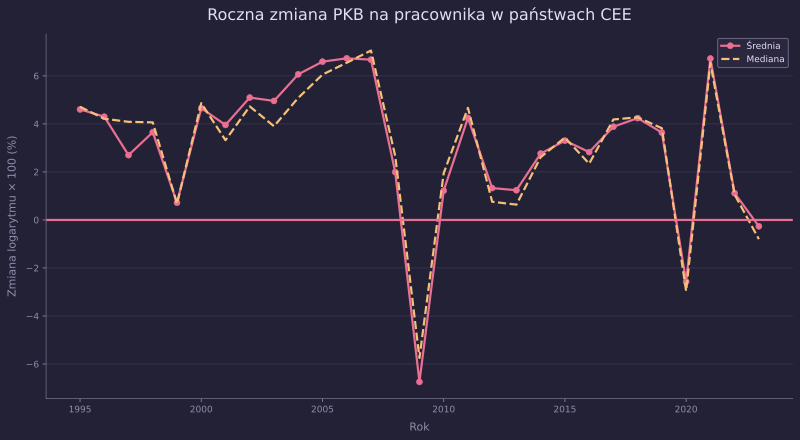

In [147]:
fig, ax = plt.subplots()

ax.plot(
    yearly_growth["year"],
    yearly_growth["srednia"],
    marker="o",
    label="Średnia",
)

ax.plot(
    yearly_growth["year"],
    yearly_growth["mediana"],
    linestyle="--",
    label="Mediana",
)

ax.axhline(0)

ax.set_title(
    "Roczna zmiana PKB na pracownika "
    "w państwach CEE"
)
ax.set_xlabel("Rok")
ax.set_ylabel("Zmiana logarytmu × 100 (%)")
ax.legend()


save_figure(
    fig,
    "srednia_i_mediana_wzrostu_pkb_na_pracownika_cee_1995_2023",
)

plt.show()

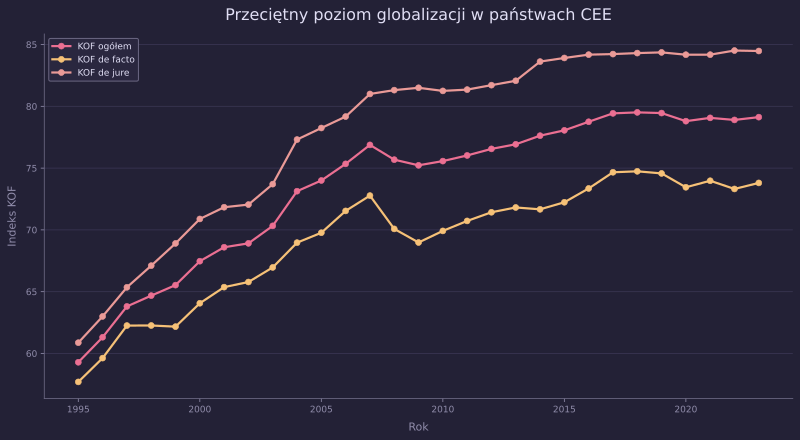

In [148]:
fig, ax = plt.subplots()

kof_overall_series = {
    "kof_overall": "KOF ogółem",
    "kof_overall_de_facto": "KOF de facto",
    "kof_overall_de_jure": "KOF de jure",
}

for variable, label in kof_overall_series.items():
    ax.plot(
        yearly_means["year"],
        yearly_means[variable],
        marker="o",
        label=label,
    )

ax.set_title(
    "Przeciętny poziom globalizacji "
    "w państwach CEE"
)
ax.set_xlabel("Rok")
ax.set_ylabel("Indeks KOF")
ax.legend()


save_figure(
    fig,
    "sredni_kof_ogolem_de_facto_de_jure_cee_1995_2023",
)

plt.show()

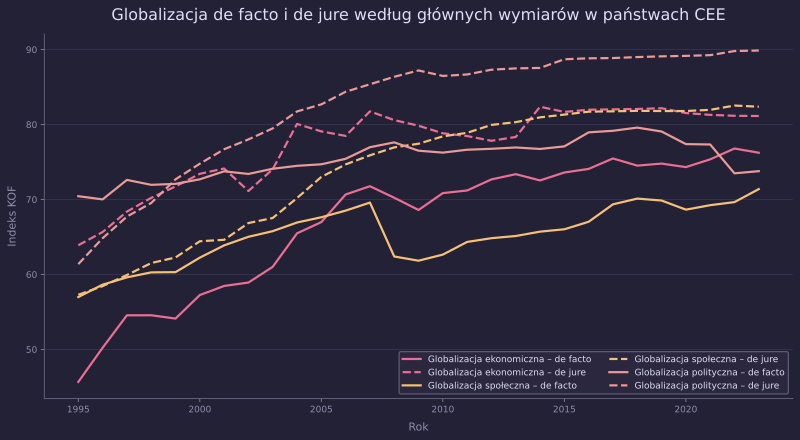

In [149]:
# ============================================================
# GŁÓWNE WYMIARY GLOBALIZACJI:
# DE FACTO I DE JURE
# ============================================================

dimension_components = {
    "Globalizacja ekonomiczna": {
        "de_facto": "kof_economic_de_facto",
        "de_jure": "kof_economic_de_jure",
    },
    "Globalizacja społeczna": {
        "de_facto": "kof_social_de_facto",
        "de_jure": "kof_social_de_jure",
    },
    "Globalizacja polityczna": {
        "de_facto": "kof_political_de_facto",
        "de_jure": "kof_political_de_jure",
    },
}

required_dimension_variables = [
    variable
    for components in dimension_components.values()
    for variable in components.values()
]

missing_dimension_variables = [
    variable
    for variable in required_dimension_variables
    if variable not in yearly_means.columns
]

if missing_dimension_variables:
    raise ValueError(
        "W tabeli yearly_means brakuje zmiennych: "
        f"{missing_dimension_variables}"
    )

fig, ax = plt.subplots()

for dimension_label, components in dimension_components.items():

    # Kolor jest wybierany automatycznie
    # przez globalny cykl kolorów.
    de_facto_line, = ax.plot(
        yearly_means["year"],
        yearly_means[components["de_facto"]],
        linestyle="-",
        label=f"{dimension_label} – de facto",
    )

    # Ten sam kolor oznacza ten sam wymiar globalizacji
    ax.plot(
        yearly_means["year"],
        yearly_means[components["de_jure"]],
        linestyle="--",
        color=de_facto_line.get_color(),
        label=f"{dimension_label} – de jure",
    )

ax.set_title(
    "Globalizacja de facto i de jure "
    "według głównych wymiarów w państwach CEE"
)

ax.set_xlabel("Rok")
ax.set_ylabel("Indeks KOF")

ax.legend(
    ncol=2,
)

save_figure(
    fig,
    (
        "srednie_wymiary_globalizacji_"
        "de_facto_de_jure_cee_1995_2023.svg"
    ),
)

plt.show()

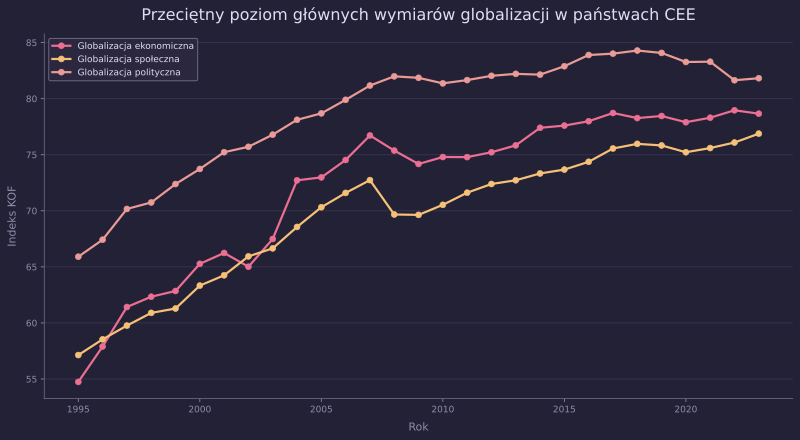

In [150]:
fig, ax = plt.subplots()

kof_dimension_series = {
    "kof_economic": "Globalizacja ekonomiczna",
    "kof_social": "Globalizacja społeczna",
    "kof_political": "Globalizacja polityczna",
}

for variable, label in kof_dimension_series.items():
    ax.plot(
        yearly_means["year"],
        yearly_means[variable],
        marker="o",
        label=label,
    )

ax.set_title(
    "Przeciętny poziom głównych wymiarów "
    "globalizacji w państwach CEE"
)
ax.set_xlabel("Rok")
ax.set_ylabel("Indeks KOF")
ax.legend()



save_figure(
    fig,
    "srednie_wymiary_globalizacji_ekonomiczna_spoleczna_polityczna_cee_1995_2023",
)

plt.show()

### Zróżnicowanie między państwami

Dla każdego roku obliczono odchylenie standardowe wybranych zmiennych między państwami, co pozwala opisać zmiany ich przekrojowego zróżnicowania w czasie.

In [151]:
yearly_dispersion = (
    sample_main
    .groupby("year")
    .agg(
        gdp_std=(
            "ln_gdp_per_worker",
            "std",
        ),
        kof_overall_std=(
            "kof_overall",
            "std",
        ),
        kof_de_facto_std=(
            "kof_overall_de_facto",
            "std",
        ),
        kof_de_jure_std=(
            "kof_overall_de_jure",
            "std",
        ),
    )
    .reset_index()
)

display(yearly_dispersion.round(3))

,year,gdp_std,kof_overall_std,kof_de_facto_std,kof_de_jure_std
0,1995,0.374,5.938,8.485,4.212
1,1996,0.364,5.330,7.261,4.181
2,1997,0.382,4.998,6.933,3.799
3,1998,0.371,4.859,6.869,3.382
4,1999,0.400,5.134,7.464,3.262
5,2000,0.397,5.025,7.561,2.866
6,2001,0.391,5.207,7.537,3.470
7,2002,0.373,4.860,6.806,3.944
8,2003,0.367,4.536,6.505,3.207
9,2004,0.348,4.307,5.783,3.539


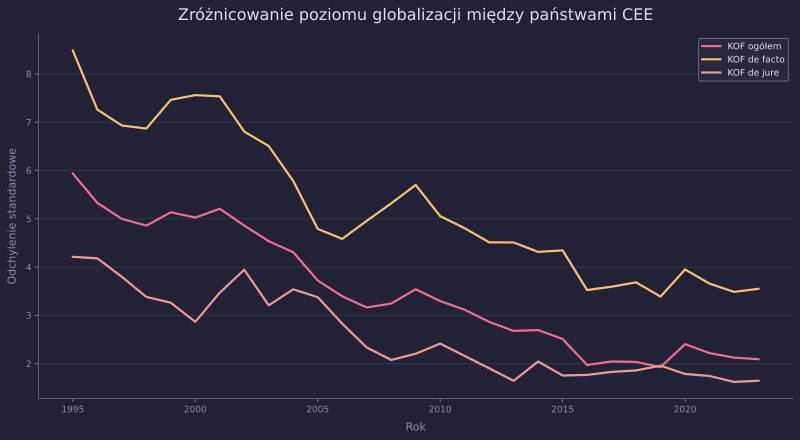

In [152]:
fig, ax = plt.subplots()

dispersion_series = {
    "kof_overall_std": "KOF ogółem",
    "kof_de_facto_std": "KOF de facto",
    "kof_de_jure_std": "KOF de jure",
}

for variable, label in dispersion_series.items():
    ax.plot(
        yearly_dispersion["year"],
        yearly_dispersion[variable],
        label=label,
    )

ax.set_title(
    "Zróżnicowanie poziomu globalizacji "
    "między państwami CEE"
)
ax.set_xlabel("Rok")
ax.set_ylabel("Odchylenie standardowe")
ax.legend()


save_figure(
    fig,
    "zroznicowanie_kof_miedzy_panstwami_cee_1995_2023",
)

plt.show()

### Porównanie standaryzowanych trendów

Wybrane szeregi średnich rocznych poddano standaryzacji, dzięki czemu możliwe jest przedstawienie na wspólnej skali zmiennych mierzonych w różnych jednostkach.

In [153]:
variables_for_standardized_trends = [
    "ln_gdp_per_worker",
    "kof_overall",
    "kof_overall_de_facto",
    "kof_overall_de_jure",
]

yearly_standardized = yearly_means[
    ["year"] + variables_for_standardized_trends
].copy()

for variable in variables_for_standardized_trends:
    yearly_standardized[variable] = (
        yearly_standardized[variable]
        - yearly_standardized[variable].mean()
    ) / yearly_standardized[variable].std()

display(yearly_standardized.round(3))

,year,ln_gdp_per_worker,kof_overall,kof_overall_de_facto,kof_overall_de_jure
0,1995,-1.798,-2.365,-2.373,-2.339
1,1996,-1.638,-2.030,-1.977,-2.048
2,1997,-1.537,-1.617,-1.436,-1.725
3,1998,-1.401,-1.473,-1.434,-1.485
4,1999,-1.375,-1.332,-1.453,-1.239
5,2000,-1.202,-1.012,-1.064,-0.968
6,2001,-1.054,-0.825,-0.796,-0.838
7,2002,-0.865,-0.773,-0.711,-0.809
8,2003,-0.680,-0.539,-0.468,-0.582
9,2004,-0.455,-0.075,-0.056,-0.088


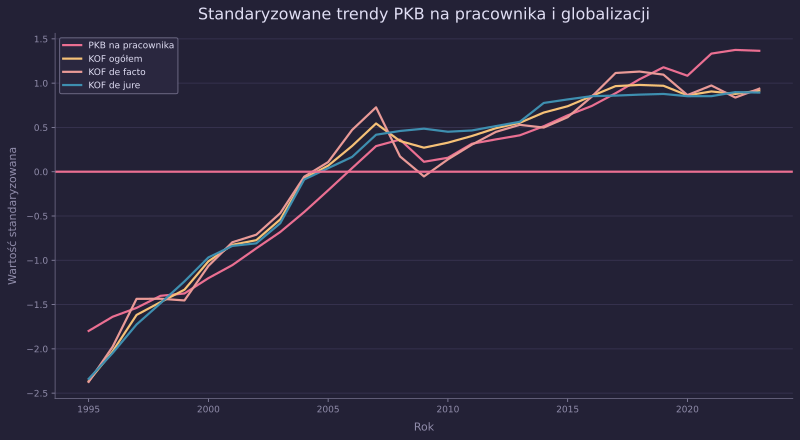

In [154]:
fig, ax = plt.subplots()

standardized_series = {
    "ln_gdp_per_worker": "PKB na pracownika",
    "kof_overall": "KOF ogółem",
    "kof_overall_de_facto": "KOF de facto",
    "kof_overall_de_jure": "KOF de jure",
}

for variable, label in standardized_series.items():
    ax.plot(
        yearly_standardized["year"],
        yearly_standardized[variable],
        label=label,
    )

ax.axhline(0)

ax.set_title(
    "Standaryzowane trendy PKB na pracownika "
    "i globalizacji"
)
ax.set_xlabel("Rok")
ax.set_ylabel("Wartość standaryzowana")
ax.legend()


save_figure(
    fig,
    "standaryzowane_trendy_pkb_i_kof_cee_1995_2023",
)

plt.show()

## 2.2. Diagnostyka obserwacji skrajnych

Przed dalszą analizą sprawdzono występowanie obserwacji skrajnych wewnątrz poszczególnych państw. Identyfikacja miała charakter diagnostyczny – wykryte obserwacje nie były automatycznie usuwane ani modyfikowane.

### Identyfikacja obserwacji skrajnych

Diagnostykę przeprowadzono dla zmiennych charakteryzujących się możliwością występowania dużych zmian krótkookresowych: wzrostu PKB na pracownika, inwestycji, inflacji oraz napływu BIZ.

In [155]:
outlier_variables = [
    "d_ln_gdp_per_worker",
    "ln_gcf_per_worker",
    "inflation_cpi",
    "fdi_gdp",
]

missing_outlier_variables = [
    variable
    for variable in outlier_variables
    if variable not in sample_main.columns
]

if missing_outlier_variables:
    raise ValueError(
        f"W danych brakuje zmiennych: {missing_outlier_variables}"
    )

In [156]:
def identify_within_country_outliers(
    df: pd.DataFrame,
    variables: list[str],
    entity_col: str = "iso3",
    country_col: str = "country",
    time_col: str = "year",
    robust_z_threshold: float = 3.5,
) -> pd.DataFrame:
    """
    Identyfikuje obserwacje skrajne osobno dla każdego państwa.

    Stosowane kryteria:
    1. reguła 1,5 × IQR,
    2. odporny z-score oparty na medianie i MAD.

    Obserwacja zostaje uznana za skrajną, gdy spełnia
    co najmniej jedno z tych kryteriów.
    """

    results = []

    for variable in variables:
        tmp = (
            df[
                [
                    entity_col,
                    country_col,
                    time_col,
                    variable,
                ]
            ]
            .dropna()
            .copy()
        )

        tmp[variable] = pd.to_numeric(
            tmp[variable],
            errors="coerce",
        )

        tmp = tmp.dropna(subset=[variable])

        # Mediana w danym państwie
        tmp["country_median"] = (
            tmp
            .groupby(entity_col)[variable]
            .transform("median")
        )

        # Median absolute deviation
        tmp["country_mad"] = (
            tmp
            .groupby(entity_col)[variable]
            .transform(
                lambda series: np.median(
                    np.abs(
                        series
                        - np.median(series)
                    )
                )
            )
        )

        tmp["robust_z"] = np.nan

        valid_mad = tmp["country_mad"] > 0

        tmp.loc[valid_mad, "robust_z"] = (
            0.6745
            * (
                tmp.loc[valid_mad, variable]
                - tmp.loc[
                    valid_mad,
                    "country_median",
                ]
            )
            / tmp.loc[
                valid_mad,
                "country_mad",
            ]
        )

        # Granice IQR w danym państwie
        tmp["q1"] = (
            tmp
            .groupby(entity_col)[variable]
            .transform(
                lambda series:
                    series.quantile(0.25)
            )
        )

        tmp["q3"] = (
            tmp
            .groupby(entity_col)[variable]
            .transform(
                lambda series:
                    series.quantile(0.75)
            )
        )

        tmp["iqr"] = (
            tmp["q3"]
            - tmp["q1"]
        )

        tmp["lower_iqr"] = (
            tmp["q1"]
            - 1.5 * tmp["iqr"]
        )

        tmp["upper_iqr"] = (
            tmp["q3"]
            + 1.5 * tmp["iqr"]
        )

        tmp["is_outlier_iqr"] = (
            (tmp[variable] < tmp["lower_iqr"])
            | (tmp[variable] > tmp["upper_iqr"])
        )

        tmp["is_outlier_robust_z"] = (
            tmp["robust_z"].abs()
            > robust_z_threshold
        )

        tmp["is_outlier"] = (
            tmp["is_outlier_iqr"]
            | tmp["is_outlier_robust_z"]
        )

        tmp["direction"] = np.where(
            tmp[variable]
            >= tmp["country_median"],
            "wysoka",
            "niska",
        )

        tmp = tmp.loc[
            tmp["is_outlier"]
        ].copy()

        tmp = tmp.rename(
            columns={
                variable: "value",
                entity_col: "iso3",
                country_col: "country",
                time_col: "year",
            }
        )

        tmp["variable"] = variable
        tmp["label"] = var_labels.get(
            variable,
            variable,
        )

        results.append(tmp)

    if not results:
        return pd.DataFrame()

    outliers = pd.concat(
        results,
        ignore_index=True,
    )

    outliers["abs_robust_z"] = (
        outliers["robust_z"].abs()
    )

    outliers = (
        outliers
        .sort_values(
            [
                "variable",
                "abs_robust_z",
            ],
            ascending=[
                True,
                False,
            ],
        )
        .reset_index(drop=True)
    )

    return outliers

In [157]:
outlier_details = identify_within_country_outliers(
    sample_main,
    outlier_variables,
)

outlier_columns_to_display = [
    "variable",
    "label",
    "iso3",
    "country",
    "year",
    "value",
    "direction",
    "robust_z",
    "is_outlier_iqr",
    "is_outlier_robust_z",
]

print(
    "Liczba zidentyfikowanych obserwacji skrajnych:",
    len(outlier_details),
)

display(
    outlier_details[
        outlier_columns_to_display
    ].round(3)
)

Liczba zidentyfikowanych obserwacji skrajnych: 72


,variable,label,iso3,country,year,value,direction,robust_z,is_outlier_iqr,is_outlier_robust_z
0,d_ln_gdp_per_worker,Roczna zmiana logarytmu PKB na pracownika,BGR,Bulgaria,1997,-0.163,niska,-7.715,True,True
1,d_ln_gdp_per_worker,Roczna zmiana logarytmu PKB na pracownika,SVN,Slovenia,2009,-0.085,niska,-6.222,True,True
2,d_ln_gdp_per_worker,Roczna zmiana logarytmu PKB na pracownika,LTU,Lithuania,2009,-0.166,niska,-5.448,True,True
3,d_ln_gdp_per_worker,Roczna zmiana logarytmu PKB na pracownika,BGR,Bulgaria,1999,-0.095,niska,-5.063,True,True
4,d_ln_gdp_per_worker,Roczna zmiana logarytmu PKB na pracownika,ROU,Romania,2010,-0.096,niska,-4.550,True,True
...,...,...,...,...,...,...,...,...,...,...
67,ln_gcf_per_worker,Logarytm nakładów brutto na pracownika,BGR,Bulgaria,1996,4.279,niska,-11.700,True,True
68,ln_gcf_per_worker,Logarytm nakładów brutto na pracownika,BGR,Bulgaria,1995,4.471,niska,-11.106,True,True
69,ln_gcf_per_worker,Logarytm nakładów brutto na pracownika,BGR,Bulgaria,1997,6.558,niska,-4.641,True,True
70,ln_gcf_per_worker,Logarytm nakładów brutto na pracownika,EST,Estonia,1995,7.649,niska,-3.902,True,True


### Podsumowanie diagnostyki

Zidentyfikowane obserwacje zestawiono według zmiennej oraz państwa, wraz z informacją o zastosowanym kryterium ich wykrycia.

In [158]:
outlier_summary = (
    outlier_details
    .groupby(
        [
            "variable",
            "label",
        ],
        as_index=False,
    )
    .agg(
        liczba_obserwacji_skrajnych=(
            "year",
            "size",
        ),
        liczba_panstw=(
            "iso3",
            "nunique",
        ),
        pierwsza_obserwacja=(
            "year",
            "min",
        ),
        ostatnia_obserwacja=(
            "year",
            "max",
        ),
        wartosc_minimalna=(
            "value",
            "min",
        ),
        wartosc_maksymalna=(
            "value",
            "max",
        ),
        liczba_wskazan_iqr=(
            "is_outlier_iqr",
            "sum",
        ),
        liczba_wskazan_robust_z=(
            "is_outlier_robust_z",
            "sum",
        ),
    )
)

display(outlier_summary.round(3))

,variable,label,liczba_obserwacji_skrajnych,liczba_panstw,pierwsza_obserwacja,ostatnia_obserwacja,wartosc_minimalna,wartosc_maksymalna,liczba_wskazan_iqr,liczba_wskazan_robust_z
0,d_ln_gdp_per_worker,Roczna zmiana logarytmu PKB na pracownika,13,8,1997,2020,-0.166,0.104,13,8
1,fdi_gdp,Napływ BIZ netto (% PKB),25,9,1999,2023,-40.108,105.636,24,10
2,inflation_cpi,Inflacja CPI (%),29,8,1995,2023,8.991,1058.374,23,27
3,ln_gcf_per_worker,Logarytm nakładów brutto na pracownika,5,3,1995,1997,4.279,7.649,5,4


In [159]:
outliers_by_country = (
    outlier_details
    .groupby(
        [
            "iso3",
            "country",
            "variable",
        ],
        as_index=False,
    )
    .agg(
        liczba_obserwacji_skrajnych=(
            "year",
            "size",
        ),
        lata=(
            "year",
            lambda years:
                ", ".join(
                    str(int(year))
                    for year
                    in sorted(years)
                ),
        ),
    )
)

display(outliers_by_country)

,iso3,country,variable,liczba_obserwacji_skrajnych,lata
0,BGR,Bulgaria,d_ln_gdp_per_worker,2,"1997, 1999"
1,BGR,Bulgaria,fdi_gdp,4,"2005, 2006, 2007, 2008"
2,BGR,Bulgaria,inflation_cpi,3,"1995, 1996, 1997"
3,BGR,Bulgaria,ln_gcf_per_worker,3,"1995, 1996, 1997"
4,CZE,Czechia,fdi_gdp,3,"1999, 2002, 2005"
5,CZE,Czechia,inflation_cpi,4,"1995, 1998, 2022, 2023"
6,EST,Estonia,d_ln_gdp_per_worker,1,2009
7,EST,Estonia,fdi_gdp,2,"2005, 2021"
8,EST,Estonia,inflation_cpi,3,"1995, 1996, 2022"
9,EST,Estonia,ln_gcf_per_worker,1,1995


### Wizualizacja obserwacji skrajnych

Rozkłady analizowanych zmiennych przedstawiono za pomocą wykresów pudełkowych sporządzonych oddzielnie dla każdego państwa.

In [160]:
def plot_country_boxplot(
    df: pd.DataFrame,
    variable: str,
    entity_col: str = "iso3",
) -> None:
    countries = sorted(
        df[entity_col]
        .dropna()
        .unique()
    )

    data = [
        pd.to_numeric(
            df.loc[
                df[entity_col] == country,
                variable,
            ],
            errors="coerce",
        ).dropna()
        for country in countries
    ]

    fig, ax = plt.subplots()

    ax.boxplot(
        data,
        tick_labels=countries,
        showfliers=True,
    )

    ax.set_title(
        var_labels.get(
            variable,
            variable,
        )
    )

    ax.set_xlabel("Państwo")
    ax.set_ylabel(
        var_labels.get(
            variable,
            variable,
        )
    )

    save_figure(
        fig,
        (
            f"boxplot_{variable}"
            "_wedlug_panstwa_cee_1995_2023.svg"
        ),
    )

    plt.show()

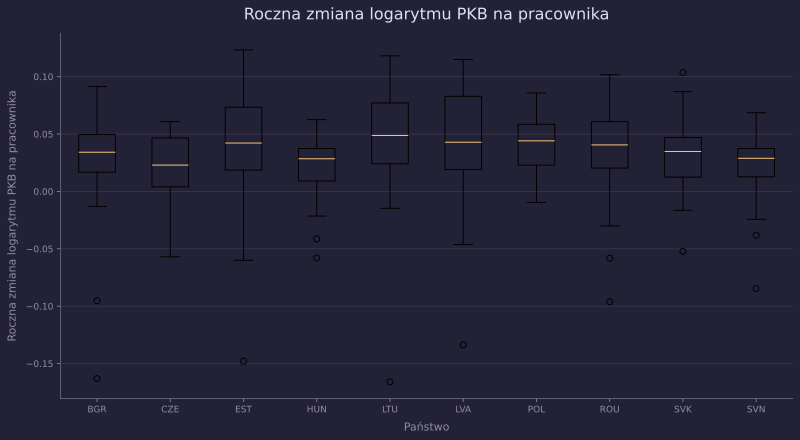

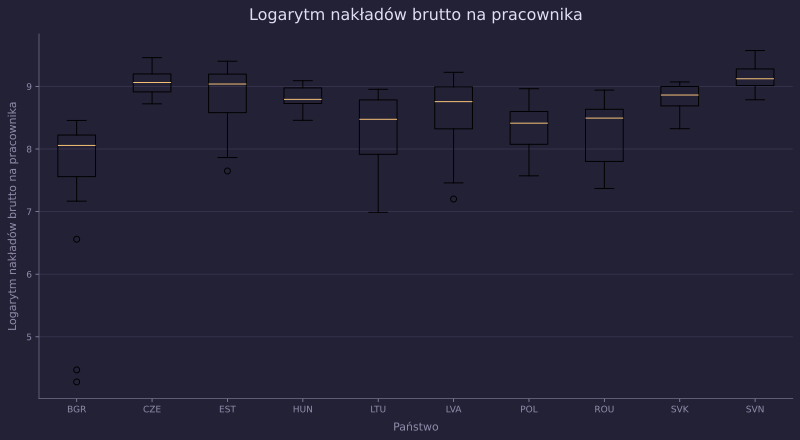

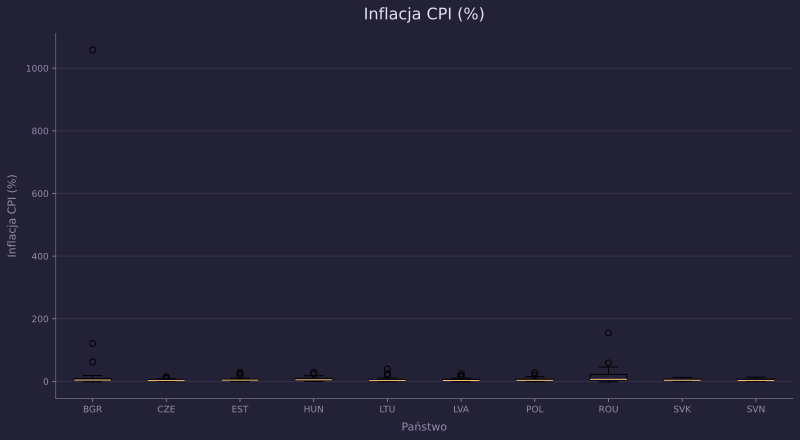

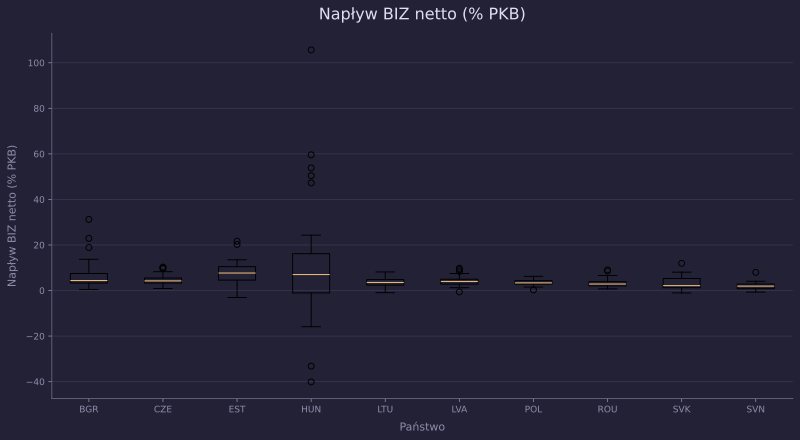

In [161]:
for variable in outlier_variables:
    plot_country_boxplot(
        sample_main,
        variable,
    )

## 2.3. Zróżnicowanie między państwami i przebieg zmiennych w czasie

Przebieg wybranych zmiennych przedstawiono oddzielnie dla badanych państw, co umożliwia porównanie ich zmian w czasie oraz różnic między krajami.

In [162]:
country_order = [
    "BGR",
    "CZE",
    "EST",
    "HUN",
    "LTU",
    "LVA",
    "POL",
    "ROU",
    "SVK",
    "SVN",
]

country_names = {
    "BGR": "Bułgaria",
    "CZE": "Czechy",
    "EST": "Estonia",
    "HUN": "Węgry",
    "LTU": "Litwa",
    "LVA": "Łotwa",
    "POL": "Polska",
    "ROU": "Rumunia",
    "SVK": "Słowacja",
    "SVN": "Słowenia",
}

time_series_variables = {
    "ln_gdp_per_worker":
        "Logarytm PKB na pracownika",
    "ln_gcf_per_worker":
        "Logarytm nakładów brutto na pracownika",
    "kof_overall":
        "Globalizacja ogółem",
    "kof_economic":
        "Globalizacja ekonomiczna",
    "kof_social":
        "Globalizacja społeczna",
    "kof_political":
        "Globalizacja polityczna",
}

event_years = [
    2008,  # światowy kryzys finansowy
    2010,  # kryzys zadłużeniowy w Europie
    2020,  # pandemia COVID-19
    2022,  # kryzys energetyczny i wojna
]

plot_data = (
    sample_main
    .loc[
        sample_main["iso3"].isin(country_order)
    ]
    .sort_values(["iso3", "year"])
    .copy()
)

# Kontrola dostępności zmiennych
missing_variables = [
    variable
    for variable in time_series_variables
    if variable not in plot_data.columns
]

if missing_variables:
    raise ValueError(
        "W danych brakuje zmiennych: "
        f"{missing_variables}"
    )

missing_countries = [
    country
    for country in country_order
    if country not in plot_data["iso3"].unique()
]

if missing_countries:
    raise ValueError(
        "W danych brakuje państw: "
        f"{missing_countries}"
    )

In [163]:
y_limits = {}

for variable in time_series_variables:
    values = pd.to_numeric(
        plot_data[variable],
        errors="coerce",
    ).dropna()

    variable_min = values.min()
    variable_max = values.max()
    variable_range = variable_max - variable_min

    margin = (
        variable_range * 0.05
        if variable_range > 0
        else 1
    )

    y_limits[variable] = (
        variable_min - margin,
        variable_max + margin,
    )

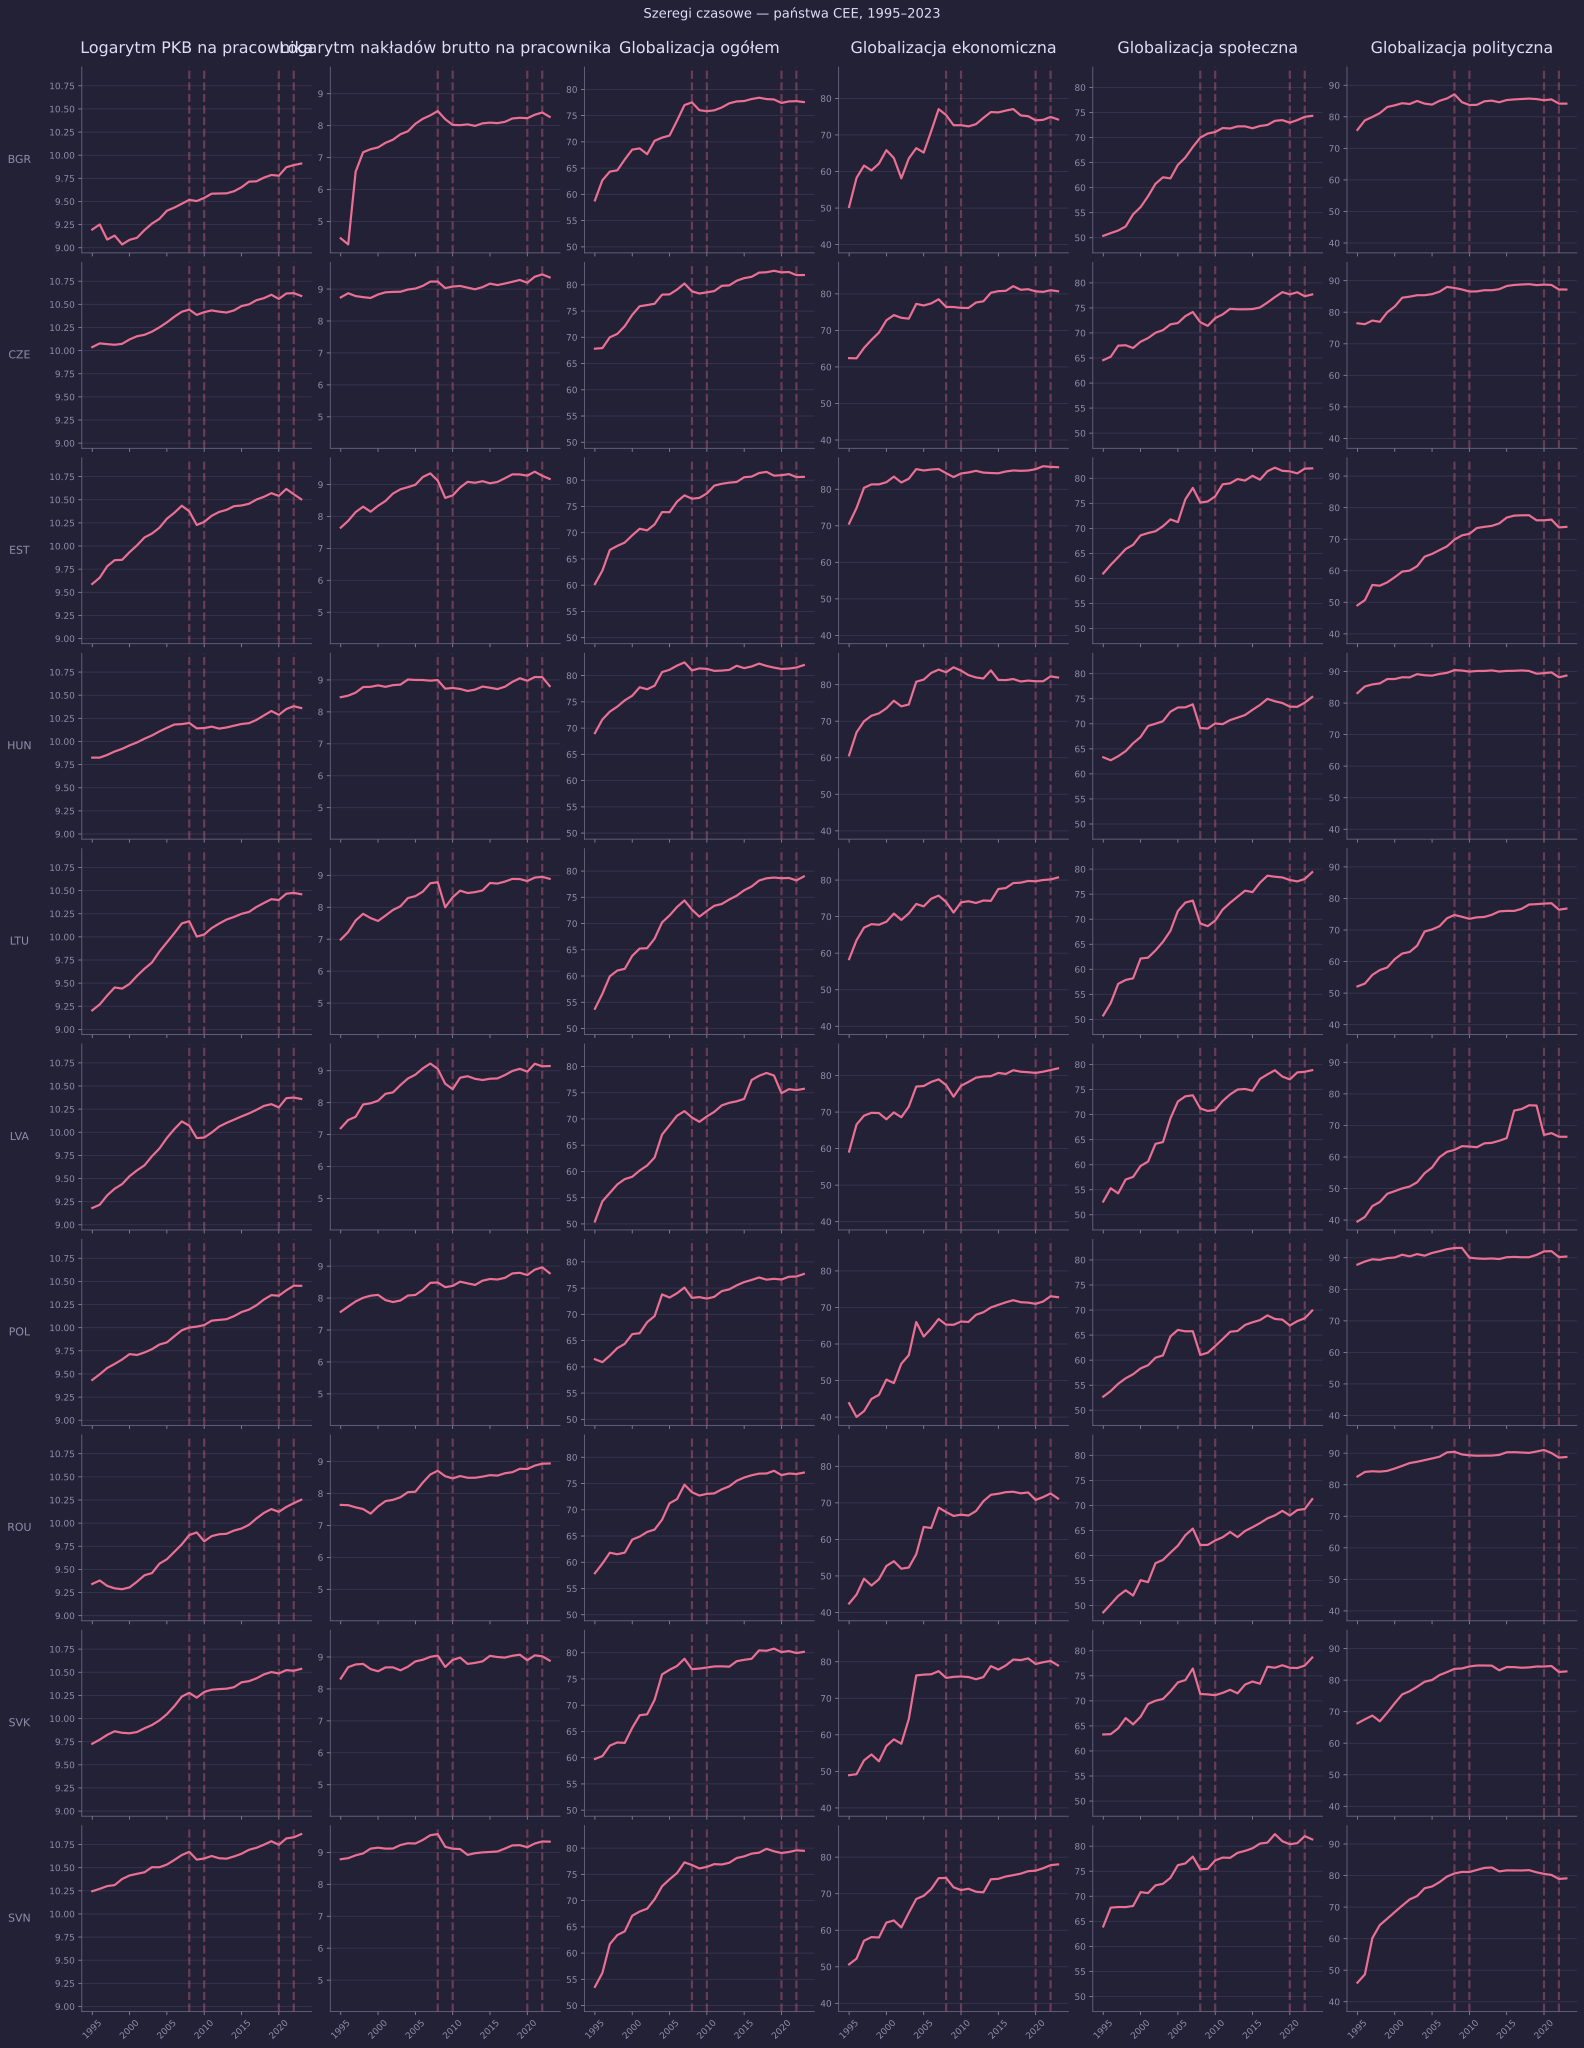

In [164]:
n_rows = len(country_order)
n_cols = len(time_series_variables)

fig, axes = plt.subplots(
    nrows=n_rows,
    ncols=n_cols,
    figsize=(22, 28),
    sharex=True,
    squeeze=False,
)

for row_index, country_code in enumerate(country_order):

    country_data = (
        plot_data
        .loc[
            plot_data["iso3"] == country_code
        ]
        .sort_values("year")
    )

    for col_index, (
        variable,
        variable_label,
    ) in enumerate(
        time_series_variables.items()
    ):

        ax = axes[row_index, col_index]

        ax.plot(
            country_data["year"],
            country_data[variable],
        )

        ax.set_ylim(
            y_limits[variable]
        )
        
        for event_year in event_years:
            ax.axvline(
                event_year,
                linestyle="--",
                alpha=0.35,
            )

        if row_index == 0:
            ax.set_title(
                variable_label,
                pad=14,
            )

        if col_index == 0:
            ax.set_ylabel(
                country_code,
                rotation=0,
                labelpad=30,
                va="center",
            )

        if row_index == n_rows - 1:
            ax.tick_params(
                axis="x",
                labelrotation=45,
            )
        else:
            ax.tick_params(
                axis="x",
                labelbottom=False,
            )

fig.suptitle(
    "Szeregi czasowe — państwa CEE, 1995–2023",
    y=1.015,
)

save_figure(
    fig,
    "szeregi_czasowe_panstwa_zmienne_cee_1995_2023.svg",
)

plt.show()

### PKB na pracownika a globalizacja de facto i de jure

Dla każdego państwa przedstawiono zależność między logarytmem PKB na pracownika a głównymi wymiarami globalizacji KOF. Wykresy przygotowano oddzielnie dla indeksów de facto i de jure, przy zachowaniu wspólnych zakresów osi w obrębie poszczególnych zmiennych.

In [165]:
scatter_dimensions = {
    "overall": "Ogółem",
    "economic": "Ekonomiczna",
    "social": "Społeczna",
    "political": "Polityczna",
}

output_variable = "ln_gdp_per_worker"

required_scatter_variables = [
    "iso3",
    output_variable,
]

for dimension in scatter_dimensions:
    required_scatter_variables.extend([
        f"kof_{dimension}_de_facto",
        f"kof_{dimension}_de_jure",
    ])

missing_scatter_variables = [
    variable
    for variable in required_scatter_variables
    if variable not in sample_main.columns
]

if missing_scatter_variables:
    raise ValueError(
        "W danych brakuje zmiennych potrzebnych do wykresu: "
        f"{missing_scatter_variables}"
    )

In [166]:
available_countries = set(
    sample_main["iso3"]
    .dropna()
    .unique()
)

missing_countries = [
    country
    for country in country_order
    if country not in available_countries
]

if missing_countries:
    raise ValueError(
        f"W danych brakuje państw: {missing_countries}"
    )

In [167]:
scatter_data = (
    sample_main
    .loc[
        sample_main["iso3"].isin(country_order),
        required_scatter_variables,
    ]
    .copy()
)
kof_x_limits = {}

for version in ["de_facto", "de_jure"]:
    for dimension in scatter_dimensions:
        variable = f"kof_{dimension}_{version}"

        values = pd.to_numeric(
            scatter_data[variable],
            errors="coerce",
        ).dropna()

        value_range = values.max() - values.min()

        margin = (
            0.05 * value_range
            if value_range > 0
            else 1
        )

        kof_x_limits[variable] = (
            values.min() - margin,
            values.max() + margin,
        )

In [168]:
output_values = pd.to_numeric(
    scatter_data[output_variable],
    errors="coerce",
).dropna()

output_range = (
    output_values.max()
    - output_values.min()
)

output_margin = (
    0.05 * output_range
    if output_range > 0
    else 0.1
)

output_limits = (
    output_values.min() - output_margin,
    output_values.max() + output_margin,
)
kof_x_limits = {}

for version in ["de_facto", "de_jure"]:
    for dimension in scatter_dimensions:
        variable = f"kof_{dimension}_{version}"

        values = pd.to_numeric(
            scatter_data[variable],
            errors="coerce",
        ).dropna()

        value_range = values.max() - values.min()

        margin = (
            0.05 * value_range
            if value_range > 0
            else 1
        )

        kof_x_limits[variable] = (
            values.min() - margin,
            values.max() + margin,
        )

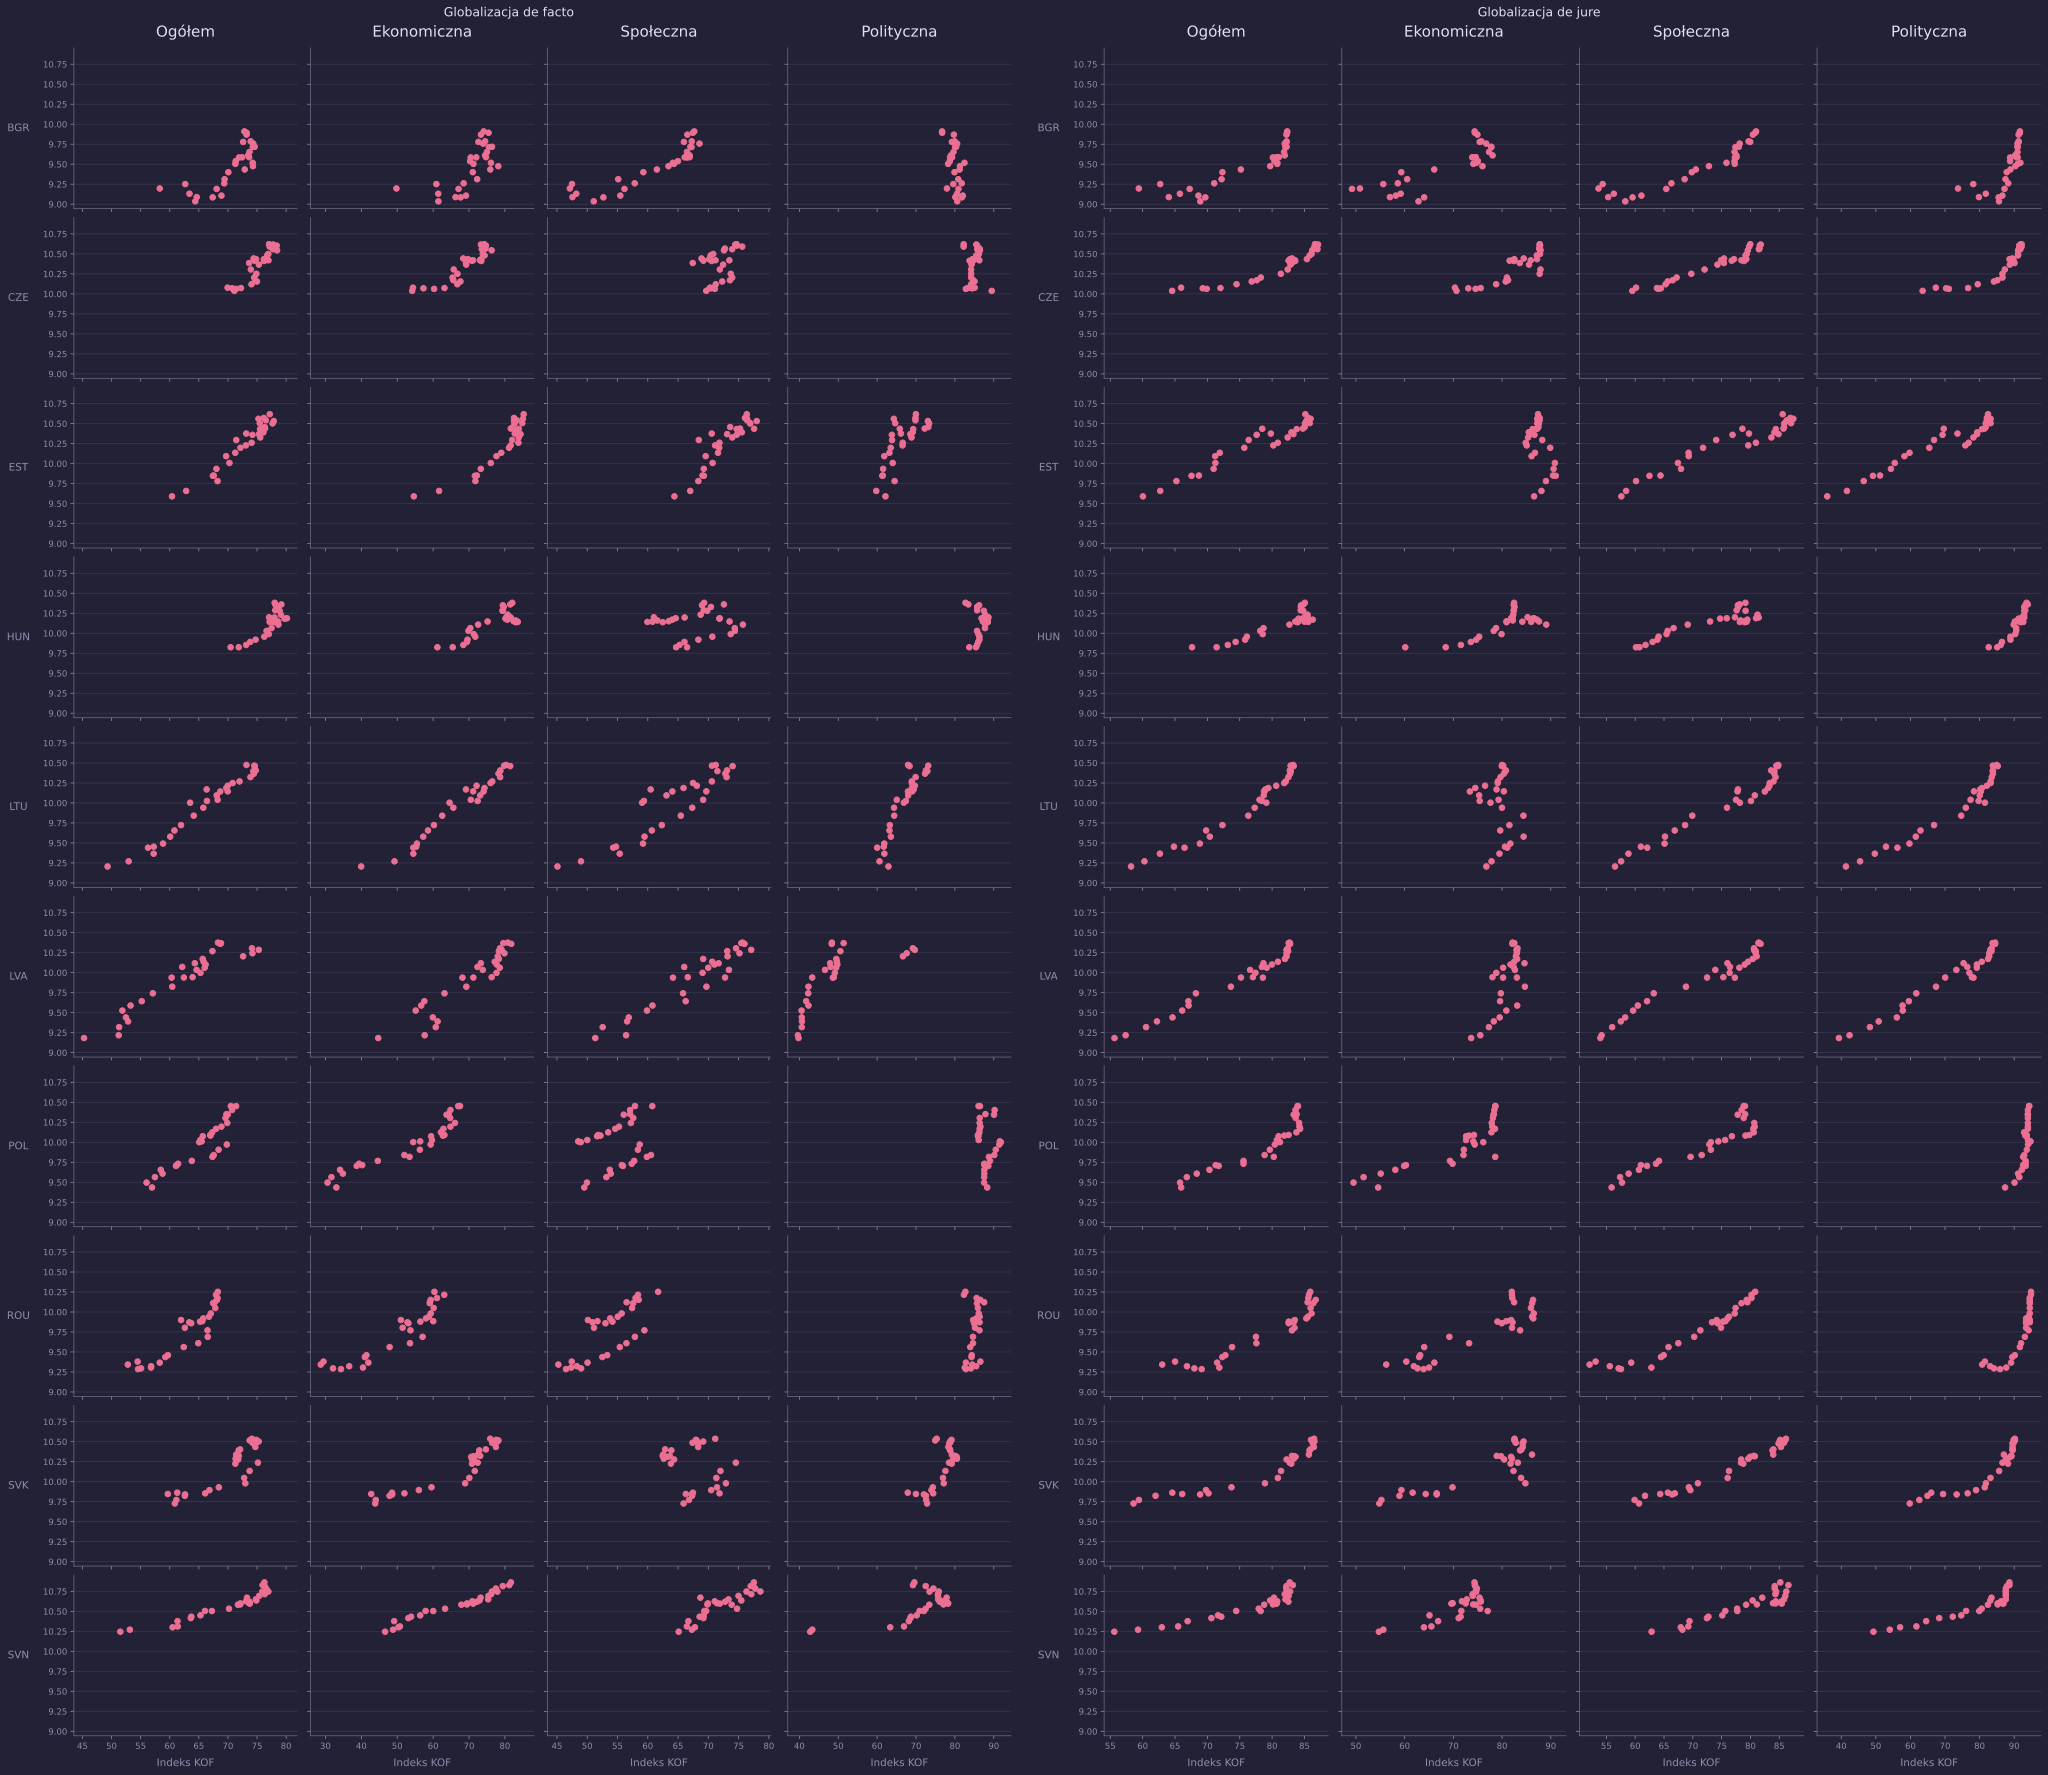

In [169]:
scatter_versions = [
    ("de_facto", "Globalizacja de facto"),
    ("de_jure", "Globalizacja de jure"),
]
fig = plt.figure(
    figsize=(30, 26),
)

subfigures = fig.subfigures(
    nrows=1,
    ncols=2,
)

for subfigure, (
    version,
    version_title,
) in zip(
    subfigures,
    scatter_versions,
):

    axes = subfigure.subplots(
        nrows=len(country_order),
        ncols=len(scatter_dimensions),
        sharex="col",
        sharey=True,
        squeeze=False,
    )

    subfigure.suptitle(version_title)

    for row_index, country_code in enumerate(country_order):
        country_data = (
            scatter_data
            .loc[scatter_data["iso3"] == country_code]
            .copy()
        )

        for col_index, (
            dimension,
            dimension_label,
        ) in enumerate(scatter_dimensions.items()):

            ax = axes[row_index, col_index]

            kof_variable = (
                f"kof_{dimension}_{version}"
            )

            subplot_data = (
                country_data[
                    [
                        kof_variable,
                        output_variable,
                    ]
                ]
                .dropna()
            )

            ax.scatter(
                subplot_data[kof_variable],
                subplot_data[output_variable],
            )

            ax.set_xlim(
                kof_x_limits[kof_variable]
            )
            ax.set_ylim(
                output_limits
            )

            if row_index == 0:
                ax.set_title(
                    dimension_label,
                    pad=12,
                )

            if col_index == 0:
                ax.set_ylabel(
                    country_code,
                    rotation=0,
                    labelpad=26,
                    va="center",
                )
            else:
                ax.tick_params(
                    axis="y",
                    labelleft=False,
                )

            if row_index == len(country_order) - 1:
                ax.set_xlabel("Indeks KOF")
            else:
                ax.tick_params(
                    axis="x",
                    labelbottom=False,
                )

### Szeregi czasowe dla wszystkich państw

Dla wybranych zmiennych utworzono osobne wykresy przedstawiające ich przebieg w czasie we wszystkich badanych państwach. Każdemu państwu przypisano stały kolor, stosowany na kolejnych wykresach.

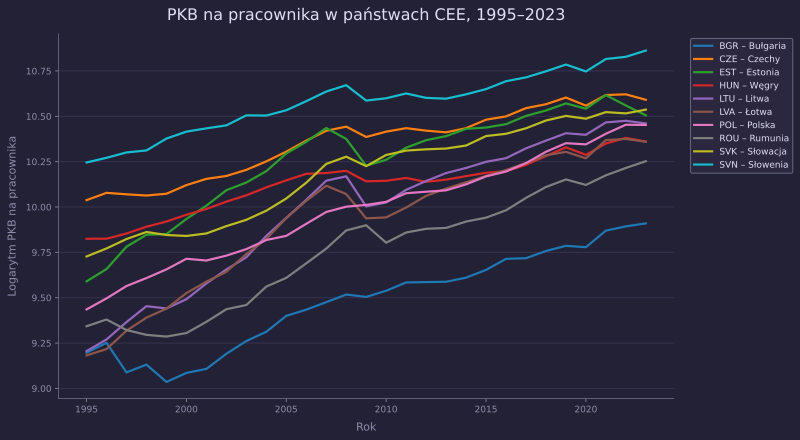

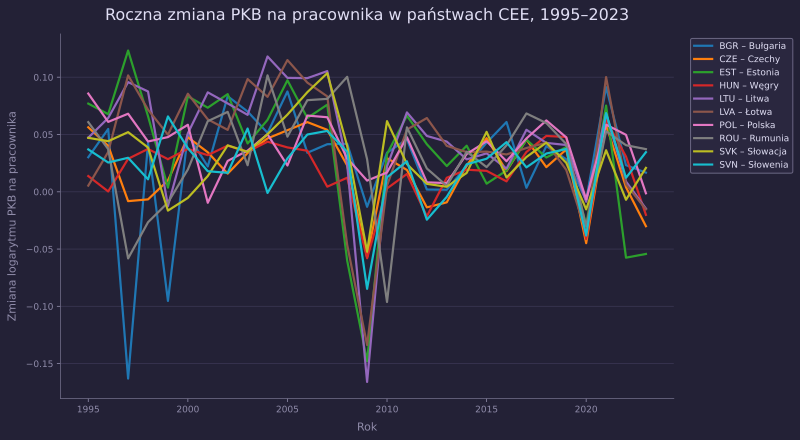

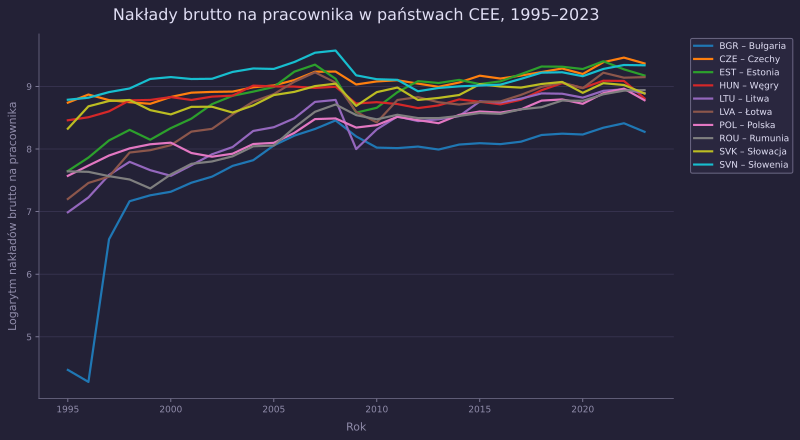

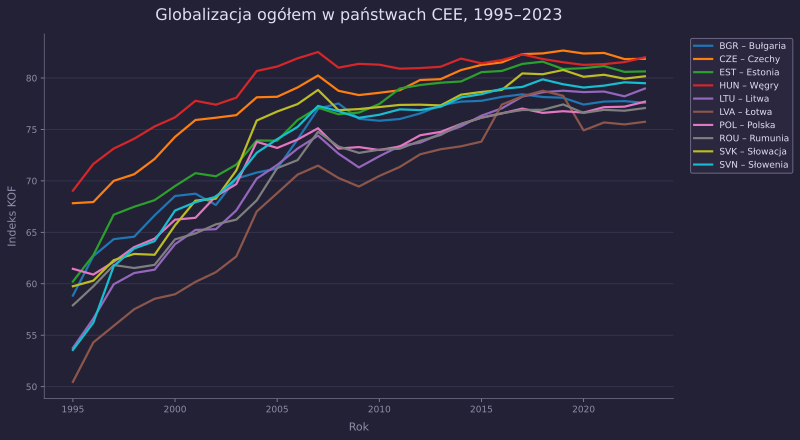

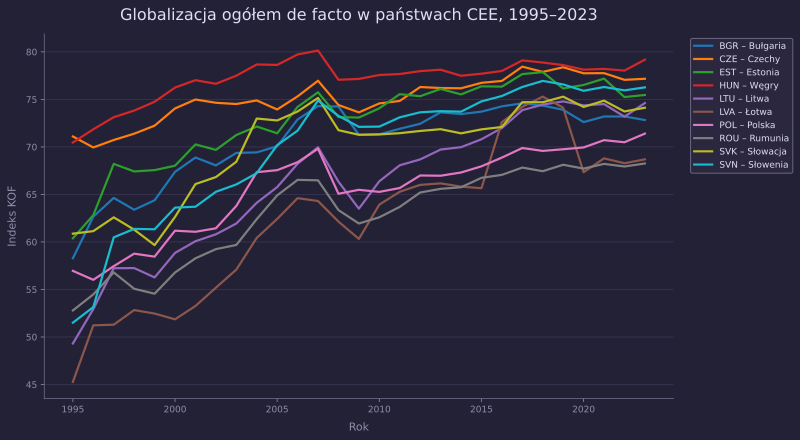

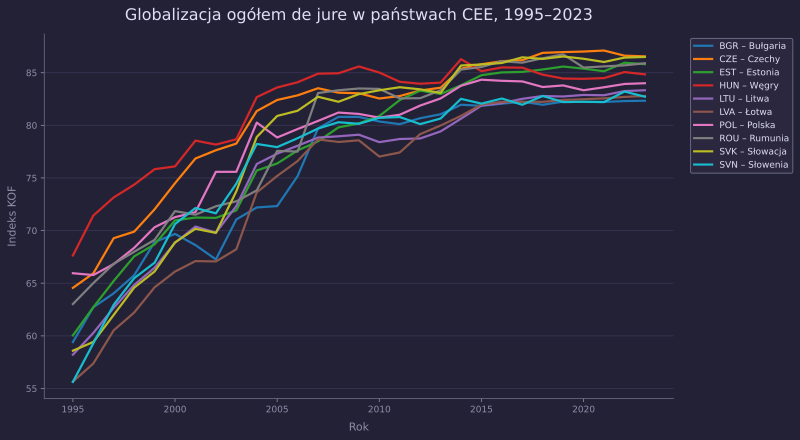

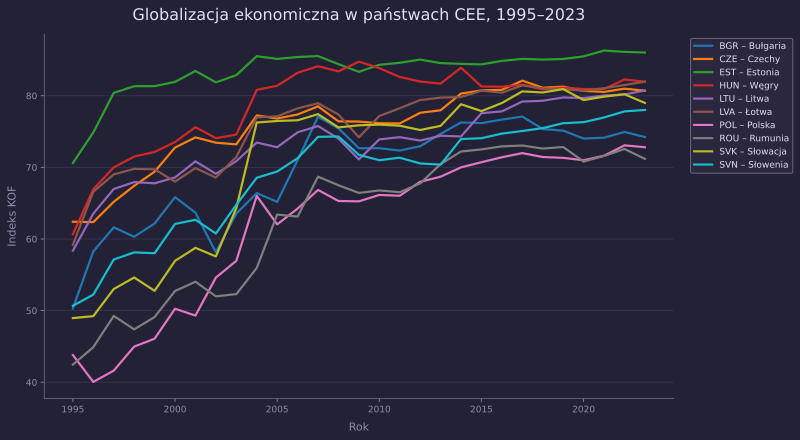

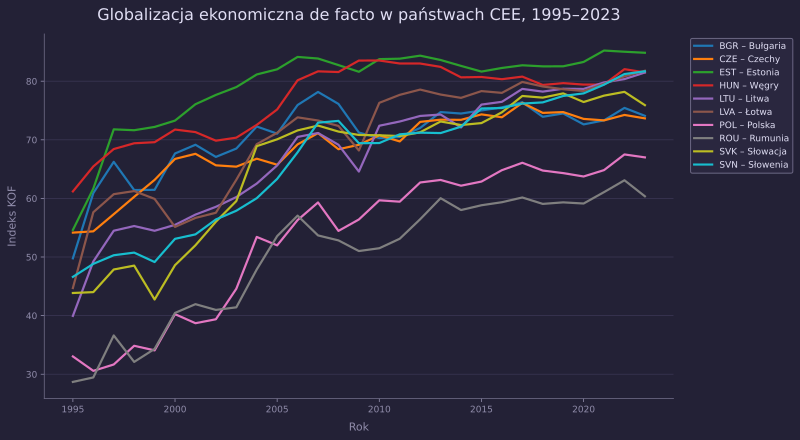

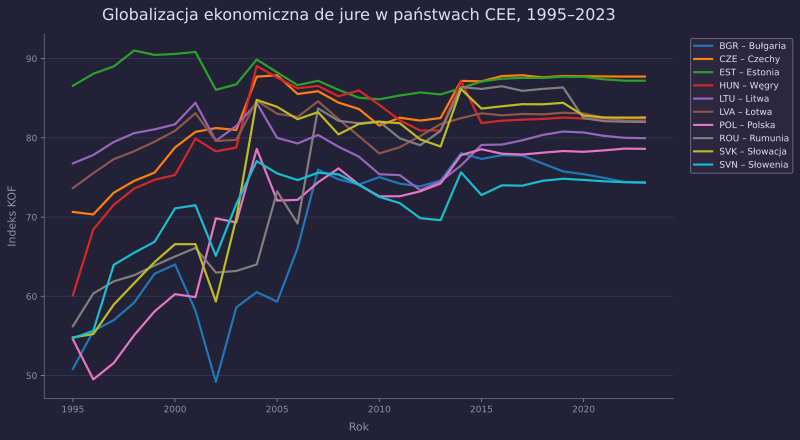

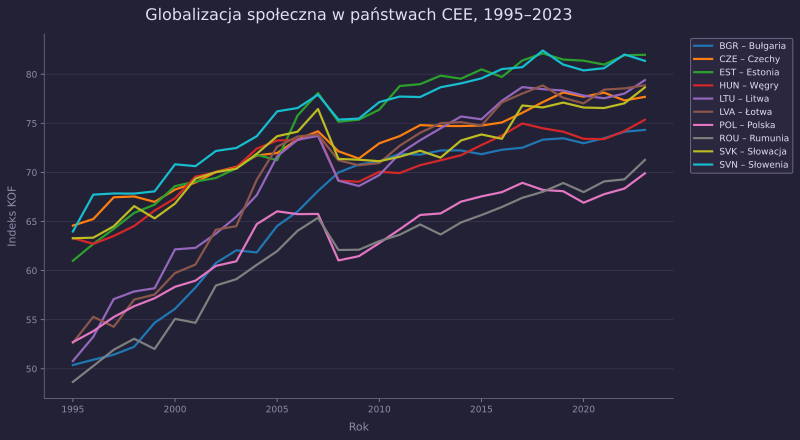

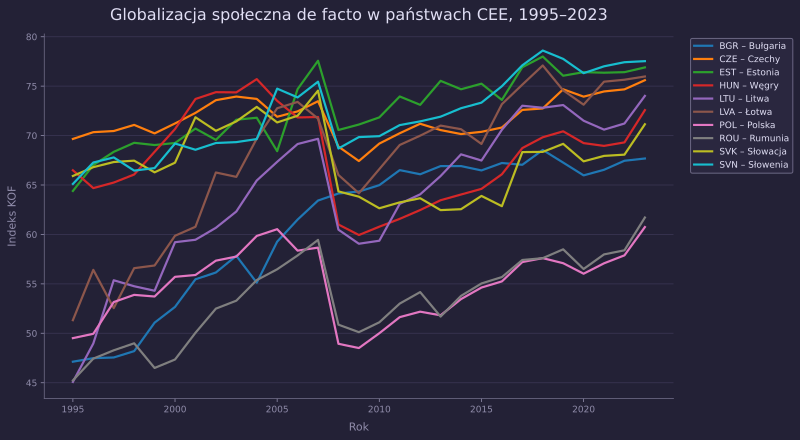

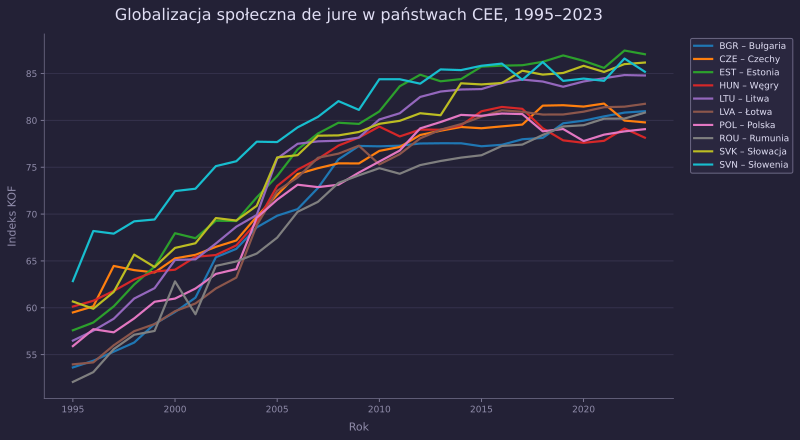

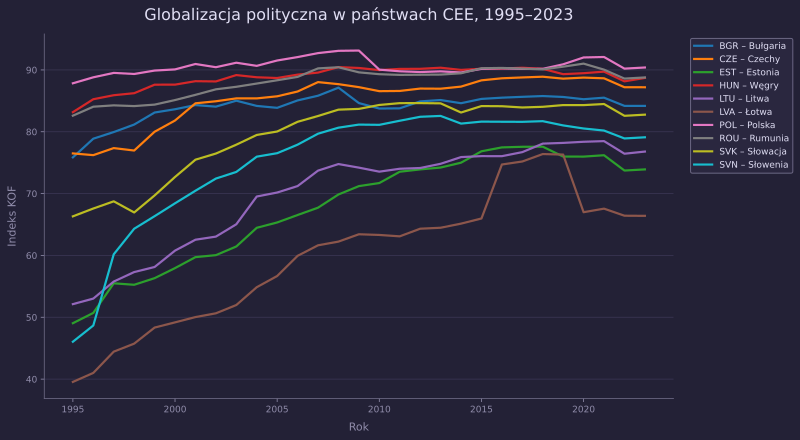

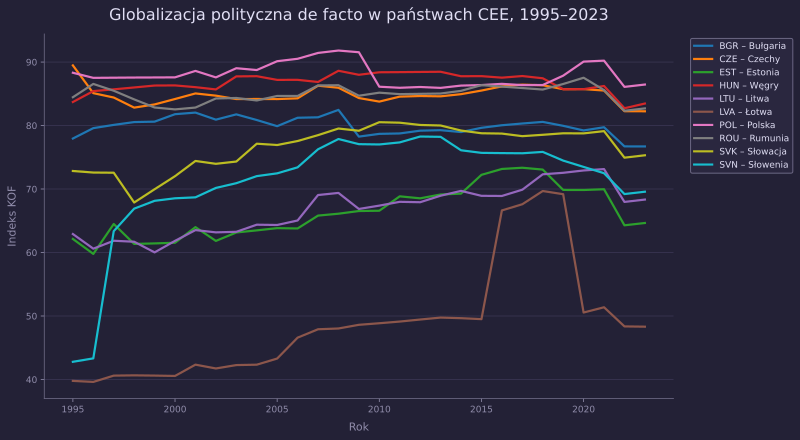

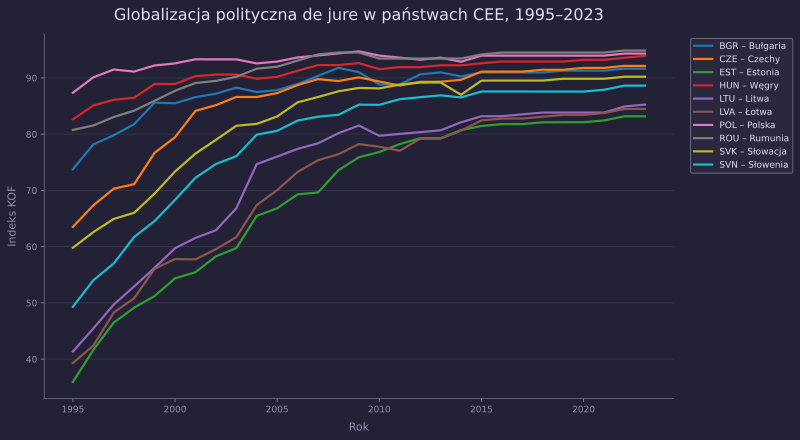

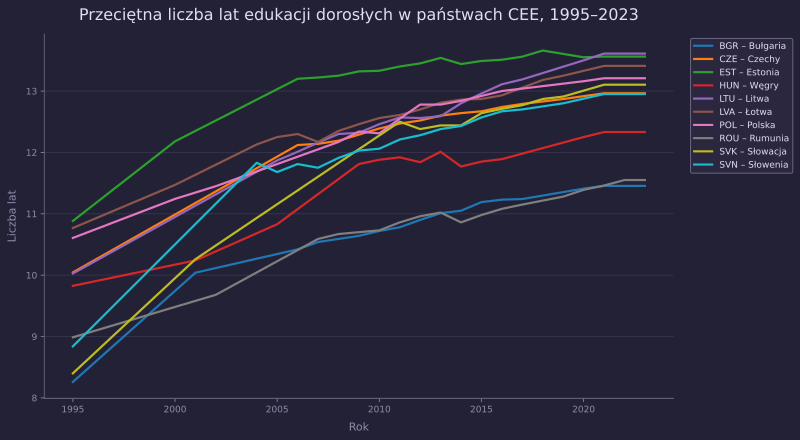

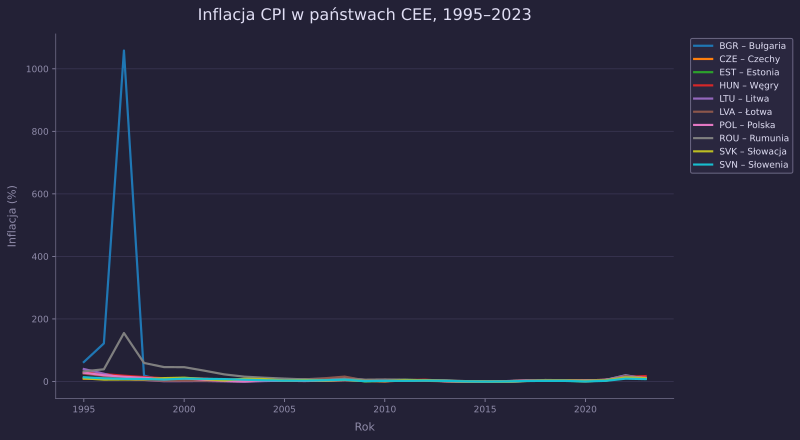

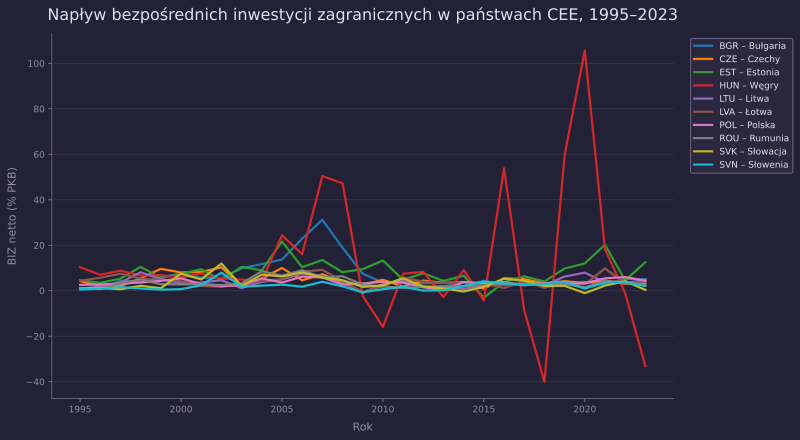

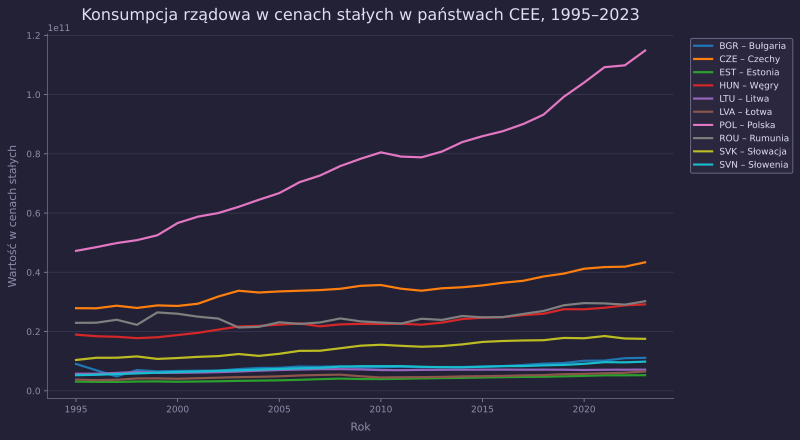

In [170]:
country_palette = plt.get_cmap("tab10").colors

country_colors = dict(
    zip(country_order, country_palette)
)

def plot_all_countries_time_series(
    df: pd.DataFrame,
    variable: str,
    variable_label: str,
    y_label: str | None = None,
    country_col: str = "iso3",
    year_col: str = "year",
    countries: list[str] = country_order,
) -> Path:
    """
    Tworzy wykres szeregu czasowego jednej zmiennej
    dla wszystkich państw CEE.

    Każde państwo ma stały, wyróżniający się kolor.
    Wykres jest automatycznie zapisywany jako SVG.
    """

    required_columns = {
        country_col,
        year_col,
        variable,
    }

    missing_columns = (
        required_columns
        - set(df.columns)
    )

    if missing_columns:
        raise ValueError(
            "W danych brakuje kolumn: "
            f"{sorted(missing_columns)}"
        )

    plot_data = (
        df
        .loc[
            df[country_col].isin(countries),
            [
                country_col,
                year_col,
                variable,
            ],
        ]
        .copy()
    )

    plot_data[variable] = pd.to_numeric(
        plot_data[variable],
        errors="coerce",
    )

    plot_data = (
        plot_data
        .sort_values(
            [
                country_col,
                year_col,
            ]
        )
    )

    fig, ax = plt.subplots()

    plotted_countries = []

    for country_code in countries:

        country_data = (
            plot_data
            .loc[
                plot_data[country_col]
                == country_code
            ]
            .dropna(
                subset=[variable]
            )
        )

        if country_data.empty:
            continue

        ax.plot(
            country_data[year_col],
            country_data[variable],
            color=country_colors[country_code],
            label=(
                f"{country_code} – "
                f"{country_names.get(country_code, country_code)}"
            ),
        )

        plotted_countries.append(
            country_code
        )

    if not plotted_countries:
        plt.close(fig)

        raise ValueError(
            f"Brak obserwacji dla zmiennej {variable}."
        )

    ax.set_title(
        f"{variable_label} w państwach CEE, 1995–2023"
    )

    ax.set_xlabel("Rok")

    ax.set_ylabel(
        y_label
        if y_label is not None
        else variable_label
    )

    ax.legend(
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
    )

    output_filename = (
        f"szeregi_czasowe_{variable}_"
        "wszystkie_panstwa_cee_1995_2023.svg"
    )

    output_path = save_figure(
        fig,
        output_filename,
    )

    plt.show()

    return output_path



all_countries_time_series_variables = {
    # Rozwój gospodarczy i inwestycje
    "ln_gdp_per_worker": {
        "title": "PKB na pracownika",
        "ylabel": "Logarytm PKB na pracownika",
    },

    "d_ln_gdp_per_worker": {
        "title": "Roczna zmiana PKB na pracownika",
        "ylabel": "Zmiana logarytmu PKB na pracownika",
    },

    "ln_gcf_per_worker": {
        "title": "Nakłady brutto na pracownika",
        "ylabel": "Logarytm nakładów brutto na pracownika",
    },

    # Globalizacja ogółem
    "kof_overall": {
        "title": "Globalizacja ogółem",
        "ylabel": "Indeks KOF",
    },

    "kof_overall_de_facto": {
        "title": "Globalizacja ogółem de facto",
        "ylabel": "Indeks KOF",
    },

    "kof_overall_de_jure": {
        "title": "Globalizacja ogółem de jure",
        "ylabel": "Indeks KOF",
    },

    # Globalizacja ekonomiczna
    "kof_economic": {
        "title": "Globalizacja ekonomiczna",
        "ylabel": "Indeks KOF",
    },

    "kof_economic_de_facto": {
        "title": "Globalizacja ekonomiczna de facto",
        "ylabel": "Indeks KOF",
    },

    "kof_economic_de_jure": {
        "title": "Globalizacja ekonomiczna de jure",
        "ylabel": "Indeks KOF",
    },

    # Globalizacja społeczna
    "kof_social": {
        "title": "Globalizacja społeczna",
        "ylabel": "Indeks KOF",
    },

    "kof_social_de_facto": {
        "title": "Globalizacja społeczna de facto",
        "ylabel": "Indeks KOF",
    },

    "kof_social_de_jure": {
        "title": "Globalizacja społeczna de jure",
        "ylabel": "Indeks KOF",
    },

    # Globalizacja polityczna
    "kof_political": {
        "title": "Globalizacja polityczna",
        "ylabel": "Indeks KOF",
    },

    "kof_political_de_facto": {
        "title": "Globalizacja polityczna de facto",
        "ylabel": "Indeks KOF",
    },

    "kof_political_de_jure": {
        "title": "Globalizacja polityczna de jure",
        "ylabel": "Indeks KOF",
    },

    # Zmienne kontrolne
    "education_years_adults": {
        "title": "Przeciętna liczba lat edukacji dorosłych",
        "ylabel": "Liczba lat",
    },

    "inflation_cpi": {
        "title": "Inflacja CPI",
        "ylabel": "Inflacja (%)",
    },

    "fdi_gdp": {
        "title": "Napływ bezpośrednich inwestycji zagranicznych",
        "ylabel": "BIZ netto (% PKB)",
    },

    "gov_consumption_const": {
        "title": "Konsumpcja rządowa w cenach stałych",
        "ylabel": "Wartość w cenach stałych",
    },
}

time_series_output_paths = {}

for variable, plot_settings in (
    all_countries_time_series_variables.items()
):

    if variable not in sample_main.columns:
        print(
            f"Pominięto {variable}: "
            "zmienna nie występuje w danych."
        )
        continue

    output_path = plot_all_countries_time_series(
        df=sample_main,
        variable=variable,
        variable_label=plot_settings["title"],
        y_label=plot_settings["ylabel"],
    )

    time_series_output_paths[
        variable
    ] = output_path
    

remaining_time_series_variables = {
    # Globalizacja handlowa
    "kof_trade": {
        "title": "Globalizacja handlowa",
        "ylabel": "Indeks KOF",
    },
    "kof_trade_de_facto": {
        "title": "Globalizacja handlowa de facto",
        "ylabel": "Indeks KOF",
    },
    "kof_trade_de_jure": {
        "title": "Globalizacja handlowa de jure",
        "ylabel": "Indeks KOF",
    },

    # Globalizacja finansowa
    "kof_financial": {
        "title": "Globalizacja finansowa",
        "ylabel": "Indeks KOF",
    },
    "kof_financial_de_facto": {
        "title": "Globalizacja finansowa de facto",
        "ylabel": "Indeks KOF",
    },
    "kof_financial_de_jure": {
        "title": "Globalizacja finansowa de jure",
        "ylabel": "Indeks KOF",
    },

    # Globalizacja interpersonalna
    "kof_interpersonal": {
        "title": "Globalizacja interpersonalna",
        "ylabel": "Indeks KOF",
    },
    "kof_interpersonal_de_facto": {
        "title": "Globalizacja interpersonalna de facto",
        "ylabel": "Indeks KOF",
    },
    "kof_interpersonal_de_jure": {
        "title": "Globalizacja interpersonalna de jure",
        "ylabel": "Indeks KOF",
    },

    # Globalizacja informacyjna
    "kof_informational": {
        "title": "Globalizacja informacyjna",
        "ylabel": "Indeks KOF",
    },
    "kof_informational_de_facto": {
        "title": "Globalizacja informacyjna de facto",
        "ylabel": "Indeks KOF",
    },
    "kof_informational_de_jure": {
        "title": "Globalizacja informacyjna de jure",
        "ylabel": "Indeks KOF",
    },

    # Globalizacja kulturowa
    "kof_cultural": {
        "title": "Globalizacja kulturowa",
        "ylabel": "Indeks KOF",
    },
    "kof_cultural_de_facto": {
        "title": "Globalizacja kulturowa de facto",
        "ylabel": "Indeks KOF",
    },
    "kof_cultural_de_jure": {
        "title": "Globalizacja kulturowa de jure",
        "ylabel": "Indeks KOF",
    },

    # Zmienna opcjonalna
    "broad_money_gdp": {
        "title": "Podaż pieniądza",
        "ylabel": "Podaż pieniądza (% PKB)",
    },
}

## 2.4. Przygotowanie ramki roboczej i grup zmiennych

Na potrzeby dalszej analizy utworzono uporządkowaną kopię próby głównej oraz zdefiniowano zestaw podstawowych zmiennych kontrolnych wykorzystywanych w kolejnych etapach analizy.

Indeksy KOF będą wprowadzane do modeli w oddzielnych
specyfikacjach. Lista kandydatów obejmuje indeksy zagregowane
oraz ich warianty de facto i de jure.

In [171]:
eda_model = (
    sample_main
    .sort_values(["iso3", "year"])
    .copy()
)

main_control_variables = [
    "education_years_adults",
    "gov_consumption_const",
    "inflation_cpi",
    "fdi_gdp",
]

## 2.5. Struktura korelacji

Korelacje obliczono w trzech wariantach. Korelacje pooled wyznaczono na nieprzekształconych danych panelowych. W wariancie within od każdej obserwacji odjęto średnią właściwą dla danego państwa. W wariancie two-way odjęto średnie państw i lat, a następnie dodano średnią całej próby.

Takie zestawienie pozwala porównać strukturę zależności przed i po usunięciu stałych różnic między państwami oraz wspólnych efektów czasowych.

In [172]:
def two_way_demean_frame(
    df: pd.DataFrame,
    variables: list[str],
    entity_col: str = "iso3",
    time_col: str = "year",
) -> pd.DataFrame:
    """
    Usuwa ze zmiennych średnie państw i lat
    oraz dodaje średnią całej próby.
    """

    transformed = pd.DataFrame(index=df.index)

    for variable in variables:
        entity_mean = (
            df
            .groupby(entity_col)[variable]
            .transform("mean")
        )

        time_mean = (
            df
            .groupby(time_col)[variable]
            .transform("mean")
        )

        overall_mean = df[variable].mean()

        transformed[variable] = (
            df[variable]
            - entity_mean
            - time_mean
            + overall_mean
        )

    return transformed


def panel_correlation_matrices(
    df: pd.DataFrame,
    variables: list[str],
    entity_col: str = "iso3",
    time_col: str = "year",
) -> dict[str, pd.DataFrame]:
    """
    Oblicza trzy macierze korelacji:
    - pooled,
    - within,
    - two-way.
    """

    pooled_matrix = (
        df[variables]
        .corr(min_periods=10)
    )

    within_values = (
        df[variables]
        - df
        .groupby(entity_col)[variables]
        .transform("mean")
    )

    within_matrix = (
        within_values
        .corr(min_periods=10)
    )

    two_way_values = two_way_demean_frame(
        df=df,
        variables=variables,
        entity_col=entity_col,
        time_col=time_col,
    )

    two_way_matrix = (
        two_way_values
        .corr(min_periods=10)
    )

    return {
        "pooled": pooled_matrix,
        "within": within_matrix,
        "two_way": two_way_matrix,
    }

### 2.5.1. Korelacje głównych zmiennych

Macierze korelacji obliczono dla zmiennej zależnej, kapitału, trzech wariantów ogólnego indeksu KOF oraz podstawowych zmiennych kontrolnych.

In [173]:
correlation_variables = [
    "ln_gdp_per_worker",
    "ln_gcf_per_worker",

    "kof_overall",
    "kof_overall_de_facto",
    "kof_overall_de_jure",

    "education_years_adults",
    "gov_consumption_const",
    "inflation_cpi",
    "fdi_gdp",
]

main_correlation_results = (
    panel_correlation_matrices(
        df=eda_model,
        variables=correlation_variables,
    )
)

corr_pooled = main_correlation_results["pooled"]
corr_within = main_correlation_results["within"]
corr_two_way = main_correlation_results["two_way"]

print("Korelacje pooled:")
display(corr_pooled.round(3))

print("Korelacje within:")
display(corr_within.round(3))

print("Korelacje two-way:")
display(corr_two_way.round(3))

Korelacje pooled:


,ln_gdp_per_worker,ln_gcf_per_worker,kof_overall,kof_overall_de_facto,kof_overall_de_jure,education_years_adults,gov_consumption_const,inflation_cpi,fdi_gdp
ln_gdp_per_worker,1.000,0.855,0.707,0.663,0.666,0.729,0.086,-0.222,-0.014
ln_gcf_per_worker,0.855,1.000,0.644,0.602,0.609,0.607,0.028,-0.301,0.069
kof_overall,0.707,0.644,1.000,0.936,0.945,0.656,0.151,-0.166,0.119
kof_overall_de_facto,0.663,0.602,0.936,1.000,0.769,0.529,0.036,-0.116,0.165
kof_overall_de_jure,0.666,0.609,0.945,0.769,1.000,0.699,0.240,-0.193,0.062
education_years_adults,0.729,0.607,0.656,0.529,0.699,1.000,0.125,-0.228,0.008
gov_consumption_const,0.086,0.028,0.151,0.036,0.240,0.125,1.000,-0.046,-0.029
inflation_cpi,-0.222,-0.301,-0.166,-0.116,-0.193,-0.228,-0.046,1.000,-0.015
fdi_gdp,-0.014,0.069,0.119,0.165,0.062,0.008,-0.029,-0.015,1.000


Korelacje within:


,ln_gdp_per_worker,ln_gcf_per_worker,kof_overall,kof_overall_de_facto,kof_overall_de_jure,education_years_adults,gov_consumption_const,inflation_cpi,fdi_gdp
ln_gdp_per_worker,1.000,0.773,0.925,0.887,0.918,0.904,0.504,-0.159,0.014
ln_gcf_per_worker,0.773,1.000,0.757,0.736,0.743,0.688,0.328,-0.263,0.098
kof_overall,0.925,0.757,1.000,0.970,0.985,0.938,0.409,-0.178,0.035
kof_overall_de_facto,0.887,0.736,0.970,1.000,0.914,0.875,0.376,-0.152,0.045
kof_overall_de_jure,0.918,0.743,0.985,0.914,1.000,0.949,0.418,-0.190,0.026
education_years_adults,0.904,0.688,0.938,0.875,0.949,1.000,0.472,-0.181,0.021
gov_consumption_const,0.504,0.328,0.409,0.376,0.418,0.472,1.000,-0.050,0.012
inflation_cpi,-0.159,-0.263,-0.178,-0.152,-0.190,-0.181,-0.050,1.000,-0.027
fdi_gdp,0.014,0.098,0.035,0.045,0.026,0.021,0.012,-0.027,1.000


Korelacje two-way:


,ln_gdp_per_worker,ln_gcf_per_worker,kof_overall,kof_overall_de_facto,kof_overall_de_jure,education_years_adults,gov_consumption_const,inflation_cpi,fdi_gdp
ln_gdp_per_worker,1.000,0.400,0.460,0.415,0.373,-0.036,0.021,0.018,-0.077
ln_gcf_per_worker,0.400,1.000,0.173,0.185,0.095,-0.137,-0.069,-0.211,0.028
kof_overall,0.460,0.173,1.000,0.912,0.800,0.262,-0.246,0.045,-0.072
kof_overall_de_facto,0.415,0.185,0.912,1.000,0.483,0.185,-0.168,0.036,-0.041
kof_overall_de_jure,0.373,0.095,0.800,0.483,1.000,0.301,-0.278,0.045,-0.093
education_years_adults,-0.036,-0.137,0.262,0.185,0.301,1.000,-0.095,0.032,-0.005
gov_consumption_const,0.021,-0.069,-0.246,-0.168,-0.278,-0.095,1.000,0.038,0.002
inflation_cpi,0.018,-0.211,0.045,0.036,0.045,0.032,0.038,1.000,-0.013
fdi_gdp,-0.077,0.028,-0.072,-0.041,-0.093,-0.005,0.002,-0.013,1.000


In [174]:
def pearson_correlation_with_pvalues(
    df,
    variables,
):
    correlations = pd.DataFrame(
        index=variables,
        columns=variables,
        dtype=float,
    )

    p_values = pd.DataFrame(
        index=variables,
        columns=variables,
        dtype=float,
    )

    for variable_1 in variables:
        for variable_2 in variables:

            # Przekątna macierzy
            if variable_1 == variable_2:
                correlations.loc[
                    variable_1,
                    variable_2
                ] = 1.0

                p_values.loc[
                    variable_1,
                    variable_2
                ] = np.nan

                continue

            pair = (
                df[
                    [
                        variable_1,
                        variable_2,
                    ]
                ]
                .dropna()
            )

            r, p = stats.pearsonr(
                pair[variable_1],
                pair[variable_2],
            )

            correlations.loc[
                variable_1,
                variable_2
            ] = float(r)

            p_values.loc[
                variable_1,
                variable_2
            ] = float(p)

    return correlations, p_values


reference_correlation_variables = [
    "ln_gcf_per_worker",
    "kof_overall",
    "education_years_adults",
    "inflation_cpi",
    "fdi_gdp",
]

reference_correlations, reference_correlation_pvalues = (
    pearson_correlation_with_pvalues(
        df=model_data,
        variables=reference_correlation_variables,
    )
)

print("Korelacje Pearsona:")
display(
    reference_correlations.round(3)
)

print("Wartości p:")
display(
    reference_correlation_pvalues.round(4)
)

Korelacje Pearsona:


,ln_gcf_per_worker,kof_overall,education_years_adults,inflation_cpi,fdi_gdp
ln_gcf_per_worker,1.000,0.644,0.607,-0.301,0.069
kof_overall,0.644,1.000,0.656,-0.166,0.119
education_years_adults,0.607,0.656,1.000,-0.228,0.008
inflation_cpi,-0.301,-0.166,-0.228,1.000,-0.015
fdi_gdp,0.069,0.119,0.008,-0.015,1.000


Wartości p:


,ln_gcf_per_worker,kof_overall,education_years_adults,inflation_cpi,fdi_gdp
ln_gcf_per_worker,NaN,0.0000,0.0000,0.0000,0.2389
kof_overall,0.0000,NaN,0.0000,0.0046,0.0426
education_years_adults,0.0000,0.0000,NaN,0.0001,0.8927
inflation_cpi,0.0000,0.0046,0.0001,NaN,0.8023
fdi_gdp,0.2389,0.0426,0.8927,0.8023,NaN


### 2.5.2. Korelacje zmiennych z PKB na pracownika

Z pełnych macierzy wyodrębniono korelacje poszczególnych zmiennych z logarytmem PKB na pracownika.

In [177]:
target_variable = "ln_gdp_per_worker"

correlation_predictors = [
    variable
    for variable in correlation_variables
    if variable != target_variable
]

target_correlation_summary = pd.DataFrame({
    "variable": correlation_predictors,

    "label": [
        var_labels.get(variable, variable)
        for variable in correlation_predictors
    ],

    "pooled_correlation": (
        corr_pooled
        .loc[target_variable, correlation_predictors]
        .to_numpy()
    ),

    "within_correlation": (
        corr_within
        .loc[target_variable, correlation_predictors]
        .to_numpy()
    ),

    "two_way_correlation": (
        corr_two_way
        .loc[target_variable, correlation_predictors]
        .to_numpy()
    ),
})

target_correlation_summary = (
    target_correlation_summary
    .sort_values(
        "two_way_correlation",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(target_correlation_summary.round(3))

def correlation_p_value(r, n):
    if pd.isna(r) or n <= 2:
        return np.nan

    t_stat = (
        r
        * np.sqrt(
            (n - 2)
            / (1 - r**2)
        )
    )

    return 2 * stats.t.sf(
        abs(t_stat),
        df=n - 2,
    )


def correlation_stars(r, n):
    p = correlation_p_value(r, n)

    if p < 0.01:
        return "***"
    elif p < 0.05:
        return "**"
    elif p < 0.10:
        return "*"
    return ""


target_correlation_report = (
    target_correlation_summary.copy()
)


# Liczba dostępnych obserwacji dla każdej pary.
target_correlation_report["nobs"] = [
    eda_model[
        [
            target_variable,
            variable,
        ]
    ]
    .dropna()
    .shape[0]

    for variable
    in target_correlation_report["variable"]
]


target_correlation_report["Pooled"] = (
    target_correlation_report.apply(
        lambda row:
            f"{row['pooled_correlation']:.3f}"
            f"{correlation_stars(
                row['pooled_correlation'],
                row['nobs']
            )}",
        axis=1,
    )
)

target_correlation_report["Within"] = (
    target_correlation_report.apply(
        lambda row:
            f"{row['within_correlation']:.3f}"
            f"{correlation_stars(
                row['within_correlation'],
                row['nobs']
            )}",
        axis=1,
    )
)

target_correlation_report["Two-way"] = (
    target_correlation_report.apply(
        lambda row:
            f"{row['two_way_correlation']:.3f}"
            f"{correlation_stars(
                row['two_way_correlation'],
                row['nobs']
            )}",
        axis=1,
    )
)


display(
    target_correlation_report[
        [
            "label",
            "Pooled",
            "Within",
            "Two-way",
        ]
    ]
)

,variable,label,pooled_correlation,within_correlation,two_way_correlation
0,kof_overall,KOF: Globalizacja ogółem,0.707,0.925,0.460
1,kof_overall_de_facto,KOF: Globalizacja ogółem – de facto,0.663,0.887,0.415
2,ln_gcf_per_worker,Logarytm nakładów brutto na pracownika,0.855,0.773,0.400
3,kof_overall_de_jure,KOF: Globalizacja ogółem – de jure,0.666,0.918,0.373
4,gov_consumption_const,Konsumpcja rządowa w cenach stałych,0.086,0.504,0.021
5,inflation_cpi,Inflacja CPI (%),-0.222,-0.159,0.018
6,education_years_adults,Przeciętna liczba lat edukacji dorosłych,0.729,0.904,-0.036
7,fdi_gdp,Napływ BIZ netto (% PKB),-0.014,0.014,-0.077


,label,Pooled,Within,Two-way
0,KOF: Globalizacja ogółem,0.707***,0.925***,0.460***
1,KOF: Globalizacja ogółem – de facto,0.663***,0.887***,0.415***
2,Logarytm nakładów brutto na pracownika,0.855***,0.773***,0.400***
3,KOF: Globalizacja ogółem – de jure,0.666***,0.918***,0.373***
4,Konsumpcja rządowa w cenach stałych,0.086,0.504***,0.021
5,Inflacja CPI (%),-0.222***,-0.159***,0.018
6,Przeciętna liczba lat edukacji dorosłych,0.729***,0.904***,-0.036
7,Napływ BIZ netto (% PKB),-0.014,0.014,-0.077


### 2.5.3. Korelacje między indeksami KOF

Macierze korelacji obliczono oddzielnie dla indeksów zagregowanych oraz ich wariantów de facto i de jure. Podział na trzy grupy pozwala uniknąć jednej rozbudowanej macierzy obejmującej wszystkie indeksy.

In [ ]:
kof_groups = {
    "Zagregowane": kof_aggregate_vars,
    "De facto": kof_de_facto_vars,
    "De jure": kof_de_jure_vars,
}

kof_correlation_results = {}

for group_label, variables in kof_groups.items():

    matrices = panel_correlation_matrices(
        df=eda_model,
        variables=variables,
    )

    kof_correlation_results[group_label] = matrices
    
    print(f"Indeksy KOF: {group_label}")

    print("\nKorelacje pooled:")
    display(matrices["pooled"].round(3))

    print("\nKorelacje two-way:")
    display(matrices["two_way"].round(3))

Indeksy KOF: Zagregowane

Korelacje pooled:


,kof_overall,kof_economic,kof_trade,kof_financial,kof_social,kof_interpersonal,kof_informational,kof_cultural,kof_political
kof_overall,1.000,0.761,0.655,0.774,0.801,0.683,0.830,0.559,0.607
kof_economic,0.761,1.000,0.933,0.955,0.779,0.814,0.709,0.434,-0.001
kof_trade,0.655,0.933,1.000,0.784,0.800,0.858,0.714,0.428,-0.147
kof_financial,0.774,0.955,0.784,1.000,0.687,0.698,0.635,0.399,0.118
kof_social,0.801,0.779,0.800,0.687,1.000,0.905,0.871,0.781,0.112
kof_interpersonal,0.683,0.814,0.858,0.698,0.905,1.000,0.731,0.517,-0.064
kof_informational,0.830,0.709,0.714,0.635,0.871,0.731,1.000,0.533,0.305
kof_cultural,0.559,0.434,0.428,0.399,0.781,0.517,0.533,1.000,0.115
kof_political,0.607,-0.001,-0.147,0.118,0.112,-0.064,0.305,0.115,1.000



Korelacje two-way:


,kof_overall,kof_economic,kof_trade,kof_financial,kof_social,kof_interpersonal,kof_informational,kof_cultural,kof_political
kof_overall,1.000,0.310,0.147,0.335,0.560,0.147,0.458,0.420,0.720
kof_economic,0.310,1.000,0.760,0.843,-0.191,0.107,0.142,-0.396,-0.307
kof_trade,0.147,0.760,1.000,0.292,0.044,0.262,0.378,-0.282,-0.459
kof_financial,0.335,0.843,0.292,1.000,-0.318,-0.060,-0.107,-0.347,-0.072
kof_social,0.560,-0.191,0.044,-0.318,1.000,0.397,0.688,0.785,0.316
kof_interpersonal,0.147,0.107,0.262,-0.060,0.397,1.000,0.369,-0.059,-0.122
kof_informational,0.458,0.142,0.378,-0.107,0.688,0.369,1.000,0.161,0.087
kof_cultural,0.420,-0.396,-0.282,-0.347,0.785,-0.059,0.161,1.000,0.423
kof_political,0.720,-0.307,-0.459,-0.072,0.316,-0.122,0.087,0.423,1.000


Indeksy KOF: De facto

Korelacje pooled:


...

,kof_overall_de_facto,kof_economic_de_facto,kof_trade_de_facto,kof_financial_de_facto,kof_social_de_facto,kof_interpersonal_de_facto,kof_informational_de_facto,kof_cultural_de_facto,kof_political_de_facto
kof_overall_de_facto,1.000,0.573,0.383,0.563,0.570,0.064,0.532,0.393,0.719
kof_economic_de_facto,0.573,1.000,0.822,0.832,-0.064,0.013,0.269,-0.253,0.136
kof_trade_de_facto,0.383,0.822,1.000,0.367,-0.071,0.073,0.297,-0.296,-0.029
kof_financial_de_facto,0.563,0.832,0.367,1.000,-0.035,-0.050,0.149,-0.124,0.249
kof_social_de_facto,0.570,-0.064,-0.071,-0.035,1.000,0.323,0.648,0.805,0.165
kof_interpersonal_de_facto,0.064,0.013,0.073,-0.050,0.323,1.000,0.370,-0.096,-0.191
kof_informational_de_facto,0.532,0.269,0.297,0.149,0.648,0.370,1.000,0.117,0.103
kof_cultural_de_facto,0.393,-0.253,-0.296,-0.124,0.805,-0.096,0.117,1.000,0.205
kof_political_de_facto,0.719,0.136,-0.029,0.249,0.165,-0.191,0.103,0.205,1.000


Indeksy KOF: De jure

Korelacje pooled:


,kof_overall_de_jure,kof_economic_de_jure,kof_trade_de_jure,kof_financial_de_jure,kof_social_de_jure,kof_interpersonal_de_jure,kof_informational_de_jure,kof_cultural_de_jure,kof_political_de_jure
kof_overall_de_jure,1.000,0.611,0.675,0.400,0.877,0.787,0.833,0.677,0.753
kof_economic_de_jure,0.611,1.000,0.848,0.892,0.534,0.575,0.438,0.390,0.015
kof_trade_de_jure,0.675,0.848,1.000,0.519,0.718,0.720,0.624,0.542,0.109
kof_financial_de_jure,0.400,0.892,0.519,1.000,0.241,0.308,0.163,0.164,-0.082
kof_social_de_jure,0.877,0.534,0.718,0.241,1.000,0.936,0.892,0.808,0.494
kof_interpersonal_de_jure,0.787,0.575,0.720,0.308,0.936,1.000,0.754,0.711,0.349
kof_informational_de_jure,0.833,0.438,0.624,0.163,0.892,0.754,1.000,0.525,0.561
kof_cultural_de_jure,0.677,0.390,0.542,0.164,0.808,0.711,0.525,1.000,0.372
kof_political_de_jure,0.753,0.015,0.109,-0.082,0.494,0.349,0.561,0.372,1.000



Korelacje two-way:


,kof_overall_de_jure,kof_economic_de_jure,kof_trade_de_jure,kof_financial_de_jure,kof_social_de_jure,kof_interpersonal_de_jure,kof_informational_de_jure,kof_cultural_de_jure,kof_political_de_jure
kof_overall_de_jure,1.000,0.300,0.058,0.343,0.427,0.219,0.207,0.287,0.537
kof_economic_de_jure,0.300,1.000,0.667,0.857,-0.207,0.008,-0.072,-0.245,-0.601
kof_trade_de_jure,0.058,0.667,1.000,0.192,-0.023,0.112,0.107,-0.215,-0.575
kof_financial_de_jure,0.343,0.857,0.192,1.000,-0.265,-0.055,-0.186,-0.179,-0.405
kof_social_de_jure,0.427,-0.207,-0.023,-0.265,1.000,0.476,0.596,0.588,0.286
kof_interpersonal_de_jure,0.219,0.008,0.112,-0.055,0.476,1.000,0.045,-0.024,0.046
kof_informational_de_jure,0.207,-0.072,0.107,-0.186,0.596,0.045,1.000,-0.108,0.076
kof_cultural_de_jure,0.287,-0.245,-0.215,-0.179,0.588,-0.024,-0.108,1.000,0.322
kof_political_de_jure,0.537,-0.601,-0.575,-0.405,0.286,0.046,0.076,0.322,1.000


In [ ]:
report_kof_variables = [
    "kof_overall",
    "kof_economic",
    "kof_social",
    "kof_political",

    "kof_overall_de_facto",
    "kof_economic_de_facto",
    "kof_social_de_facto",
    "kof_political_de_facto",

    "kof_overall_de_jure",
    "kof_economic_de_jure",
    "kof_social_de_jure",
    "kof_political_de_jure",
]


kof_pooled_correlation, kof_pooled_pvalues = (
    pearson_correlation_with_pvalues(
        df=eda_model,
        variables=report_kof_variables,
    )
)


lower_triangle_mask = np.tril(
    np.ones(
        kof_pooled_correlation.shape,
        dtype=bool,
    )
)


kof_pooled_triangle = (
    kof_pooled_correlation
    .where(lower_triangle_mask)
)

kof_pooled_pvalues_triangle = (
    kof_pooled_pvalues
    .where(lower_triangle_mask)
)


print("Korelacje pooled Pearsona:")
display(
    kof_pooled_triangle.round(3)
)

print("Wartości p:")
display(
    kof_pooled_pvalues_triangle.round(4)
)

def correlation_with_stars(
    correlation_matrix,
    pvalue_matrix,
):
    result = pd.DataFrame(
        "",
        index=correlation_matrix.index,
        columns=correlation_matrix.columns,
    )

    for row in correlation_matrix.index:
        for column in correlation_matrix.columns:

            r = correlation_matrix.loc[
                row,
                column
            ]

            p = pvalue_matrix.loc[
                row,
                column
            ]

            if pd.isna(r):
                continue

            if row == column:
                result.loc[
                    row,
                    column
                ] = f"{r:.3f}"

            elif p < 0.01:
                result.loc[
                    row,
                    column
                ] = f"{r:.3f}***"

            elif p < 0.05:
                result.loc[
                    row,
                    column
                ] = f"{r:.3f}**"

            elif p < 0.10:
                result.loc[
                    row,
                    column
                ] = f"{r:.3f}*"

            else:
                result.loc[
                    row,
                    column
                ] = f"{r:.3f}"

    return result


kof_pooled_report_table = (
    correlation_with_stars(
        correlation_matrix=(
            kof_pooled_triangle
        ),
        pvalue_matrix=(
            kof_pooled_pvalues_triangle
        ),
    )
)

display(
    kof_pooled_report_table
)

,kof_overall,kof_economic,kof_social,kof_political,kof_overall_de_facto,kof_economic_de_facto,kof_social_de_facto,kof_political_de_facto,kof_overall_de_jure,kof_economic_de_jure,kof_social_de_jure,kof_political_de_jure
kof_overall,1.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
kof_economic,0.761,1.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
kof_social,0.801,0.779,1.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
kof_political,0.607,-0.001,0.112,1.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
kof_overall_de_facto,0.936,0.738,0.780,0.526,1.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
kof_economic_de_facto,0.768,0.938,0.807,0.044,0.800,1.000,NaN,NaN,NaN,NaN,NaN,NaN
kof_social_de_facto,0.552,0.652,0.865,-0.135,0.668,0.684,1.000,NaN,NaN,NaN,NaN,NaN
kof_political_de_facto,0.436,-0.138,-0.072,0.932,0.435,-0.117,-0.224,1.000,NaN,NaN,NaN,NaN
kof_overall_de_jure,0.945,0.696,0.729,0.612,0.769,0.650,0.380,0.387,1.000,NaN,NaN,NaN
kof_economic_de_jure,0.588,0.870,0.574,-0.065,0.491,0.646,0.469,-0.138,0.611,1.000,NaN,NaN


### 2.5.4. Porównanie globalizacji de facto i de jure

Dla każdego wymiaru KOF porównano odpowiadające sobie indeksy de facto i de jure. Obliczono trzy warianty korelacji, średnią różnicę między indeksami oraz wartość tej różnicy na początku i na końcu badanego okresu.

In [ ]:
report_kof_variables = [
    "kof_overall",
    "kof_economic",
    "kof_social",
    "kof_political",

    "kof_overall_de_facto",
    "kof_economic_de_facto",
    "kof_social_de_facto",
    "kof_political_de_facto",

    "kof_overall_de_jure",
    "kof_economic_de_jure",
    "kof_social_de_jure",
    "kof_political_de_jure",
]


def pearson_correlation_with_pvalues(
    df,
    variables,
):
    correlations = pd.DataFrame(
        index=variables,
        columns=variables,
        dtype=float,
    )

    p_values = pd.DataFrame(
        index=variables,
        columns=variables,
        dtype=float,
    )

    for variable_1 in variables:
        for variable_2 in variables:

            if variable_1 == variable_2:
                correlations.loc[
                    variable_1,
                    variable_2
                ] = 1.0

                p_values.loc[
                    variable_1,
                    variable_2
                ] = np.nan

                continue

            pair = (
                df[
                    [
                        variable_1,
                        variable_2,
                    ]
                ]
                .dropna()
            )

            r, p = stats.pearsonr(
                pair[variable_1],
                pair[variable_2],
            )

            correlations.loc[
                variable_1,
                variable_2
            ] = float(r)

            p_values.loc[
                variable_1,
                variable_2
            ] = float(p)

    return correlations, p_values


kof_pooled_correlation, kof_pooled_pvalues = (
    pearson_correlation_with_pvalues(
        df=eda_model,
        variables=report_kof_variables,
    )
)


kof_pooled_report_table = pd.DataFrame(
    "",
    index=report_kof_variables,
    columns=report_kof_variables,
)


for i, variable_1 in enumerate(report_kof_variables):
    for j, variable_2 in enumerate(report_kof_variables):

        # Tylko dolny trójkąt
        if j > i:
            continue

        r = kof_pooled_correlation.loc[
            variable_1,
            variable_2
        ]

        if variable_1 == variable_2:
            kof_pooled_report_table.loc[
                variable_1,
                variable_2
            ] = f"{r:.3f}"

            continue

        p = kof_pooled_pvalues.loc[
            variable_1,
            variable_2
        ]

        if p < 0.01:
            stars = "***"
        elif p < 0.05:
            stars = "**"
        elif p < 0.10:
            stars = "*"
        else:
            stars = ""

        kof_pooled_report_table.loc[
            variable_1,
            variable_2
        ] = f"{r:.3f}{stars}"


display(
    kof_pooled_report_table
)

,kof_overall,kof_economic,kof_social,kof_political,kof_overall_de_facto,kof_economic_de_facto,kof_social_de_facto,kof_political_de_facto,kof_overall_de_jure,kof_economic_de_jure,kof_social_de_jure,kof_political_de_jure
kof_overall,1.000,,,,,,,,,,,
kof_economic,0.761***,1.000,,,,,,,,,,
kof_social,0.801***,0.779***,1.000,,,,,,,,,
kof_political,0.607***,-0.001,0.112*,1.000,,,,,,,,
kof_overall_de_facto,0.936***,0.738***,0.780***,0.526***,1.000,,,,,,,
kof_economic_de_facto,0.768***,0.938***,0.807***,0.044,0.800***,1.000,,,,,,
kof_social_de_facto,0.552***,0.652***,0.865***,-0.135**,0.668***,0.684***,1.000,,,,,
kof_political_de_facto,0.436***,-0.138**,-0.072,0.932***,0.435***,-0.117**,-0.224***,1.000,,,,
kof_overall_de_jure,0.945***,0.696***,0.729***,0.612***,0.769***,0.650***,0.380***,0.387***,1.000,,,
kof_economic_de_jure,0.588***,0.870***,0.574***,-0.065,0.491***,0.646***,0.469***,-0.138**,0.611***,1.000,,


In [ ]:
non_significant_pairs = []

for i, variable_1 in enumerate(report_kof_variables):
    for j, variable_2 in enumerate(report_kof_variables):

        # Tylko unikalne pary, bez przekątnej
        if j >= i:
            continue

        p = kof_pooled_pvalues.loc[
            variable_1,
            variable_2
        ]

        if p >= 0.05:
            non_significant_pairs.append({
                "variable_1": variable_1,
                "variable_2": variable_2,
                "correlation": (
                    kof_pooled_correlation.loc[
                        variable_1,
                        variable_2
                    ]
                ),
                "p_value": p,
            })


non_significant_pairs_df = pd.DataFrame(
    non_significant_pairs
)

print(
    "Liczba niestatystycznie istotnych par:",
    len(non_significant_pairs_df),
)

display(
    non_significant_pairs_df.round(4)
)

Liczba niestatystycznie istotnych par: 8


,variable_1,variable_2,correlation,p_value
0,kof_political,kof_economic,-0.0010,0.9862
1,kof_political,kof_social,0.1115,0.0578
2,kof_economic_de_facto,kof_political,0.0442,0.4536
3,kof_political_de_facto,kof_social,-0.0720,0.2218
4,kof_economic_de_jure,kof_political,-0.0653,0.2681
5,kof_social_de_jure,kof_political_de_facto,0.0848,0.1496
6,kof_political_de_jure,kof_social_de_facto,-0.0282,0.6328
7,kof_political_de_jure,kof_economic_de_jure,0.0154,0.7936


# 3. Diagnostyka stacjonarności zmiennych panelowych

Przed estymacją modeli zbadano stacjonarność zmiennych wykorzystywanych w analizie. Procedurę rozpoczęto od sprawdzenia zależności przekrojowej między państwami, a następnie zastosowano panelowe testy pierwiastka jednostkowego.

Podstawowym testem stacjonarności jest test CIPS Pesarana, uwzględniający zależność przekrojową. Test Levina–Lina–Chu wykorzystano pomocniczo w celu porównania z podejściem zastosowanym przez Gurgula i Lacha.

## 3.1. Zależność przekrojowa

Diagnostyką objęto zmienną zależną, kapitał, wszystkie analizowane indeksy KOF oraz podstawowe zmienne kontrolne.

In [ ]:
stationarity_level_variables = (
    [
        "ln_gdp_per_worker",
        "ln_gcf_per_worker",
    ]
    + all_kof_vars
    + main_control_variables
)

In [ ]:
def pesaran_cd_test(
    df: pd.DataFrame,
    variable: str,
    entity_col: str = "iso3",
    time_col: str = "year",
    min_observations: int = 3,
) -> dict:
    """
    Test Pesarana CD dla jednej zmiennej panelowej.

    H0: jednostki panelu są niezależne przekrojowo.
    H1: między jednostkami występuje zależność przekrojowa.

    Dla każdej pary państw obliczana jest korelacja na podstawie
    wspólnych obserwacji. Kod może obsłużyć także niewielkie braki
    danych, wykorzystując liczbę wspólnych okresów dla danej pary.
    """

    wide_data = (
        df
        .pivot(
            index=time_col,
            columns=entity_col,
            values=variable,
        )
        .sort_index()
        .dropna(axis=1, how="all")
    )

    entities = wide_data.columns.tolist()
    number_of_entities = len(entities)

    correlation_values = []
    weighted_correlations = []
    common_periods = []

    for entity_1, entity_2 in itertools.combinations(
        entities,
        2,
    ):
        pair_data = (
            wide_data[
                [entity_1, entity_2]
            ]
            .dropna()
        )

        number_of_common_periods = len(pair_data)

        if number_of_common_periods < min_observations:
            continue

        if (
            pair_data[entity_1].nunique() < 2
            or pair_data[entity_2].nunique() < 2
        ):
            continue

        correlation = pair_data[
            entity_1
        ].corr(
            pair_data[entity_2]
        )

        if pd.isna(correlation):
            continue

        correlation_values.append(correlation)

        weighted_correlations.append(
            np.sqrt(number_of_common_periods)
            * correlation
        )

        common_periods.append(
            number_of_common_periods
        )

    number_of_pairs = len(correlation_values)

    if number_of_entities < 2 or number_of_pairs == 0:
        return {
            "variable": variable,
            "cd_statistic": np.nan,
            "p_value": np.nan,
            "mean_pairwise_correlation": np.nan,
            "number_of_entities": number_of_entities,
            "number_of_pairs": number_of_pairs,
            "mean_common_periods": np.nan,
        }

    cd_statistic = (
        np.sqrt(
            2
            / (
                number_of_entities
                * (number_of_entities - 1)
            )
        )
        * np.sum(weighted_correlations)
    )

    p_value = (
        2
        * stats.norm.sf(
            abs(cd_statistic)
        )
    )

    return {
        "variable": variable,
        "cd_statistic": cd_statistic,
        "p_value": p_value,
        "mean_pairwise_correlation": (
            np.mean(correlation_values)
        ),
        "number_of_entities": number_of_entities,
        "number_of_pairs": number_of_pairs,
        "mean_common_periods": (
            np.mean(common_periods)
        ),
    }


pesaran_cd_levels = pd.DataFrame(
    [
        pesaran_cd_test(
            df=eda_model,
            variable=variable,
        )
        for variable in stationarity_level_variables
    ]
)

pesaran_cd_levels["label"] = (
    pesaran_cd_levels["variable"]
    .map(var_labels)
    .fillna(
        pesaran_cd_levels["variable"]
    )
)

pesaran_cd_levels["decision_5pct"] = np.where(
    pesaran_cd_levels["p_value"] < 0.05,
    "Odrzucenie H0 – zależność przekrojowa",
    "Brak podstaw do odrzucenia H0",
)

pesaran_cd_levels = pesaran_cd_levels[
    [
        "variable",
        "label",
        "cd_statistic",
        "p_value",
        "mean_pairwise_correlation",
        "number_of_entities",
        "number_of_pairs",
        "mean_common_periods",
        "decision_5pct",
    ]
]

display(pesaran_cd_levels.round(4))

,variable,label,cd_statistic,p_value,mean_pairwise_correlation,number_of_entities,number_of_pairs,mean_common_periods,decision_5pct
0,ln_gdp_per_worker,Logarytm PKB na pracownika,34.8909,0.0,0.9658,10,45,29.0,Odrzucenie H0 – zależność przekrojowa
1,ln_gcf_per_worker,Logarytm nakładów brutto na pracownika,27.5080,0.0,0.7615,10,45,29.0,Odrzucenie H0 – zależność przekrojowa
2,kof_overall,KOF: Globalizacja ogółem,35.1286,0.0,0.9724,10,45,29.0,Odrzucenie H0 – zależność przekrojowa
3,kof_economic,KOF: Globalizacja ekonomiczna,32.9958,0.0,0.9134,10,45,29.0,Odrzucenie H0 – zależność przekrojowa
4,kof_trade,KOF: Globalizacja handlowa,27.8570,0.0,0.7711,10,45,29.0,Odrzucenie H0 – zależność przekrojowa
5,kof_financial,KOF: Globalizacja finansowa,31.4276,0.0,0.8700,10,45,29.0,Odrzucenie H0 – zależność przekrojowa
6,kof_social,KOF: Globalizacja społeczna,34.5335,0.0,0.9560,10,45,29.0,Odrzucenie H0 – zależność przekrojowa
7,kof_interpersonal,KOF: Globalizacja interpersonalna,35.4255,0.0,0.9806,10,45,29.0,Odrzucenie H0 – zależność przekrojowa
8,kof_informational,KOF: Globalizacja informacyjna,31.9144,0.0,0.8834,10,45,29.0,Odrzucenie H0 – zależność przekrojowa
9,kof_cultural,KOF: Globalizacja kulturowa,16.6420,0.0,0.4607,10,45,29.0,Odrzucenie H0 – zależność przekrojowa


## 3.2. Test CIPS dla poziomów zmiennych

Test CIPS przeprowadzono dla dwóch specyfikacji składników deterministycznych: z wyrazem wolnym oraz z wyrazem wolnym i trendem liniowym. W obu przypadkach zastosowano jedno opóźnienie.

Wartości krytyczne dla panelu obejmującego 10 państw interpolowano na podstawie tablic Pesarana dla liczby okresów wykorzystywanych w regresjach CADF.

In [ ]:
# Wartości krytyczne CIPS dla N = 10.
# Kolumny odpowiadają liczbie okresów:
# 10, 15, 20, 30, 50, 70, 100 i 200.
#
# Źródło: Pesaran (2007), tabela II(b) i II(c).

CIPS_T_GRID = np.array(
    [10, 15, 20, 30, 50, 70, 100, 200],
    dtype=float,
)

CIPS_CRITICAL_VALUES_N10 = {
    "drift": {
        "1%": np.array([
            -2.97, -2.66, -2.60, -2.57,
            -2.55, -2.54, -2.53, -2.53,
        ]),
        "5%": np.array([
            -2.52, -2.37, -2.34, -2.33,
            -2.33, -2.33, -2.32, -2.32,
        ]),
        "10%": np.array([
            -2.31, -2.22, -2.21, -2.21,
            -2.21, -2.21, -2.21, -2.21,
        ]),
    },
    "trend": {
        "1%": np.array([
            -3.88, -3.24, -3.15, -3.10,
            -3.06, -3.04, -3.03, -3.03,
        ]),
        "5%": np.array([
            -3.27, -2.93, -2.88, -2.86,
            -2.84, -2.83, -2.83, -2.83,
        ]),
        "10%": np.array([
            -2.98, -2.76, -2.74, -2.73,
            -2.73, -2.72, -2.72, -2.73,
        ]),
    },
}


def get_cips_critical_values(
    effective_t: int,
    deterministic: str,
) -> dict[str, float]:
    """
    Interpoluje wartości krytyczne CIPS dla N = 10
    na podstawie liczby obserwacji wykorzystanych
    w regresjach CADF.
    """

    if deterministic not in {"drift", "trend"}:
        raise ValueError(
            "deterministic musi przyjmować wartość "
            "'drift' albo 'trend'."
        )

    if effective_t < CIPS_T_GRID.min():
        raise ValueError(
            "Zbyt mała liczba okresów do zastosowania "
            "tablic wartości krytycznych CIPS."
        )

    return {
        level: float(
            np.interp(
                effective_t,
                CIPS_T_GRID,
                values,
            )
        )
        for level, values
        in CIPS_CRITICAL_VALUES_N10[
            deterministic
        ].items()
    }


def pesaran_cips_test(
    df: pd.DataFrame,
    variable: str,
    entity_col: str = "iso3",
    time_col: str = "year",
    lags: int = 1,
    deterministic: str = "trend",
) -> dict:
    """
    Test CIPS Pesarana dla jednej zmiennej panelowej.

    H0: wszystkie szeregi zawierają pierwiastek jednostkowy.
    H1: co najmniej część szeregów jest stacjonarna.

    Regresja CADF obejmuje:
    - opóźniony poziom zmiennej,
    - opóźnioną średnią przekrojową,
    - bieżącą zmianę średniej przekrojowej,
    - opóźnione zmiany zmiennej i średniej przekrojowej,
    - wyraz wolny oraz opcjonalnie trend.
    """

    if lags < 0:
        raise ValueError(
            "Liczba opóźnień nie może być ujemna."
        )

    if deterministic not in {"drift", "trend"}:
        raise ValueError(
            "deterministic musi przyjmować wartość "
            "'drift' albo 'trend'."
        )

    wide_data = (
        df
        .pivot(
            index=time_col,
            columns=entity_col,
            values=variable,
        )
        .sort_index()
    )

    # W teście wykorzystujemy wspólny okres obserwacji
    # dla wszystkich państw.
    wide_data = wide_data.dropna(
        axis=0,
        how="any",
    )

    number_of_entities = wide_data.shape[1]

    if number_of_entities != 10:
        raise ValueError(
            f"Test przygotowano dla N = 10, "
            f"natomiast dla {variable} otrzymano "
            f"N = {number_of_entities}."
        )

    years = wide_data.index.to_numpy()

    if not np.all(np.diff(years) == 1):
        raise ValueError(
            f"Dla zmiennej {variable} okresy "
            "nie są kolejnymi latami."
        )

    cross_section_mean = (
        wide_data.mean(axis=1)
    )

    delta_cross_section_mean = (
        cross_section_mean.diff()
    )

    cadf_statistics = []
    cadf_observations = []

    for entity in wide_data.columns:

        series = wide_data[entity]
        delta_series = series.diff()

        regression_data = pd.DataFrame({
            "delta_y": delta_series,
            "y_lag_1": series.shift(1),
            "mean_y_lag_1": (
                cross_section_mean.shift(1)
            ),
            "delta_mean_y": (
                delta_cross_section_mean
            ),
        })

        for lag in range(1, lags + 1):

            regression_data[
                f"delta_y_lag_{lag}"
            ] = delta_series.shift(lag)

            regression_data[
                f"delta_mean_y_lag_{lag}"
            ] = (
                delta_cross_section_mean
                .shift(lag)
            )

        if deterministic == "trend":
            regression_data["trend"] = (
                np.arange(
                    1,
                    len(regression_data) + 1,
                )
            )

        regression_data = (
            regression_data.dropna()
        )

        dependent = regression_data[
            "delta_y"
        ]

        explanatory = regression_data.drop(
            columns="delta_y"
        )

        explanatory = sm.add_constant(
            explanatory,
            has_constant="add",
        )

        model = sm.OLS(
            dependent,
            explanatory,
        ).fit()

        cadf_statistics.append(
            model.tvalues["y_lag_1"]
        )

        cadf_observations.append(
            int(model.nobs)
        )

    cips_statistic = float(
        np.mean(cadf_statistics)
    )

    effective_t = int(
        min(cadf_observations)
    )

    critical_values = (
        get_cips_critical_values(
            effective_t=effective_t,
            deterministic=deterministic,
        )
    )

    if cips_statistic < critical_values["1%"]:
        significance = "Odrzucenie H0 przy 1%"
    elif cips_statistic < critical_values["5%"]:
        significance = "Odrzucenie H0 przy 5%"
    elif cips_statistic < critical_values["10%"]:
        significance = "Odrzucenie H0 przy 10%"
    else:
        significance = (
            "Brak podstaw do odrzucenia H0"
        )

    return {
        "variable": variable,
        "deterministic": deterministic,
        "lags": lags,
        "N": number_of_entities,
        "effective_T": effective_t,
        "cips_statistic": cips_statistic,
        "critical_1pct": critical_values["1%"],
        "critical_5pct": critical_values["5%"],
        "critical_10pct": critical_values["10%"],
        "decision": significance,
        "mean_cadf": np.mean(cadf_statistics),
        "min_cadf": np.min(cadf_statistics),
        "max_cadf": np.max(cadf_statistics),
    }

In [ ]:
cips_levels_drift = pd.DataFrame(
    [
        pesaran_cips_test(
            df=eda_model,
            variable=variable,
            lags=1,
            deterministic="drift",
        )
        for variable
        in stationarity_level_variables
    ]
)

cips_levels_trend = pd.DataFrame(
    [
        pesaran_cips_test(
            df=eda_model,
            variable=variable,
            lags=1,
            deterministic="trend",
        )
        for variable
        in stationarity_level_variables
    ]
)


for results in [
    cips_levels_drift,
    cips_levels_trend,
]:
    results["label"] = (
        results["variable"]
        .map(var_labels)
        .fillna(results["variable"])
    )


cips_display_columns = [
    "variable",
    "label",
    "cips_statistic",
    "critical_1pct",
    "critical_5pct",
    "critical_10pct",
    "decision",
    "N",
    "effective_T",
]

print("CIPS dla poziomów – wyraz wolny:")
display(
    cips_levels_drift[
        cips_display_columns
    ].round(4)
)

print("CIPS dla poziomów – wyraz wolny i trend:")
display(
    cips_levels_trend[
        cips_display_columns
    ].round(4)
)

CIPS dla poziomów – wyraz wolny:


,variable,label,cips_statistic,critical_1pct,critical_5pct,critical_10pct,decision,N,effective_T
0,ln_gdp_per_worker,Logarytm PKB na pracownika,-3.5067,-2.579,-2.333,-2.21,Odrzucenie H0 przy 1%,10,27
1,ln_gcf_per_worker,Logarytm nakładów brutto na pracownika,-4.6459,-2.579,-2.333,-2.21,Odrzucenie H0 przy 1%,10,27
2,kof_overall,KOF: Globalizacja ogółem,-2.8572,-2.579,-2.333,-2.21,Odrzucenie H0 przy 1%,10,27
3,kof_economic,KOF: Globalizacja ekonomiczna,-2.7964,-2.579,-2.333,-2.21,Odrzucenie H0 przy 1%,10,27
4,kof_trade,KOF: Globalizacja handlowa,-3.2033,-2.579,-2.333,-2.21,Odrzucenie H0 przy 1%,10,27
5,kof_financial,KOF: Globalizacja finansowa,-1.9298,-2.579,-2.333,-2.21,Brak podstaw do odrzucenia H0,10,27
6,kof_social,KOF: Globalizacja społeczna,-2.4396,-2.579,-2.333,-2.21,Odrzucenie H0 przy 5%,10,27
7,kof_interpersonal,KOF: Globalizacja interpersonalna,-3.0554,-2.579,-2.333,-2.21,Odrzucenie H0 przy 1%,10,27
8,kof_informational,KOF: Globalizacja informacyjna,-3.1413,-2.579,-2.333,-2.21,Odrzucenie H0 przy 1%,10,27
9,kof_cultural,KOF: Globalizacja kulturowa,-1.8489,-2.579,-2.333,-2.21,Brak podstaw do odrzucenia H0,10,27


CIPS dla poziomów – wyraz wolny i trend:


,variable,label,cips_statistic,critical_1pct,critical_5pct,critical_10pct,decision,N,effective_T
0,ln_gdp_per_worker,Logarytm PKB na pracownika,-3.1949,-3.115,-2.866,-2.733,Odrzucenie H0 przy 1%,10,27
1,ln_gcf_per_worker,Logarytm nakładów brutto na pracownika,-5.5075,-3.115,-2.866,-2.733,Odrzucenie H0 przy 1%,10,27
2,kof_overall,KOF: Globalizacja ogółem,-3.1118,-3.115,-2.866,-2.733,Odrzucenie H0 przy 5%,10,27
3,kof_economic,KOF: Globalizacja ekonomiczna,-3.0977,-3.115,-2.866,-2.733,Odrzucenie H0 przy 5%,10,27
4,kof_trade,KOF: Globalizacja handlowa,-3.5177,-3.115,-2.866,-2.733,Odrzucenie H0 przy 1%,10,27
5,kof_financial,KOF: Globalizacja finansowa,-2.2076,-3.115,-2.866,-2.733,Brak podstaw do odrzucenia H0,10,27
6,kof_social,KOF: Globalizacja społeczna,-2.5604,-3.115,-2.866,-2.733,Brak podstaw do odrzucenia H0,10,27
7,kof_interpersonal,KOF: Globalizacja interpersonalna,-3.2227,-3.115,-2.866,-2.733,Odrzucenie H0 przy 1%,10,27
8,kof_informational,KOF: Globalizacja informacyjna,-3.0854,-3.115,-2.866,-2.733,Odrzucenie H0 przy 5%,10,27
9,kof_cultural,KOF: Globalizacja kulturowa,-1.3437,-3.115,-2.866,-2.733,Brak podstaw do odrzucenia H0,10,27


## 3.3. Test CIPS dla pierwszych różnic

Do ponownego testowania skierowano zmienne, dla których stacjonarność w poziomach nie została potwierdzona jednocześnie w obu wariantach testu CIPS na poziomie istotności 5%. Dla tych zmiennych utworzono pierwsze różnice wewnątrz poszczególnych państw i ponownie zastosowano test CIPS.

In [ ]:
level_stationarity_comparison = (
    cips_levels_drift[
        [
            "variable",
            "cips_statistic",
            "critical_5pct",
        ]
    ]
    .rename(
        columns={
            "cips_statistic": "cips_drift_level",
            "critical_5pct": "critical_5pct_drift_level",
        }
    )
    .merge(
        cips_levels_trend[
            [
                "variable",
                "cips_statistic",
                "critical_5pct",
            ]
        ].rename(
            columns={
                "cips_statistic": "cips_trend_level",
                "critical_5pct": "critical_5pct_trend_level",
            }
        ),
        on="variable",
        how="inner",
    )
)

level_stationarity_comparison[
    "stationary_drift_5pct"
] = (
    level_stationarity_comparison[
        "cips_drift_level"
    ]
    < level_stationarity_comparison[
        "critical_5pct_drift_level"
    ]
)

level_stationarity_comparison[
    "stationary_trend_5pct"
] = (
    level_stationarity_comparison[
        "cips_trend_level"
    ]
    < level_stationarity_comparison[
        "critical_5pct_trend_level"
    ]
)

# Stacjonarność uznajemy za odpornie potwierdzoną tylko wtedy,
# gdy H0 odrzucono przy 5% w obu wariantach testu.
level_stationarity_comparison[
    "robustly_stationary_in_levels"
] = (
    level_stationarity_comparison[
        "stationary_drift_5pct"
    ]
    & level_stationarity_comparison[
        "stationary_trend_5pct"
    ]
)

first_difference_source_variables = (
    level_stationarity_comparison.loc[
        ~level_stationarity_comparison[
            "robustly_stationary_in_levels"
        ],
        "variable",
    ]
    .tolist()
)

variables_selected_for_differencing = (
    level_stationarity_comparison.loc[
        level_stationarity_comparison[
            "variable"
        ].isin(first_difference_source_variables)
    ]
    .copy()
)

variables_selected_for_differencing["label"] = (
    variables_selected_for_differencing[
        "variable"
    ]
    .map(var_labels)
    .fillna(
        variables_selected_for_differencing[
            "variable"
        ]
    )
)

print(
    "Zmienne skierowane do testu CIPS "
    "w pierwszych różnicach:"
)

display(
    variables_selected_for_differencing[
        [
            "variable",
            "label",
            "cips_drift_level",
            "stationary_drift_5pct",
            "cips_trend_level",
            "stationary_trend_5pct",
        ]
    ].round(4)
)

Zmienne skierowane do testu CIPS w pierwszych różnicach:


,variable,label,cips_drift_level,stationary_drift_5pct,cips_trend_level,stationary_trend_5pct
5,kof_financial,KOF: Globalizacja finansowa,-1.9298,False,-2.2076,False
6,kof_social,KOF: Globalizacja społeczna,-2.4396,True,-2.5604,False
9,kof_cultural,KOF: Globalizacja kulturowa,-1.8489,False,-1.3437,False
15,kof_social_de_facto,KOF: Globalizacja społeczna – de facto,-1.8468,False,-1.5222,False
16,kof_interpersonal_de_facto,KOF: Globalizacja interpersonalna – de facto,-2.3695,True,-2.5458,False
17,kof_informational_de_facto,KOF: Globalizacja informacyjna – de facto,-1.5579,False,-2.9164,True
18,kof_cultural_de_facto,KOF: Globalizacja kulturowa – de facto,-1.8615,False,-1.1822,False
20,kof_overall_de_jure,KOF: Globalizacja ogółem – de jure,-2.3591,True,-2.5456,False
21,kof_economic_de_jure,KOF: Globalizacja ekonomiczna – de jure,-2.3744,True,-2.0522,False
22,kof_trade_de_jure,KOF: Globalizacja handlowa – de jure,-2.3946,True,-2.1445,False


Pierwsze różnice obliczono oddzielnie dla każdego państwa, dzięki czemu nie dochodzi do różnicowania obserwacji należących do różnych jednostek panelu.

In [ ]:
cips_first_difference_data = (
    eda_model
    .sort_values(["iso3", "year"])
    .copy()
)

first_difference_variable_map = {}

for source_variable in first_difference_source_variables:

    difference_variable = (
        f"d_{source_variable}"
    )

    cips_first_difference_data[
        difference_variable
    ] = (
        cips_first_difference_data
        .groupby("iso3")[
            source_variable
        ]
        .diff()
    )

    first_difference_variable_map[
        source_variable
    ] = difference_variable


cips_first_differences_drift = pd.DataFrame(
    [
        pesaran_cips_test(
            df=cips_first_difference_data,
            variable=difference_variable,
            lags=1,
            deterministic="drift",
        )
        for difference_variable
        in first_difference_variable_map.values()
    ]
)

cips_first_differences_trend = pd.DataFrame(
    [
        pesaran_cips_test(
            df=cips_first_difference_data,
            variable=difference_variable,
            lags=1,
            deterministic="trend",
        )
        for difference_variable
        in first_difference_variable_map.values()
    ]
)

difference_to_source_map = {
    difference_variable: source_variable
    for source_variable, difference_variable
    in first_difference_variable_map.items()
}

cips_first_differences_drift[
    "source_variable"
] = (
    cips_first_differences_drift[
        "variable"
    ].map(difference_to_source_map)
)

cips_first_differences_trend[
    "source_variable"
] = (
    cips_first_differences_trend[
        "variable"
    ].map(difference_to_source_map)
)

cips_first_differences_summary = (
    cips_first_differences_drift[
        [
            "source_variable",
            "cips_statistic",
            "critical_5pct",
            "decision",
            "N",
            "effective_T",
        ]
    ]
    .rename(
        columns={
            "cips_statistic": "cips_drift",
            "critical_5pct": "critical_5pct_drift",
            "decision": "decision_drift",
            "N": "N_drift",
            "effective_T": "effective_T_drift",
        }
    )
    .merge(
        cips_first_differences_trend[
            [
                "source_variable",
                "cips_statistic",
                "critical_5pct",
                "decision",
                "N",
                "effective_T",
            ]
        ].rename(
            columns={
                "cips_statistic": "cips_trend",
                "critical_5pct": "critical_5pct_trend",
                "decision": "decision_trend",
                "N": "N_trend",
                "effective_T": "effective_T_trend",
            }
        ),
        on="source_variable",
        how="inner",
    )
)

cips_first_differences_summary[
    "label"
] = (
    cips_first_differences_summary[
        "source_variable"
    ]
    .map(var_labels)
    .fillna(
        cips_first_differences_summary[
            "source_variable"
        ]
    )
)

cips_first_differences_summary[
    "stationary_drift_5pct"
] = (
    cips_first_differences_summary[
        "cips_drift"
    ]
    < cips_first_differences_summary[
        "critical_5pct_drift"
    ]
)

cips_first_differences_summary[
    "stationary_trend_5pct"
] = (
    cips_first_differences_summary[
        "cips_trend"
    ]
    < cips_first_differences_summary[
        "critical_5pct_trend"
    ]
)

display(
    cips_first_differences_summary[
        [
            "source_variable",
            "label",
            "cips_drift",
            "critical_5pct_drift",
            "decision_drift",
            "cips_trend",
            "critical_5pct_trend",
            "decision_trend",
            "N_drift",
            "effective_T_drift",
        ]
    ].round(4)
)

,source_variable,label,cips_drift,critical_5pct_drift,decision_drift,cips_trend,critical_5pct_trend,decision_trend,N_drift,effective_T_drift
0,kof_financial,KOF: Globalizacja finansowa,-3.5911,-2.334,Odrzucenie H0 przy 1%,-3.8960,-2.868,Odrzucenie H0 przy 1%,10,26
1,kof_social,KOF: Globalizacja społeczna,-4.1349,-2.334,Odrzucenie H0 przy 1%,-4.2439,-2.868,Odrzucenie H0 przy 1%,10,26
2,kof_cultural,KOF: Globalizacja kulturowa,-3.4337,-2.334,Odrzucenie H0 przy 1%,-3.7745,-2.868,Odrzucenie H0 przy 1%,10,26
3,kof_social_de_facto,KOF: Globalizacja społeczna – de facto,-3.8079,-2.334,Odrzucenie H0 przy 1%,-4.0559,-2.868,Odrzucenie H0 przy 1%,10,26
4,kof_interpersonal_de_facto,KOF: Globalizacja interpersonalna – de facto,-3.7836,-2.334,Odrzucenie H0 przy 1%,-3.8661,-2.868,Odrzucenie H0 przy 1%,10,26
5,kof_informational_de_facto,KOF: Globalizacja informacyjna – de facto,-4.4285,-2.334,Odrzucenie H0 przy 1%,-4.4911,-2.868,Odrzucenie H0 przy 1%,10,26
6,kof_cultural_de_facto,KOF: Globalizacja kulturowa – de facto,-3.2397,-2.334,Odrzucenie H0 przy 1%,-3.5732,-2.868,Odrzucenie H0 przy 1%,10,26
7,kof_overall_de_jure,KOF: Globalizacja ogółem – de jure,-3.6142,-2.334,Odrzucenie H0 przy 1%,-3.6694,-2.868,Odrzucenie H0 przy 1%,10,26
8,kof_economic_de_jure,KOF: Globalizacja ekonomiczna – de jure,-3.3607,-2.334,Odrzucenie H0 przy 1%,-3.4156,-2.868,Odrzucenie H0 przy 1%,10,26
9,kof_trade_de_jure,KOF: Globalizacja handlowa – de jure,-3.0726,-2.334,Odrzucenie H0 przy 1%,-3.2002,-2.868,Odrzucenie H0 przy 1%,10,26


## 3.4. Pomocniczy test Levina–Lina–Chu

Test Levina–Lina–Chu (LLC) zastosowano pomocniczo, w celu porównania wyników z podejściem wykorzystanym przez Gurgula i Lacha. Test przeprowadzono dla poziomów zmiennych w dwóch wariantach: z wyrazem wolnym oraz z wyrazem wolnym i trendem liniowym.

Ze względu na stwierdzoną wcześniej zależność przekrojową podstawę oceny stacjonarności stanowi test CIPS.

In [ ]:
# Wartości korekt średniej i odchylenia standardowego
# z tabeli 2 Levina, Lina i Chu, wykorzystywane również

LLC_T_GRID = np.array(
    [
        25, 30, 35, 40, 45, 50, 60,
        70, 80, 90, 100, 250, 500,
    ],
    dtype=float,
)

LLC_ADJUSTMENTS = {
    "intercept": {
        "mu": np.array([
            -0.554, -0.546, -0.541, -0.537,
            -0.533, -0.531, -0.527, -0.524,
            -0.521, -0.520, -0.518, -0.509,
            -0.500,
        ]),
        "sigma": np.array([
            0.919, 0.889, 0.867, 0.850,
            0.837, 0.826, 0.810, 0.798,
            0.789, 0.782, 0.776, 0.742,
            0.707,
        ]),
    },
    "trend": {
        "mu": np.array([
            -0.703, -0.674, -0.653, -0.637,
            -0.624, -0.614, -0.598, -0.587,
            -0.578, -0.571, -0.566, -0.533,
            -0.500,
        ]),
        "sigma": np.array([
            1.003, 0.949, 0.906, 0.871,
            0.842, 0.818, 0.780, 0.751,
            0.728, 0.710, 0.695, 0.603,
            0.500,
        ]),
    },
}


def llc_ols(
    dependent: np.ndarray,
    explanatory: np.ndarray,
) -> dict:
    """
    Estymacja OLS bez korekty stopni swobody,
    zgodna z wariantem stosowanym w plm::purtest.
    """

    dependent = np.asarray(
        dependent,
        dtype=float,
    )

    explanatory = np.asarray(
        explanatory,
        dtype=float,
    )

    coefficients = np.linalg.lstsq(
        explanatory,
        dependent,
        rcond=None,
    )[0]

    residuals = (
        dependent
        - explanatory @ coefficients
    )

    number_of_observations = len(dependent)

    residual_sum_of_squares = float(
        residuals @ residuals
    )

    error_variance = (
        residual_sum_of_squares
        / number_of_observations
    )

    covariance_matrix = (
        error_variance
        * np.linalg.pinv(
            explanatory.T @ explanatory
        )
    )

    standard_errors = np.sqrt(
        np.diag(covariance_matrix)
    )

    return {
        "coefficients": coefficients,
        "residuals": residuals,
        "rss": residual_sum_of_squares,
        "sigma": float(
            np.sqrt(error_variance)
        ),
        "standard_errors": standard_errors,
    }


def llc_lagged_differences(
    differences: np.ndarray,
    lags: int,
) -> np.ndarray:
    """
    Tworzy macierz opóźnionych pierwszych różnic.
    """

    if lags == 0:
        return np.empty(
            (len(differences), 0)
        )

    lagged_columns = []

    for lag in range(1, lags + 1):

        lagged_column = np.full(
            len(differences),
            np.nan,
        )

        lagged_column[lag:] = (
            differences[:-lag]
        )

        lagged_columns.append(
            lagged_column
        )

    return np.column_stack(
        lagged_columns
    )


def get_llc_adjustments(
    number_of_periods: int,
    deterministic: str,
) -> tuple[float, float]:
    """
    Interpoluje korekty LLC dla liczby okresów
    występującej w badanym panelu.
    """

    mean_adjustment = float(
        np.interp(
            number_of_periods,
            LLC_T_GRID,
            LLC_ADJUSTMENTS[
                deterministic
            ]["mu"],
        )
    )

    standard_deviation_adjustment = float(
        np.interp(
            number_of_periods,
            LLC_T_GRID,
            LLC_ADJUSTMENTS[
                deterministic
            ]["sigma"],
        )
    )

    return (
        mean_adjustment,
        standard_deviation_adjustment,
    )

W dalszej części dla każdego państwa wyznaczane są składniki pomocnicze testu LLC, w tym krótkookresowe i długookresowe odchylenie standardowe. Długookresową wariancję oszacowano z zastosowaniem wag Bartletta.

In [ ]:

def llc_long_run_variance(
    series: np.ndarray,
    deterministic: str,
) -> tuple[float, int]:
    """
    Estymuje długookresową wariancję pierwszych różnic
    z wykorzystaniem wag Bartletta.
    """

    series = np.asarray(
        series,
        dtype=float,
    )

    number_of_periods = len(series)

    differences = np.diff(series)

    if deterministic == "intercept":

        differences = (
            differences
            - differences.mean()
        )

    elif deterministic == "trend":

        deterministic_terms = np.column_stack([
            np.ones(len(differences)),
            np.arange(
                1,
                len(differences) + 1,
                dtype=float,
            ),
        ])

        differences = llc_ols(
            dependent=differences,
            explanatory=deterministic_terms,
        )["residuals"]

    else:
        raise ValueError(
            "deterministic musi przyjmować wartość "
            "'intercept' albo 'trend'."
        )

    bandwidth = int(
        round(
            3.21
            * number_of_periods ** (1 / 3)
        )
    )

    bandwidth = min(
        bandwidth,
        len(differences) - 1,
    )

    long_run_variance = float(
        differences @ differences
    ) / (number_of_periods - 1)

    for lag in range(
        1,
        bandwidth + 1,
    ):

        autocovariance = float(
            differences[:-lag]
            @ differences[lag:]
        ) / (number_of_periods - 1)

        bartlett_weight = (
            1
            - lag / (bandwidth + 1)
        )

        long_run_variance += (
            2
            * bartlett_weight
            * autocovariance
        )

    if long_run_variance <= 0:
        raise ValueError(
            "Oszacowana wariancja długookresowa "
            "nie jest dodatnia."
        )

    return (
        long_run_variance,
        bandwidth,
    )


def llc_individual_components(
    series: np.ndarray,
    lags: int,
    deterministic: str,
) -> dict:
    """
    Oblicza składniki testu LLC dla jednego państwa.
    """

    series = np.asarray(
        series,
        dtype=float,
    )

    number_of_periods = len(series)

    differences = np.r_[
        np.nan,
        np.diff(series),
    ]

    lagged_level = np.r_[
        np.nan,
        series[:-1],
    ]

    lagged_differences = (
        llc_lagged_differences(
            differences=differences,
            lags=lags,
        )
    )

    if deterministic == "intercept":

        deterministic_terms = np.ones(
            (number_of_periods, 1)
        )

    elif deterministic == "trend":

        deterministic_terms = np.column_stack([
            np.ones(number_of_periods),
            np.arange(
                1,
                number_of_periods + 1,
                dtype=float,
            ),
        ])

    else:
        raise ValueError(
            "deterministic musi przyjmować wartość "
            "'intercept' albo 'trend'."
        )

    first_valid_row = lags + 1

    adf_explanatory = np.column_stack([
        lagged_level,
        lagged_differences,
        deterministic_terms,
    ])[first_valid_row:]

    adf_dependent = (
        differences[first_valid_row:]
    )

    adf_fit = llc_ols(
        dependent=adf_dependent,
        explanatory=adf_explanatory,
    )

    short_run_standard_deviation = (
        adf_fit["sigma"]
    )

    auxiliary_explanatory = np.column_stack([
        lagged_differences,
        deterministic_terms,
    ])[first_valid_row:]

    difference_residuals = (
        llc_ols(
            dependent=adf_dependent,
            explanatory=auxiliary_explanatory,
        )["residuals"]
        / short_run_standard_deviation
    )

    level_residuals = (
        llc_ols(
            dependent=lagged_level[
                first_valid_row:
            ],
            explanatory=auxiliary_explanatory,
        )["residuals"]
        / short_run_standard_deviation
    )

    long_run_variance, bandwidth = (
        llc_long_run_variance(
            series=series,
            deterministic=deterministic,
        )
    )

    return {
        "difference_residuals": (
            difference_residuals
        ),
        "level_residuals": (
            level_residuals
        ),
        "short_run_standard_deviation": (
            short_run_standard_deviation
        ),
        "long_run_standard_deviation": float(
            np.sqrt(long_run_variance)
        ),
        "bandwidth": bandwidth,
    }

Na podstawie składników wyznaczonych dla poszczególnych państw obliczana jest wspólna statystyka panelowego testu Levina–Lina–Chu.

In [ ]:
def levin_lin_chu_test(
    df: pd.DataFrame,
    variable: str,
    entity_col: str = "iso3",
    time_col: str = "year",
    lags: int = 1,
    deterministic: str = "intercept",
) -> dict:
    """
    Panelowy test Levina–Lina–Chu.

    H0: wszystkie szeregi zawierają pierwiastek jednostkowy.
    H1: wszystkie szeregi są stacjonarne przy wspólnym
        parametrze autoregresyjnym.
    """

    if deterministic not in {
        "intercept",
        "trend",
    }:
        raise ValueError(
            "deterministic musi przyjmować wartość "
            "'intercept' albo 'trend'."
        )

    wide_data = (
        df
        .pivot(
            index=time_col,
            columns=entity_col,
            values=variable,
        )
        .sort_index()
        .dropna(axis=0, how="any")
        .dropna(axis=1, how="all")
    )

    years = wide_data.index.to_numpy()

    if not np.all(
        np.diff(years) == 1
    ):
        raise ValueError(
            f"Dla zmiennej {variable} okresy "
            "nie są kolejnymi latami."
        )

    number_of_entities = (
        wide_data.shape[1]
    )

    number_of_periods = (
        wide_data.shape[0]
    )

    individual_results = [
        llc_individual_components(
            series=wide_data[
                entity
            ].to_numpy(dtype=float),
            lags=lags,
            deterministic=deterministic,
        )
        for entity in wide_data.columns
    ]

    stacked_level_residuals = np.concatenate([
        result["level_residuals"]
        for result in individual_results
    ])

    stacked_difference_residuals = np.concatenate([
        result["difference_residuals"]
        for result in individual_results
    ])

    pooled_fit = llc_ols(
        dependent=stacked_difference_residuals,
        explanatory=(
            stacked_level_residuals
            .reshape(-1, 1)
        ),
    )

    pooled_coefficient = float(
        pooled_fit["coefficients"][0]
    )

    pooled_standard_error = float(
        pooled_fit["standard_errors"][0]
    )

    unadjusted_t_statistic = (
        pooled_coefficient
        / pooled_standard_error
    )

    effective_periods = (
        number_of_periods
        - lags
        - 1
    )

    pooled_error_variance = (
        pooled_fit["rss"]
        / (
            number_of_entities
            * effective_periods
        )
    )

    mean_variance_ratio = float(
        np.mean([
            result[
                "long_run_standard_deviation"
            ]
            / result[
                "short_run_standard_deviation"
            ]
            for result in individual_results
        ])
    )

    mean_adjustment, sd_adjustment = (
        get_llc_adjustments(
            number_of_periods=number_of_periods,
            deterministic=deterministic,
        )
    )

    llc_statistic = (
        unadjusted_t_statistic
        - (
            number_of_entities
            * effective_periods
            * mean_variance_ratio
            / pooled_error_variance
            * pooled_standard_error
            * mean_adjustment
        )
    ) / sd_adjustment

    p_value = float(
        stats.norm.cdf(
            llc_statistic
        )
    )

    if p_value < 0.01:
        decision = "Odrzucenie H0 przy 1%"

    elif p_value < 0.05:
        decision = "Odrzucenie H0 przy 5%"

    elif p_value < 0.10:
        decision = "Odrzucenie H0 przy 10%"

    else:
        decision = (
            "Brak podstaw do odrzucenia H0"
        )

    return {
        "variable": variable,
        "deterministic": deterministic,
        "llc_statistic": llc_statistic,
        "p_value": p_value,
        "decision": decision,
        "N": number_of_entities,
        "T": number_of_periods,
        "lags": lags,
        "bandwidth": individual_results[0][
            "bandwidth"
        ],
    }

### Wyniki pomocniczego testu LLC

Test przeprowadzono dla wszystkich zmiennych w poziomach, przy jednym opóźnieniu, oddzielnie dla specyfikacji z wyrazem wolnym oraz z wyrazem wolnym i trendem.

In [ ]:
llc_levels_long = pd.DataFrame([
    levin_lin_chu_test(
        df=eda_model,
        variable=variable,
        lags=1,
        deterministic=deterministic,
    )
    for variable in stationarity_level_variables
    for deterministic in [
        "intercept",
        "trend",
    ]
])


llc_levels_intercept = (
    llc_levels_long.loc[
        llc_levels_long["deterministic"]
        == "intercept",
        [
            "variable",
            "llc_statistic",
            "p_value",
            "decision",
            "N",
            "T",
        ],
    ]
    .rename(
        columns={
            "llc_statistic": (
                "llc_intercept"
            ),
            "p_value": (
                "p_value_intercept"
            ),
            "decision": (
                "decision_intercept"
            ),
        }
    )
)


llc_levels_trend = (
    llc_levels_long.loc[
        llc_levels_long["deterministic"]
        == "trend",
        [
            "variable",
            "llc_statistic",
            "p_value",
            "decision",
        ],
    ]
    .rename(
        columns={
            "llc_statistic": "llc_trend",
            "p_value": "p_value_trend",
            "decision": "decision_trend",
        }
    )
)


llc_levels_summary = (
    llc_levels_intercept
    .merge(
        llc_levels_trend,
        on="variable",
        how="inner",
    )
)

llc_levels_summary["label"] = (
    llc_levels_summary["variable"]
    .map(var_labels)
    .fillna(
        llc_levels_summary["variable"]
    )
)

variable_order = {
    variable: position
    for position, variable
    in enumerate(
        stationarity_level_variables
    )
}

llc_levels_summary["order"] = (
    llc_levels_summary["variable"]
    .map(variable_order)
)

llc_levels_summary = (
    llc_levels_summary
    .sort_values("order")
    .drop(columns="order")
    .reset_index(drop=True)
)

display(
    llc_levels_summary[
        [
            "variable",
            "label",
            "llc_intercept",
            "p_value_intercept",
            "decision_intercept",
            "llc_trend",
            "p_value_trend",
            "decision_trend",
            "N",
            "T",
        ]
    ].round(4)
)

,variable,label,llc_intercept,p_value_intercept,decision_intercept,llc_trend,p_value_trend,decision_trend,N,T
0,ln_gdp_per_worker,Logarytm PKB na pracownika,-2.9503,0.0016,Odrzucenie H0 przy 1%,-2.8933,0.0019,Odrzucenie H0 przy 1%,10,29
1,ln_gcf_per_worker,Logarytm nakładów brutto na pracownika,-7.7634,0.0000,Odrzucenie H0 przy 1%,-10.2662,0.0000,Odrzucenie H0 przy 1%,10,29
2,kof_overall,KOF: Globalizacja ogółem,-7.7787,0.0000,Odrzucenie H0 przy 1%,-3.6675,0.0001,Odrzucenie H0 przy 1%,10,29
3,kof_economic,KOF: Globalizacja ekonomiczna,-5.7085,0.0000,Odrzucenie H0 przy 1%,-3.1377,0.0009,Odrzucenie H0 przy 1%,10,29
4,kof_trade,KOF: Globalizacja handlowa,-3.1734,0.0008,Odrzucenie H0 przy 1%,-2.5968,0.0047,Odrzucenie H0 przy 1%,10,29
5,kof_financial,KOF: Globalizacja finansowa,-5.8774,0.0000,Odrzucenie H0 przy 1%,-3.4944,0.0002,Odrzucenie H0 przy 1%,10,29
6,kof_social,KOF: Globalizacja społeczna,-4.9755,0.0000,Odrzucenie H0 przy 1%,-2.2676,0.0117,Odrzucenie H0 przy 5%,10,29
7,kof_interpersonal,KOF: Globalizacja interpersonalna,-5.1601,0.0000,Odrzucenie H0 przy 1%,1.8731,0.9695,Brak podstaw do odrzucenia H0,10,29
8,kof_informational,KOF: Globalizacja informacyjna,-5.0455,0.0000,Odrzucenie H0 przy 1%,-2.7936,0.0026,Odrzucenie H0 przy 1%,10,29
9,kof_cultural,KOF: Globalizacja kulturowa,-2.5902,0.0048,Odrzucenie H0 przy 1%,-1.5625,0.0591,Odrzucenie H0 przy 10%,10,29


# 4. Estymacja modeli panelowych

Analizę ekonometryczną przeprowadzono etapowo. W pierwszej kolejności oszacowano specyfikacje bazowe, zachowując ustalony zestaw zmiennych, próbę badawczą i metody estymacji. Następnie modele rozszerzano o alternatywne miary globalizacji i dodatkowe warianty specyfikacji.

## 4.1. Przygotowanie danych do estymacji

Do estymacji wykorzystano główną próbę badawczą. W tej części określono zmienną zależną, zmienną opisującą kapitał, analizowane indeksy globalizacji oraz zestaw potencjalnych zmiennych kontrolnych.

In [ ]:
model_data = sample_main.copy()

y_var = "ln_gdp_per_worker"
capital_var = "ln_gcf_per_worker"

globalization_vars = [
    "kof_overall",
    "kof_economic",
    "kof_trade",
    "kof_financial",
    "kof_social",
    "kof_interpersonal",
    "kof_informational",
    "kof_cultural",
    "kof_political",
]

control_vars = [
    "education_years_adults",
    "gov_consumption_const",
    "broad_money_gdp",
    "inflation_cpi",
    "fdi_gdp",
]

required_model_variables = (
    [y_var, capital_var]
    + globalization_vars
    + control_vars
)

missing_model_variables = [
    variable
    for variable in required_model_variables
    if variable not in model_data.columns
]

if missing_model_variables:
    raise ValueError(
        f"W danych brakuje zmiennych: {missing_model_variables}"
    )

print("Liczba obserwacji:", len(model_data))

Liczba obserwacji: 290


## 4.2. Warianty zmiennych kontrolnych

Utworzono dopuszczalne kombinacje zmiennych kontrolnych. W jednej specyfikacji uwzględniano najwyżej jedną zmienną z grupy obejmującej edukację, konsumpcję rządową i podaż pieniądza. Pozostałe zmienne kontrolne mogły być łączone z nimi w różnych konfiguracjach.

In [ ]:
restricted_group = [
    "education_years_adults",
    "gov_consumption_const",
    "broad_money_gdp",
]


all_control_sets = []

for number_of_controls in range(
    len(control_vars) + 1
):
    for combination in itertools.combinations(
        control_vars,
        number_of_controls,
    ):
        combination = list(combination)

        number_of_restricted_variables = sum(
            variable in combination
            for variable in restricted_group
        )

        if number_of_restricted_variables <= 1:
            all_control_sets.append(
                combination
            )

# Usunięcie wariantu bez żadnej zmiennej kontrolnej
all_control_sets = [
    control_set
    for control_set in all_control_sets
    if len(control_set) > 0
]

control_specs_df = pd.DataFrame({
    "control_set_id": range(
        1,
        len(all_control_sets) + 1,
    ),
    "controls": all_control_sets,
    "n_controls": [
        len(control_set)
        for control_set in all_control_sets
    ],
})

print(
    "Liczba dopuszczalnych wariantów kontroli:",
    len(control_specs_df),
)

display(control_specs_df)

Liczba dopuszczalnych wariantów kontroli: 15


,control_set_id,controls,n_controls
0,1,[education_years_adults],1
1,2,[gov_consumption_const],1
2,3,[broad_money_gdp],1
3,4,[inflation_cpi],1
4,5,[fdi_gdp],1
5,6,"[education_years_adults, inflation_cpi]",2
6,7,"[education_years_adults, fdi_gdp]",2
7,8,"[gov_consumption_const, inflation_cpi]",2
8,9,"[gov_consumption_const, fdi_gdp]",2
9,10,"[broad_money_gdp, inflation_cpi]",2


## 4.3. Specyfikacje modeli dla ogólnego indeksu KOF

Dla ogólnego indeksu globalizacji utworzono osobną specyfikację dla każdego dopuszczalnego zestawu zmiennych kontrolnych. We wszystkich modelach uwzględniono również logarytm nakładów brutto na pracownika.

In [ ]:
main_globalization_var = "kof_overall"

main_specs = []

for _, row in control_specs_df.iterrows():

    controls = row["controls"]

    regressors = (
        [capital_var, main_globalization_var]
        + controls
    )

    main_specs.append({
        "spec_id": len(main_specs) + 1,
        "globalization_var": main_globalization_var,
        "control_set_id": row["control_set_id"],
        "controls": controls,
        "n_controls": len(controls),
        "y_var": y_var,
        "regressors": regressors,
    })

main_specs_df = pd.DataFrame(main_specs)

print(
    "Liczba specyfikacji dla kof_overall:",
    len(main_specs_df),
)

display(main_specs_df)

Liczba specyfikacji dla kof_overall: 15


,spec_id,globalization_var,control_set_id,controls,n_controls,y_var,regressors
0,1,kof_overall,1,[education_years_adults],1,ln_gdp_per_worker,"[ln_gcf_per_worker, kof_overall, education_yea..."
1,2,kof_overall,2,[gov_consumption_const],1,ln_gdp_per_worker,"[ln_gcf_per_worker, kof_overall, gov_consumpti..."
2,3,kof_overall,3,[broad_money_gdp],1,ln_gdp_per_worker,"[ln_gcf_per_worker, kof_overall, broad_money_gdp]"
3,4,kof_overall,4,[inflation_cpi],1,ln_gdp_per_worker,"[ln_gcf_per_worker, kof_overall, inflation_cpi]"
4,5,kof_overall,5,[fdi_gdp],1,ln_gdp_per_worker,"[ln_gcf_per_worker, kof_overall, fdi_gdp]"
5,6,kof_overall,6,"[education_years_adults, inflation_cpi]",2,ln_gdp_per_worker,"[ln_gcf_per_worker, kof_overall, education_yea..."
6,7,kof_overall,7,"[education_years_adults, fdi_gdp]",2,ln_gdp_per_worker,"[ln_gcf_per_worker, kof_overall, education_yea..."
7,8,kof_overall,8,"[gov_consumption_const, inflation_cpi]",2,ln_gdp_per_worker,"[ln_gcf_per_worker, kof_overall, gov_consumpti..."
8,9,kof_overall,9,"[gov_consumption_const, fdi_gdp]",2,ln_gdp_per_worker,"[ln_gcf_per_worker, kof_overall, gov_consumpti..."
9,10,kof_overall,10,"[broad_money_gdp, inflation_cpi]",2,ln_gdp_per_worker,"[ln_gcf_per_worker, kof_overall, broad_money_g..."


## 4.4. Estymacja modeli Pooled OLS, FE i RE

Dla każdego wariantu specyfikacji ogólnego indeksu globalizacji KOF oszacowano trzy modele panelowe: Pooled OLS, model z efektami stałymi dla państw (FE) oraz model z efektami losowymi (RE).

We wszystkich modelach zastosowano tę samą zmienną zależną, zmienną kapitałową i odpowiadający danej specyfikacji zestaw zmiennych kontrolnych.

In [ ]:
def estimate_single_spec(
    df,
    y_var,
    regressors,
    globalization_var="kof_overall",
):
    """
    Estymuje jedną specyfikację za pomocą modeli
    Pooled OLS, FE i RE.
    """

    required_columns = list(dict.fromkeys(
        ["iso3", "year", y_var] + regressors
    ))

    model_df = (
        df[required_columns]
        .dropna()
        .copy()
    )

    summary_result = {
        "nobs": len(model_df),
        "pooled_coef": np.nan,
        "pooled_p": np.nan,
        "fe_coef": np.nan,
        "fe_p": np.nan,
        "re_coef": np.nan,
        "re_p": np.nan,
        "pooled_error": None,
        "fe_error": None,
        "re_error": None,
    }

    fitted_models = {
        "pooled": None,
        "fe": None,
        "re": None,
    }

    panel_df = (
        model_df
        .set_index(["iso3", "year"])
        .sort_index()
    )

    y = panel_df[y_var]
    X = panel_df[regressors]

    # Pooled OLS
    try:
        pooled_result = PooledOLS(
            y,
            X,
        ).fit(
            cov_type="robust",
        )

        fitted_models["pooled"] = pooled_result

        summary_result["pooled_coef"] = (
            pooled_result.params.get(
                globalization_var,
                np.nan,
            )
        )

        summary_result["pooled_p"] = (
            pooled_result.pvalues.get(
                globalization_var,
                np.nan,
            )
        )

    except Exception as error:
        summary_result["pooled_error"] = str(error)[:250]

    # Efekty stałe dla państw
    try:
        fe_result = PanelOLS(
            y,
            X,
            entity_effects=True,
        ).fit(
            cov_type="robust",
        )

        fitted_models["fe"] = fe_result

        summary_result["fe_coef"] = (
            fe_result.params.get(
                globalization_var,
                np.nan,
            )
        )

        summary_result["fe_p"] = (
            fe_result.pvalues.get(
                globalization_var,
                np.nan,
            )
        )

    except Exception as error:
        summary_result["fe_error"] = str(error)[:250]

    # Efekty losowe
    try:
        re_result = RandomEffects(
            y,
            X,
        ).fit(
            cov_type="robust",
        )

        fitted_models["re"] = re_result

        summary_result["re_coef"] = (
            re_result.params.get(
                globalization_var,
                np.nan,
            )
        )

        summary_result["re_p"] = (
            re_result.pvalues.get(
                globalization_var,
                np.nan,
            )
        )

    except Exception as error:
        summary_result["re_error"] = str(error)[:250]

    return summary_result, fitted_models


results_kof_overall = []
models_kof_overall = {}

for _, specification in main_specs_df.iterrows():

    summary_result, fitted_models = estimate_single_spec(
        df=model_data,
        y_var=specification["y_var"],
        regressors=specification["regressors"],
        globalization_var=specification["globalization_var"],
    )

    spec_id = int(specification["spec_id"])

    summary_result.update({
        "spec_id": spec_id,
        "control_set_id": specification["control_set_id"],
        "controls": ", ".join(specification["controls"]),
        "n_controls": specification["n_controls"],
    })

    results_kof_overall.append(summary_result)

    models_kof_overall[spec_id] = {
        "controls": specification["controls"],
        "regressors": specification["regressors"],
        "pooled": fitted_models["pooled"],
        "fe": fitted_models["fe"],
        "re": fitted_models["re"],
    }


results_kof_overall = (
    pd.DataFrame(results_kof_overall)
    .sort_values("spec_id")
    .reset_index(drop=True)
)


kof_overall_result_columns = [
    "spec_id",
    "control_set_id",
    "controls",
    "n_controls",
    "nobs",
    "pooled_coef",
    "pooled_p",
    "fe_coef",
    "fe_p",
    "re_coef",
    "re_p",
]

display(
    results_kof_overall[
        kof_overall_result_columns
    ].round(4)
)


error_columns = [
    "spec_id",
    "pooled_error",
    "fe_error",
    "re_error",
]

estimation_errors = results_kof_overall.loc[
    results_kof_overall[
        [
            "pooled_error",
            "fe_error",
            "re_error",
        ]
    ].notna().any(axis=1),
    error_columns,
]

print(
    "Liczba oszacowanych specyfikacji:",
    len(results_kof_overall),
)

print(
    "Liczba specyfikacji z co najmniej jednym błędem:",
    len(estimation_errors),
)

if not estimation_errors.empty:
    display(estimation_errors)


,spec_id,control_set_id,controls,n_controls,nobs,pooled_coef,pooled_p,fe_coef,fe_p,re_coef,re_p
0,1,1,education_years_adults,1,290,0.0202,0.1350,0.0212,0.0007,-0.0070,0.7299
1,2,2,gov_consumption_const,1,290,0.0283,0.0589,0.0335,0.0000,0.0273,0.0554
2,3,3,broad_money_gdp,1,145,0.0851,0.0095,0.0340,0.0000,0.0620,0.0009
3,4,4,inflation_cpi,1,290,0.0266,0.0495,0.0359,0.0000,0.0263,0.0829
4,5,5,fdi_gdp,1,290,0.0297,0.0400,0.0358,0.0000,0.0258,0.0992
5,6,6,"education_years_adults, inflation_cpi",2,290,0.0171,0.1723,0.0208,0.0012,-0.0100,0.6258
6,7,7,"education_years_adults, fdi_gdp",2,290,0.0215,0.1176,0.0212,0.0007,-0.0093,0.6636
7,8,8,"gov_consumption_const, inflation_cpi",2,290,0.0259,0.0658,0.0334,0.0000,0.0264,0.0772
8,9,9,"gov_consumption_const, fdi_gdp",2,290,0.0293,0.0516,0.0333,0.0000,0.0262,0.0840
9,10,10,"broad_money_gdp, inflation_cpi",2,145,0.0780,0.0163,0.0338,0.0000,0.0606,0.0016


Liczba oszacowanych specyfikacji: 15
Liczba specyfikacji z co najmniej jednym błędem: 1


,spec_id,pooled_error,fe_error,re_error
14,15,None,None,float division by zero


### Pełne wyniki wszystkich specyfikacji

Poniżej przedstawiono pełne wyniki modeli Pooled OLS, FE i RE dla wszystkich analizowanych zestawów zmiennych kontrolnych.

In [ ]:
for spec_id, specification_results in models_kof_overall.items():

    controls = specification_results["controls"]

    print(
        f"\nSPECYFIKACJA {spec_id}"
    )
    print(
        "Zmienne kontrolne:",
        ", ".join(controls),
    )

    for model_name in [
        "pooled",
        "fe",
        "re",
    ]:
        result = specification_results[
            model_name
        ]

        print(
            f"\n{model_name.upper()}"
        )

        if result is not None:
            print(result.summary)
        else:
            print(
                "Model nie został oszacowany."
            )


SPECYFIKACJA 1
Zmienne kontrolne: education_years_adults

POOLED
                          PooledOLS Estimation Summary                          
Dep. Variable:      ln_gdp_per_worker   R-squared:                        0.9983
Estimator:                  PooledOLS   R-squared (Between):              0.9997
No. Observations:                 290   R-squared (Within):              -0.7774
Date:                Fri, Aug 14 2026   R-squared (Overall):              0.9983
Time:                        19:08:44   Log-likelihood                   -153.99
Cov. Estimator:                Robust                                           
                                        F-statistic:                    5.72e+04
Entities:                          10   P-value                           0.0000
Avg Obs:                       29.000   Distribution:                   F(3,287)
Min Obs:                       29.000                                           
Max Obs:                       29.000   F-s

## 4.5. Wybór pomiędzy efektami stałymi i losowymi

Wybór pomiędzy modelami FE i RE zweryfikowano za pomocą klasycznego testu Hausmana oraz pomocniczego testu Mundlaka.

W teście Hausmana kontrolowano poprawność numeryczną różnicy macierzy kowariancji. Test Mundlaka przeprowadzono przez rozszerzenie modelu RE o średnie krajowe zmiennych objaśniających i sprawdzenie ich łącznej istotności.

In [ ]:
def classical_hausman_test(
    fe_result,
    re_result,
    excluded_parameters=("const",),
    tolerance=1e-8,
):
    """
    Przeprowadza klasyczny test Hausmana dla modeli FE i RE.
    """

    common_parameters = (
        fe_result.params.index
        .intersection(re_result.params.index)
    )

    common_parameters = [
        parameter
        for parameter in common_parameters
        if parameter not in excluded_parameters
    ]

    fe_parameters = (
        fe_result.params[common_parameters]
        .to_numpy()
    )

    re_parameters = (
        re_result.params[common_parameters]
        .to_numpy()
    )

    coefficient_difference = (
        fe_parameters - re_parameters
    )

    covariance_difference = (
        fe_result.cov
        .loc[common_parameters, common_parameters]
        .to_numpy()
        -
        re_result.cov
        .loc[common_parameters, common_parameters]
        .to_numpy()
    )

    # Usunięcie drobnej asymetrii numerycznej.
    covariance_difference = (
        covariance_difference
        + covariance_difference.T
    ) / 2

    eigenvalues = np.linalg.eigvalsh(
        covariance_difference
    )

    minimum_eigenvalue = float(
        np.min(eigenvalues)
    )

    covariance_valid = (
        minimum_eigenvalue >= -tolerance
    )

    hausman_statistic = float(
        coefficient_difference.T
        @ np.linalg.pinv(covariance_difference)
        @ coefficient_difference
    )

    statistic_valid = (
        np.isfinite(hausman_statistic)
        and hausman_statistic >= -tolerance
    )

    test_valid = (
        covariance_valid
        and statistic_valid
    )

    degrees_of_freedom = len(
        common_parameters
    )

    if test_valid:
        hausman_statistic = max(
            hausman_statistic,
            0,
        )

        p_value = stats.chi2.sf(
            hausman_statistic,
            degrees_of_freedom,
        )

        preferred_model = (
            "FE"
            if p_value < 0.05
            else "RE"
        )

    else:
        p_value = np.nan
        preferred_model = "nierozstrzygający"

    return {
        "hausman_statistic": hausman_statistic,
        "hausman_df": degrees_of_freedom,
        "hausman_p": p_value,
        "minimum_eigenvalue": minimum_eigenvalue,
        "hausman_valid": test_valid,
        "hausman_preferred": preferred_model,
    }

def mundlak_test(
    df,
    y_var,
    regressors,
):
    """
    Przeprowadza test Mundlaka dla modelu RE.

    H0: średnie krajowe regresorów są łącznie nieistotne.
    H1: średnie krajowe regresorów są łącznie istotne.
    """

    required_columns = list(dict.fromkeys(
        ["iso3", "year", y_var] + regressors
    ))

    model_df = (
        df[required_columns]
        .dropna()
        .copy()
    )

    mean_variables = []

    for variable in regressors:
        mean_variable = f"mean_{variable}"

        model_df[mean_variable] = (
            model_df
            .groupby("iso3")[variable]
            .transform("mean")
        )

        mean_variables.append(mean_variable)

    panel_df = (
        model_df
        .set_index(["iso3", "year"])
        .sort_index()
    )

    dependent = panel_df[y_var]

    explanatory = sm.add_constant(
        panel_df[regressors + mean_variables],
        has_constant="add",
    )

    cre_result = RandomEffects(
        dependent,
        explanatory,
    ).fit(
        cov_type="robust",
    )

    mean_coefficients = (
        cre_result.params[mean_variables]
        .to_numpy()
    )

    mean_covariance = (
        cre_result.cov
        .loc[mean_variables, mean_variables]
        .to_numpy()
    )

    covariance_rank = np.linalg.matrix_rank(
        mean_covariance
    )

    mundlak_statistic = float(
        mean_coefficients.T
        @ np.linalg.pinv(mean_covariance)
        @ mean_coefficients
    )

    mundlak_p = stats.chi2.sf(
        mundlak_statistic,
        covariance_rank,
    )

    preferred_model = (
        "FE / CRE"
        if mundlak_p < 0.05
        else "RE nieodrzucony"
    )

    mundlak_summary = {
        "mundlak_statistic": mundlak_statistic,
        "mundlak_df": covariance_rank,
        "mundlak_p": mundlak_p,
        "mundlak_preferred": preferred_model,
    }

    return mundlak_summary, cre_result

### Wyniki testów wyboru estymatora

Testy Hausmana i Mundlaka przeprowadzono osobno dla każdej specyfikacji ogólnego indeksu KOF.

In [ ]:
estimator_choice_results = []
estimator_choice_models = {}

for _, specification in main_specs_df.iterrows():

    spec_id = int(specification["spec_id"])
    regressors = specification["regressors"]

    required_columns = list(dict.fromkeys(
        ["iso3", "year", y_var] + regressors
    ))

    model_df = (
        model_data[required_columns]
        .dropna()
        .copy()
    )

    panel_df = (
        model_df
        .set_index(["iso3", "year"])
        .sort_index()
    )

    dependent = panel_df[y_var]

    explanatory = sm.add_constant(
        panel_df[regressors],
        has_constant="add",
    )

    result_row = {
        "spec_id": spec_id,
        "controls": ", ".join(
            specification["controls"]
        ),
        "nobs": len(panel_df),
        "hausman_error": None,
        "mundlak_error": None,
    }

    hausman_fe_result = None
    hausman_re_result = None
    mundlak_cre_result = None

    # Klasyczny test Hausmana
    try:
        hausman_fe_result = PanelOLS(
            dependent,
            explanatory,
            entity_effects=True,
        ).fit(
            cov_type="unadjusted",
        )

        hausman_re_result = RandomEffects(
            dependent,
            explanatory,
        ).fit(
            cov_type="unadjusted",
        )

        result_row.update(
            classical_hausman_test(
                hausman_fe_result,
                hausman_re_result,
            )
        )

    except Exception as error:
        result_row.update({
            "hausman_statistic": np.nan,
            "hausman_df": np.nan,
            "hausman_p": np.nan,
            "minimum_eigenvalue": np.nan,
            "hausman_valid": False,
            "hausman_preferred": "błąd",
            "hausman_error": str(error)[:300],
        })

    # Test Mundlaka
    try:
        mundlak_summary, mundlak_cre_result = mundlak_test(
            df=model_data,
            y_var=y_var,
            regressors=regressors,
        )

        result_row.update(
            mundlak_summary
        )

    except Exception as error:
        result_row.update({
            "mundlak_statistic": np.nan,
            "mundlak_df": np.nan,
            "mundlak_p": np.nan,
            "mundlak_preferred": "nieoszacowany",
            "mundlak_error": str(error)[:300],
        })

    estimator_choice_results.append(
        result_row
    )

    estimator_choice_models[spec_id] = {
        "controls": specification["controls"],
        "regressors": regressors,
        "hausman_fe": hausman_fe_result,
        "hausman_re": hausman_re_result,
        "mundlak_cre": mundlak_cre_result,
        "hausman_error": result_row["hausman_error"],
        "mundlak_error": result_row["mundlak_error"],
    }

estimator_choice_results = (
    pd.DataFrame(estimator_choice_results)
    .sort_values("spec_id")
    .reset_index(drop=True)
)


display_columns = [
    "spec_id",
    "controls",
    "nobs",
    "hausman_statistic",
    "hausman_p",
    "minimum_eigenvalue",
    "hausman_valid",
    "hausman_preferred",
    "mundlak_statistic",
    "mundlak_p",
    "mundlak_preferred",
]

display(
    estimator_choice_results[
        display_columns
    ].round(4)
)


print("\nDecyzje klasycznego testu Hausmana:")
display(
    estimator_choice_results[
        "hausman_preferred"
    ].value_counts(
        dropna=False
    ).rename_axis(
        "wynik"
    ).reset_index(
        name="liczba_specyfikacji"
    )
)


print("\nDecyzje testu Mundlaka:")
display(
    estimator_choice_results[
        "mundlak_preferred"
    ].value_counts(
        dropna=False
    ).rename_axis(
        "wynik"
    ).reset_index(
        name="liczba_specyfikacji"
    )
)


diagnostic_errors = estimator_choice_results.loc[
    estimator_choice_results[
        [
            "hausman_error",
            "mundlak_error",
        ]
    ].notna().any(axis=1),
    [
        "spec_id",
        "hausman_error",
        "mundlak_error",
    ],
]

if not diagnostic_errors.empty:
    print("\nBłędy diagnostyczne:")
    display(diagnostic_errors)

,spec_id,controls,nobs,hausman_statistic,hausman_p,minimum_eigenvalue,hausman_valid,hausman_preferred,mundlak_statistic,mundlak_p,mundlak_preferred
0,1,education_years_adults,290,-10.2650,NaN,-0.0000,False,nierozstrzygający,9.5202,0.0231,FE / CRE
1,2,gov_consumption_const,290,-18.0128,NaN,-0.0000,False,nierozstrzygający,10.9659,0.0042,FE / CRE
2,3,broad_money_gdp,145,-6.5878,NaN,-0.0001,False,nierozstrzygający,351.4290,0.0000,FE / CRE
3,4,inflation_cpi,290,-19.4680,NaN,-0.0000,False,nierozstrzygający,13.0342,0.0046,FE / CRE
4,5,fdi_gdp,290,-24.8796,NaN,-0.0000,False,nierozstrzygający,17.8257,0.0005,FE / CRE
5,6,"education_years_adults, inflation_cpi",290,-10.4485,NaN,-0.0000,False,nierozstrzygający,3.1481,0.5334,RE nieodrzucony
6,7,"education_years_adults, fdi_gdp",290,-12.2582,NaN,-0.0000,False,nierozstrzygający,5.9894,0.1999,RE nieodrzucony
7,8,"gov_consumption_const, inflation_cpi",290,-16.3340,NaN,-0.0000,False,nierozstrzygający,3.4354,0.3292,RE nieodrzucony
8,9,"gov_consumption_const, fdi_gdp",290,-19.3078,NaN,-0.0000,False,nierozstrzygający,5.1982,0.1578,RE nieodrzucony
9,10,"broad_money_gdp, inflation_cpi",145,NaN,NaN,NaN,False,błąd,367.0672,0.0000,FE / CRE



Decyzje klasycznego testu Hausmana:


,wynik,liczba_specyfikacji
0,nierozstrzygający,13
1,błąd,2



Decyzje testu Mundlaka:


,wynik,liczba_specyfikacji
0,FE / CRE,9
1,RE nieodrzucony,5
2,nieoszacowany,1



Błędy diagnostyczne:


,spec_id,hausman_error,mundlak_error
9,10,float division by zero,NaN
10,11,float division by zero,NaN
14,15,NaN,exog does not have full column rank. If you wi...


### Pełne wyniki modeli wykorzystanych w testach Hausmana i Mundlaka

Poniżej przedstawiono pełne wyniki modeli FE i RE wykorzystanych w klasycznym teście Hausmana oraz modelu correlated random effects wykorzystanego w teście Mundlaka dla każdej specyfikacji.

In [ ]:
for spec_id, models in estimator_choice_models.items():

    print(f"\nSPECYFIKACJA {spec_id}")

    print(
        "Zmienne kontrolne:",
        ", ".join(models["controls"]),
    )

    model_labels = {
        "hausman_fe": "FE – test Hausmana",
        "hausman_re": "RE – test Hausmana",
        "mundlak_cre": "CRE – test Mundlaka",
    }

    for model_key, model_label in model_labels.items():

        print(f"\n{model_label}")

        result = models[model_key]

        if result is not None:
            print(result.summary)

        elif model_key == "mundlak_cre":
            print(
                "Model nie został oszacowany."
            )
            print(
                "Powód:",
                models["mundlak_error"],
            )

        else:
            print(
                "Model nie został oszacowany."
            )
            print(
                "Powód:",
                models["hausman_error"],
            )


SPECYFIKACJA 1
Zmienne kontrolne: education_years_adults

FE – test Hausmana
                          PanelOLS Estimation Summary                           
Dep. Variable:      ln_gdp_per_worker   R-squared:                        0.8811
Estimator:                   PanelOLS   R-squared (Between):              0.5480
No. Observations:                 290   R-squared (Within):               0.8811
Date:                Fri, Aug 14 2026   R-squared (Overall):              0.7049
Time:                        19:08:46   Log-likelihood                    268.41
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      683.94
Entities:                          10   P-value                           0.0000
Avg Obs:                       29.000   Distribution:                   F(3,277)
Min Obs:                       29.000                                           
Max Obs:                       

## 4.6. Referencyjny model FE i kontrola wspólnych efektów rocznych

Jako specyfikację referencyjną przyjęto model obejmujący nakłady brutto
na pracownika, ogólny indeks globalizacji KOF, edukację, inflację
oraz napływ bezpośrednich inwestycji zagranicznych. Zmienna
`broad_money_gdp` została pominięta, ponieważ jej zastosowanie
ograniczało panel do pięciu państw.

W pierwszym wariancie uwzględniono efekty stałe państw. Następnie
model rozszerzono o efekty roczne, kontrolujące wspólne zmiany
występujące w poszczególnych latach.

Dla obu wariantów oszacowano modele z odporną macierzą wariancji
oraz z błędami standardowymi Driscolla–Kraaya.

In [ ]:
reference_controls = [
    "education_years_adults",
    "inflation_cpi",
    "fdi_gdp",
]

reference_regressors = [
    capital_var,
    main_globalization_var,
] + reference_controls

DK_BANDWIDTH = 3


required_reference_columns = list(dict.fromkeys(
    [
        "iso3",
        "year",
        y_var,
    ]
    + reference_regressors
))

missing_reference_columns = [
    column
    for column in required_reference_columns
    if column not in model_data.columns
]

if missing_reference_columns:
    raise KeyError(
        "Brakuje zmiennych wymaganych dla modelu "
        f"referencyjnego: {missing_reference_columns}"
    )


reference_df = (
    model_data[required_reference_columns]
    .dropna()
    .copy()
)

reference_panel = (
    reference_df
    .set_index(["iso3", "year"])
    .sort_index()
)

y_ref = reference_panel[y_var]

X_ref = reference_panel[
    reference_regressors
]

In [ ]:
reference_sample_summary = pd.DataFrame({
    "dependent_variable": [y_var],
    "globalization_variable": [
        main_globalization_var
    ],
    "controls": [
        ", ".join(reference_controls)
    ],
    "nobs": [
        len(reference_panel)
    ],
    "n_countries": [
        reference_panel.index
        .get_level_values("iso3")
        .nunique()
    ],
    "n_years": [
        reference_panel.index
        .get_level_values("year")
        .nunique()
    ],
    "first_year": [
        reference_panel.index
        .get_level_values("year")
        .min()
    ],
    "last_year": [
        reference_panel.index
        .get_level_values("year")
        .max()
    ],
})

display(reference_sample_summary)

,dependent_variable,globalization_variable,controls,nobs,n_countries,n_years,first_year,last_year
0,ln_gdp_per_worker,kof_overall,"education_years_adults, inflation_cpi, fdi_gdp",290,10,29,1995,2023


In [ ]:
# FE z odpornymi błędami standardowymi
fe_ref_robust = PanelOLS(
    dependent=y_ref,
    exog=X_ref,
    entity_effects=True,
    time_effects=False,
).fit(
    cov_type="robust",
)

# FE z błędami Driscolla–Kraaya
fe_ref_dk = PanelOLS(
    dependent=y_ref,
    exog=X_ref,
    entity_effects=True,
    time_effects=False,
).fit(
    cov_type="kernel",
    kernel="bartlett",
    bandwidth=DK_BANDWIDTH,
)

# Two-way FE z odpornymi błędami standardowymi
twfe_ref_robust = PanelOLS(
    dependent=y_ref,
    exog=X_ref,
    entity_effects=True,
    time_effects=True,
).fit(
    cov_type="robust",
)

# Two-way FE z błędami Driscolla–Kraaya
twfe_ref_dk = PanelOLS(
    dependent=y_ref,
    exog=X_ref,
    entity_effects=True,
    time_effects=True,
).fit(
    cov_type="kernel",
    kernel="bartlett",
    bandwidth=DK_BANDWIDTH,
)
reference_models = {
    "FE + robust": fe_ref_robust,
    "FE + Driscoll-Kraay": fe_ref_dk,
    "TWFE + robust": twfe_ref_robust,
    "TWFE + Driscoll-Kraay": twfe_ref_dk,
}


In [ ]:
reference_comparison = pd.DataFrame({
    "FE_robust_coef":
        fe_ref_robust.params,
    "FE_robust_p":
        fe_ref_robust.pvalues,

    "FE_DK_coef":
        fe_ref_dk.params,
    "FE_DK_p":
        fe_ref_dk.pvalues,

    "TWFE_robust_coef":
        twfe_ref_robust.params,
    "TWFE_robust_p":
        twfe_ref_robust.pvalues,

    "TWFE_DK_coef":
        twfe_ref_dk.params,
    "TWFE_DK_p":
        twfe_ref_dk.pvalues,
})

display(
    reference_comparison.round(5)
)

def summarize_reference_model(
    model_name,
    result,
    entity_effects,
    time_effects,
):
    return {
        "model": model_name,
        "entity_effects": entity_effects,
        "time_effects": time_effects,
        "nobs": result.nobs,
        "coef_kof": result.params.get(
            main_globalization_var,
            np.nan,
        ),
        "se_kof": result.std_errors.get(
            main_globalization_var,
            np.nan,
        ),
        "p_kof": result.pvalues.get(
            main_globalization_var,
            np.nan,
        ),
        "r2_model": result.rsquared,
        "r2_within": result.rsquared_within,
        "r2_between": result.rsquared_between,
        "r2_overall": result.rsquared_overall,
    }


reference_model_summary = pd.DataFrame([
    summarize_reference_model(
        model_name="FE + robust",
        result=fe_ref_robust,
        entity_effects=True,
        time_effects=False,
    ),
    summarize_reference_model(
        model_name="FE + Driscoll-Kraay",
        result=fe_ref_dk,
        entity_effects=True,
        time_effects=False,
    ),
    summarize_reference_model(
        model_name="TWFE + robust",
        result=twfe_ref_robust,
        entity_effects=True,
        time_effects=True,
    ),
    summarize_reference_model(
        model_name="TWFE + Driscoll-Kraay",
        result=twfe_ref_dk,
        entity_effects=True,
        time_effects=True,
    ),
])

display(
    reference_model_summary.round(5)
)


print(
    "\nPełne wyniki modelu "
    "TWFE + Driscoll–Kraay:\n"
)

for model_name, result in reference_models.items():
    print(f"\n{model_name}\n")
    print(result.summary)

,FE_robust_coef,FE_robust_p,FE_DK_coef,FE_DK_p,TWFE_robust_coef,TWFE_robust_p,TWFE_DK_coef,TWFE_DK_p
ln_gcf_per_worker,0.11849,0.15353,0.11849,0.11705,0.09621,0.14939,0.09621,0.18766
kof_overall,0.02080,0.00128,0.02080,0.01226,0.02320,0.00001,0.02320,0.00133
education_years_adults,0.09579,0.00000,0.09579,0.05102,-0.03708,0.19641,-0.03708,0.54062
inflation_cpi,0.00017,0.15231,0.00017,0.31974,0.00011,0.18342,0.00011,0.29814
fdi_gdp,-0.00082,0.07822,-0.00082,0.17571,-0.00055,0.05785,-0.00055,0.06659


,model,entity_effects,time_effects,nobs,coef_kof,se_kof,p_kof,r2_model,r2_within,r2_between,r2_overall
0,FE + robust,True,False,290,0.0208,0.00639,0.00128,0.88312,0.88312,0.59606,0.59628
1,FE + Driscoll-Kraay,True,False,290,0.0208,0.00825,0.01226,0.88312,0.88312,0.59606,0.59628
2,TWFE + robust,True,True,290,0.0232,0.00507,0.00001,0.33558,0.68496,0.37344,0.37368
3,TWFE + Driscoll-Kraay,True,True,290,0.0232,0.00715,0.00133,0.33558,0.68496,0.37344,0.37368



Pełne wyniki modelu TWFE + Driscoll–Kraay:


FE + robust

                          PanelOLS Estimation Summary                           
Dep. Variable:      ln_gdp_per_worker   R-squared:                        0.8831
Estimator:                   PanelOLS   R-squared (Between):              0.5961
No. Observations:                 290   R-squared (Within):               0.8831
Date:                Fri, Aug 14 2026   R-squared (Overall):              0.5963
Time:                        19:08:48   Log-likelihood                    270.95
Cov. Estimator:                Robust                                           
                                        F-statistic:                      415.58
Entities:                          10   P-value                           0.0000
Avg Obs:                       29.000   Distribution:                   F(5,275)
Min Obs:                       29.000                                           
Max Obs:                       29.000   F-statisti

## 4.7. Zależność przekrojowa reszt modeli FE i TWFE

Dla modeli referencyjnych zbadano zależność przekrojową reszt
za pomocą testu Pesarana CD. Dodatkowo obliczono średnią oraz
średnią bezwzględną korelację reszt pomiędzy państwami.

Porównanie modelu FE z modelem TWFE pozwala ocenić, w jakim
stopniu uwzględnienie efektów rocznych ogranicza wspólny komponent
zmienności reszt.

Wynik standardowego testu CD dla modelu TWFE traktowano
pomocniczo, ponieważ obecność efektów specyficznych dla okresów
może wpływać na własności tej statystyki.

In [ ]:
def residual_cross_section_diagnostics(
    result,
    model_name,
):
    """
    Oblicza test Pesarana CD i miary korelacji
    przekrojowej reszt modelu.
    """

    residual_df = (
        result.resids
        .rename("residual")
        .reset_index()
    )

    required_columns = {
        "iso3",
        "year",
        "residual",
    }

    if not required_columns.issubset(
        residual_df.columns
    ):
        raise KeyError(
            "Reszty nie zawierają oczekiwanych "
            "identyfikatorów iso3 i year."
        )

    cd_result = pesaran_cd_test(
        df=residual_df,
        variable="residual",
        entity_col="iso3",
        time_col="year",
    )

    residual_wide = (
        residual_df
        .pivot(
            index="year",
            columns="iso3",
            values="residual",
        )
        .sort_index()
    )

    correlation_matrix = (
        residual_wide.corr()
    )

    upper_triangle_mask = np.triu(
        np.ones(
            correlation_matrix.shape,
            dtype=bool,
        ),
        k=1,
    )

    pairwise_correlations = (
        correlation_matrix
        .where(upper_triangle_mask)
        .stack()
    )

    return {
        "model": model_name,
        "cd_statistic":
            cd_result["cd_statistic"],
        "p_value":
            cd_result["p_value"],
        "mean_pairwise_correlation":
            cd_result[
                "mean_pairwise_correlation"
            ],
        "mean_absolute_correlation":
            pairwise_correlations
            .abs()
            .mean(),
        "maximum_absolute_correlation":
            pairwise_correlations
            .abs()
            .max(),
        "number_of_entities":
            cd_result[
                "number_of_entities"
            ],
        "number_of_pairs":
            cd_result[
                "number_of_pairs"
            ],
    }


residual_cd_results = pd.DataFrame([
    residual_cross_section_diagnostics(
        result=fe_ref_dk,
        model_name="FE",
    ),
    residual_cross_section_diagnostics(
        result=twfe_ref_dk,
        model_name="TWFE",
    ),
]).set_index("model")

display(
    residual_cd_results.round(5)
)


residual_cd_results[
    "decision_5pct"
] = np.where(
    residual_cd_results["p_value"] < 0.05,
    (
        "Odrzucenie H0 – "
        "zależność przekrojowa"
    ),
    (
        "Brak podstaw do "
        "odrzucenia H0"
    ),
)



fe_mean_abs_corr = residual_cd_results.loc[
    "FE",
    "mean_absolute_correlation",
]

twfe_mean_abs_corr = residual_cd_results.loc[
    "TWFE",
    "mean_absolute_correlation",
]

correlation_reduction = (
    (fe_mean_abs_corr - twfe_mean_abs_corr)
    / fe_mean_abs_corr
    * 100
)

print(
    "Zmiana średniej bezwzględnej korelacji reszt "
    f"po dodaniu efektów rocznych: {correlation_reduction:.2f}%"
)


,cd_statistic,p_value,mean_pairwise_correlation,mean_absolute_correlation,maximum_absolute_correlation,number_of_entities,number_of_pairs
model,,,,,,,
FE,11.90510,0.00000,0.32955,0.43691,0.89732,10,45
TWFE,-3.63472,0.00028,-0.10062,0.42106,0.95761,10,45


Zmiana średniej bezwzględnej korelacji reszt po dodaniu efektów rocznych: 3.63%


## 4.8. Statyczne modele dla wymiarów i podwymiarów globalizacji KOF

Model referencyjny rozszerzono poprzez zastępowanie ogólnego
indeksu KOF kolejnymi wymiarami i podwymiarami globalizacji.
Każdy indeks wprowadzono do odrębnego modelu ze względu na
silne korelacje pomiędzy poszczególnymi miarami KOF.

Wszystkie modele obejmują ten sam zestaw zmiennych kontrolnych:
nakłady brutto na pracownika, edukację, inflację oraz napływ
bezpośrednich inwestycji zagranicznych. Oszacowano warianty
z efektami państw oraz z efektami państw i lat. Zastosowano
błędy standardowe Driscolla–Kraaya.

Dla modeli TWFE obliczono również zmianę odpowiadającą wzrostowi
danego indeksu o jedno odchylenie standardowe zmienności
pozostałej po usunięciu efektów państw i lat. Ułatwia to porównanie
wielkości oszacowanych zależności pomiędzy indeksami mierzonymi
na tej samej skali, lecz charakteryzującymi się różną zmiennością.

In [ ]:
def two_way_residual_sd(
    df,
    variable,
    entity_col="iso3",
    time_col="year",
):
    """
    Oblicza odchylenie standardowe zmiennej
    po usunięciu efektów państw i lat.
    """

    entity_dummies = pd.get_dummies(
        df[entity_col],
        prefix="entity",
        drop_first=True,
        dtype=float,
    )

    time_dummies = pd.get_dummies(
        df[time_col],
        prefix="year",
        drop_first=True,
        dtype=float,
    )

    effect_matrix = pd.concat(
        [
            entity_dummies,
            time_dummies,
        ],
        axis=1,
    )

    effect_matrix = sm.add_constant(
        effect_matrix,
        has_constant="add",
    ).astype(float)

    residualization_model = sm.OLS(
        df[variable].astype(float),
        effect_matrix,
    ).fit()

    return residualization_model.resid.std(
        ddof=1
    )


def significance_stars(p_value):
    if pd.isna(p_value):
        return ""

    if p_value < 0.01:
        return "***"

    if p_value < 0.05:
        return "**"

    if p_value < 0.10:
        return "*"

    return ""


def estimate_kof_dimension(
    df,
    globalization_variable,
):
    """
    Estymuje modele FE i TWFE z błędami
    Driscolla–Kraaya dla jednego wymiaru KOF.
    """

    regressors = [
        capital_var,
        globalization_variable,
    ] + reference_controls

    required_columns = list(dict.fromkeys(
        [
            "iso3",
            "year",
            y_var,
        ]
        + regressors
    ))

    model_df = (
        df[required_columns]
        .dropna()
        .copy()
    )

    if model_df.empty:
        raise ValueError(
            f"Brak obserwacji dla {globalization_variable}."
        )

    panel_df = (
        model_df
        .set_index(["iso3", "year"])
        .sort_index()
    )

    dependent = panel_df[y_var]

    explanatory = panel_df[
        regressors
    ]

    # Model z samymi efektami państw.
    fe_result = PanelOLS(
        dependent=dependent,
        exog=explanatory,
        entity_effects=True,
        time_effects=False,
        drop_absorbed=True,
    ).fit(
        cov_type="kernel",
        kernel="bartlett",
        bandwidth=DK_BANDWIDTH,
    )

    # Model główny: efekty państw i lat.
    twfe_result = PanelOLS(
        dependent=dependent,
        exog=explanatory,
        entity_effects=True,
        time_effects=True,
        drop_absorbed=True,
    ).fit(
        cov_type="kernel",
        kernel="bartlett",
        bandwidth=DK_BANDWIDTH,
    )

    two_way_sd = two_way_residual_sd(
        df=model_df,
        variable=globalization_variable,
    )

    coefficient = twfe_result.params.get(
        globalization_variable,
        np.nan,
    )

    standard_error = twfe_result.std_errors.get(
        globalization_variable,
        np.nan,
    )

    p_value = twfe_result.pvalues.get(
        globalization_variable,
        np.nan,
    )

    coefficient_one_sd = (
        coefficient
        * two_way_sd
    )

    standard_error_one_sd = (
        standard_error
        * two_way_sd
    )

    exact_percent_one_point = (
        100
        * np.expm1(coefficient)
    )

    exact_percent_one_sd = (
        100
        * np.expm1(coefficient_one_sd)
    )

    summary_result = {
        "globalization_variable": globalization_variable,
        "dimension": kof_dimension_labels.get(
            globalization_variable,
            globalization_variable,
        ),
        "nobs": twfe_result.nobs,
        "n_countries": model_df["iso3"].nunique(),
        "first_year": model_df["year"].min(),
        "last_year": model_df["year"].max(),
        "two_way_sd": two_way_sd,
        "fe_coef": fe_result.params.get(
            globalization_variable,
            np.nan,
        ),
        "fe_p": fe_result.pvalues.get(
            globalization_variable,
            np.nan,
        ),
        "twfe_coef": coefficient,
        "twfe_se": standard_error,
        "twfe_p": p_value,
        "significance": significance_stars(p_value),
        "effect_percent_1_point": exact_percent_one_point,
        "twfe_coef_1sd": coefficient_one_sd,
        "twfe_se_1sd": standard_error_one_sd,
        "effect_percent_1sd": exact_percent_one_sd,
        "r2_within": twfe_result.rsquared_within,
        "r2_model": twfe_result.rsquared,
    }

    fitted_models = {
        "fe": fe_result,
        "twfe": twfe_result,
    }

    return summary_result, fitted_models

kof_dimension_results = []
kof_dimension_models = {}
kof_dimension_errors = []

for globalization_variable in globalization_vars:

    try:
        summary_result, fitted_models = estimate_kof_dimension(
            df=model_data,
            globalization_variable=globalization_variable,
        )

        kof_dimension_results.append(
            summary_result
        )

        kof_dimension_models[globalization_variable] = {
            "label": kof_dimension_labels.get(
                globalization_variable,
                globalization_variable,
            ),
            "fe": fitted_models["fe"],
            "twfe": fitted_models["twfe"],
        }

    except Exception as error:
        kof_dimension_errors.append({
            "globalization_variable": globalization_variable,
            "error": str(error)[:500],
        })

kof_dimension_results = pd.DataFrame(
    kof_dimension_results
)


# Zachowanie kolejności z listy globalization_vars.
kof_dimension_order = {
    variable: position
    for position, variable in enumerate(globalization_vars)
}

kof_dimension_results["dimension_order"] = (
    kof_dimension_results["globalization_variable"]
    .map(kof_dimension_order)
)

kof_dimension_results = (
    kof_dimension_results
    .sort_values("dimension_order")
    .drop(columns="dimension_order")
    .reset_index(drop=True)
)

kof_dimension_display_columns = [
    "dimension",
    "nobs",
    "two_way_sd",
    "fe_coef",
    "fe_p",
    "twfe_coef",
    "twfe_se",
    "twfe_p",
    "significance",
    "effect_percent_1_point",
    "twfe_coef_1sd",
    "effect_percent_1sd",
    "r2_within",
]

display(
    kof_dimension_results[
        kof_dimension_display_columns
    ].round(5)
)



kof_dimension_ranking = (
    kof_dimension_results[
        [
            "dimension",
            "twfe_coef_1sd",
            "effect_percent_1sd",
            "twfe_p",
            "significance",
        ]
    ]
    .sort_values(
        "twfe_coef_1sd",
        ascending=False,
    )
    .reset_index(drop=True)
)

kof_dimension_ranking.index = (
    kof_dimension_ranking.index + 1
)

kof_dimension_ranking.index.name = "rank"

print(
    "\nRanking wymiarów KOF według "
    "standaryzowanego współczynnika TWFE:\n"
)

display(
    kof_dimension_ranking.round(5)
)


if kof_dimension_errors:
    print(
        "\nBłędy estymacji modeli KOF:\n"
    )

    display(
        pd.DataFrame(
            kof_dimension_errors
        )
    )

,dimension,nobs,two_way_sd,fe_coef,fe_p,twfe_coef,twfe_se,twfe_p,significance,effect_percent_1_point,twfe_coef_1sd,effect_percent_1sd,r2_within
0,Globalizacja ogółem,290,1.58789,0.02080,0.01226,0.02320,0.00715,0.00133,***,2.34664,0.03683,3.75184,0.68496
1,Globalizacja ekonomiczna,290,3.05225,0.00236,0.15640,0.00142,0.00264,0.58998,,0.14234,0.00434,0.43508,0.33792
2,Globalizacja handlowa,290,3.50028,0.00525,0.00001,-0.00010,0.00224,0.96304,,-0.01037,-0.00036,-0.03630,0.30925
3,Globalizacja finansowa,290,3.97233,-0.00090,0.57095,0.00203,0.00175,0.24747,,0.20330,0.00807,0.81003,0.33293
4,Globalizacja społeczna,290,2.05501,0.02643,0.00160,0.02261,0.00810,0.00565,***,2.28689,0.04647,4.75631,0.84124
5,Globalizacja interpersonalna,290,1.63763,0.01866,0.00364,0.02936,0.00603,0.00000,***,2.97948,0.04808,4.92547,0.87418
6,Globalizacja informacyjna,290,2.91869,0.01393,0.00064,0.01209,0.00260,0.00001,***,1.21657,0.03529,3.59239,0.54039
7,Globalizacja kulturowa,290,4.46796,0.00527,0.06470,0.00256,0.00291,0.37968,,0.25650,0.01145,1.15114,0.39690
8,Globalizacja polityczna,290,3.72626,0.00397,0.05689,0.00629,0.00227,0.00595,***,0.63104,0.02344,2.37171,0.35791



Ranking wymiarów KOF według standaryzowanego współczynnika TWFE:



,dimension,twfe_coef_1sd,effect_percent_1sd,twfe_p,significance
rank,,,,,
1,Globalizacja interpersonalna,0.04808,4.92547,0.00000,***
2,Globalizacja społeczna,0.04647,4.75631,0.00565,***
3,Globalizacja ogółem,0.03683,3.75184,0.00133,***
4,Globalizacja informacyjna,0.03529,3.59239,0.00001,***
5,Globalizacja polityczna,0.02344,2.37171,0.00595,***
6,Globalizacja kulturowa,0.01145,1.15114,0.37968,
7,Globalizacja finansowa,0.00807,0.81003,0.24747,
8,Globalizacja ekonomiczna,0.00434,0.43508,0.58998,
9,Globalizacja handlowa,-0.00036,-0.03630,0.96304,


### Pełne wyniki estymacji

Poniżej przedstawiono pełne wyniki estymacji wszystkich modeli uwzględnionych w tej części analizy.

In [ ]:
for variable, models in kof_dimension_models.items():

    print(f"\n{models['label']}")
    print(f"Zmienna: {variable}")

    print("\nFE + Driscoll-Kraay")
    print(models["fe"].summary)

    print("\nTWFE + Driscoll-Kraay")
    print(models["twfe"].summary)


Globalizacja ogółem
Zmienna: kof_overall

FE + Driscoll-Kraay
                          PanelOLS Estimation Summary                           
Dep. Variable:      ln_gdp_per_worker   R-squared:                        0.8831
Estimator:                   PanelOLS   R-squared (Between):              0.5961
No. Observations:                 290   R-squared (Within):               0.8831
Date:                Fri, Aug 14 2026   R-squared (Overall):              0.5963
Time:                        19:08:49   Log-likelihood                    270.95
Cov. Estimator:        Driscoll-Kraay                                           
                                        F-statistic:                      415.58
Entities:                          10   P-value                           0.0000
Avg Obs:                       29.000   Distribution:                   F(5,275)
Min Obs:                       29.000                                           
Max Obs:                       29.000   F-stat

## 4.9. Globalizacja de facto i de jure

Oszacowano oddzielne modele dla komponentów de facto i de jure globalizacji ogółem oraz jej wymiarów ekonomicznego, społecznego i politycznego. Każdy indeks uwzględniono w osobnym modelu two-way FE z błędami standardowymi Driscolla–Kraaya.

W celu porównania wielkości współczynników obliczono również efekty odpowiadające zmianie indeksu o jedno odchylenie standardowe zmienności pozostałej po usunięciu efektów państw i lat.

In [ ]:
kof_de_facto_de_jure_specifications = [
    {
        "dimension": "Globalizacja ogółem",
        "variant": "de facto",
        "variable": "kof_overall_de_facto",
    },
    {
        "dimension": "Globalizacja ogółem",
        "variant": "de jure",
        "variable": "kof_overall_de_jure",
    },
    {
        "dimension": "Globalizacja ekonomiczna",
        "variant": "de facto",
        "variable": "kof_economic_de_facto",
    },
    {
        "dimension": "Globalizacja ekonomiczna",
        "variant": "de jure",
        "variable": "kof_economic_de_jure",
    },
    {
        "dimension": "Globalizacja społeczna",
        "variant": "de facto",
        "variable": "kof_social_de_facto",
    },
    {
        "dimension": "Globalizacja społeczna",
        "variant": "de jure",
        "variable": "kof_social_de_jure",
    },
    {
        "dimension": "Globalizacja polityczna",
        "variant": "de facto",
        "variable": "kof_political_de_facto",
    },
    {
        "dimension": "Globalizacja polityczna",
        "variant": "de jure",
        "variable": "kof_political_de_jure",
    },
]

expected_kof_variables = [
    specification["variable"]
    for specification
    in kof_de_facto_de_jure_specifications
]

missing_kof_variables = [
    variable
    for variable in expected_kof_variables
    if variable not in model_data.columns
]

if missing_kof_variables:

    available_related_columns = [
        column
        for column in model_data.columns
        if (
            "de_facto" in column.lower()
            or "de_jure" in column.lower()
            or column.endswith("_df")
            or column.endswith("_dj")
        )
    ]

    print(
        "Brakujące oczekiwane zmienne:",
        missing_kof_variables,
    )

    print(
        "\nDostępne kolumny przypominające "
        "zmienne de facto/de jure:"
    )

    display(
        pd.DataFrame({
            "available_column":
                available_related_columns
        })
    )

    raise KeyError(
        "Nazwy zmiennych de facto/de jure "
        "w danych różnią się od oczekiwanych."
    )



def estimate_de_facto_de_jure_model(
    df,
    globalization_variable,
    dimension,
    variant,
):
    regressors = [
        capital_var,
        globalization_variable,
    ] + reference_controls

    required_columns = list(dict.fromkeys(
        [
            "iso3",
            "year",
            y_var,
        ]
        + regressors
    ))

    model_df = (
        df[required_columns]
        .dropna()
        .copy()
    )
    
    if model_df.empty:
        raise ValueError(
            f"Brak obserwacji dla {globalization_variable}."
        )    

    panel_df = (
        model_df
        .set_index(["iso3", "year"])
        .sort_index()
    )

    dependent = panel_df[y_var]

    explanatory = panel_df[
        regressors
    ]

    result = PanelOLS(
        dependent=dependent,
        exog=explanatory,
        entity_effects=True,
        time_effects=True,
        drop_absorbed=True,
    ).fit(
        cov_type="kernel",
        kernel="bartlett",
        bandwidth=DK_BANDWIDTH,
    )

    coefficient = result.params.get(
        globalization_variable,
        np.nan,
    )

    standard_error = result.std_errors.get(
        globalization_variable,
        np.nan,
    )

    p_value = result.pvalues.get(
        globalization_variable,
        np.nan,
    )

    two_way_sd = two_way_residual_sd(
        df=model_df,
        variable=globalization_variable,
    )

    coefficient_one_sd = (
        coefficient * two_way_sd
    )

    effect_percent_one_sd = (
        100 * np.expm1(coefficient_one_sd)
    )

    confidence_interval = result.conf_int().loc[
        globalization_variable
    ]

    confidence_lower = confidence_interval.iloc[0]
    confidence_upper = confidence_interval.iloc[1]

    summary_result = {
        "dimension": dimension,
        "variant": variant,
        "variable": globalization_variable,
        "nobs": result.nobs,
        "n_countries": model_df["iso3"].nunique(),
        "two_way_sd": two_way_sd,
        "coefficient": coefficient,
        "standard_error": standard_error,
        "ci_lower": confidence_lower,
        "ci_upper": confidence_upper,
        "p_value": p_value,
        "significance": significance_stars(p_value),
        "coefficient_1sd": coefficient_one_sd,
        "effect_percent_1sd": effect_percent_one_sd,
        "r2_within": result.rsquared_within,
        "r2_model": result.rsquared,
    }

    return summary_result, result
   
de_facto_de_jure_results = []
de_facto_de_jure_models = {}
de_facto_de_jure_errors = []

for specification in kof_de_facto_de_jure_specifications:

    try:
        summary_result, model_result = (
            estimate_de_facto_de_jure_model(
                df=model_data,
                globalization_variable=specification["variable"],
                dimension=specification["dimension"],
                variant=specification["variant"],
            )
        )

        de_facto_de_jure_results.append(
            summary_result
        )

        de_facto_de_jure_models[
            specification["variable"]
        ] = {
            "dimension": specification["dimension"],
            "variant": specification["variant"],
            "result": model_result,
        }

    except Exception as error:
        de_facto_de_jure_errors.append({
            "dimension": specification["dimension"],
            "variant": specification["variant"],
            "variable": specification["variable"],
            "error": str(error)[:500],
        })


de_facto_de_jure_results = pd.DataFrame(
    de_facto_de_jure_results
)

de_facto_de_jure_display_columns = [
    "dimension",
    "variant",
    "nobs",
    "two_way_sd",
    "coefficient",
    "standard_error",
    "ci_lower",
    "ci_upper",
    "p_value",
    "significance",
    "coefficient_1sd",
    "effect_percent_1sd",
    "r2_within",
]

display(
    de_facto_de_jure_results[
        de_facto_de_jure_display_columns
    ].round(5)
)


de_facto_de_jure_comparison = (
    de_facto_de_jure_results
    .pivot(
        index="dimension",
        columns="variant",
        values=[
            "coefficient_1sd",
            "effect_percent_1sd",
            "p_value",
        ],
    )
)

de_facto_de_jure_comparison.columns = [
    f"{measure}_{variant.replace(' ', '_')}"
    for measure, variant
    in de_facto_de_jure_comparison.columns
]

de_facto_de_jure_comparison = (
    de_facto_de_jure_comparison
    .reset_index()
)

if {
    "coefficient_1sd_de_facto",
    "coefficient_1sd_de_jure",
}.issubset(
    de_facto_de_jure_comparison.columns
):

    de_facto_de_jure_comparison[
        "descriptive_difference_df_minus_dj"
    ] = (
        de_facto_de_jure_comparison[
            "coefficient_1sd_de_facto"
        ]
        -
        de_facto_de_jure_comparison[
            "coefficient_1sd_de_jure"
        ]
    )


print(
    "\nPorównanie komponentów de facto i de jure:\n"
)

display(
    de_facto_de_jure_comparison.round(5)
)


if de_facto_de_jure_errors:
    print("\nBłędy estymacji:\n")
    display(
        pd.DataFrame(
            de_facto_de_jure_errors
        )
    )

,dimension,variant,nobs,two_way_sd,coefficient,standard_error,ci_lower,ci_upper,p_value,significance,coefficient_1sd,effect_percent_1sd,r2_within
0,Globalizacja ogółem,de facto,290,2.16577,0.01433,0.00499,0.00450,0.02415,0.00443,***,0.03102,3.15111,0.48573
1,Globalizacja ogółem,de jure,290,1.50695,0.02066,0.00693,0.00701,0.03432,0.00317,***,0.03114,3.16299,0.72793
2,Globalizacja ekonomiczna,de facto,290,3.44256,0.00662,0.00331,0.00011,0.01313,0.04630,**,0.02280,2.30574,0.43873
3,Globalizacja ekonomiczna,de jure,290,4.53298,-0.00211,0.00311,-0.00824,0.00402,0.49935,,-0.00954,-0.94991,0.27618
4,Globalizacja społeczna,de facto,290,3.32260,0.00965,0.00415,0.00148,0.01783,0.02085,**,0.03207,3.25890,0.52567
5,Globalizacja społeczna,de jure,290,1.51303,0.02619,0.00936,0.00775,0.04463,0.00556,***,0.03962,4.04174,0.90071
6,Globalizacja polityczna,de facto,290,3.65671,0.00357,0.00137,0.00087,0.00626,0.00969,***,0.01305,1.31353,0.29212
7,Globalizacja polityczna,de jure,290,4.72080,0.00559,0.00247,0.00072,0.01046,0.02474,**,0.02638,2.67343,0.42047



Porównanie komponentów de facto i de jure:



,dimension,coefficient_1sd_de_facto,coefficient_1sd_de_jure,effect_percent_1sd_de_facto,effect_percent_1sd_de_jure,p_value_de_facto,p_value_de_jure,descriptive_difference_df_minus_dj
0,Globalizacja ekonomiczna,0.02280,-0.00954,2.30574,-0.94991,0.04630,0.49935,0.03234
1,Globalizacja ogółem,0.03102,0.03114,3.15111,3.16299,0.00443,0.00317,-0.00012
2,Globalizacja polityczna,0.01305,0.02638,1.31353,2.67343,0.00969,0.02474,-0.01333
3,Globalizacja społeczna,0.03207,0.03962,3.25890,4.04174,0.02085,0.00556,-0.00755


### Pełne wyniki estymacji

Poniżej przedstawiono pełne wyniki estymacji modeli TWFE
dla komponentów globalizacji de facto i de jure.

In [ ]:
for variable, model_info in de_facto_de_jure_models.items():

    print(
        f"\n{model_info['dimension']} – "
        f"{model_info['variant']}"
    )

    print(f"Zmienna: {variable}\n")

    print(
        model_info["result"].summary
    )


Globalizacja ogółem – de facto
Zmienna: kof_overall_de_facto

                          PanelOLS Estimation Summary                           
Dep. Variable:      ln_gdp_per_worker   R-squared:                        0.2951
Estimator:                   PanelOLS   R-squared (Between):              0.2956
No. Observations:                 290   R-squared (Within):               0.4857
Date:                Fri, Aug 14 2026   R-squared (Overall):              0.2957
Time:                        19:08:50   Log-likelihood                    347.67
Cov. Estimator:        Driscoll-Kraay                                           
                                        F-statistic:                      20.677
Entities:                          10   P-value                           0.0000
Avg Obs:                       29.000   Distribution:                   F(5,247)
Min Obs:                       29.000                                           
Max Obs:                       29.000   F-stat

### 4.9.1. Korekta na wielokrotne testowanie

Ze względu na estymację wielu alternatywnych modeli zastosowano
korektę Bonferroniego w celu ograniczenia ryzyka przypadkowego
uzyskania wyników istotnych statystycznie.

Korektę przeprowadzono oddzielnie dla dwóch rodzin hipotez:
dziewięciu miar KOF analizowanych w modelach wymiarów
i podwymiarów globalizacji oraz ośmiu komponentów de facto
i de jure. Rodziny rozdzielono, ponieważ odpowiadają odrębnym
pytaniom badawczym.

Skorygowaną wartość p obliczono jako:

$$
p_{adj} = \min(mp,1),
$$

gdzie $m$ oznacza liczbę testów w danej rodzinie.

In [ ]:
number_of_dimension_tests = len(
    globalization_vars
)

assert len(kof_dimension_results) == number_of_dimension_tests, (
    "Nie wszystkie zaplanowane modele KOF zostały oszacowane."
)

number_of_de_facto_de_jure_tests = len(
    kof_de_facto_de_jure_specifications
)

assert (
    len(de_facto_de_jure_results)
    == number_of_de_facto_de_jure_tests
), (
    "Nie wszystkie zaplanowane modele de facto/de jure "
    "zostały oszacowane."
)


# Miary KOF

dimension_bonferroni_alpha = (
    0.05 / number_of_dimension_tests
)

kof_dimension_results["bonferroni_p"] = np.minimum(
    kof_dimension_results["twfe_p"]
    * number_of_dimension_tests,
    1.0,
)

kof_dimension_results["significant_nominal_5pct"] = (
    kof_dimension_results["twfe_p"] < 0.05
)

kof_dimension_results["significant_after_bonferroni"] = (
    kof_dimension_results["bonferroni_p"] < 0.05
)

dimension_multiple_testing_table = (
    kof_dimension_results[
        [
            "dimension",
            "twfe_coef",
            "twfe_p",
            "bonferroni_p",
            "significant_nominal_5pct",
            "significant_after_bonferroni",
            "effect_percent_1sd",
        ]
    ]
    .sort_values("twfe_p")
    .reset_index(drop=True)
)

print(
    "Korekta Bonferroniego dla miar KOF"
)

print(
    "Liczba testów:",
    number_of_dimension_tests,
)

print(
    "Próg Bonferroniego:",
    round(
        dimension_bonferroni_alpha,
        6,
    ),
)

display(
    dimension_multiple_testing_table.round(6)
)


# Komponenty de facto i de jure

de_facto_de_jure_bonferroni_alpha = (
    0.05 / number_of_de_facto_de_jure_tests
)

de_facto_de_jure_results["bonferroni_p"] = np.minimum(
    de_facto_de_jure_results["p_value"]
    * number_of_de_facto_de_jure_tests,
    1.0,
)

de_facto_de_jure_results["significant_nominal_5pct"] = (
    de_facto_de_jure_results["p_value"] < 0.05
)

de_facto_de_jure_results["significant_after_bonferroni"] = (
    de_facto_de_jure_results["bonferroni_p"] < 0.05
)

de_facto_de_jure_multiple_testing_table = (
    de_facto_de_jure_results[
        [
            "dimension",
            "variant",
            "coefficient",
            "p_value",
            "bonferroni_p",
            "significant_nominal_5pct",
            "significant_after_bonferroni",
            "effect_percent_1sd",
        ]
    ]
    .sort_values("p_value")
    .reset_index(drop=True)
)

print(
    "\nKorekta Bonferroniego dla komponentów de facto i de jure"
)

print(
    "Liczba testów:",
    number_of_de_facto_de_jure_tests,
)

print(
    "Próg Bonferroniego:",
    round(
        de_facto_de_jure_bonferroni_alpha,
        6,
    ),
)

display(
    de_facto_de_jure_multiple_testing_table.round(6)
)

Korekta Bonferroniego dla miar KOF
Liczba testów: 9
Próg Bonferroniego: 0.005556


,dimension,twfe_coef,twfe_p,bonferroni_p,significant_nominal_5pct,significant_after_bonferroni,effect_percent_1sd
0,Globalizacja interpersonalna,0.029360,0.000002,0.000018,True,True,4.925472
1,Globalizacja informacyjna,0.012092,0.000005,0.000047,True,True,3.592386
2,Globalizacja ogółem,0.023195,0.001333,0.011995,True,True,3.751837
3,Globalizacja społeczna,0.022611,0.005651,0.050857,True,False,4.756315
4,Globalizacja polityczna,0.006291,0.005952,0.053572,True,False,2.371715
5,Globalizacja finansowa,0.002031,0.247466,1.000000,False,False,0.810027
6,Globalizacja kulturowa,0.002562,0.379676,1.000000,False,False,1.151139
7,Globalizacja ekonomiczna,0.001422,0.589977,1.000000,False,False,0.435078
8,Globalizacja handlowa,-0.000104,0.963035,1.000000,False,False,-0.036305



Korekta Bonferroniego dla komponentów de facto i de jure
Liczba testów: 8
Próg Bonferroniego: 0.00625


,dimension,variant,coefficient,p_value,bonferroni_p,significant_nominal_5pct,significant_after_bonferroni,effect_percent_1sd
0,Globalizacja ogółem,de jure,0.020664,0.003167,0.025338,True,True,3.162989
1,Globalizacja ogółem,de facto,0.014325,0.004434,0.035474,True,True,3.151112
2,Globalizacja społeczna,de jure,0.026187,0.005564,0.044515,True,True,4.041741
3,Globalizacja polityczna,de facto,0.003569,0.009685,0.077483,True,False,1.313532
4,Globalizacja społeczna,de facto,0.009652,0.020855,0.166840,True,False,3.258901
5,Globalizacja polityczna,de jure,0.005589,0.024741,0.197932,True,False,2.673425
6,Globalizacja ekonomiczna,de facto,0.006622,0.046296,0.370365,True,False,2.305735
7,Globalizacja ekonomiczna,de jure,-0.002106,0.499346,1.000000,False,False,-0.949906


In [ ]:
multiple_testing_summary = pd.DataFrame([
    {
        "analysis":
            "Miary KOF",

        "number_of_tests":
            number_of_dimension_tests,

        "nominally_significant":
            int(
                kof_dimension_results[
                    "significant_nominal_5pct"
                ].sum()
            ),

        "significant_after_bonferroni":
            int(
                kof_dimension_results[
                    "significant_after_bonferroni"
                ].sum()
            ),

        "bonferroni_alpha":
            dimension_bonferroni_alpha,
    },
    {
        "analysis":
            "Komponenty de facto/de jure",

        "number_of_tests":
            number_of_de_facto_de_jure_tests,

        "nominally_significant":
            int(
                de_facto_de_jure_results[
                    "significant_nominal_5pct"
                ].sum()
            ),

        "significant_after_bonferroni":
            int(
                de_facto_de_jure_results[
                    "significant_after_bonferroni"
                ].sum()
            ),

        "bonferroni_alpha":
            de_facto_de_jure_bonferroni_alpha,
    },
])

display(
    multiple_testing_summary.round(6)
)

,analysis,number_of_tests,nominally_significant,significant_after_bonferroni,bonferroni_alpha
0,Miary KOF,9,5,3,0.005556
1,Komponenty de facto/de jure,8,7,3,0.006250


# 5. Modele uwzględniające dynamikę

## 5.1. Bieżący i opóźniony indeks globalizacji KOF

Zależność globalizacji z poziomem rozwoju gospodarczego może ujawniać się z opóźnieniem. Oszacowano oddzielne modele dla bieżącej wartości ogólnego indeksu KOF oraz jego opóźnień od jednego do trzech lat.

Każdy model zawiera efekty stałe państw i lat oraz błędy standardowe Driscolla–Kraaya. Wyniki oszacowano zarówno na maksymalnych dostępnych próbach, jak i na wspólnej próbie umożliwiającej bezpośrednie porównanie poszczególnych opóźnień.

In [ ]:
max_kof_lag = 3

kof_lag_data = (
    model_data
    .sort_values(["iso3", "year"])
    .copy()
)


for lag in range(1, max_kof_lag + 1):
    kof_lag_data[f"{main_globalization_var}_lag{lag}"] = (
        kof_lag_data
        .groupby("iso3")[main_globalization_var]
        .shift(lag)
    )


kof_lag_variables = {
    0: main_globalization_var,
    1: f"{main_globalization_var}_lag1",
    2: f"{main_globalization_var}_lag2",
    3: f"{main_globalization_var}_lag3",
}



common_sample_columns = list(dict.fromkeys(
    [
        "iso3",
        "year",
        y_var,
        capital_var,
    ]
    + reference_controls
    + list(kof_lag_variables.values())
))

common_lag_sample = (
    kof_lag_data[
        common_sample_columns
    ]
    .dropna()
    .copy()
)

common_lag_sample_summary = pd.DataFrame({
    "nobs": [len(common_lag_sample)],
    "n_countries": [
        common_lag_sample["iso3"].nunique()
    ],
    "first_year": [
        common_lag_sample["year"].min()
    ],
    "last_year": [
        common_lag_sample["year"].max()
    ],
})

display(common_lag_sample_summary)

,nobs,n_countries,first_year,last_year
0,260,10,1998,2023


In [ ]:
def estimate_kof_lag_model(
    df,
    kof_variable,
    lag,
    sample_type,
):
    regressors = [
        capital_var,
        kof_variable,
        *reference_controls,
    ]

    required_columns = list(dict.fromkeys(
        [
            "iso3",
            "year",
            y_var,
            *regressors,
        ]
    ))

    model_df = (
        df[required_columns]
        .dropna()
        .copy()
    )

    panel_df = (
        model_df
        .set_index(["iso3", "year"])
        .sort_index()
    )

    result = PanelOLS(
        dependent=panel_df[y_var],
        exog=panel_df[regressors],
        entity_effects=True,
        time_effects=True,
        drop_absorbed=True,
    ).fit(
        cov_type="kernel",
        kernel="bartlett",
        bandwidth=DK_BANDWIDTH,
    )

    coefficient = result.params.get(
        kof_variable,
        np.nan,
    )

    standard_error = result.std_errors.get(
        kof_variable,
        np.nan,
    )

    p_value = result.pvalues.get(
        kof_variable,
        np.nan,
    )

    two_way_sd = two_way_residual_sd(
        df=model_df,
        variable=kof_variable,
    )

    coefficient_1sd = (
        coefficient * two_way_sd
    )

    effect_percent_1sd = (
        100 * np.expm1(coefficient_1sd)
    )

    summary_result = {
        "sample_type": sample_type,
        "lag": lag,
        "kof_variable": kof_variable,
        "nobs": result.nobs,
        "first_year": model_df["year"].min(),
        "last_year": model_df["year"].max(),
        "coefficient": coefficient,
        "standard_error": standard_error,
        "p_value": p_value,
        "significance": significance_stars(
            p_value
        ),
        "two_way_sd": two_way_sd,
        "coefficient_1sd": coefficient_1sd,
        "effect_percent_1sd": effect_percent_1sd,
        "r2_within": result.rsquared_within,
    }

    return summary_result, result

kof_lag_results = []
kof_lag_models = {}

for lag, kof_variable in kof_lag_variables.items():

    summary_result, model_result = estimate_kof_lag_model(
        df=kof_lag_data,
        kof_variable=kof_variable,
        lag=lag,
        sample_type="maksymalna próba",
    )

    kof_lag_results.append(
        summary_result
    )

    kof_lag_models[
        ("maksymalna próba", lag)
    ] = model_result


for lag, kof_variable in kof_lag_variables.items():

    summary_result, model_result = estimate_kof_lag_model(
        df=common_lag_sample,
        kof_variable=kof_variable,
        lag=lag,
        sample_type="wspólna próba",
    )

    kof_lag_results.append(
        summary_result
    )

    kof_lag_models[
        ("wspólna próba", lag)
    ] = model_result

kof_lag_results = (
    pd.DataFrame(kof_lag_results)
    .sort_values(["sample_type", "lag"])
    .reset_index(drop=True)
)

kof_lag_display_columns = [
    "sample_type",
    "lag",
    "nobs",
    "first_year",
    "last_year",
    "coefficient",
    "standard_error",
    "p_value",
    "significance",
    "two_way_sd",
    "coefficient_1sd",
    "effect_percent_1sd",
    "r2_within",
]

display(
    kof_lag_results[
        kof_lag_display_columns
    ].round(5)
)


common_sample_lag_results = (
    kof_lag_results
    .loc[
        kof_lag_results["sample_type"]
        == "wspólna próba"
    ]
    .copy()
)


print(
    "\nPorównanie opóźnień na wspólnej "
    "próbie 1998–2023:\n"
)

display(
    common_sample_lag_results[
        [
            "lag",
            "coefficient",
            "standard_error",
            "p_value",
            "significance",
            "coefficient_1sd",
            "effect_percent_1sd",
        ]
    ].round(5)
)

,sample_type,lag,nobs,first_year,last_year,coefficient,standard_error,p_value,significance,two_way_sd,coefficient_1sd,effect_percent_1sd,r2_within
0,maksymalna próba,0,290,1995,2023,0.02320,0.00715,0.00133,***,1.58789,0.03683,3.75184,0.68496
1,maksymalna próba,1,280,1996,2023,0.01828,0.00554,0.00112,***,1.59027,0.02907,2.94934,0.73998
2,maksymalna próba,2,270,1997,2023,0.01046,0.00220,0.00000,***,1.59315,0.01667,1.68069,0.92879
3,maksymalna próba,3,260,1998,2023,0.01070,0.00234,0.00001,***,1.59061,0.01702,1.71608,0.93527
4,wspólna próba,0,260,1998,2023,0.01096,0.00207,0.00000,***,1.39996,0.01534,1.54593,0.91304
5,wspólna próba,1,260,1998,2023,0.01189,0.00140,0.00000,***,1.43436,0.01705,1.71984,0.92594
6,wspólna próba,2,260,1998,2023,0.01209,0.00163,0.00000,***,1.50042,0.01814,1.83037,0.93570
7,wspólna próba,3,260,1998,2023,0.01070,0.00234,0.00001,***,1.59061,0.01702,1.71608,0.93527



Porównanie opóźnień na wspólnej próbie 1998–2023:



,lag,coefficient,standard_error,p_value,significance,coefficient_1sd,effect_percent_1sd
4,0,0.01096,0.00207,0.00000,***,0.01534,1.54593
5,1,0.01189,0.00140,0.00000,***,0.01705,1.71984
6,2,0.01209,0.00163,0.00000,***,0.01814,1.83037
7,3,0.01070,0.00234,0.00001,***,0.01702,1.71608


### Pełne wyniki estymacji

Poniżej przedstawiono pełne wyniki modeli dla bieżącej
i opóźnionych wartości indeksu KOF, oszacowanych na maksymalnych
oraz wspólnej próbie.

In [ ]:
for (sample_type, lag), result in kof_lag_models.items():

    print(
        f"\n{sample_type} – "
        f"KOF(t-{lag})"
        if lag > 0
        else f"\n{sample_type} – KOF(t)"
    )

    print(result.summary)


maksymalna próba – KOF(t)
                          PanelOLS Estimation Summary                           
Dep. Variable:      ln_gdp_per_worker   R-squared:                        0.3356
Estimator:                   PanelOLS   R-squared (Between):              0.3734
No. Observations:                 290   R-squared (Within):               0.6850
Date:                Fri, Aug 14 2026   R-squared (Overall):              0.3737
Time:                        19:08:50   Log-likelihood                    356.25
Cov. Estimator:        Driscoll-Kraay                                           
                                        F-statistic:                      24.951
Entities:                          10   P-value                           0.0000
Avg Obs:                       29.000   Distribution:                   F(5,247)
Min Obs:                       29.000                                           
Max Obs:                       29.000   F-statistic (robust):             40.523
 

## 5.2. Dynamiczny model z opóźnioną zmienną zależną

Do modelu wprowadzono jednorocznie opóźniony logarytm PKB na pracownika w celu uwzględnienia dynamiki poziomu produktywności.

Oszacowano dynamiczny model z efektami stałymi państw oraz dynamiczny model two-way FE z efektami państw i lat. W obu przypadkach zastosowano błędy standardowe Driscolla–Kraaya.

Dla porównania oszacowano również statyczny model TWFE na tej samej próbie co modele dynamiczne.

W modelu dynamicznym współczynnik przy indeksie KOF opisuje zależność krótkookresową. Implikowany współczynnik długookresowy obliczono jako:

$$
LR = \frac{\beta}{1-\rho},
$$

gdzie $\rho$ oznacza współczynnik przy opóźnionej zmiennej zależnej, a $\beta$ współczynnik przy indeksie KOF. Błąd standardowy współczynnika długookresowego wyznaczono metodą delty.

In [ ]:
dynamic_data = (
    model_data
    .sort_values(["iso3", "year"])
    .copy()
)

dynamic_data["ln_gdp_lag1"] = (
    dynamic_data
    .groupby("iso3")[y_var]
    .shift(1)
)

dynamic_regressors = [
    "ln_gdp_lag1",
    capital_var,
    main_globalization_var,
] + reference_controls

dynamic_required_columns = list(dict.fromkeys(
    [
        "iso3",
        "year",
        y_var,
    ]
    + dynamic_regressors
))

dynamic_model_df = (
    dynamic_data[
        dynamic_required_columns
    ]
    .dropna()
    .copy()
)

dynamic_panel = (
    dynamic_model_df
    .set_index(["iso3", "year"])
    .sort_index()
)

y_dynamic = dynamic_panel[y_var]

X_dynamic = dynamic_panel[dynamic_regressors]


dynamic_sample_summary = pd.DataFrame({
    "nobs": [len(dynamic_panel)],
    "n_countries": [
        dynamic_model_df["iso3"].nunique()
    ],
    "n_years": [
        dynamic_model_df["year"].nunique()
    ],
    "first_year": [
        dynamic_model_df["year"].min()
    ],
    "last_year": [
        dynamic_model_df["year"].max()
    ],
})

display(dynamic_sample_summary)

,nobs,n_countries,n_years,first_year,last_year
0,280,10,28,1996,2023


In [ ]:

static_same_sample_regressors = [
    capital_var,
    main_globalization_var,
] + reference_controls

static_twfe_same_sample = PanelOLS(
    dependent=y_dynamic,
    exog=dynamic_panel[
        static_same_sample_regressors
    ],
    entity_effects=True,
    time_effects=True,
    drop_absorbed=True,
).fit(
    cov_type="kernel",
    kernel="bartlett",
    bandwidth=DK_BANDWIDTH,
)

dynamic_fe_dk = PanelOLS(
    dependent=y_dynamic,
    exog=X_dynamic,
    entity_effects=True,
    time_effects=False,
    drop_absorbed=True,
).fit(
    cov_type="kernel",
    kernel="bartlett",
    bandwidth=DK_BANDWIDTH,
)


dynamic_twfe_dk = PanelOLS(
    dependent=y_dynamic,
    exog=X_dynamic,
    entity_effects=True,
    time_effects=True,
    drop_absorbed=True,
).fit(
    cov_type="kernel",
    kernel="bartlett",
    bandwidth=DK_BANDWIDTH,
)

dynamic_models = {
    "Statyczny TWFE + DK na próbie dynamicznej":
        static_twfe_same_sample,
    "Dynamiczny FE + DK":
        dynamic_fe_dk,
    "Dynamiczny TWFE + DK":
        dynamic_twfe_dk,
}


dynamic_model_comparison = pd.DataFrame([
    {
        "model": (
            "Statyczny TWFE + DK "
            "na próbie dynamicznej"
        ),
        "nobs":
            static_twfe_same_sample.nobs,
        "rho":
            np.nan,
        "rho_p":
            np.nan,
        "coef_kof":
            static_twfe_same_sample
            .params.get(
                main_globalization_var,
                np.nan,
            ),
        "se_kof":
            static_twfe_same_sample
            .std_errors.get(
                main_globalization_var,
                np.nan,
            ),
        "p_kof":
            static_twfe_same_sample
            .pvalues.get(
                main_globalization_var,
                np.nan,
            ),
        "r2_within":
            static_twfe_same_sample
            .rsquared_within,
    },
    {
        "model": "Dynamiczny FE + DK",
        "nobs":
            dynamic_fe_dk.nobs,
        "rho":
            dynamic_fe_dk
            .params.get(
                "ln_gdp_lag1",
                np.nan,
            ),
        "rho_p":
            dynamic_fe_dk
            .pvalues.get(
                "ln_gdp_lag1",
                np.nan,
            ),
        "coef_kof":
            dynamic_fe_dk
            .params.get(
                main_globalization_var,
                np.nan,
            ),
        "se_kof":
            dynamic_fe_dk
            .std_errors.get(
                main_globalization_var,
                np.nan,
            ),
        "p_kof":
            dynamic_fe_dk
            .pvalues.get(
                main_globalization_var,
                np.nan,
            ),
        "r2_within":
            dynamic_fe_dk
            .rsquared_within,
    },
    {
        "model": "Dynamiczny TWFE + DK",
        "nobs":
            dynamic_twfe_dk.nobs,
        "rho":
            dynamic_twfe_dk
            .params.get(
                "ln_gdp_lag1",
                np.nan,
            ),
        "rho_p":
            dynamic_twfe_dk
            .pvalues.get(
                "ln_gdp_lag1",
                np.nan,
            ),
        "coef_kof":
            dynamic_twfe_dk
            .params.get(
                main_globalization_var,
                np.nan,
            ),
        "se_kof":
            dynamic_twfe_dk
            .std_errors.get(
                main_globalization_var,
                np.nan,
            ),
        "p_kof":
            dynamic_twfe_dk
            .pvalues.get(
                main_globalization_var,
                np.nan,
            ),
        "r2_within":
            dynamic_twfe_dk
            .rsquared_within,
    },
])

display(
    dynamic_model_comparison.round(5)
)



def calculate_long_run_effect(
    result,
    rho_name="ln_gdp_lag1",
    beta_name="kof_overall",
    scale=1.0,
):
    """
    Oblicza efekt beta / (1 - rho) i jego błąd
    standardowy metodą delty.

    Parametr scale pozwala obliczyć efekt dla wzrostu
    KOF o jeden punkt lub o jedno odchylenie standardowe.
    """

    rho = float(
        result.params[rho_name]
    )

    beta = float(
        result.params[beta_name]
    )

    denominator = 1.0 - rho

    if abs(denominator) < 1e-8:
        raise ValueError(
            "Współczynnik rho jest zbyt bliski 1, "
            "aby stabilnie obliczyć efekt długookresowy."
        )

    parameter_order = [
        rho_name,
        beta_name,
    ]

    covariance_matrix = (
        result.cov
        .loc[
            parameter_order,
            parameter_order,
        ]
        .to_numpy()
    )

    # Pochodne efektu beta / (1-rho):
    # względem rho i beta.
    gradient = np.array([
        beta / (denominator ** 2),
        1.0 / denominator,
    ])

    gradient = (
        scale * gradient
    )

    long_run_effect = (
        scale
        * beta
        / denominator
    )

    long_run_variance = float(
        gradient.T
        @ covariance_matrix
        @ gradient
    )

    long_run_se = np.sqrt(
        max(long_run_variance, 0.0)
    )

    z_critical = stats.norm.ppf(
        0.975
    )

    ci_lower = (
        long_run_effect
        - z_critical * long_run_se
    )

    ci_upper = (
        long_run_effect
        + z_critical * long_run_se
    )

    if long_run_se > 0:
        z_statistic = (
            long_run_effect
            / long_run_se
        )

        p_value = (
            2
            * stats.norm.sf(
                abs(z_statistic)
            )
        )
    else:
        z_statistic = np.nan
        p_value = np.nan

    return {
        "rho": rho,
        "speed_of_adjustment":
            1.0 - rho,
        "short_run_effect":
            scale * beta,
        "long_run_effect":
            long_run_effect,
        "long_run_se":
            long_run_se,
        "long_run_ci_lower":
            ci_lower,
        "long_run_ci_upper":
            ci_upper,
        "long_run_z":
            z_statistic,
        "long_run_p":
            p_value,
        "stable_rho":
            abs(rho) < 1,
    }


# Skala jednego odchylenia standardowego KOF
# po usunięciu efektów państw i lat.
dynamic_kof_two_way_sd = (
    two_way_residual_sd(
        df=dynamic_model_df,
        variable=main_globalization_var,
    )
)


long_run_results = []

for model_name, result in [
    (
        "Dynamiczny FE + DK",
        dynamic_fe_dk,
    ),
    (
        "Dynamiczny TWFE + DK",
        dynamic_twfe_dk,
    ),
]:

    effect_one_point = (
        calculate_long_run_effect(
            result=result,
            rho_name="ln_gdp_lag1",
            beta_name=main_globalization_var,
            scale=1.0,
        )
    )

    effect_one_sd = (
        calculate_long_run_effect(
            result=result,
            rho_name="ln_gdp_lag1",
            beta_name=main_globalization_var,
            scale=dynamic_kof_two_way_sd,
        )
    )

    long_run_results.append({
        "model": model_name,
        "rho":
            effect_one_point["rho"],
        "speed_of_adjustment":
            effect_one_point[
                "speed_of_adjustment"
            ],
        "stable_rho":
            effect_one_point[
                "stable_rho"
            ],
        "short_run_coef_1_point":
            effect_one_point[
                "short_run_effect"
            ],
        "long_run_coef_1_point":
            effect_one_point[
                "long_run_effect"
            ],
        "long_run_se_1_point":
            effect_one_point[
                "long_run_se"
            ],
        "long_run_p":
            effect_one_point[
                "long_run_p"
            ],
        "long_run_ci_lower":
            effect_one_point[
                "long_run_ci_lower"
            ],
        "long_run_ci_upper":
            effect_one_point[
                "long_run_ci_upper"
            ],
        "kof_two_way_sd":
            dynamic_kof_two_way_sd,
        "short_run_percent_1sd":
            100 * np.expm1(
                effect_one_sd[
                    "short_run_effect"
                ]
            ),
        "long_run_percent_1sd":
            100 * np.expm1(
                effect_one_sd[
                    "long_run_effect"
                ]
            ),
    })


long_run_results = pd.DataFrame(
    long_run_results
)

display(
    long_run_results.round(5)
)




,model,nobs,rho,rho_p,coef_kof,se_kof,p_kof,r2_within
0,Statyczny TWFE + DK na próbie dynamicznej,280,NaN,NaN,0.02123,0.00748,0.00494,0.76080
1,Dynamiczny FE + DK,280,0.80775,0.0,0.00399,0.00160,0.01328,0.98269
2,Dynamiczny TWFE + DK,280,0.86164,0.0,0.00164,0.00198,0.40894,0.98158


,model,rho,speed_of_adjustment,stable_rho,short_run_coef_1_point,long_run_coef_1_point,long_run_se_1_point,long_run_p,long_run_ci_lower,long_run_ci_upper,kof_two_way_sd,short_run_percent_1sd,long_run_percent_1sd
0,Dynamiczny FE + DK,0.80775,0.19225,True,0.00399,0.02077,0.01222,0.08930,-0.00319,0.04472,1.49556,0.59891,3.15478
1,Dynamiczny TWFE + DK,0.86164,0.13836,True,0.00164,0.01184,0.01126,0.29279,-0.01022,0.03391,1.49556,0.24539,1.78709


### Pełne wyniki estymacji

Poniżej przedstawiono pełne wyniki statycznego modelu TWFE
oszacowanego na próbie dynamicznej oraz dynamicznych modeli
FE i TWFE.

In [ ]:
for model_name, result in dynamic_models.items():
    print(f"\n{model_name}\n")
    print(result.summary)


Statyczny TWFE + DK na próbie dynamicznej

                          PanelOLS Estimation Summary                           
Dep. Variable:      ln_gdp_per_worker   R-squared:                        0.4069
Estimator:                   PanelOLS   R-squared (Between):              0.4630
No. Observations:                 280   R-squared (Within):               0.7608
Date:                Fri, Aug 14 2026   R-squared (Overall):              0.4632
Time:                        19:08:51   Log-likelihood                    377.53
Cov. Estimator:        Driscoll-Kraay                                           
                                        F-statistic:                      32.663
Entities:                          10   P-value                           0.0000
Avg Obs:                       28.000   Distribution:                   F(5,238)
Min Obs:                       28.000                                           
Max Obs:                       28.000   F-statistic (robust):    

## 5.3. Korekta obciążenia metodą half-panel jackknife

W celu oceny wrażliwości dynamicznego estymatora TWFE na obciążenie wynikające z obecności opóźnionej zmiennej zależnej zastosowano korektę half-panel jackknife (HPJ).

Panel podzielono na dwie równe, kolejne części czasowe. Model oszacowano dla pełnego panelu oraz obu połówek, a skorygowany estymator wyznaczono jako:

$$
\widehat{\theta}_{HPJ}
=
2\widehat{\theta}_{full}
-
\frac{\widehat{\theta}_{1}+\widehat{\theta}_{2}}{2}.
$$

Korektę wykorzystano jako analizę wrażliwości oszacowań punktowych. W tej części nie przeprowadzano wnioskowania statystycznego dla parametrów HPJ.

In [ ]:
def fit_dynamic_twfe_point_estimate(
    df,
    entity_col="iso3",
):
    """
    Estymuje dynamiczny model two-way FE.

    Macierz kowariancji nie ma wpływu na punktowe
    oszacowania parametrów, dlatego w tym kroku
    zastosowano wariant unadjusted.
    """

    required_columns = list(dict.fromkeys(
        [
            entity_col,
            "year",
            y_var,
        ]
        + dynamic_regressors
    ))

    model_df = (
        df[required_columns]
        .dropna()
        .copy()
    )

    panel_df = (
        model_df
        .set_index([entity_col, "year"])
        .sort_index()
    )

    result = PanelOLS(
        dependent=panel_df[y_var],
        exog=panel_df[dynamic_regressors],
        entity_effects=True,
        time_effects=True,
        drop_absorbed=True,
    ).fit(
        cov_type="unadjusted",
    )

    return result



dynamic_years = np.array(
    sorted(
        dynamic_model_df["year"]
        .unique()
    )
)

if len(dynamic_years) % 2 != 0:
    raise ValueError(
        "HPJ wymaga podziału wymiaru czasowego "
        "na dwie równe części."
    )

half_length = (
    len(dynamic_years) // 2
)

first_half_years = (
    dynamic_years[:half_length]
)

second_half_years = (
    dynamic_years[-half_length:]
)


hpj_sample_summary = pd.DataFrame([
    {
        "sample": "Pełna próba",
        "first_year": dynamic_years.min(),
        "last_year": dynamic_years.max(),
        "n_years": len(dynamic_years),
    },
    {
        "sample": "Pierwsza połowa",
        "first_year": first_half_years.min(),
        "last_year": first_half_years.max(),
        "n_years": len(first_half_years),
    },
    {
        "sample": "Druga połowa",
        "first_year": second_half_years.min(),
        "last_year": second_half_years.max(),
        "n_years": len(second_half_years),
    },
])

display(hpj_sample_summary)

first_half_df = (
    dynamic_model_df.loc[
        dynamic_model_df["year"]
        .isin(first_half_years)
    ]
    .copy()
)

second_half_df = (
    dynamic_model_df.loc[
        dynamic_model_df["year"]
        .isin(second_half_years)
    ]
    .copy()
)

hpj_full_result = (
    fit_dynamic_twfe_point_estimate(
        dynamic_model_df
    )
)

hpj_first_half_result = (
    fit_dynamic_twfe_point_estimate(
        first_half_df
    )
)

hpj_second_half_result = (
    fit_dynamic_twfe_point_estimate(
        second_half_df
    )
)

common_parameters = (
    hpj_full_result.params.index
    .intersection(
        hpj_first_half_result.params.index
    )
    .intersection(
        hpj_second_half_result.params.index
    )
)


full_parameters = (
    hpj_full_result.params[
        common_parameters
    ]
)

first_half_parameters = (
    hpj_first_half_result.params[
        common_parameters
    ]
)

second_half_parameters = (
    hpj_second_half_result.params[
        common_parameters
    ]
)

average_half_parameters = (
    (
        first_half_parameters
        + second_half_parameters
    )
    / 2
)

hpj_parameters = (
    2 * full_parameters
    - average_half_parameters
)


hpj_parameter_comparison = pd.DataFrame({
    "pełna_próba":
        full_parameters,
    "pierwsza_połowa":
        first_half_parameters,
    "druga_połowa":
        second_half_parameters,
    "średnia_połów":
        average_half_parameters,
    "HPJ":
        hpj_parameters,
    "korekta_HPJ":
        hpj_parameters
        - full_parameters,
})

display(
    hpj_parameter_comparison.round(6)
)


hpj_key_parameters = pd.DataFrame([
    {
        "estimator": "Dynamiczny TWFE",
        "rho": full_parameters["ln_gdp_lag1"],
        "kof_coefficient": full_parameters[
            main_globalization_var
        ],
    },
    {
        "estimator": "Dynamiczny TWFE – HPJ",
        "rho": hpj_parameters["ln_gdp_lag1"],
        "kof_coefficient": hpj_parameters[
            main_globalization_var
        ],
    },
])

display(hpj_key_parameters.round(6))

rho_full = float(
    full_parameters[
        "ln_gdp_lag1"
    ]
)

rho_hpj = float(
    hpj_parameters[
        "ln_gdp_lag1"
    ]
)

beta_kof_full = float(
    full_parameters[
        main_globalization_var
    ]
)

beta_kof_hpj = float(
    hpj_parameters[
        main_globalization_var
    ]
)


def dynamic_point_effects(
    rho,
    beta,
    kof_scale,
):
    """
    Oblicza wyłącznie punktowe efekty dynamiczne.
    Nie dostarcza błędów standardowych ani wartości p.
    """

    stable = (
        abs(rho) < 1
    )

    speed_of_adjustment = (
        1 - rho
    )

    if stable:
        long_run_effect = (
            beta
            / speed_of_adjustment
        )

        half_life = (
            np.log(0.5)
            / np.log(rho)
        )

        short_run_percent_1sd = (
            100
            * np.expm1(
                beta * kof_scale
            )
        )

        long_run_percent_1sd = (
            100
            * np.expm1(
                long_run_effect
                * kof_scale
            )
        )

    else:
        long_run_effect = np.nan
        half_life = np.nan
        short_run_percent_1sd = (
            100
            * np.expm1(
                beta * kof_scale
            )
        )
        long_run_percent_1sd = np.nan

    return {
        "rho": rho,
        "stable_rho": stable,
        "speed_of_adjustment":
            speed_of_adjustment,
        "half_life_years":
            half_life,
        "short_run_kof_1_point":
            beta,
        "long_run_kof_1_point":
            long_run_effect,
        "short_run_percent_1sd":
            short_run_percent_1sd,
        "long_run_percent_1sd":
            long_run_percent_1sd,
    }


uncorrected_effects = (
    dynamic_point_effects(
        rho=rho_full,
        beta=beta_kof_full,
        kof_scale=(
            dynamic_kof_two_way_sd
        ),
    )
)

hpj_effects = (
    dynamic_point_effects(
        rho=rho_hpj,
        beta=beta_kof_hpj,
        kof_scale=(
            dynamic_kof_two_way_sd
        ),
    )
)


hpj_effect_comparison = pd.DataFrame([
    {
        "estimator":
            "Dynamiczny TWFE",
        **uncorrected_effects,
    },
    {
        "estimator":
            "Dynamiczny TWFE – HPJ",
        **hpj_effects,
    },
])

display(
    hpj_effect_comparison.round(6)
)

rho_hpj = float(
    hpj_parameters["ln_gdp_lag1"]
)


if not (
    abs(rho_hpj) < 1
):
    print(
        "\nUWAGA: skorygowany współczynnik rho "
        "nie znajduje się pomiędzy 0 i 1. "
        "Nie należy obliczać ani interpretować "
        "efektu długookresowego."
    )

elif rho_hpj >= 0.95:
    print(
        "\nUWAGA: skorygowany współczynnik rho "
        "jest bardzo bliski 1. Efekt "
        "długookresowy może być niestabilny "
        "i bardzo wrażliwy na niewielkie zmiany "
        "oszacowań."
    )

print(
    "\nWyniki HPJ są na tym etapie "
    "oszacowaniami punktowymi. "
    "Nie należy jeszcze oceniać ich "
    "istotności statystycznej."
)

,sample,first_year,last_year,n_years
0,Pełna próba,1996,2023,28
1,Pierwsza połowa,1996,2009,14
2,Druga połowa,2010,2023,14


,pełna_próba,pierwsza_połowa,druga_połowa,średnia_połów,HPJ,korekta_HPJ
ln_gdp_lag1,0.861636,0.830635,0.694124,0.762380,0.960892,0.099256
ln_gcf_per_worker,0.023640,0.017001,0.096972,0.056987,-0.009707,-0.033347
kof_overall,0.001639,0.002856,-0.000170,0.001343,0.001935,0.000296
education_years_adults,0.006711,-0.009881,0.033049,0.011584,0.001838,-0.004873
inflation_cpi,-0.000164,-0.000162,-0.002429,-0.001295,0.000967,0.001131
fdi_gdp,-0.000168,-0.000816,-0.000145,-0.000481,0.000145,0.000313


,estimator,rho,kof_coefficient
0,Dynamiczny TWFE,0.861636,0.001639
1,Dynamiczny TWFE – HPJ,0.960892,0.001935


,estimator,rho,stable_rho,speed_of_adjustment,half_life_years,short_run_kof_1_point,long_run_kof_1_point,short_run_percent_1sd,long_run_percent_1sd
0,Dynamiczny TWFE,0.861636,True,0.138364,4.654417,0.001639,0.011844,0.245386,1.787089
1,Dynamiczny TWFE – HPJ,0.960892,True,0.039108,17.375104,0.001935,0.049474,0.289782,7.679712



UWAGA: skorygowany współczynnik rho jest bardzo bliski 1. Efekt długookresowy może być niestabilny i bardzo wrażliwy na niewielkie zmiany oszacowań.

Wyniki HPJ są na tym etapie oszacowaniami punktowymi. Nie należy jeszcze oceniać ich istotności statystycznej.


### Pełne wyniki estymacji

Poniżej przedstawiono pełne wyniki dynamicznych modeli TWFE
oszacowanych dla całego panelu oraz dla obu części wykorzystanych
do punktowej korekty half-panel jackknife.

In [ ]:
hpj_models = {
    "Pełna próba": hpj_full_result,
    "Pierwsza połowa": hpj_first_half_result,
    "Druga połowa": hpj_second_half_result,
}

for model_name, result in hpj_models.items():
    print(f"\n{model_name}\n")
    print(result.summary)


Pełna próba

                          PanelOLS Estimation Summary                           
Dep. Variable:      ln_gdp_per_worker   R-squared:                        0.9007
Estimator:                   PanelOLS   R-squared (Between):              0.9898
No. Observations:                 280   R-squared (Within):               0.9816
Date:                Fri, Aug 14 2026   R-squared (Overall):              0.9898
Time:                        19:08:51   Log-likelihood                    627.67
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      358.13
Entities:                          10   P-value                           0.0000
Avg Obs:                       28.000   Distribution:                   F(6,237)
Min Obs:                       28.000                                           
Max Obs:                       28.000   F-statistic (robust):             358.13
              

## 5.4. Zależność globalizacji z PKB w okresach kryzysowych

Dynamiczny model two-way FE rozszerzono o interakcje ogólnego indeksu KOF ze zmiennymi identyfikującymi wybrane okresy kryzysowe.

Model ma postać:

$$
\ln y_{it}
=
\rho \ln y_{i,t-1}
+
\beta KOF_{it}
+
\sum_j \delta_j
(KOF_{it} \times Crisis_{jt})
+
\gamma'X_{it}
+
\mu_i
+
\tau_t
+
\varepsilon_{it}.
$$

Współczynnik $\beta$ opisuje zależność KOF z PKB poza wyróżnionymi okresami kryzysowymi, natomiast $\delta_j$ określa zmianę tego współczynnika w danym okresie. Łączny współczynnik dla okresu kryzysowego wynosi $\beta+\delta_j$.

Zmienne zero-jedynkowe dla kryzysów nie są wprowadzane oddzielnie do modelu, ponieważ ich działanie jest pochłaniane przez efekty roczne.

In [ ]:
crisis_specifications = [
    {
        "crisis": "Kryzys finansowy 2008–2009",
        "dummy": "crisis_financial_2008_2009",
    },
    {
        "crisis": "Kryzys zadłużeniowy 2010–2012",
        "dummy": "crisis_debt_2010_2012",
    },
    {
        "crisis": "Pandemia COVID-19 2020–2021",
        "dummy": "crisis_covid_2020_2021",
    },
    {
        "crisis": (
            "Kryzys energetyczny i wojna 2022–2023"
        ),
        "dummy": "crisis_energy_war_2022_2023",
    },
]

crisis_variables = [
    specification["dummy"]
    for specification
    in crisis_specifications
]

missing_crisis_variables = [
    variable
    for variable in crisis_variables
    if variable not in dynamic_data.columns
]

if missing_crisis_variables:
    raise KeyError(
        "W danych brakuje zmiennych kryzysowych: "
        f"{missing_crisis_variables}"
    )


for variable in crisis_variables:

    unique_values = set(
        dynamic_data[variable]
        .dropna()
        .unique()
        .tolist()
    )

    if not unique_values.issubset({0, 1}):
        raise ValueError(
            f"Zmienna {variable} nie jest binarna. "
            f"Wartości: {sorted(unique_values)}"
        )


# Interakcje
crisis_dynamic_data = (
    dynamic_data
    .sort_values(["iso3", "year"])
    .copy()
)

for specification in crisis_specifications:

    dummy_variable = specification["dummy"]

    interaction_variable = (
        f"{main_globalization_var}"
        f"_x_{dummy_variable}"
    )

    crisis_dynamic_data[
        interaction_variable
    ] = (
        crisis_dynamic_data[
            main_globalization_var
        ]
        * crisis_dynamic_data[
            dummy_variable
        ]
    )

    specification[
        "interaction"
    ] = interaction_variable


interaction_variables = [
    specification["interaction"]
    for specification
    in crisis_specifications
]



crisis_period_summary = []

for specification in crisis_specifications:

    dummy_variable = specification["dummy"]

    crisis_rows = (
        crisis_dynamic_data.loc[
            crisis_dynamic_data[
                dummy_variable
            ] == 1
        ]
    )

    crisis_period_summary.append({
        "crisis":
            specification["crisis"],

        "variable":
            dummy_variable,

        "first_year":
            crisis_rows["year"].min(),

        "last_year":
            crisis_rows["year"].max(),

        "number_of_years":
            crisis_rows["year"].nunique(),

        "number_of_observations":
            len(crisis_rows),

        "number_of_countries":
            crisis_rows["iso3"].nunique(),
    })


crisis_period_summary = pd.DataFrame(
    crisis_period_summary
)

display(crisis_period_summary)


# Kontrola, czy okresy kryzysowe się nie nakładają.
crisis_overlap = (
    crisis_dynamic_data[
        crisis_variables
    ]
    .sum(axis=1)
    .max()
)

if crisis_overlap > 1:
    print(
        "UWAGA: co najmniej jedna obserwacja "
        "należy równocześnie do kilku kryzysów."
    )


crisis_dynamic_regressors = [
    "ln_gdp_lag1",
    capital_var,
    main_globalization_var,
] + reference_controls + interaction_variables


crisis_required_columns = list(dict.fromkeys(
    [
        "iso3",
        "year",
        y_var,
    ]
    + crisis_dynamic_regressors
    + crisis_variables
))


crisis_model_df = (
    crisis_dynamic_data[
        crisis_required_columns
    ]
    .dropna()
    .copy()
)


crisis_sample_summary = pd.DataFrame({
    "nobs": [
        len(crisis_model_df)
    ],
    "n_countries": [
        crisis_model_df[
            "iso3"
        ].nunique()
    ],
    "n_years": [
        crisis_model_df[
            "year"
        ].nunique()
    ],
    "first_year": [
        crisis_model_df[
            "year"
        ].min()
    ],
    "last_year": [
        crisis_model_df[
            "year"
        ].max()
    ],
})

display(crisis_sample_summary)



def fit_dynamic_crisis_model(
    df,
    interaction_variables,
):
    """
    Estymuje dynamiczny model two-way FE
    z wybranym zestawem interakcji KOF × kryzys.
    """

    regressors = [
        "ln_gdp_lag1",
        capital_var,
        main_globalization_var,
    ] + reference_controls + interaction_variables

    required_columns = list(dict.fromkeys(
        [
            "iso3",
            "year",
            y_var,
        ]
        + regressors
    ))

    model_df = (
        df[required_columns]
        .dropna()
        .copy()
    )

    panel_df = (
        model_df
        .set_index(["iso3", "year"])
        .sort_index()
    )

    model = PanelOLS(
        dependent=panel_df[y_var],
        exog=panel_df[regressors],
        entity_effects=True,
        time_effects=True,
        drop_absorbed=True,
    )

    result = model.fit(
        cov_type="kernel",
        kernel="bartlett",
        bandwidth=DK_BANDWIDTH,
    )

    return result


def linear_combination_statistics(
    result,
    weights,
):
    """
    Oblicza statystyki dla liniowej kombinacji
    parametrów modelu.
    """

    parameter_names = list(
        weights.keys()
    )

    weight_vector = np.array([
        weights[parameter]
        for parameter in parameter_names
    ], dtype=float)

    parameter_vector = (
        result.params[
            parameter_names
        ]
        .to_numpy()
    )

    covariance_matrix = (
        result.cov
        .loc[
            parameter_names,
            parameter_names,
        ]
        .to_numpy()
    )

    estimate = float(
        weight_vector
        @ parameter_vector
    )

    variance = float(
        weight_vector
        @ covariance_matrix
        @ weight_vector
    )

    standard_error = np.sqrt(
        max(variance, 0.0)
    )

    degrees_of_freedom = (
        result.df_resid
    )

    if standard_error > 0:

        t_statistic = (
            estimate
            / standard_error
        )

        p_value = (
            2
            * stats.t.sf(
                abs(t_statistic),
                df=degrees_of_freedom,
            )
        )

        critical_value = (
            stats.t.ppf(
                0.975,
                df=degrees_of_freedom,
            )
        )

        ci_lower = (
            estimate
            - critical_value
            * standard_error
        )

        ci_upper = (
            estimate
            + critical_value
            * standard_error
        )

    else:
        t_statistic = np.nan
        p_value = np.nan
        ci_lower = np.nan
        ci_upper = np.nan

    return {
        "estimate":
            estimate,
        "standard_error":
            standard_error,
        "t_statistic":
            t_statistic,
        "p_value":
            p_value,
        "ci_lower":
            ci_lower,
        "ci_upper":
            ci_upper,
    }



def crisis_long_run_effect(
    result,
    interaction_variable,
    kof_scale,
):
    """
    Oblicza długookresowy efekt:

    (beta + delta) / (1 - rho)

    wraz z błędem standardowym metodą delty.
    """

    rho_name = "ln_gdp_lag1"
    beta_name = main_globalization_var
    delta_name = interaction_variable

    rho = float(
        result.params[rho_name]
    )
    
    stable_rho = abs(rho) < 1

    if not stable_rho:
        return {
            "long_run_effect": np.nan,
            "long_run_se": np.nan,
            "long_run_p": np.nan,
            "long_run_ci_lower": np.nan,
            "long_run_ci_upper": np.nan,
            "long_run_percent_1sd": np.nan,
        }
        

    beta = float(
        result.params[beta_name]
    )

    delta = float(
        result.params[delta_name]
    )

    numerator = (
        beta + delta
    )

    denominator = (
        1.0 - rho
    )

    if abs(denominator) < 1e-8:
        return {
            "long_run_effect":
                np.nan,
            "long_run_se":
                np.nan,
            "long_run_p":
                np.nan,
            "long_run_ci_lower":
                np.nan,
            "long_run_ci_upper":
                np.nan,
            "long_run_percent_1sd":
                np.nan,
        }

    parameter_names = [
        rho_name,
        beta_name,
        delta_name,
    ]

    covariance_matrix = (
        result.cov
        .loc[
            parameter_names,
            parameter_names,
        ]
        .to_numpy()
    )

    long_run_effect = (
        numerator
        / denominator
    )

    gradient = np.array([
        numerator
        / (denominator ** 2),

        1.0
        / denominator,

        1.0
        / denominator,
    ])

    long_run_variance = float(
        gradient.T
        @ covariance_matrix
        @ gradient
    )

    long_run_se = np.sqrt(
        max(
            long_run_variance,
            0.0,
        )
    )

    degrees_of_freedom = (
        result.df_resid
    )

    if long_run_se > 0:

        t_statistic = (
            long_run_effect
            / long_run_se
        )

        p_value = (
            2
            * stats.t.sf(
                abs(t_statistic),
                df=degrees_of_freedom,
            )
        )

        critical_value = (
            stats.t.ppf(
                0.975,
                df=degrees_of_freedom,
            )
        )

        ci_lower = (
            long_run_effect
            - critical_value
            * long_run_se
        )

        ci_upper = (
            long_run_effect
            + critical_value
            * long_run_se
        )

    else:
        p_value = np.nan
        ci_lower = np.nan
        ci_upper = np.nan

    long_run_percent_1sd = (
        100
        * np.expm1(
            long_run_effect
            * kof_scale
        )
    )

    return {
        "long_run_effect":
            long_run_effect,

        "long_run_se":
            long_run_se,

        "long_run_p":
            p_value,

        "long_run_ci_lower":
            ci_lower,

        "long_run_ci_upper":
            ci_upper,

        "long_run_percent_1sd":
            long_run_percent_1sd,
    }



def joint_wald_zero_test(
    result,
    parameter_names,
):
    """
    Testuje hipotezę:

    H0: wszystkie wskazane parametry są równe zero.
    """

    coefficient_vector = (
        result.params[
            parameter_names
        ]
        .to_numpy()
    )

    covariance_matrix = (
        result.cov
        .loc[
            parameter_names,
            parameter_names,
        ]
        .to_numpy()
    )

    covariance_rank = (
        np.linalg.matrix_rank(
            covariance_matrix
        )
    )

    statistic = float(
        coefficient_vector.T
        @ np.linalg.pinv(
            covariance_matrix
        )
        @ coefficient_vector
    )

    p_value = (
        stats.chi2.sf(
            statistic,
            covariance_rank,
        )
    )

    return {
        "wald_statistic":
            statistic,

        "degrees_of_freedom":
            covariance_rank,

        "p_value":
            p_value,
    }

separate_crisis_results = []
separate_crisis_models = {}

for specification in crisis_specifications:

    interaction_variable = (
        specification["interaction"]
    )

    result = (
        fit_dynamic_crisis_model(
            df=crisis_model_df,
            interaction_variables=[
                interaction_variable
            ],
        )
    )
    
    separate_crisis_models[
        specification["crisis"]
    ] = result

    total_crisis_effect = (
        linear_combination_statistics(
            result=result,
            weights={
                main_globalization_var:
                    1.0,
                interaction_variable:
                    1.0,
            },
        )
    )

    separate_crisis_results.append({
        "crisis":
            specification["crisis"],

        "nobs":
            result.nobs,

        "rho":
            result.params.get(
                "ln_gdp_lag1",
                np.nan,
            ),

        "baseline_kof":
            result.params.get(
                main_globalization_var,
                np.nan,
            ),

        "baseline_kof_p":
            result.pvalues.get(
                main_globalization_var,
                np.nan,
            ),

        "interaction":
            result.params.get(
                interaction_variable,
                np.nan,
            ),

        "interaction_p":
            result.pvalues.get(
                interaction_variable,
                np.nan,
            ),

        "total_crisis_kof":
            total_crisis_effect[
                "estimate"
            ],

        "total_crisis_se":
            total_crisis_effect[
                "standard_error"
            ],

        "total_crisis_p":
            total_crisis_effect[
                "p_value"
            ],

        "total_ci_lower":
            total_crisis_effect[
                "ci_lower"
            ],

        "total_ci_upper":
            total_crisis_effect[
                "ci_upper"
            ],
    })


separate_crisis_results = pd.DataFrame(
    separate_crisis_results
)

print(
    "Modele z interakcjami kryzysowymi "
    "estymowanymi oddzielnie:\n"
)

display(
    separate_crisis_results.round(6)
)

joint_crisis_result = (
    fit_dynamic_crisis_model(
        df=crisis_model_df,
        interaction_variables=(
            interaction_variables
        ),
    )
)


# Skala KOF odpowiadająca jednemu odchyleniu
# standardowemu po usunięciu efektów państw i lat.
crisis_kof_two_way_sd = (
    two_way_residual_sd(
        df=crisis_model_df,
        variable=main_globalization_var,
    )
)


joint_crisis_effects = []

for specification in crisis_specifications:

    interaction_variable = (
        specification["interaction"]
    )

    short_run_total = (
        linear_combination_statistics(
            result=joint_crisis_result,
            weights={
                main_globalization_var:
                    1.0,
                interaction_variable:
                    1.0,
            },
        )
    )

    long_run_total = (
        crisis_long_run_effect(
            result=joint_crisis_result,
            interaction_variable=(
                interaction_variable
            ),
            kof_scale=(
                crisis_kof_two_way_sd
            ),
        )
    )

    total_short_run_percent_1sd = (
        100
        * np.expm1(
            short_run_total[
                "estimate"
            ]
            * crisis_kof_two_way_sd
        )
    )

    joint_crisis_effects.append({
        "crisis":
            specification["crisis"],

        "rho":
            joint_crisis_result
            .params.get(
                "ln_gdp_lag1",
                np.nan,
            ),

        "baseline_kof":
            joint_crisis_result
            .params.get(
                main_globalization_var,
                np.nan,
            ),

        "baseline_kof_p":
            joint_crisis_result
            .pvalues.get(
                main_globalization_var,
                np.nan,
            ),

        "interaction_change":
            joint_crisis_result
            .params.get(
                interaction_variable,
                np.nan,
            ),

        "interaction_change_p":
            joint_crisis_result
            .pvalues.get(
                interaction_variable,
                np.nan,
            ),

        "total_short_run_kof":
            short_run_total[
                "estimate"
            ],

        "total_short_run_se":
            short_run_total[
                "standard_error"
            ],

        "total_short_run_p":
            short_run_total[
                "p_value"
            ],

        "total_short_run_ci_lower":
            short_run_total[
                "ci_lower"
            ],

        "total_short_run_ci_upper":
            short_run_total[
                "ci_upper"
            ],

        "short_run_percent_1sd":
            total_short_run_percent_1sd,

        "long_run_kof":
            long_run_total[
                "long_run_effect"
            ],

        "long_run_se":
            long_run_total[
                "long_run_se"
            ],

        "long_run_p":
            long_run_total[
                "long_run_p"
            ],

        "long_run_ci_lower":
            long_run_total[
                "long_run_ci_lower"
            ],

        "long_run_ci_upper":
            long_run_total[
                "long_run_ci_upper"
            ],

        "long_run_percent_1sd":
            long_run_total[
                "long_run_percent_1sd"
            ],
    })


joint_crisis_effects = pd.DataFrame(
    joint_crisis_effects
)


print(
    "\nŁączny model dynamiczny "
    "ze wszystkimi interakcjami:\n"
)

display(
    joint_crisis_effects.round(6)
)


joint_interaction_test = (
    joint_wald_zero_test(
        result=joint_crisis_result,
        parameter_names=(
            interaction_variables
        ),
    )
)

joint_interaction_test_df = (
    pd.DataFrame([
        {
            "hypothesis": (
                "Wszystkie interakcje "
                "KOF × kryzys = 0"
            ),
            **joint_interaction_test,
        }
    ])
)

print(
    "\nTest Walda łącznej istotności "
    "interakcji kryzysowych:\n"
)

display(
    joint_interaction_test_df.round(6)
)


crisis_model_comparison = pd.DataFrame([
    {
        "model":
            "Dynamiczny TWFE bez interakcji",

        "nobs":
            dynamic_twfe_dk.nobs,

        "rho":
            dynamic_twfe_dk.params.get(
                "ln_gdp_lag1",
                np.nan,
            ),

        "coef_kof":
            dynamic_twfe_dk.params.get(
                main_globalization_var,
                np.nan,
            ),

        "p_kof":
            dynamic_twfe_dk.pvalues.get(
                main_globalization_var,
                np.nan,
            ),

        "r2_within":
            dynamic_twfe_dk.rsquared_within,

        "r2_model":
            dynamic_twfe_dk.rsquared,
    },
    {
        "model":
            "Dynamiczny TWFE z interakcjami",

        "nobs":
            joint_crisis_result.nobs,

        "rho":
            joint_crisis_result.params.get(
                "ln_gdp_lag1",
                np.nan,
            ),

        "coef_kof":
            joint_crisis_result.params.get(
                main_globalization_var,
                np.nan,
            ),

        "p_kof":
            joint_crisis_result.pvalues.get(
                main_globalization_var,
                np.nan,
            ),

        "r2_within":
            joint_crisis_result
            .rsquared_within,

        "r2_model":
            joint_crisis_result.rsquared,
    },
])


print(
    "\nPorównanie modelu bazowego "
    "i modelu kryzysowego:\n"
)

display(
    crisis_model_comparison.round(6)
)


,crisis,variable,first_year,last_year,number_of_years,number_of_observations,number_of_countries
0,Kryzys finansowy 2008–2009,crisis_financial_2008_2009,2008,2009,2,20,10
1,Kryzys zadłużeniowy 2010–2012,crisis_debt_2010_2012,2010,2012,3,30,10
2,Pandemia COVID-19 2020–2021,crisis_covid_2020_2021,2020,2021,2,20,10
3,Kryzys energetyczny i wojna 2022–2023,crisis_energy_war_2022_2023,2022,2023,2,20,10


,nobs,n_countries,n_years,first_year,last_year
0,280,10,28,1996,2023


Modele z interakcjami kryzysowymi estymowanymi oddzielnie:



,crisis,nobs,rho,baseline_kof,baseline_kof_p,interaction,interaction_p,total_crisis_kof,total_crisis_se,total_crisis_p,total_ci_lower,total_ci_upper
0,Kryzys finansowy 2008–2009,280,0.867268,0.001416,0.453015,0.004009,0.000000,0.005425,0.001624,0.000971,0.002226,0.008624
1,Kryzys zadłużeniowy 2010–2012,280,0.861713,0.001644,0.411745,0.000313,0.850467,0.001958,0.003012,0.516370,-0.003976,0.007891
2,Pandemia COVID-19 2020–2021,280,0.859862,0.001626,0.413036,-0.001860,0.034406,-0.000234,0.001631,0.885821,-0.003447,0.002978
3,Kryzys energetyczny i wojna 2022–2023,280,0.853100,0.001491,0.457679,-0.006634,0.000000,-0.005143,0.001731,0.003276,-0.008553,-0.001733



Łączny model dynamiczny ze wszystkimi interakcjami:



,crisis,rho,baseline_kof,baseline_kof_p,interaction_change,interaction_change_p,total_short_run_kof,total_short_run_se,total_short_run_p,total_short_run_ci_lower,total_short_run_ci_upper,short_run_percent_1sd,long_run_kof,long_run_se,long_run_p,long_run_ci_lower,long_run_ci_upper,long_run_percent_1sd
0,Kryzys finansowy 2008–2009,0.856678,0.001283,0.509494,0.003636,0.000004,0.004919,0.001910,0.010628,0.001156,0.008682,0.738388,0.034322,0.017529,0.051425,-0.000214,0.068857,5.267030
1,Kryzys zadłużeniowy 2010–2012,0.856678,0.001283,0.509494,0.000155,0.934884,0.001439,0.003289,0.662270,-0.005042,0.007919,0.215373,0.010037,0.020299,0.621448,-0.029956,0.050030,1.512426
2,Pandemia COVID-19 2020–2021,0.856678,0.001283,0.509494,-0.001961,0.022003,-0.000678,0.002185,0.756746,-0.004983,0.003628,-0.101306,-0.004729,0.016587,0.775836,-0.037408,0.027951,-0.704701
3,Kryzys energetyczny i wojna 2022–2023,0.856678,0.001283,0.509494,-0.006399,0.000000,-0.005116,0.002087,0.014978,-0.009228,-0.001004,-0.762168,-0.035694,0.028166,0.206318,-0.091185,0.019798,-5.198248



Test Walda łącznej istotności interakcji kryzysowych:



,hypothesis,wald_statistic,degrees_of_freedom,p_value
0,Wszystkie interakcje KOF × kryzys = 0,171.722412,4,0.0



Porównanie modelu bazowego i modelu kryzysowego:



,model,nobs,rho,coef_kof,p_kof,r2_within,r2_model
0,Dynamiczny TWFE bez interakcji,280,0.861636,0.001639,0.408937,0.981581,0.900661
1,Dynamiczny TWFE z interakcjami,280,0.856678,0.001283,0.509494,0.590509,0.903829


### Pełne wyniki estymacji

Poniżej przedstawiono pełne wyniki dynamicznych modeli TWFE
z interakcjami KOF z poszczególnymi okresami kryzysowymi
oraz modelu obejmującego wszystkie interakcje jednocześnie.

In [ ]:
for crisis_name, result in separate_crisis_models.items():
    print(f"\n{crisis_name}\n")
    print(result.summary)

print(
    "\nModel łączny – wszystkie interakcje kryzysowe\n"
)

print(joint_crisis_result.summary)


Kryzys finansowy 2008–2009

                          PanelOLS Estimation Summary                           
Dep. Variable:      ln_gdp_per_worker   R-squared:                        0.9023
Estimator:                   PanelOLS   R-squared (Between):              0.9906
No. Observations:                 280   R-squared (Within):               0.8660
Date:                Fri, Aug 14 2026   R-squared (Overall):              0.9905
Time:                        19:08:52   Log-likelihood                    629.96
Cov. Estimator:        Driscoll-Kraay                                           
                                        F-statistic:                      311.26
Entities:                          10   P-value                           0.0000
Avg Obs:                       28.000   Distribution:                   F(7,236)
Min Obs:                       28.000                                           
Max Obs:                       28.000   F-statistic (robust):             585.87

In [ ]:
print(
    "Wyniki modeli z interakcjami "
    "estymowanymi oddzielnie:"
)


display(
    separate_crisis_results[
        [
            "crisis",
            "baseline_kof",
            "interaction",
            "interaction_p",
            "total_crisis_kof",
            "total_crisis_se",
            "total_crisis_p",
        ]
    ].round(6)
)

print(
    "\nWyniki łącznego modelu "
    "z interakcjami kryzysowymi:"
)


display(
    joint_crisis_effects[
        [
            "crisis",
            "interaction_change",
            "interaction_change_p",
            "total_short_run_kof",
            "total_short_run_p",
            "short_run_percent_1sd",
            "long_run_kof",
            "long_run_p",
            "long_run_percent_1sd",
        ]
    ].round(6)
)

Wyniki modeli z interakcjami estymowanymi oddzielnie:


,crisis,baseline_kof,interaction,interaction_p,total_crisis_kof,total_crisis_se,total_crisis_p
0,Kryzys finansowy 2008–2009,0.001416,0.004009,0.000000,0.005425,0.001624,0.000971
1,Kryzys zadłużeniowy 2010–2012,0.001644,0.000313,0.850467,0.001958,0.003012,0.516370
2,Pandemia COVID-19 2020–2021,0.001626,-0.001860,0.034406,-0.000234,0.001631,0.885821
3,Kryzys energetyczny i wojna 2022–2023,0.001491,-0.006634,0.000000,-0.005143,0.001731,0.003276



Wyniki łącznego modelu z interakcjami kryzysowymi:


,crisis,interaction_change,interaction_change_p,total_short_run_kof,total_short_run_p,short_run_percent_1sd,long_run_kof,long_run_p,long_run_percent_1sd
0,Kryzys finansowy 2008–2009,0.003636,0.000004,0.004919,0.010628,0.738388,0.034322,0.051425,5.267030
1,Kryzys zadłużeniowy 2010–2012,0.000155,0.934884,0.001439,0.662270,0.215373,0.010037,0.621448,1.512426
2,Pandemia COVID-19 2020–2021,-0.001961,0.022003,-0.000678,0.756746,-0.101306,-0.004729,0.775836,-0.704701
3,Kryzys energetyczny i wojna 2022–2023,-0.006399,0.000000,-0.005116,0.014978,-0.762168,-0.035694,0.206318,-5.198248


## 5.5. Kierunek prognostyczny zależności między globalizacją a poziomem gospodarczym

W celu zbadania kierunku czasowego zależności oszacowano dwa symetryczne dynamiczne modele panelowe.

W pierwszym modelu sprawdzono, czy opóźniony poziom globalizacji dostarcza informacji o bieżącym PKB na pracownika po uwzględnieniu jego własnej dynamiki:

$$
\ln y_{it}
=
\rho_y \ln y_{i,t-1}
+
\beta KOF_{i,t-1}
+
\gamma' X_{i,t-1}
+
\mu_i
+
\tau_t
+
\varepsilon_{it}.
$$

W drugim modelu odwrócono kierunek zależności i sprawdzono, czy opóźniony poziom PKB na pracownika dostarcza informacji o bieżącym poziomie globalizacji:

$$
KOF_{it}
=
\rho_g KOF_{i,t-1}
+
\delta \ln y_{i,t-1}
+
\theta' X_{i,t-1}
+
\mu_i
+
\tau_t
+
u_{it}.
$$

W obu równaniach $X_{i,t-1}$ oznacza wektor opóźnionych zmiennych kontrolnych, $\mu_i$ efekty stałe państw, a $\tau_t$ efekty stałe lat. Modele oszacowano z błędami standardowymi Driscolla–Kraaya.

Analiza dotyczy kierunku prognostycznego zależności, a nie identyfikacji strukturalnej przyczynowości.

In [ ]:
direction_data = (
    model_data
    .sort_values(["iso3", "year"])
    .copy()
)

direction_base_variables = [
    y_var,
    main_globalization_var,
    capital_var,
] + reference_controls


for variable in direction_base_variables:

    direction_data[
        f"{variable}_lag1"
    ] = (
        direction_data
        .groupby("iso3")[variable]
        .shift(1)
    )

gdp_lag_variable = (f"{y_var}_lag1")
kof_lag_variable = (f"{main_globalization_var}_lag1")
capital_lag_variable = (f"{capital_var}_lag1")

control_lag_variables = [
    f"{variable}_lag1"
    for variable in reference_controls
]



direction_required_columns = list(dict.fromkeys(
    [
        "iso3",
        "year",
        y_var,
        main_globalization_var,
        gdp_lag_variable,
        kof_lag_variable,
        capital_lag_variable,
    ]
    + control_lag_variables
))


direction_model_df = (
    direction_data[
        direction_required_columns
    ]
    .dropna()
    .copy()
)


direction_sample_summary = pd.DataFrame({
    "nobs": [
        len(direction_model_df)
    ],
    "n_countries": [
        direction_model_df[
            "iso3"
        ].nunique()
    ],
    "n_years": [
        direction_model_df[
            "year"
        ].nunique()
    ],
    "first_year": [
        direction_model_df[
            "year"
        ].min()
    ],
    "last_year": [
        direction_model_df[
            "year"
        ].max()
    ],
})

display(direction_sample_summary)


def fit_direction_model(
    df,
    dependent_variable,
    regressors,
):
    """
    Estymuje dynamiczny model two-way FE
    z błędami Driscolla–Kraaya.
    """

    required_columns = list(dict.fromkeys(
        [
            "iso3",
            "year",
            dependent_variable,
        ]
        + regressors
    ))

    model_df = (
        df[required_columns]
        .dropna()
        .copy()
    )

    panel_df = (
        model_df
        .set_index(["iso3", "year"])
        .sort_index()
    )

    model = PanelOLS(
        dependent=panel_df[
            dependent_variable
        ],
        exog=panel_df[
            regressors
        ],
        entity_effects=True,
        time_effects=True,
        drop_absorbed=True,
    )

    result = model.fit(
        cov_type="kernel",
        kernel="bartlett",
        bandwidth=DK_BANDWIDTH,
    )

    return result

# RÓWNANIE 1: KOF(t-1) → PKB(t)

gdp_direction_regressors = [
    gdp_lag_variable,
    kof_lag_variable,
    capital_lag_variable,
] + control_lag_variables


kof_to_gdp_result = (
    fit_direction_model(
        df=direction_model_df,
        dependent_variable=y_var,
        regressors=(
            gdp_direction_regressors
        ),
    )
)


# RÓWNANIE 2: PKB(t-1) → KOF(t)

kof_direction_regressors = [
    kof_lag_variable,
    gdp_lag_variable,
    capital_lag_variable,
] + control_lag_variables


gdp_to_kof_result = (
    fit_direction_model(
        df=direction_model_df,
        dependent_variable=(
            main_globalization_var
        ),
        regressors=(
            kof_direction_regressors
        ),
    )
)


def generic_long_run_effect(
    result,
    persistence_variable,
    cross_variable,
):
    """
    Oblicza efekt:

    beta / (1 - rho)

    oraz jego błąd standardowy metodą delty.
    """

    rho = float(
        result.params[
            persistence_variable
        ]
    )

    beta = float(
        result.params[
            cross_variable
        ]
    )

    denominator = (
        1.0 - rho
    )

    stable_rho = (
        abs(rho) < 1
    )
    
    if not stable_rho:
        return {
            "rho": rho,
            "stable_rho": False,
            "long_run_effect": np.nan,
            "long_run_se": np.nan,
            "long_run_p": np.nan,
            "long_run_ci_lower": np.nan,
            "long_run_ci_upper": np.nan,
        }

    if abs(denominator) < 1e-8:
        return {
            "rho": rho,
            "stable_rho": stable_rho,
            "long_run_effect": np.nan,
            "long_run_se": np.nan,
            "long_run_p": np.nan,
            "long_run_ci_lower": np.nan,
            "long_run_ci_upper": np.nan,
        }

    parameter_names = [
        persistence_variable,
        cross_variable,
    ]

    covariance_matrix = (
        result.cov
        .loc[
            parameter_names,
            parameter_names,
        ]
        .to_numpy()
    )

    long_run_effect = (
        beta
        / denominator
    )

    gradient = np.array([
        beta
        / (denominator ** 2),

        1.0
        / denominator,
    ])

    long_run_variance = float(
        gradient.T
        @ covariance_matrix
        @ gradient
    )

    long_run_se = np.sqrt(
        max(
            long_run_variance,
            0.0,
        )
    )

    degrees_of_freedom = (
        result.df_resid
    )

    if long_run_se > 0:

        t_statistic = (
            long_run_effect
            / long_run_se
        )

        long_run_p = (
            2
            * stats.t.sf(
                abs(t_statistic),
                df=degrees_of_freedom,
            )
        )

        critical_value = (
            stats.t.ppf(
                0.975,
                df=degrees_of_freedom,
            )
        )

        ci_lower = (
            long_run_effect
            - critical_value
            * long_run_se
        )

        ci_upper = (
            long_run_effect
            + critical_value
            * long_run_se
        )

    else:
        long_run_p = np.nan
        ci_lower = np.nan
        ci_upper = np.nan

    return {
        "rho": rho,
        "stable_rho": stable_rho,
        "long_run_effect":
            long_run_effect,
        "long_run_se":
            long_run_se,
        "long_run_p":
            long_run_p,
        "long_run_ci_lower":
            ci_lower,
        "long_run_ci_upper":
            ci_upper,
    }


kof_to_gdp_long_run = (
    generic_long_run_effect(
        result=kof_to_gdp_result,
        persistence_variable=(
            gdp_lag_variable
        ),
        cross_variable=(
            kof_lag_variable
        ),
    )
)


gdp_to_kof_long_run = (
    generic_long_run_effect(
        result=gdp_to_kof_result,
        persistence_variable=(
            kof_lag_variable
        ),
        cross_variable=(
            gdp_lag_variable
        ),
    )
)



sd_current_gdp = (
    two_way_residual_sd(
        df=direction_model_df,
        variable=y_var,
    )
)

sd_current_kof = (
    two_way_residual_sd(
        df=direction_model_df,
        variable=main_globalization_var,
    )
)

sd_lagged_gdp = (
    two_way_residual_sd(
        df=direction_model_df,
        variable=gdp_lag_variable,
    )
)

sd_lagged_kof = (
    two_way_residual_sd(
        df=direction_model_df,
        variable=kof_lag_variable,
    )
)




beta_kof_to_gdp = float(
    kof_to_gdp_result.params[
        kof_lag_variable
    ]
)

beta_gdp_to_kof = float(
    gdp_to_kof_result.params[
        gdp_lag_variable
    ]
)


standardized_kof_to_gdp = (
    beta_kof_to_gdp
    * sd_lagged_kof
    / sd_current_gdp
)

standardized_gdp_to_kof = (
    beta_gdp_to_kof
    * sd_lagged_gdp
    / sd_current_kof
)


standardized_long_run_kof_to_gdp = (
    kof_to_gdp_long_run[
        "long_run_effect"
    ]
    * sd_lagged_kof
    / sd_current_gdp
)

standardized_long_run_gdp_to_kof = (
    gdp_to_kof_long_run[
        "long_run_effect"
    ]
    * sd_lagged_gdp
    / sd_current_kof
)


direction_results = pd.DataFrame([
    {
        "direction":
            "KOF(t-1) → PKB(t)",

        "dependent_variable":
            y_var,

        "nobs":
            kof_to_gdp_result.nobs,

        "persistence":
            kof_to_gdp_result.params[
                gdp_lag_variable
            ],

        "persistence_p":
            kof_to_gdp_result.pvalues[
                gdp_lag_variable
            ],

        "cross_coefficient":
            beta_kof_to_gdp,

        "cross_standard_error":
            kof_to_gdp_result.std_errors[
                kof_lag_variable
            ],

        "cross_p_value":
            kof_to_gdp_result.pvalues[
                kof_lag_variable
            ],

        "standardized_short_run":
            standardized_kof_to_gdp,

        "long_run_coefficient":
            kof_to_gdp_long_run[
                "long_run_effect"
            ],

        "long_run_p_value":
            kof_to_gdp_long_run[
                "long_run_p"
            ],

        "standardized_long_run":
            standardized_long_run_kof_to_gdp,

        "stable_persistence":
            kof_to_gdp_long_run[
                "stable_rho"
            ],
    },
    {
        "direction":
            "PKB(t-1) → KOF(t)",

        "dependent_variable":
            main_globalization_var,

        "nobs":
            gdp_to_kof_result.nobs,

        "persistence":
            gdp_to_kof_result.params[
                kof_lag_variable
            ],

        "persistence_p":
            gdp_to_kof_result.pvalues[
                kof_lag_variable
            ],

        "cross_coefficient":
            beta_gdp_to_kof,

        "cross_standard_error":
            gdp_to_kof_result.std_errors[
                gdp_lag_variable
            ],

        "cross_p_value":
            gdp_to_kof_result.pvalues[
                gdp_lag_variable
            ],

        "standardized_short_run":
            standardized_gdp_to_kof,

        "long_run_coefficient":
            gdp_to_kof_long_run[
                "long_run_effect"
            ],

        "long_run_p_value":
            gdp_to_kof_long_run[
                "long_run_p"
            ],

        "standardized_long_run":
            standardized_long_run_gdp_to_kof,

        "stable_persistence":
            gdp_to_kof_long_run[
                "stable_rho"
            ],
    },
])


display(
    direction_results.round(6)
)



forward_percent_gdp_for_one_sd_kof = (
    100
    * np.expm1(
        beta_kof_to_gdp
        * sd_lagged_kof
    )
)

reverse_kof_points_for_ten_percent_gdp = (
    beta_gdp_to_kof
    * np.log(1.10)
)

reverse_kof_points_for_one_sd_gdp = (
    beta_gdp_to_kof
    * sd_lagged_gdp
)

direction_economic_interpretation = pd.DataFrame({
    "measure": [
        (
            "Zmiana PKB (%) odpowiadająca "
            "wzrostowi KOF(t-1) o 1 SD"
        ),
        (
            "Zmiana KOF (punkty) odpowiadająca "
            "wzrostowi PKB(t-1) o 10%"
        ),
        (
            "Zmiana KOF (punkty) odpowiadająca "
            "wzrostowi PKB(t-1) o 1 SD"
        ),
    ],
    "value": [
        forward_percent_gdp_for_one_sd_kof,
        reverse_kof_points_for_ten_percent_gdp,
        reverse_kof_points_for_one_sd_gdp,
    ],
})

display(
    direction_economic_interpretation.round(6)
)


forward_significant = (
    kof_to_gdp_result.pvalues[
        kof_lag_variable
    ] < 0.05
)

reverse_significant = (
    gdp_to_kof_result.pvalues[
        gdp_lag_variable
    ] < 0.05
)


if (
    forward_significant
    and reverse_significant
):
    predictive_direction = (
        "Dwukierunkowa zależność prognostyczna"
    )

elif forward_significant:
    predictive_direction = (
        "KOF → PKB"
    )

elif reverse_significant:
    predictive_direction = (
        "PKB → KOF"
    )

else:
    predictive_direction = (
        "Brak istotnej zależności "
        "prognostycznej w obu kierunkach"
    )


print(
    "Klasyfikacja kierunku prognostycznego przy poziomie 5%:",
    predictive_direction,
)

direction_models = {
    "KOF(t-1) → PKB(t)": kof_to_gdp_result,
    "PKB(t-1) → KOF(t)": gdp_to_kof_result,
}


,nobs,n_countries,n_years,first_year,last_year
0,280,10,28,1996,2023


,direction,dependent_variable,nobs,persistence,persistence_p,cross_coefficient,cross_standard_error,cross_p_value,standardized_short_run,long_run_coefficient,long_run_p_value,standardized_long_run,stable_persistence
0,KOF(t-1) → PKB(t),ln_gdp_per_worker,280,0.837246,0.0,0.001366,0.001905,0.473971,0.026583,0.008395,0.405639,0.163332,True
1,PKB(t-1) → KOF(t),kof_overall,280,0.812050,0.0,1.716260,0.565509,0.002675,0.099163,9.131454,0.015831,0.527600,True


,measure,value
0,Zmiana PKB (%) odpowiadająca wzrostowi KOF(t-1...,0.217524
1,Zmiana KOF (punkty) odpowiadająca wzrostowi PK...,0.163577
2,Zmiana KOF (punkty) odpowiadająca wzrostowi PK...,0.148304


Klasyfikacja kierunku prognostycznego przy poziomie 5%: PKB → KOF


### Pełne wyniki estymacji

Poniżej przedstawiono pełne wyniki obu dynamicznych modeli
wykorzystanych do analizy kierunku prognostycznego między
globalizacją a poziomem PKB na pracownika.

In [ ]:
for model_name, result in direction_models.items():
    print(f"\n{model_name}\n")
    print(result.summary)


KOF(t-1) → PKB(t)

                          PanelOLS Estimation Summary                           
Dep. Variable:      ln_gdp_per_worker   R-squared:                        0.8848
Estimator:                   PanelOLS   R-squared (Between):              0.9834
No. Observations:                 280   R-squared (Within):               0.9757
Date:                Fri, Aug 14 2026   R-squared (Overall):              0.9834
Time:                        19:08:52   Log-likelihood                    606.88
Cov. Estimator:        Driscoll-Kraay                                           
                                        F-statistic:                      303.24
Entities:                          10   P-value                           0.0000
Avg Obs:                       28.000   Distribution:                   F(6,237)
Min Obs:                       28.000                                           
Max Obs:                       28.000   F-statistic (robust):             619.88
        

## 5.6. Odporność kierunku prognostycznego na liczbę opóźnień

W celu sprawdzenia, czy wyniki analizy kierunku prognostycznego
są wrażliwe na przyjęcie jednego opóźnienia, oba równania
rozszerzono o drugie opóźnienie zmiennej zależnej oraz zmiennej
opisującej przeciwny kierunek zależności.

Dla kierunku od globalizacji do PKB oszacowano model:

$$
\ln y_{it}
=
\rho_1 \ln y_{i,t-1}
+
\rho_2 \ln y_{i,t-2}
+
\beta_1 KOF_{i,t-1}
+
\beta_2 KOF_{i,t-2}
+
\gamma'X_{i,t-1}
+
\mu_i+\tau_t+\varepsilon_{it}.
$$

Analogicznie dla kierunku od PKB do globalizacji:

$$
KOF_{it}
=
\phi_1 KOF_{i,t-1}
+
\phi_2 KOF_{i,t-2}
+
\theta_1 \ln y_{i,t-1}
+
\theta_2 \ln y_{i,t-2}
+
\delta'X_{i,t-1}
+
\alpha_i+\lambda_t+u_{it}.
$$

Dla każdego kierunku obliczono sumę współczynników przy dwóch
opóźnieniach zmiennej objaśniającej oraz przeprowadzono test Walda
ich łącznej istotności.

Dla kierunku KOF → PKB testowano:

$$
H_0:\beta_1=\beta_2=0,
$$

natomiast dla kierunku PKB → KOF:

$$
H_0:\theta_1=\theta_2=0.
$$

Testy te oceniają zdolność prognostyczną wcześniejszych wartości
zmiennej i nie stanowią samodzielnej identyfikacji strukturalnego
związku przyczynowego.

In [ ]:
direction_lag2_data = (
    model_data
    .sort_values(["iso3", "year"])
    .copy()
)

for variable in direction_base_variables:
    for lag in [1, 2]:
        direction_lag2_data[
            f"{variable}_lag{lag}"
        ] = (
            direction_lag2_data
            .groupby("iso3")[variable]
            .shift(lag)
        )


gdp_lag1 = f"{y_var}_lag1"
gdp_lag2 = f"{y_var}_lag2"

kof_lag1 = f"{main_globalization_var}_lag1"
kof_lag2 = f"{main_globalization_var}_lag2"

capital_lag1 = f"{capital_var}_lag1"

controls_lag1 = [
    f"{variable}_lag1"
    for variable in reference_controls
]


direction_lag2_required = list(dict.fromkeys(
    [
        "iso3",
        "year",
        y_var,
        main_globalization_var,
        gdp_lag1,
        gdp_lag2,
        kof_lag1,
        kof_lag2,
        capital_lag1,
        *controls_lag1,
    ]
))

direction_lag2_df = (
    direction_lag2_data[
        direction_lag2_required
    ]
    .dropna()
    .copy()
)

direction_lag2_sample_summary = pd.DataFrame({
    "nobs": [
        len(direction_lag2_df)
    ],
    "n_countries": [
        direction_lag2_df["iso3"].nunique()
    ],
    "n_years": [
        direction_lag2_df["year"].nunique()
    ],
    "first_year": [
        direction_lag2_df["year"].min()
    ],
    "last_year": [
        direction_lag2_df["year"].max()
    ],
})

display(
    direction_lag2_sample_summary
)


gdp_lag2_regressors = [
    gdp_lag1,
    gdp_lag2,
    kof_lag1,
    kof_lag2,
    capital_lag1,
    *controls_lag1,
]

kof_to_gdp_lag2_result = fit_direction_model(
    df=direction_lag2_df,
    dependent_variable=y_var,
    regressors=gdp_lag2_regressors,
)


kof_lag2_regressors = [
    kof_lag1,
    kof_lag2,
    gdp_lag1,
    gdp_lag2,
    capital_lag1,
    *controls_lag1,
]

gdp_to_kof_lag2_result = fit_direction_model(
    df=direction_lag2_df,
    dependent_variable=main_globalization_var,
    regressors=kof_lag2_regressors,
)


direction_lag2_models = {
    "KOF(t-1,t-2) → PKB(t)":
        kof_to_gdp_lag2_result,
    "PKB(t-1,t-2) → KOF(t)":
        gdp_to_kof_lag2_result,
}


forward_joint_test = joint_wald_zero_test(
    result=kof_to_gdp_lag2_result,
    parameter_names=[
        kof_lag1,
        kof_lag2,
    ],
)

reverse_joint_test = joint_wald_zero_test(
    result=gdp_to_kof_lag2_result,
    parameter_names=[
        gdp_lag1,
        gdp_lag2,
    ],
)


forward_sum_test = linear_combination_statistics(
    result=kof_to_gdp_lag2_result,
    weights={
        kof_lag1: 1.0,
        kof_lag2: 1.0,
    },
)

reverse_sum_test = linear_combination_statistics(
    result=gdp_to_kof_lag2_result,
    weights={
        gdp_lag1: 1.0,
        gdp_lag2: 1.0,
    },
)


def ar2_stability(
    result,
    lag1_variable,
    lag2_variable,
):
    """
    Sprawdza stabilność części AR(2)
    na podstawie pierwiastków macierzy towarzyszącej.
    """

    phi_1 = float(
        result.params[lag1_variable]
    )

    phi_2 = float(
        result.params[lag2_variable]
    )

    companion_matrix = np.array([
        [phi_1, phi_2],
        [1.0, 0.0],
    ])

    eigenvalues = np.linalg.eigvals(
        companion_matrix
    )

    maximum_root = float(
        np.max(
            np.abs(eigenvalues)
        )
    )

    return {
        "own_lag1": phi_1,
        "own_lag2": phi_2,
        "max_companion_root": maximum_root,
        "stable_ar2": maximum_root < 1,
    }


forward_stability = ar2_stability(
    result=kof_to_gdp_lag2_result,
    lag1_variable=gdp_lag1,
    lag2_variable=gdp_lag2,
)

reverse_stability = ar2_stability(
    result=gdp_to_kof_lag2_result,
    lag1_variable=kof_lag1,
    lag2_variable=kof_lag2,
)


direction_lag2_results = pd.DataFrame([
    {
        "direction":
            "KOF(t-1,t-2) → PKB(t)",
        "nobs":
            kof_to_gdp_lag2_result.nobs,
        **forward_stability,
        "cross_lag1":
            kof_to_gdp_lag2_result.params[
                kof_lag1
            ],
        "cross_lag1_p":
            kof_to_gdp_lag2_result.pvalues[
                kof_lag1
            ],
        "cross_lag2":
            kof_to_gdp_lag2_result.params[
                kof_lag2
            ],
        "cross_lag2_p":
            kof_to_gdp_lag2_result.pvalues[
                kof_lag2
            ],
        "sum_cross_lags":
            forward_sum_test["estimate"],
        "sum_cross_p":
            forward_sum_test["p_value"],
        "joint_wald":
            forward_joint_test[
                "wald_statistic"
            ],
        "joint_df":
            forward_joint_test[
                "degrees_of_freedom"
            ],
        "joint_p":
            forward_joint_test["p_value"],
    },
    {
        "direction":
            "PKB(t-1,t-2) → KOF(t)",
        "nobs":
            gdp_to_kof_lag2_result.nobs,
        **reverse_stability,
        "cross_lag1":
            gdp_to_kof_lag2_result.params[
                gdp_lag1
            ],
        "cross_lag1_p":
            gdp_to_kof_lag2_result.pvalues[
                gdp_lag1
            ],
        "cross_lag2":
            gdp_to_kof_lag2_result.params[
                gdp_lag2
            ],
        "cross_lag2_p":
            gdp_to_kof_lag2_result.pvalues[
                gdp_lag2
            ],
        "sum_cross_lags":
            reverse_sum_test["estimate"],
        "sum_cross_p":
            reverse_sum_test["p_value"],
        "joint_wald":
            reverse_joint_test[
                "wald_statistic"
            ],
        "joint_df":
            reverse_joint_test[
                "degrees_of_freedom"
            ],
        "joint_p":
            reverse_joint_test["p_value"],
    },
])

display(
    direction_lag2_results.round(6)
)

,nobs,n_countries,n_years,first_year,last_year
0,270,10,27,1997,2023


,direction,nobs,own_lag1,own_lag2,max_companion_root,stable_ar2,cross_lag1,cross_lag1_p,cross_lag2,cross_lag2_p,sum_cross_lags,sum_cross_p,joint_wald,joint_df,joint_p
0,"KOF(t-1,t-2) → PKB(t)",270,0.973458,-0.208084,0.656497,True,0.005088,0.147893,-0.003090,0.262972,0.001998,0.251100,2.196969,2,0.333376
1,"PKB(t-1,t-2) → KOF(t)",270,0.862520,-0.034602,0.820341,True,0.333654,0.807451,1.014354,0.451665,1.348008,0.011512,6.622748,2,0.036466


In [ ]:
direction_lag_comparison = pd.DataFrame([
    {
        "direction":
            "KOF → PKB",
        "one_lag_coefficient":
            kof_to_gdp_result.params[
                kof_lag_variable
            ],
        "one_lag_p":
            kof_to_gdp_result.pvalues[
                kof_lag_variable
            ],
        "two_lag_sum":
            forward_sum_test["estimate"],
        "two_lag_sum_p":
            forward_sum_test["p_value"],
        "joint_wald":
            forward_joint_test[
                "wald_statistic"
            ],
        "joint_p":
            forward_joint_test["p_value"],
    },
    {
        "direction":
            "PKB → KOF",
        "one_lag_coefficient":
            gdp_to_kof_result.params[
                gdp_lag_variable
            ],
        "one_lag_p":
            gdp_to_kof_result.pvalues[
                gdp_lag_variable
            ],
        "two_lag_sum":
            reverse_sum_test["estimate"],
        "two_lag_sum_p":
            reverse_sum_test["p_value"],
        "joint_wald":
            reverse_joint_test[
                "wald_statistic"
            ],
        "joint_p":
            reverse_joint_test["p_value"],
    },
])

display(
    direction_lag_comparison.round(6)
)

,direction,one_lag_coefficient,one_lag_p,two_lag_sum,two_lag_sum_p,joint_wald,joint_p
0,KOF → PKB,0.001366,0.473971,0.001998,0.251100,2.196969,0.333376
1,PKB → KOF,1.716260,0.002675,1.348008,0.011512,6.622748,0.036466


In [ ]:
forward_joint_significant = (
    forward_joint_test["p_value"] < 0.05
)

reverse_joint_significant = (
    reverse_joint_test["p_value"] < 0.05
)

if forward_joint_significant and reverse_joint_significant:
    lag2_direction_conclusion = (
        "Dwukierunkowa zależność prognostyczna"
    )
elif forward_joint_significant:
    lag2_direction_conclusion = "KOF → PKB"
elif reverse_joint_significant:
    lag2_direction_conclusion = "PKB → KOF"
else:
    lag2_direction_conclusion = (
        "Brak istotnej zależności prognostycznej"
    )

print(
    "Klasyfikacja kierunku prognostycznego "
    "dla dwóch opóźnień:",
    lag2_direction_conclusion,
)

Klasyfikacja kierunku prognostycznego dla dwóch opóźnień: PKB → KOF


### Pełne wyniki estymacji

Poniżej przedstawiono pełne wyniki obu dynamicznych modeli
kierunku prognostycznego rozszerzonych o dwa opóźnienia.

In [ ]:
for model_name, result in direction_lag2_models.items():
    print(f"\n{model_name}\n")
    print(result.summary)


KOF(t-1,t-2) → PKB(t)

                          PanelOLS Estimation Summary                           
Dep. Variable:      ln_gdp_per_worker   R-squared:                        0.8847
Estimator:                   PanelOLS   R-squared (Between):              0.9739
No. Observations:                 270   R-squared (Within):               0.9736
Date:                pt., sie 14 2026   R-squared (Overall):              0.9738
Time:                        19:08:52   Log-likelihood                    605.11
Cov. Estimator:        Driscoll-Kraay                                           
                                        F-statistic:                      216.69
Entities:                          10   P-value                           0.0000
Avg Obs:                       27.000   Distribution:                   F(8,226)
Min Obs:                       27.000                                           
Max Obs:                       27.000   F-statistic (robust):             401.32
    

## 5.7. Dynamiczne modele globalizacji de facto i de jure

W celu sprawdzenia odporności wcześniejszych wyników oszacowano
dynamiczne modele dla komponentów de facto i de jure
globalizacji ogółem oraz jej wymiarów ekonomicznego, społecznego
i politycznego.

Każdy indeks wprowadzono do oddzielnego modelu:

$$
\ln y_{it}
=
\rho \ln y_{i,t-1}
+
\beta_j KOF_{it}^{(j)}
+
\gamma'X_{it}
+
\mu_i
+
\tau_t
+
\varepsilon_{it}
$$

gdzie $KOF_{it}^{(j)}$ oznacza kolejny komponent de facto lub
de jure. Modele uwzględniają efekty państw i lat oraz błędy
standardowe Driscolla–Kraaya.

Współczynnik $\beta_j$ opisuje krótkookresową zależność danego
komponentu globalizacji z PKB na pracownika po uwzględnieniu
wcześniejszego poziomu PKB. Efekt długookresowy obliczono jako:

$$
LR_j
=
\frac{\beta_j}{1-\rho}
$$

Komponenty estymowano oddzielnie ze względu na ich silne
wzajemne korelacje. Porównanie de facto i de jure ma charakter
opisowy i nie stanowi formalnego testu równości współczynników.

In [ ]:
dynamic_kof_specifications = [
    {
        "dimension": "Globalizacja ogółem",
        "variant": "de facto",
        "variable": "kof_overall_de_facto",
    },
    {
        "dimension": "Globalizacja ogółem",
        "variant": "de jure",
        "variable": "kof_overall_de_jure",
    },
    {
        "dimension": "Globalizacja ekonomiczna",
        "variant": "de facto",
        "variable": "kof_economic_de_facto",
    },
    {
        "dimension": "Globalizacja ekonomiczna",
        "variant": "de jure",
        "variable": "kof_economic_de_jure",
    },
    {
        "dimension": "Globalizacja społeczna",
        "variant": "de facto",
        "variable": "kof_social_de_facto",
    },
    {
        "dimension": "Globalizacja społeczna",
        "variant": "de jure",
        "variable": "kof_social_de_jure",
    },
    {
        "dimension": "Globalizacja polityczna",
        "variant": "de facto",
        "variable": "kof_political_de_facto",
    },
    {
        "dimension": "Globalizacja polityczna",
        "variant": "de jure",
        "variable": "kof_political_de_jure",
    },
]


dynamic_kof_variables = [
    specification["variable"]
    for specification in dynamic_kof_specifications
]

missing_dynamic_kof_variables = [
    variable
    for variable in dynamic_kof_variables
    if variable not in dynamic_data.columns
]

if missing_dynamic_kof_variables:
    raise KeyError(
        "Brakuje zmiennych KOF: "
        f"{missing_dynamic_kof_variables}"
    )


# Wspólna próba dla wszystkich ośmiu modeli.
dynamic_kof_common_columns = list(dict.fromkeys(
    [
        "iso3",
        "year",
        y_var,
        "ln_gdp_lag1",
        capital_var,
        *reference_controls,
        *dynamic_kof_variables,
    ]
))

dynamic_kof_common_df = (
    dynamic_data[dynamic_kof_common_columns]
    .dropna()
    .copy()
)

dynamic_kof_sample_summary = pd.DataFrame({
    "nobs": [
        len(dynamic_kof_common_df)
    ],
    "n_countries": [
        dynamic_kof_common_df["iso3"].nunique()
    ],
    "n_years": [
        dynamic_kof_common_df["year"].nunique()
    ],
    "first_year": [
        dynamic_kof_common_df["year"].min()
    ],
    "last_year": [
        dynamic_kof_common_df["year"].max()
    ],
})

display(
    dynamic_kof_sample_summary
)


def estimate_dynamic_kof_component(
    df,
    dimension,
    variant,
    globalization_variable,
):
    regressors = [
        "ln_gdp_lag1",
        capital_var,
        globalization_variable,
        *reference_controls,
    ]

    required_columns = list(dict.fromkeys(
        [
            "iso3",
            "year",
            y_var,
            *regressors,
        ]
    ))

    model_df = (
        df[required_columns]
        .dropna()
        .copy()
    )

    panel_df = (
        model_df
        .set_index(["iso3", "year"])
        .sort_index()
    )

    result = PanelOLS(
        dependent=panel_df[y_var],
        exog=panel_df[regressors],
        entity_effects=True,
        time_effects=True,
        drop_absorbed=True,
    ).fit(
        cov_type="kernel",
        kernel="bartlett",
        bandwidth=DK_BANDWIDTH,
    )

    rho = result.params.get(
        "ln_gdp_lag1",
        np.nan,
    )

    coefficient = result.params.get(
        globalization_variable,
        np.nan,
    )

    standard_error = result.std_errors.get(
        globalization_variable,
        np.nan,
    )

    p_value = result.pvalues.get(
        globalization_variable,
        np.nan,
    )

    two_way_sd = two_way_residual_sd(
        df=model_df,
        variable=globalization_variable,
    )

    short_run_coefficient_1sd = (
        coefficient * two_way_sd
    )

    short_run_percent_1sd = (
        100
        * np.expm1(
            short_run_coefficient_1sd
        )
    )

    long_run_one_point = calculate_long_run_effect(
        result=result,
        rho_name="ln_gdp_lag1",
        beta_name=globalization_variable,
        scale=1.0,
    )

    long_run_one_sd = calculate_long_run_effect(
        result=result,
        rho_name="ln_gdp_lag1",
        beta_name=globalization_variable,
        scale=two_way_sd,
    )

    summary_result = {
        "dimension":
            dimension,

        "variant":
            variant,

        "variable":
            globalization_variable,

        "nobs":
            result.nobs,

        "rho":
            rho,

        "rho_p":
            result.pvalues.get(
                "ln_gdp_lag1",
                np.nan,
            ),

        "short_run_coefficient":
            coefficient,

        "short_run_se":
            standard_error,

        "short_run_p":
            p_value,

        "significance":
            significance_stars(
                p_value
            ),

        "two_way_sd":
            two_way_sd,

        "short_run_coefficient_1sd":
            short_run_coefficient_1sd,

        "short_run_percent_1sd":
            short_run_percent_1sd,

        "long_run_coefficient":
            long_run_one_point[
                "long_run_effect"
            ],

        "long_run_se":
            long_run_one_point[
                "long_run_se"
            ],

        "long_run_p":
            long_run_one_point[
                "long_run_p"
            ],

        "long_run_ci_lower":
            long_run_one_point[
                "long_run_ci_lower"
            ],

        "long_run_ci_upper":
            long_run_one_point[
                "long_run_ci_upper"
            ],

        "long_run_percent_1sd":
            100
            * np.expm1(
                long_run_one_sd[
                    "long_run_effect"
                ]
            ),

        "stable_rho":
            long_run_one_point[
                "stable_rho"
            ],

        "r2_within":
            result.rsquared_within,
    }

    return summary_result, result


dynamic_kof_results = []
dynamic_kof_models = {}
dynamic_kof_errors = []

for specification in dynamic_kof_specifications:

    try:
        summary_result, model_result = (
            estimate_dynamic_kof_component(
                df=dynamic_kof_common_df,
                dimension=specification["dimension"],
                variant=specification["variant"],
                globalization_variable=(
                    specification["variable"]
                ),
            )
        )

        dynamic_kof_results.append(
            summary_result
        )

        dynamic_kof_models[
            specification["variable"]
        ] = {
            "dimension":
                specification["dimension"],
            "variant":
                specification["variant"],
            "result":
                model_result,
        }

    except Exception as error:
        dynamic_kof_errors.append({
            "dimension":
                specification["dimension"],

            "variant":
                specification["variant"],

            "variable":
                specification["variable"],

            "error":
                str(error)[:500],
        })


dynamic_kof_results = pd.DataFrame(
    dynamic_kof_results
)


# Dodanie wyników statycznych do porównania.
if "de_facto_de_jure_results" in globals():

    static_dynamic_lookup = (
        de_facto_de_jure_results[
            [
                "variable",
                "coefficient",
                "p_value",
            ]
        ]
        .rename(columns={
            "coefficient":
                "static_coefficient",

            "p_value":
                "static_p",
        })
    )

    dynamic_kof_results = (
        dynamic_kof_results
        .merge(
            static_dynamic_lookup,
            on="variable",
            how="left",
        )
    )

else:
    dynamic_kof_results[
        "static_coefficient"
    ] = np.nan

    dynamic_kof_results[
        "static_p"
    ] = np.nan


display_columns = [
    "dimension",
    "variant",
    "nobs",
    "rho",
    "static_coefficient",
    "static_p",
    "short_run_coefficient",
    "short_run_se",
    "short_run_p",
    "significance",
    "short_run_percent_1sd",
    "long_run_coefficient",
    "long_run_p",
    "long_run_percent_1sd",
    "stable_rho",
]

display(
    dynamic_kof_results[
        display_columns
    ].round(6)
)


dynamic_kof_comparison = (
    dynamic_kof_results
    .pivot(
        index="dimension",
        columns="variant",
        values=[
            "short_run_coefficient_1sd",
            "short_run_p",
            "long_run_p",
        ],
    )
)

dynamic_kof_comparison.columns = [
    (
        f"{measure}_"
        f"{variant.replace(' ', '_')}"
    )
    for measure, variant
    in dynamic_kof_comparison.columns
]

dynamic_kof_comparison = (
    dynamic_kof_comparison
    .reset_index()
)


if {
    "short_run_coefficient_1sd_de_facto",
    "short_run_coefficient_1sd_de_jure",
}.issubset(
    dynamic_kof_comparison.columns
):

    dynamic_kof_comparison[
        "descriptive_difference_df_minus_dj"
    ] = (
        dynamic_kof_comparison[
            "short_run_coefficient_1sd_de_facto"
        ]
        -
        dynamic_kof_comparison[
            "short_run_coefficient_1sd_de_jure"
        ]
    )


print(
    "\nPorównanie dynamicznych wyników "
    "de facto i de jure:\n"
)

display(
    dynamic_kof_comparison.round(6)
)


if dynamic_kof_errors:
    print("\nBłędy estymacji:")

    display(
        pd.DataFrame(
            dynamic_kof_errors
        )
    )

,nobs,n_countries,n_years,first_year,last_year
0,280,10,28,1996,2023


,dimension,variant,nobs,rho,static_coefficient,static_p,short_run_coefficient,short_run_se,short_run_p,significance,short_run_percent_1sd,long_run_coefficient,long_run_p,long_run_percent_1sd,stable_rho
0,Globalizacja ogółem,de facto,280,0.863186,0.014325,0.004434,0.001301,0.001170,0.267273,,0.264033,0.009510,0.172073,1.946012,True
1,Globalizacja ogółem,de jure,280,0.870660,0.020664,0.003167,0.000620,0.001822,0.733921,,0.090507,0.004794,0.702315,0.701896,True
2,Globalizacja ekonomiczna,de facto,280,0.863658,0.006622,0.046296,0.001739,0.000463,0.000214,***,0.596803,0.012758,0.023218,4.460885,True
3,Globalizacja ekonomiczna,de jure,280,0.880702,-0.002106,0.499346,0.000928,0.000440,0.035886,**,0.409919,0.007777,0.138262,3.488554,True
4,Globalizacja społeczna,de facto,280,0.871130,0.009652,0.020855,0.000371,0.000482,0.441823,,0.118313,0.002881,0.371637,0.921761,True
5,Globalizacja społeczna,de jure,280,0.877222,0.026187,0.005564,-0.000237,0.001389,0.864855,,-0.035370,-0.001928,0.873815,-0.287718,True
6,Globalizacja polityczna,de facto,280,0.880629,0.003569,0.009685,-0.000536,0.000545,0.326604,,-0.179105,-0.004489,0.477424,-1.490527,True
7,Globalizacja polityczna,de jure,280,0.892085,0.005589,0.024741,-0.000862,0.000430,0.046162,**,-0.378098,-0.007984,0.251380,-3.449413,True



Porównanie dynamicznych wyników de facto i de jure:



,dimension,short_run_coefficient_1sd_de_facto,short_run_coefficient_1sd_de_jure,short_run_p_de_facto,short_run_p_de_jure,long_run_p_de_facto,long_run_p_de_jure,descriptive_difference_df_minus_dj
0,Globalizacja ekonomiczna,0.005950,0.004091,0.000214,0.035886,0.023218,0.138262,0.001859
1,Globalizacja ogółem,0.002637,0.000905,0.267273,0.733921,0.172073,0.702315,0.001732
2,Globalizacja polityczna,-0.001793,-0.003788,0.326604,0.046162,0.477424,0.251380,0.001995
3,Globalizacja społeczna,0.001182,-0.000354,0.441823,0.864855,0.371637,0.873815,0.001536


### Pełne wyniki estymacji

Poniżej przedstawiono pełne wyniki ośmiu dynamicznych modeli
TWFE dla komponentów globalizacji de facto i de jure.

In [ ]:
for variable, model_info in dynamic_kof_models.items():

    print(
        f"\n{model_info['dimension']} – "
        f"{model_info['variant']}"
    )

    print(
        f"Zmienna: {variable}\n"
    )

    print(
        model_info["result"].summary
    )


Globalizacja ogółem – de facto
Zmienna: kof_overall_de_facto

                          PanelOLS Estimation Summary                           
Dep. Variable:      ln_gdp_per_worker   R-squared:                        0.9009
Estimator:                   PanelOLS   R-squared (Between):              0.9895
No. Observations:                 280   R-squared (Within):               0.9814
Date:                Fri, Aug 14 2026   R-squared (Overall):              0.9895
Time:                        19:08:53   Log-likelihood                    627.95
Cov. Estimator:        Driscoll-Kraay                                           
                                        F-statistic:                      358.91
Entities:                          10   P-value                           0.0000
Avg Obs:                       28.000   Distribution:                   F(6,237)
Min Obs:                       28.000                                           
Max Obs:                       28.000   F-stat

### 5.7.1. Korekta na wielokrotne testowanie

Ze względu na estymację ośmiu dynamicznych modeli de facto
i de jure zastosowano korekty Bonferroniego i Holma.

Korektę przeprowadzono oddzielnie dla dwóch rodzin hipotez:
krótkookresowych oraz długookresowych współczynników KOF.
Każda rodzina obejmuje osiem testów.

In [ ]:
def holm_adjusted_pvalues(p_values):
    """
    Oblicza skorygowane wartości p metodą Holma
    i zachowuje pierwotną kolejność testów.
    """

    p_values = np.asarray(
        p_values,
        dtype=float,
    )

    number_of_tests = len(p_values)

    order = np.argsort(p_values)
    ordered_pvalues = p_values[order]

    adjusted_ordered = (
        (
            number_of_tests
            - np.arange(number_of_tests)
        )
        * ordered_pvalues
    )

    adjusted_ordered = np.maximum.accumulate(
        adjusted_ordered
    )

    adjusted_ordered = np.minimum(
        adjusted_ordered,
        1.0,
    )

    adjusted_pvalues = np.empty(
        number_of_tests,
        dtype=float,
    )

    adjusted_pvalues[order] = adjusted_ordered

    return adjusted_pvalues


dynamic_multiple_testing_table = (
    dynamic_kof_results[
        [
            "dimension",
            "variant",
            "variable",
            "short_run_coefficient",
            "short_run_p",
            "long_run_coefficient",
            "long_run_p",
        ]
    ]
    .copy()
)


number_of_dynamic_tests = len(
    dynamic_multiple_testing_table
)

assert number_of_dynamic_tests == 8, (
    "Oczekiwano ośmiu dynamicznych modeli "
    "de facto/de jure, ale uzyskano "
    f"{number_of_dynamic_tests}."
)

bonferroni_alpha_dynamic = (
    0.05 / number_of_dynamic_tests
)


dynamic_multiple_testing_table[
    "model"
] = (
    dynamic_multiple_testing_table[
        "dimension"
    ].astype(str)
    + " – "
    + dynamic_multiple_testing_table[
        "variant"
    ].astype(str)
)


# Efekty krótkookresowe
dynamic_multiple_testing_table[
    "short_run_bonferroni_p"
] = np.minimum(
    dynamic_multiple_testing_table[
        "short_run_p"
    ]
    * number_of_dynamic_tests,
    1.0,
)

dynamic_multiple_testing_table[
    "short_run_holm_p"
] = holm_adjusted_pvalues(
    dynamic_multiple_testing_table[
        "short_run_p"
    ]
)

dynamic_multiple_testing_table[
    "short_run_nominal_5pct"
] = (
    dynamic_multiple_testing_table[
        "short_run_p"
    ]
    < 0.05
)

dynamic_multiple_testing_table[
    "short_run_bonferroni_5pct"
] = (
    dynamic_multiple_testing_table[
        "short_run_bonferroni_p"
    ]
    < 0.05
)

dynamic_multiple_testing_table[
    "short_run_holm_5pct"
] = (
    dynamic_multiple_testing_table[
        "short_run_holm_p"
    ]
    < 0.05
)


# Efekty długookresowe
dynamic_multiple_testing_table[
    "long_run_bonferroni_p"
] = np.minimum(
    dynamic_multiple_testing_table[
        "long_run_p"
    ]
    * number_of_dynamic_tests,
    1.0,
)

dynamic_multiple_testing_table[
    "long_run_holm_p"
] = holm_adjusted_pvalues(
    dynamic_multiple_testing_table[
        "long_run_p"
    ]
)

dynamic_multiple_testing_table[
    "long_run_nominal_5pct"
] = (
    dynamic_multiple_testing_table[
        "long_run_p"
    ]
    < 0.05
)

dynamic_multiple_testing_table[
    "long_run_bonferroni_5pct"
] = (
    dynamic_multiple_testing_table[
        "long_run_bonferroni_p"
    ]
    < 0.05
)

dynamic_multiple_testing_table[
    "long_run_holm_5pct"
] = (
    dynamic_multiple_testing_table[
        "long_run_holm_p"
    ]
    < 0.05
)


dynamic_multiple_testing_table = (
    dynamic_multiple_testing_table
    .sort_values(
        "short_run_p"
    )
    .reset_index(drop=True)
)


dynamic_multiple_testing_display_columns = [
    "model",
    "short_run_coefficient",
    "short_run_p",
    "short_run_bonferroni_p",
    "short_run_holm_p",
    "short_run_bonferroni_5pct",
    "short_run_holm_5pct",
    "long_run_coefficient",
    "long_run_p",
    "long_run_bonferroni_p",
    "long_run_holm_p",
    "long_run_bonferroni_5pct",
    "long_run_holm_5pct",
]


print(
    "Korekta wielokrotnego testowania dla "
    "dynamicznych modeli de facto/de jure"
)

print(
    "Liczba testów w każdej rodzinie:",
    number_of_dynamic_tests,
)

print(
    "Próg Bonferroniego:",
    round(
        bonferroni_alpha_dynamic,
        6,
    ),
)

display(
    dynamic_multiple_testing_table[
        dynamic_multiple_testing_display_columns
    ].round(6)
)


dynamic_multiple_testing_summary = pd.DataFrame({
    "rodzina_testow": [
        "Efekty krótkookresowe",
        "Efekty długookresowe",
    ],

    "istotne_nominalnie": [
        int(
            dynamic_multiple_testing_table[
                "short_run_nominal_5pct"
            ].sum()
        ),
        int(
            dynamic_multiple_testing_table[
                "long_run_nominal_5pct"
            ].sum()
        ),
    ],

    "istotne_po_bonferronim": [
        int(
            dynamic_multiple_testing_table[
                "short_run_bonferroni_5pct"
            ].sum()
        ),
        int(
            dynamic_multiple_testing_table[
                "long_run_bonferroni_5pct"
            ].sum()
        ),
    ],

    "istotne_po_holmie": [
        int(
            dynamic_multiple_testing_table[
                "short_run_holm_5pct"
            ].sum()
        ),
        int(
            dynamic_multiple_testing_table[
                "long_run_holm_5pct"
            ].sum()
        ),
    ],
})

display(
    dynamic_multiple_testing_summary
)

Korekta wielokrotnego testowania dla dynamicznych modeli de facto/de jure
Liczba testów w każdej rodzinie: 8
Próg Bonferroniego: 0.00625


,model,short_run_coefficient,short_run_p,short_run_bonferroni_p,short_run_holm_p,short_run_bonferroni_5pct,short_run_holm_5pct,long_run_coefficient,long_run_p,long_run_bonferroni_p,long_run_holm_p,long_run_bonferroni_5pct,long_run_holm_5pct
0,Globalizacja ekonomiczna – de facto,0.001739,0.000214,0.001711,0.001711,True,True,0.012758,0.023218,0.185742,0.185742,False,False
1,Globalizacja ekonomiczna – de jure,0.000928,0.035886,0.287089,0.251203,False,False,0.007777,0.138262,1.000000,0.967837,False,False
2,Globalizacja polityczna – de jure,-0.000862,0.046162,0.369294,0.276971,False,False,-0.007984,0.251380,1.000000,1.000000,False,False
3,Globalizacja ogółem – de facto,0.001301,0.267273,1.000000,1.000000,False,False,0.009510,0.172073,1.000000,1.000000,False,False
4,Globalizacja polityczna – de facto,-0.000536,0.326604,1.000000,1.000000,False,False,-0.004489,0.477424,1.000000,1.000000,False,False
5,Globalizacja społeczna – de facto,0.000371,0.441823,1.000000,1.000000,False,False,0.002881,0.371637,1.000000,1.000000,False,False
6,Globalizacja ogółem – de jure,0.000620,0.733921,1.000000,1.000000,False,False,0.004794,0.702315,1.000000,1.000000,False,False
7,Globalizacja społeczna – de jure,-0.000237,0.864855,1.000000,1.000000,False,False,-0.001928,0.873815,1.000000,1.000000,False,False


,rodzina_testow,istotne_nominalnie,istotne_po_bonferronim,istotne_po_holmie
0,Efekty krótkookresowe,3,1,1
1,Efekty długookresowe,1,0,0


### 5.7.2. Wrażliwość wyników na szerokość pasma Driscolla–Kraaya

W celu oceny wrażliwości wnioskowania na wybór szerokości pasma
w estymatorze Driscolla–Kraaya ponownie oszacowano dwa wybrane
modele dla wartości pasma od 1 do 5.

Analizę przeprowadzono dla głównego dynamicznego modelu TWFE
z ogólnym indeksem KOF oraz dla dynamicznego modelu
ekonomicznej globalizacji de facto. Pasmo równe 3 odpowiada
wartości zastosowanej w głównej części analizy.

In [ ]:
bandwidth_values = range(1, 6)
reference_bandwidth = 3


# Ogólny indeks KOF:
# ta sama specyfikacja co w głównym dynamicznym modelu TWFE.
overall_bandwidth_model = PanelOLS(
    dependent=y_dynamic,
    exog=X_dynamic,
    entity_effects=True,
    time_effects=True,
    drop_absorbed=True,
)


# Ekonomiczna globalizacja de facto:
# ta sama próba i specyfikacja co w sekcji 5.7.
economic_de_facto_variable = (
    "kof_economic_de_facto"
)

economic_de_facto_regressors = [
    "ln_gdp_lag1",
    capital_var,
    economic_de_facto_variable,
    *reference_controls,
]

economic_de_facto_required_columns = list(dict.fromkeys(
    [
        "iso3",
        "year",
        y_var,
        *economic_de_facto_regressors,
    ]
))

economic_de_facto_bandwidth_df = (
    dynamic_kof_common_df[
        economic_de_facto_required_columns
    ]
    .dropna()
    .copy()
)

economic_de_facto_bandwidth_panel = (
    economic_de_facto_bandwidth_df
    .set_index(["iso3", "year"])
    .sort_index()
)

economic_de_facto_bandwidth_model = PanelOLS(
    dependent=(
        economic_de_facto_bandwidth_panel[
            y_var
        ]
    ),
    exog=(
        economic_de_facto_bandwidth_panel[
            economic_de_facto_regressors
        ]
    ),
    entity_effects=True,
    time_effects=True,
    drop_absorbed=True,
)


bandwidth_model_specifications = [
    {
        "model":
            "Ogólny KOF",
        "panel_model":
            overall_bandwidth_model,
        "globalization_variable":
            main_globalization_var,
    },
    {
        "model":
            "Ekonomiczny KOF de facto",
        "panel_model":
            economic_de_facto_bandwidth_model,
        "globalization_variable":
            economic_de_facto_variable,
    },
]


bandwidth_sensitivity_results = []
bandwidth_sensitivity_models = {}

for specification in bandwidth_model_specifications:

    model_name = specification["model"]
    panel_model = specification["panel_model"]
    globalization_variable = (
        specification["globalization_variable"]
    )

    for bandwidth in bandwidth_values:

        result = panel_model.fit(
            cov_type="kernel",
            kernel="bartlett",
            bandwidth=bandwidth,
        )

        bandwidth_sensitivity_models[
            (model_name, bandwidth)
        ] = result

        confidence_intervals = (
            result.conf_int()
        )

        bandwidth_sensitivity_results.append({
            "model":
                model_name,

            "bandwidth":
                bandwidth,

            "nobs":
                int(result.nobs),

            "rho":
                float(
                    result.params.get(
                        "ln_gdp_lag1",
                        np.nan,
                    )
                ),

            "rho_se":
                float(
                    result.std_errors.get(
                        "ln_gdp_lag1",
                        np.nan,
                    )
                ),

            "rho_p":
                float(
                    result.pvalues.get(
                        "ln_gdp_lag1",
                        np.nan,
                    )
                ),

            "kof_coefficient":
                float(
                    result.params[
                        globalization_variable
                    ]
                ),

            "kof_se":
                float(
                    result.std_errors[
                        globalization_variable
                    ]
                ),

            "kof_p":
                float(
                    result.pvalues[
                        globalization_variable
                    ]
                ),

            "ci_lower":
                float(
                    confidence_intervals.loc[
                        globalization_variable,
                        "lower",
                    ]
                ),

            "ci_upper":
                float(
                    confidence_intervals.loc[
                        globalization_variable,
                        "upper",
                    ]
                ),

            "significant_5pct":
                bool(
                    result.pvalues[
                        globalization_variable
                    ]
                    < 0.05
                ),
        })


bandwidth_sensitivity_results = pd.DataFrame(
    bandwidth_sensitivity_results
)


# Zmiana błędu standardowego względem
# głównego pasma zastosowanego w analizie.
reference_standard_errors = (
    bandwidth_sensitivity_results.loc[
        bandwidth_sensitivity_results[
            "bandwidth"
        ] == reference_bandwidth,
        [
            "model",
            "kof_se",
        ],
    ]
    .rename(columns={
        "kof_se":
            "kof_se_bandwidth_3",
    })
)

bandwidth_sensitivity_results = (
    bandwidth_sensitivity_results
    .merge(
        reference_standard_errors,
        on="model",
        how="left",
    )
)

bandwidth_sensitivity_results[
    "se_change_vs_bandwidth_3_pct"
] = (
    100
    * (
        bandwidth_sensitivity_results[
            "kof_se"
        ]
        /
        bandwidth_sensitivity_results[
            "kof_se_bandwidth_3"
        ]
        - 1
    )
)


bandwidth_display_columns = [
    "model",
    "bandwidth",
    "nobs",
    "kof_coefficient",
    "kof_se",
    "kof_p",
    "ci_lower",
    "ci_upper",
    "significant_5pct",
    "se_change_vs_bandwidth_3_pct",
    "rho",
    "rho_se",
    "rho_p",
]

print(
    "Wrażliwość wyników na szerokość "
    "pasma Driscolla–Kraaya:"
)

display(
    bandwidth_sensitivity_results[
        bandwidth_display_columns
    ]
    .sort_values(
        [
            "model",
            "bandwidth",
        ]
    )
    .round(6)
)


bandwidth_sensitivity_summary = (
    bandwidth_sensitivity_results
    .groupby(
        "model",
        as_index=False,
    )
    .agg(
        coefficient_min=(
            "kof_coefficient",
            "min",
        ),
        coefficient_max=(
            "kof_coefficient",
            "max",
        ),
        se_min=(
            "kof_se",
            "min",
        ),
        se_max=(
            "kof_se",
            "max",
        ),
        p_min=(
            "kof_p",
            "min",
        ),
        p_max=(
            "kof_p",
            "max",
        ),
        significant_for_all_bandwidths=(
            "significant_5pct",
            "all",
        ),
        significant_for_any_bandwidth=(
            "significant_5pct",
            "any",
        ),
    )
)

bandwidth_sensitivity_summary[
    "same_coefficient_across_bandwidths"
] = np.isclose(
    bandwidth_sensitivity_summary[
        "coefficient_min"
    ],
    bandwidth_sensitivity_summary[
        "coefficient_max"
    ],
)

print(
    "\nZbiorcza ocena odporności:"
)

display(
    bandwidth_sensitivity_summary.round(6)
)

Wrażliwość wyników na szerokość pasma Driscolla–Kraaya:


,model,bandwidth,nobs,kof_coefficient,kof_se,kof_p,ci_lower,ci_upper,significant_5pct,se_change_vs_bandwidth_3_pct,rho,rho_se,rho_p
5,Ekonomiczny KOF de facto,1,280,0.001739,0.000560,0.002126,0.000636,0.002843,True,21.057008,0.863658,0.064399,0.0
6,Ekonomiczny KOF de facto,2,280,0.001739,0.000507,0.000710,0.000741,0.002738,True,9.611704,0.863658,0.062137,0.0
7,Ekonomiczny KOF de facto,3,280,0.001739,0.000463,0.000214,0.000828,0.002651,True,0.000000,0.863658,0.061164,0.0
8,Ekonomiczny KOF de facto,4,280,0.001739,0.000439,0.000100,0.000874,0.002605,True,-5.010319,0.863658,0.061004,0.0
9,Ekonomiczny KOF de facto,5,280,0.001739,0.000416,0.000040,0.000921,0.002558,True,-10.136944,0.863658,0.060838,0.0
0,Ogólny KOF,1,280,0.001639,0.001787,0.359933,-0.001881,0.005158,False,-9.815959,0.861636,0.074660,0.0
1,Ogólny KOF,2,280,0.001639,0.001917,0.393512,-0.002138,0.005415,False,-3.227658,0.861636,0.073368,0.0
2,Ogólny KOF,3,280,0.001639,0.001981,0.408937,-0.002264,0.005541,False,0.000000,0.861636,0.072867,0.0
3,Ogólny KOF,4,280,0.001639,0.001969,0.406090,-0.002240,0.005518,False,-0.606096,0.861636,0.072815,0.0
4,Ogólny KOF,5,280,0.001639,0.001921,0.394454,-0.002145,0.005423,False,-3.034488,0.861636,0.072380,0.0



Zbiorcza ocena odporności:


,model,coefficient_min,coefficient_max,se_min,se_max,p_min,p_max,significant_for_all_bandwidths,significant_for_any_bandwidth,same_coefficient_across_bandwidths
0,Ekonomiczny KOF de facto,0.001739,0.001739,0.000416,0.000560,0.000040,0.002126,True,True,True
1,Ogólny KOF,0.001639,0.001639,0.001787,0.001981,0.359933,0.408937,False,False,True


### Pełne wyniki estymacji

Poniżej przedstawiono pełne wyniki modeli oszacowanych
dla kolejnych szerokości pasma Driscolla–Kraaya.

In [ ]:
for (
    model_name,
    bandwidth,
), result in bandwidth_sensitivity_models.items():

    print(
        f"\n{model_name} – "
        f"bandwidth = {bandwidth}\n"
    )

    print(result.summary)


Ogólny KOF – bandwidth = 1

                          PanelOLS Estimation Summary                           
Dep. Variable:      ln_gdp_per_worker   R-squared:                        0.9007
Estimator:                   PanelOLS   R-squared (Between):              0.9898
No. Observations:                 280   R-squared (Within):               0.9816
Date:                Fri, Aug 14 2026   R-squared (Overall):              0.9898
Time:                        19:08:53   Log-likelihood                    627.67
Cov. Estimator:        Driscoll-Kraay                                           
                                        F-statistic:                      358.13
Entities:                          10   P-value                           0.0000
Avg Obs:                       28.000   Distribution:                   F(6,237)
Min Obs:                       28.000                                           
Max Obs:                       28.000   F-statistic (robust):             684.39

## 5.8. Konserwatywny Difference GMM

Jako analizę odporności dynamicznych modeli panelowych oszacowano
dwa konserwatywne modele Difference GMM: dla ogólnego indeksu KOF
oraz ekonomicznej globalizacji de facto.

Dla opóźnionego PKB oraz indeksu globalizacji zastosowano instrumenty
GMM oparte na opóźnieniach 2–3. Pozostałe zmienne potraktowano jako
instrumenty standardowe. Zastosowano opcję `collapse` oraz wyłącznie
równanie w pierwszych różnicach.

Dla każdego modelu przedstawiono liczbę instrumentów, test Hansena
oraz testy autokorelacji AR(1) i AR(2).

In [ ]:
gmm_specifications = [
    {
        "model": "KOF ogółem",
        "globalization_variable":
            main_globalization_var,
    },
    {
        "model": "KOF ekonomiczny de facto",
        "globalization_variable":
            "kof_economic_de_facto",
    },
]


gmm_variables = list(dict.fromkeys(
    [
        "iso3",
        "year",
        y_var,
        capital_var,
        *reference_controls,
        *[
            specification[
                "globalization_variable"
            ]
            for specification
            in gmm_specifications
        ],
    ]
))

gmm_source_df = (
    model_data[gmm_variables]
    .dropna()
    .sort_values(["iso3", "year"])
    .copy()
)


# Numeryczny identyfikator państwa wymagany przez pydynpd.
country_id_mapping = {
    country: index + 1
    for index, country
    in enumerate(
        sorted(
            gmm_source_df[
                "iso3"
            ].unique()
        )
    )
}

gmm_source_df[
    "country_id"
] = (
    gmm_source_df[
        "iso3"
    ]
    .map(country_id_mapping)
    .astype(int)
)


# Liniowy trend wspólny dla wszystkich państw.
gmm_source_df[
    "trend"
] = (
    gmm_source_df["year"]
    - gmm_source_df["year"].min()
)


gmm_panel_summary = pd.DataFrame({
    "nobs": [
        len(gmm_source_df)
    ],
    "n_countries": [
        gmm_source_df[
            "country_id"
        ].nunique()
    ],
    "n_years": [
        gmm_source_df[
            "year"
        ].nunique()
    ],
    "first_year": [
        gmm_source_df[
            "year"
        ].min()
    ],
    "last_year": [
        gmm_source_df[
            "year"
        ].max()
    ],
})

display(
    gmm_panel_summary
)


def estimate_conservative_difference_gmm(
    df,
    model_label,
    globalization_variable,
):
    """
    Estymuje dwustopniowy model Difference GMM.

    PKB i KOF instrumentowane są opóźnieniami 2–3.
    Pozostałe zmienne wykorzystano jako instrumenty
    standardowe. Zastosowano collapse i nolevel.
    """

    controls_string = " ".join(
        reference_controls
    )

    command_string = (
        f"{y_var} "
        f"L1.{y_var} "
        f"{capital_var} "
        f"{globalization_variable} "
        f"{controls_string} "
        f"trend"
        f" | "
        f"gmm("
        f"{y_var} "
        f"{globalization_variable}, "
        f"2:3"
        f") "
        f"iv("
        f"{capital_var} "
        f"{controls_string} "
        f"trend"
        f")"
        f" | "
        f"nolevel collapse"
    )

    model_columns = list(dict.fromkeys(
        [
            "country_id",
            "year",
            y_var,
            capital_var,
            globalization_variable,
            "trend",
            *reference_controls,
        ]
    ))

    model_df = (
        df[model_columns]
        .dropna()
        .sort_values(
            ["country_id", "year"]
        )
        .copy()
    )

    print(
        f"\nModel: {model_label}"
    )
    print(
        f"Komenda pydynpd: {command_string}\n"
    )

    result_object = regression.abond(
        command_string,
        model_df,
        [
            "country_id",
            "year",
        ],
    )

    if not result_object.models:
        raise RuntimeError(
            "pydynpd nie zwrócił "
            "oszacowanego modelu."
        )

    model = result_object.models[0]

    regression_table = (
        model.regression_table
        .copy()
    )

    regression_table.insert(
        0,
        "model",
        model_label,
    )

    ar1 = next(
        (
            item
            for item in model.AR_list
            if item.lag == 1
        ),
        None,
    )

    ar2 = next(
        (
            item
            for item in model.AR_list
            if item.lag == 2
        ),
        None,
    )

    number_of_instruments = (
        model.z_information.num_instr
    )

    number_of_groups = model.N

    hansen_p = (
        model.hansen.p_value
    )

    ar1_p = (
        ar1.P_value
        if ar1 is not None
        else np.nan
    )

    ar2_p = (
        ar2.P_value
        if ar2 is not None
        else np.nan
    )

    diagnostics = {
        "model":
            model_label,

        "globalization_variable":
            globalization_variable,

        "nobs":
            model.num_obs,

        "n_groups":
            number_of_groups,

        "n_instruments":
            number_of_instruments,

        "instruments_per_group":
            (
                number_of_instruments
                / number_of_groups
            ),

        "instruments_not_above_groups":
            (
                number_of_instruments
                <= number_of_groups
            ),

        "hansen_statistic":
            model.hansen.test_value,

        "hansen_df":
            model.hansen.df,

        "hansen_p":
            hansen_p,

        "hansen_not_rejected_5pct":
            hansen_p > 0.05,

        "hansen_not_suspiciously_high":
            hansen_p < 0.95,

        "ar1_statistic":
            (
                ar1.AR
                if ar1 is not None
                else np.nan
            ),

        "ar1_p":
            ar1_p,

        "ar2_statistic":
            (
                ar2.AR
                if ar2 is not None
                else np.nan
            ),

        "ar2_p":
            ar2_p,

        "no_ar2_at_5pct":
            (
                ar2_p > 0.05
                if pd.notna(ar2_p)
                else False
            ),

        "command":
            command_string,
    }

    return {
        "result_object":
            result_object,

        "model_object":
            model,

        "regression_table":
            regression_table,

        "diagnostics":
            diagnostics,
    }


gmm_results = {}
gmm_regression_tables = []
gmm_diagnostics = []
gmm_errors = []

for specification in gmm_specifications:

    model_label = (
        specification["model"]
    )

    globalization_variable = (
        specification[
            "globalization_variable"
        ]
    )

    try:
        result = (
            estimate_conservative_difference_gmm(
                df=gmm_source_df,
                model_label=model_label,
                globalization_variable=(
                    globalization_variable
                ),
            )
        )

        gmm_results[
            model_label
        ] = result

        gmm_regression_tables.append(
            result[
                "regression_table"
            ]
        )

        gmm_diagnostics.append(
            result[
                "diagnostics"
            ]
        )

    except Exception as error:
        gmm_errors.append({
            "model":
                model_label,

            "globalization_variable":
                globalization_variable,

            "error":
                str(error),
        })


if gmm_regression_tables:

    gmm_regression_table = (
        pd.concat(
            gmm_regression_tables,
            ignore_index=True,
        )
    )

    print(
        "\nZbiorcza tabela współczynników GMM:"
    )

    display(
        gmm_regression_table.round(6)
    )


if gmm_diagnostics:

    gmm_diagnostics_df = pd.DataFrame(
        gmm_diagnostics
    )

    print(
        "\nDiagnostyka modeli GMM:"
    )

    display(
        gmm_diagnostics_df[
            [
                "model",
                "nobs",
                "n_groups",
                "n_instruments",
                "instruments_per_group",
                "instruments_not_above_groups",
                "hansen_statistic",
                "hansen_df",
                "hansen_p",
                "hansen_not_rejected_5pct",
                "hansen_not_suspiciously_high",
                "ar1_statistic",
                "ar1_p",
                "ar2_statistic",
                "ar2_p",
                "no_ar2_at_5pct",
            ]
        ].round(6)
    )


if gmm_errors:
    print(
        "\nBłędy estymacji GMM:"
    )

    display(
        pd.DataFrame(
            gmm_errors
        )
    )

,nobs,n_countries,n_years,first_year,last_year
0,290,10,29,1995,2023



Model: KOF ogółem
Komenda pydynpd: ln_gdp_per_worker L1.ln_gdp_per_worker ln_gcf_per_worker kof_overall education_years_adults inflation_cpi fdi_gdp trend | gmm(ln_gdp_per_worker kof_overall, 2:3) iv(ln_gcf_per_worker education_years_adults inflation_cpi fdi_gdp trend) | nolevel collapse

 Dynamic panel-data estimation, two-step difference GMM
 Group variable: country_id                       Number of obs = 270      
 Time variable: year                              Min obs per group: 27    
 Number of instruments = 9                        Max obs per group: 27    
 Number of groups = 10                            Avg obs per group: 27.00 
+------------------------+------------+---------------------+------------+-----------+-----+
|   ln_gdp_per_worker    |   coef.    | Corrected Std. Err. |     z      |   P>|z|   |     |
+------------------------+------------+---------------------+------------+-----------+-----+
|  L1.ln_gdp_per_worker  | 0.4177472  |      0.0729981      | 5.722715

,model,variable,coefficient,std_err,z_value,p_value,sig
0,KOF ogółem,L1.ln_gdp_per_worker,0.417747,0.072998,5.722716,0.000000,***
1,KOF ogółem,ln_gcf_per_worker,0.167637,0.137358,1.220441,0.222298,
2,KOF ogółem,kof_overall,0.003671,0.004916,0.746797,0.455186,
3,KOF ogółem,education_years_adults,-0.013344,0.038031,-0.350880,0.725679,
4,KOF ogółem,inflation_cpi,-0.000283,0.000104,-2.725541,0.006420,**
5,KOF ogółem,fdi_gdp,-0.000089,0.000182,-0.486140,0.626868,
6,KOF ogółem,trend,0.009670,0.003511,2.753877,0.005889,**
7,KOF ekonomiczny de facto,L1.ln_gdp_per_worker,0.487325,0.111665,4.364163,0.000013,***
8,KOF ekonomiczny de facto,ln_gcf_per_worker,0.151917,0.111115,1.367205,0.171561,
9,KOF ekonomiczny de facto,kof_economic_de_facto,0.003296,0.002229,1.478614,0.139243,



Diagnostyka modeli GMM:


,model,nobs,n_groups,n_instruments,instruments_per_group,instruments_not_above_groups,hansen_statistic,hansen_df,hansen_p,hansen_not_rejected_5pct,hansen_not_suspiciously_high,ar1_statistic,ar1_p,ar2_statistic,ar2_p,no_ar2_at_5pct
0,KOF ogółem,270,10,9,0.9,True,3.683455,2,0.158543,True,True,0.529428,0.596508,0.676041,0.499014,True
1,KOF ekonomiczny de facto,270,10,9,0.9,True,3.114634,2,0.210701,True,True,0.282704,0.777404,0.524041,0.600250,True


### 5.8.1. Zbiorcza ocena wiarygodności modeli GMM

Diagnostykę modeli Difference GMM oceniono na podstawie
standardowego zestawu kryteriów: występowania autokorelacji AR(1)
w pierwszych różnicach, braku autokorelacji AR(2), nieodrzucenia
testu Hansena oraz ograniczonej liczby instrumentów.

Wyniki modeli GMM porównano następnie z odpowiadającymi im
dynamicznymi modelami TWFE pod względem znaku i istotności
współczynnika przy indeksie globalizacji.

In [ ]:
gmm_diagnostic_assessment = (
    gmm_diagnostics_df
    .copy()
)


gmm_diagnostic_assessment[
    "expected_ar1_detected"
] = (
    gmm_diagnostic_assessment[
        "ar1_p"
    ] < 0.05
)

gmm_diagnostic_assessment[
    "no_ar2_detected"
] = (
    gmm_diagnostic_assessment[
        "ar2_p"
    ] > 0.05
)

gmm_diagnostic_assessment[
    "hansen_acceptable"
] = (
    (
        gmm_diagnostic_assessment[
            "hansen_p"
        ] > 0.05
    )
    &
    (
        gmm_diagnostic_assessment[
            "hansen_p"
        ] < 0.95
    )
)

gmm_diagnostic_assessment[
    "instrument_count_acceptable"
] = (
    gmm_diagnostic_assessment[
        "n_instruments"
    ]
    <=
    gmm_diagnostic_assessment[
        "n_groups"
    ]
)


gmm_diagnostic_assessment[
    "standard_diagnostic_pattern"
] = (
    gmm_diagnostic_assessment[
        "expected_ar1_detected"
    ]
    &
    gmm_diagnostic_assessment[
        "no_ar2_detected"
    ]
    &
    gmm_diagnostic_assessment[
        "hansen_acceptable"
    ]
    &
    gmm_diagnostic_assessment[
        "instrument_count_acceptable"
    ]
)


gmm_diagnostic_assessment[
    "assessment"
] = np.where(
    gmm_diagnostic_assessment[
        "standard_diagnostic_pattern"
    ],
    "Standardowy wzorzec diagnostyczny spełniony",
    (
        "Standardowy wzorzec diagnostyczny "
        "nie został w pełni spełniony"
    ),
)


gmm_diagnostic_display_columns = [
    "model",
    "n_groups",
    "n_instruments",
    "hansen_p",
    "ar1_p",
    "expected_ar1_detected",
    "ar2_p",
    "no_ar2_detected",
    "standard_diagnostic_pattern",
    "assessment",
]

display(
    gmm_diagnostic_assessment[
        gmm_diagnostic_display_columns
    ].round(6)
)


economic_dynamic_row = (
    dynamic_kof_results.loc[
        (
            dynamic_kof_results[
                "dimension"
            ]
            ==
            "Globalizacja ekonomiczna"
        )
        &
        (
            dynamic_kof_results[
                "variant"
            ]
            ==
            "de facto"
        )
    ]
    .iloc[0]
)


gmm_overall_row = (
    gmm_regression_table.loc[
        (
            gmm_regression_table[
                "model"
            ]
            ==
            "KOF ogółem"
        )
        &
        (
            gmm_regression_table[
                "variable"
            ]
            ==
            main_globalization_var
        )
    ]
    .iloc[0]
)


gmm_economic_row = (
    gmm_regression_table.loc[
        (
            gmm_regression_table[
                "model"
            ]
            ==
            "KOF ekonomiczny de facto"
        )
        &
        (
            gmm_regression_table[
                "variable"
            ]
            ==
            "kof_economic_de_facto"
        )
    ]
    .iloc[0]
)


gmm_twfe_comparison = pd.DataFrame([
    {
        "globalization_measure":
            "KOF ogółem",

        "twfe_coefficient":
            dynamic_twfe_dk.params[
                main_globalization_var
            ],

        "twfe_p":
            dynamic_twfe_dk.pvalues[
                main_globalization_var
            ],

        "gmm_coefficient":
            gmm_overall_row[
                "coefficient"
            ],

        "gmm_p":
            gmm_overall_row[
                "p_value"
            ],
    },
    {
        "globalization_measure":
            "KOF ekonomiczny de facto",

        "twfe_coefficient":
            economic_dynamic_row[
                "short_run_coefficient"
            ],

        "twfe_p":
            economic_dynamic_row[
                "short_run_p"
            ],

        "gmm_coefficient":
            gmm_economic_row[
                "coefficient"
            ],

        "gmm_p":
            gmm_economic_row[
                "p_value"
            ],
    },
])


gmm_twfe_comparison[
    "same_coefficient_sign"
] = (
    np.sign(
        gmm_twfe_comparison[
            "twfe_coefficient"
        ]
    )
    ==
    np.sign(
        gmm_twfe_comparison[
            "gmm_coefficient"
        ]
    )
)

gmm_twfe_comparison[
    "significant_twfe_5pct"
] = (
    gmm_twfe_comparison[
        "twfe_p"
    ] < 0.05
)

gmm_twfe_comparison[
    "significant_gmm_5pct"
] = (
    gmm_twfe_comparison[
        "gmm_p"
    ] < 0.05
)


print(
    "Porównanie wyników dynamicznego "
    "TWFE i Difference GMM:"
)

display(
    gmm_twfe_comparison.round(6)
)

,model,n_groups,n_instruments,hansen_p,ar1_p,expected_ar1_detected,ar2_p,no_ar2_detected,standard_diagnostic_pattern,assessment
0,KOF ogółem,10,9,0.158543,0.596508,False,0.499014,True,False,Standardowy wzorzec diagnostyczny nie został w...
1,KOF ekonomiczny de facto,10,9,0.210701,0.777404,False,0.600250,True,False,Standardowy wzorzec diagnostyczny nie został w...


Porównanie wyników dynamicznego TWFE i Difference GMM:


,globalization_measure,twfe_coefficient,twfe_p,gmm_coefficient,gmm_p,same_coefficient_sign,significant_twfe_5pct,significant_gmm_5pct
0,KOF ogółem,0.001639,0.408937,0.003671,0.455186,True,False,False
1,KOF ekonomiczny de facto,0.001739,0.000214,0.003296,0.139243,True,True,False


## 5.9. Analiza leave-one-country-out

W celu oceny, czy wyniki dla ekonomicznej globalizacji de facto
są nadmiernie determinowane przez pojedyncze państwo, zastosowano
procedurę leave-one-country-out.

Najpierw oszacowano dynamiczny model TWFE na pełnej próbie.
Następnie model estymowano ponownie po kolejnym wyłączeniu każdego
państwa z panelu.

Dla wszystkich wariantów zachowano tę samą specyfikację modelu,
błędy standardowe Driscolla–Kraaya oraz wspólną skalę jednego
odchylenia standardowego indeksu KOF wyznaczoną dla pełnej próby.

Wynik dla pełnej próby:


,sample,nobs,n_countries,rho,coefficient,standard_error,p_value,ci_lower,ci_upper,effect_percent_1sd
0,Pełna próba,280,10,0.863658,0.001739,0.000463,0.000214,0.000828,0.002651,0.596803



Wyniki po wyłączeniu poszczególnych państw:


,excluded_iso3,excluded_country,nobs,rho,coefficient,standard_error,p_value,ci_lower,ci_upper,effect_percent_1sd,relative_change_percent,same_sign_as_full,significant_5pct
0,ROU,Romania,252,0.880635,0.001322,0.000503,0.009205,0.000331,0.002313,0.453194,-24.008649,True,True
1,EST,Estonia,252,0.877584,0.001367,0.000484,0.005211,0.000412,0.002321,0.468550,-21.439836,True,True
2,POL,Poland,252,0.868738,0.001984,0.000767,0.010341,0.000473,0.003496,0.681023,14.064104,True,True
3,HUN,Hungary,252,0.861872,0.001917,0.000553,0.000641,0.000827,0.003007,0.657845,10.194727,True,True
4,CZE,Czechia,252,0.868836,0.001865,0.000550,0.000833,0.000781,0.002950,0.640161,7.241940,True,True
5,LTU,Lithuania,252,0.871221,0.001637,0.000313,0.000000,0.001019,0.002254,0.561428,-5.910800,True,True
6,BGR,Bulgaria,252,0.660716,0.001640,0.000353,0.000006,0.000944,0.002337,0.562703,-5.697798,True,True
7,SVN,Slovenia,252,0.855635,0.001817,0.000636,0.004731,0.000563,0.003072,0.623609,4.477794,True,True
8,SVK,Slovakia,252,0.861677,0.001786,0.000525,0.000805,0.000751,0.002821,0.612805,2.673179,True,True
9,LVA,Latvia,252,0.870480,0.001778,0.000430,0.000052,0.000930,0.002625,0.609918,2.190918,True,True



Zbiorcza ocena odporności:


,full_sample_coefficient,minimum_loo_coefficient,maximum_loo_coefficient,mean_loo_coefficient,standard_deviation_loo,all_coefficients_same_sign,number_significant_5pct,total_loo_models,significant_in_all_models,most_influential_exclusion,largest_absolute_change_percent
0,0.001739,0.001322,0.001984,0.001711,0.000222,True,10,10,True,ROU,24.008649


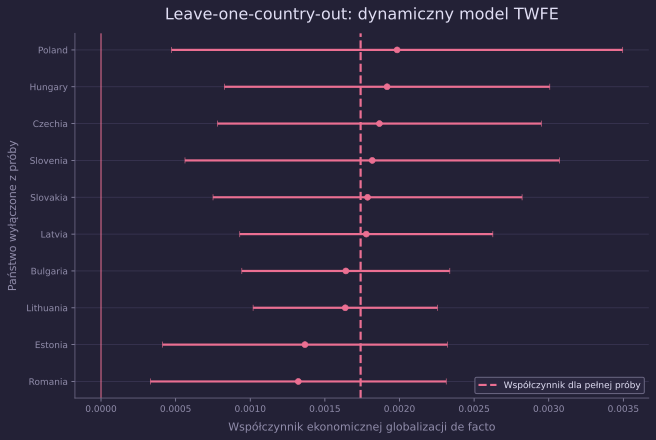

In [ ]:
loo_globalization_variable = (
    "kof_economic_de_facto"
)

loo_regressors = [
    "ln_gdp_lag1",
    capital_var,
    loo_globalization_variable,
    *reference_controls,
]

loo_required_columns = list(dict.fromkeys(
    [
        "iso3",
        "year",
        y_var,
        *loo_regressors,
    ]
))

loo_source_df = (
    dynamic_kof_common_df[
        loo_required_columns
    ]
    .dropna()
    .sort_values(
        ["iso3", "year"]
    )
    .copy()
)


if "country" in model_data.columns:

    loo_country_lookup = (
        model_data[
            [
                "iso3",
                "country",
            ]
        ]
        .drop_duplicates(
            subset="iso3"
        )
        .set_index("iso3")[
            "country"
        ]
        .to_dict()
    )

else:
    loo_country_lookup = {
        iso3: iso3
        for iso3
        in loo_source_df[
            "iso3"
        ].unique()
    }


def fit_loo_dynamic_twfe(df):
    """
    Estymuje dynamiczny model TWFE
    z błędami Driscolla–Kraaya.
    """

    panel_df = (
        df
        .set_index(
            ["iso3", "year"]
        )
        .sort_index()
    )

    model = PanelOLS(
        dependent=panel_df[
            y_var
        ],
        exog=panel_df[
            loo_regressors
        ],
        entity_effects=True,
        time_effects=True,
        drop_absorbed=True,
    )

    result = model.fit(
        cov_type="kernel",
        kernel="bartlett",
        bandwidth=DK_BANDWIDTH,
    )

    return result


loo_full_result = (
    fit_loo_dynamic_twfe(
        loo_source_df
    )
)

loo_full_coefficient = float(
    loo_full_result.params[
        loo_globalization_variable
    ]
)

loo_full_standard_error = float(
    loo_full_result.std_errors[
        loo_globalization_variable
    ]
)

loo_full_p_value = float(
    loo_full_result.pvalues[
        loo_globalization_variable
    ]
)

loo_full_critical_value = stats.t.ppf(
    0.975,
    df=loo_full_result.df_resid,
)

loo_full_ci_lower = (
    loo_full_coefficient
    -
    loo_full_critical_value
    * loo_full_standard_error
)

loo_full_ci_upper = (
    loo_full_coefficient
    +
    loo_full_critical_value
    * loo_full_standard_error
)


# Wspólna skala wykorzystywana we wszystkich
# wariantach leave-one-country-out.
loo_full_two_way_sd = two_way_residual_sd(
    df=loo_source_df,
    variable=loo_globalization_variable,
)

loo_full_percent_1sd = (
    100
    * np.expm1(
        loo_full_coefficient
        * loo_full_two_way_sd
    )
)


loo_results = []
loo_models = {
    "Pełna próba":
        loo_full_result,
}

for excluded_iso3 in sorted(
    loo_source_df[
        "iso3"
    ].unique()
):

    reduced_df = (
        loo_source_df.loc[
            loo_source_df[
                "iso3"
            ]
            != excluded_iso3
        ]
        .copy()
    )

    result = fit_loo_dynamic_twfe(
        reduced_df
    )

    excluded_country = (
        loo_country_lookup.get(
            excluded_iso3,
            excluded_iso3,
        )
    )

    loo_models[
        f"Bez {excluded_country}"
    ] = result

    coefficient = float(
        result.params[
            loo_globalization_variable
        ]
    )

    standard_error = float(
        result.std_errors[
            loo_globalization_variable
        ]
    )

    p_value = float(
        result.pvalues[
            loo_globalization_variable
        ]
    )

    critical_value = stats.t.ppf(
        0.975,
        df=result.df_resid,
    )

    ci_lower = (
        coefficient
        -
        critical_value
        * standard_error
    )

    ci_upper = (
        coefficient
        +
        critical_value
        * standard_error
    )

    absolute_change = (
        coefficient
        -
        loo_full_coefficient
    )

    relative_change_percent = (
        100
        * absolute_change
        / abs(
            loo_full_coefficient
        )
    )

    effect_percent_1sd = (
        100
        * np.expm1(
            coefficient
            * loo_full_two_way_sd
        )
    )

    loo_results.append({
        "excluded_iso3":
            excluded_iso3,

        "excluded_country":
            excluded_country,

        "nobs":
            result.nobs,

        "n_countries":
            reduced_df[
                "iso3"
            ].nunique(),

        "rho":
            result.params.get(
                "ln_gdp_lag1",
                np.nan,
            ),

        "coefficient":
            coefficient,

        "standard_error":
            standard_error,

        "p_value":
            p_value,

        "ci_lower":
            ci_lower,

        "ci_upper":
            ci_upper,

        "effect_percent_1sd":
            effect_percent_1sd,

        "absolute_change":
            absolute_change,

        "relative_change_percent":
            relative_change_percent,

        "same_sign_as_full":
            (
                np.sign(coefficient)
                ==
                np.sign(
                    loo_full_coefficient
                )
            ),

        "significant_5pct":
            p_value < 0.05,

        "full_coefficient_inside_ci":
            (
                ci_lower
                <= loo_full_coefficient
                <= ci_upper
            ),
    })


loo_results = pd.DataFrame(
    loo_results
)

loo_results[
    "absolute_relative_change"
] = (
    loo_results[
        "relative_change_percent"
    ]
    .abs()
)

loo_results = (
    loo_results
    .sort_values(
        "absolute_relative_change",
        ascending=False,
    )
    .reset_index(drop=True)
)


loo_full_sample_result = pd.DataFrame([
    {
        "sample":
            "Pełna próba",

        "nobs":
            loo_full_result.nobs,

        "n_countries":
            loo_source_df[
                "iso3"
            ].nunique(),

        "rho":
            loo_full_result.params.get(
                "ln_gdp_lag1",
                np.nan,
            ),

        "coefficient":
            loo_full_coefficient,

        "standard_error":
            loo_full_standard_error,

        "p_value":
            loo_full_p_value,

        "ci_lower":
            loo_full_ci_lower,

        "ci_upper":
            loo_full_ci_upper,

        "effect_percent_1sd":
            loo_full_percent_1sd,
    }
])


print(
    "Wynik dla pełnej próby:"
)

display(
    loo_full_sample_result.round(6)
)


print(
    "\nWyniki po wyłączeniu "
    "poszczególnych państw:"
)

display(
    loo_results[
        [
            "excluded_iso3",
            "excluded_country",
            "nobs",
            "rho",
            "coefficient",
            "standard_error",
            "p_value",
            "ci_lower",
            "ci_upper",
            "effect_percent_1sd",
            "relative_change_percent",
            "same_sign_as_full",
            "significant_5pct",
        ]
    ].round(6)
)


most_influential_row = (
    loo_results.iloc[0]
)

loo_robustness_summary = pd.DataFrame([
    {
        "full_sample_coefficient":
            loo_full_coefficient,

        "minimum_loo_coefficient":
            loo_results[
                "coefficient"
            ].min(),

        "maximum_loo_coefficient":
            loo_results[
                "coefficient"
            ].max(),

        "mean_loo_coefficient":
            loo_results[
                "coefficient"
            ].mean(),

        "standard_deviation_loo":
            loo_results[
                "coefficient"
            ].std(),

        "all_coefficients_same_sign":
            loo_results[
                "same_sign_as_full"
            ].all(),

        "number_significant_5pct":
            int(
                loo_results[
                    "significant_5pct"
                ].sum()
            ),

        "total_loo_models":
            len(
                loo_results
            ),

        "significant_in_all_models":
            loo_results[
                "significant_5pct"
            ].all(),

        "most_influential_exclusion":
            most_influential_row[
                "excluded_iso3"
            ],

        "largest_absolute_change_percent":
            most_influential_row[
                "absolute_relative_change"
            ],
    }
])


print(
    "\nZbiorcza ocena odporności:"
)

display(
    loo_robustness_summary.round(6)
)


loo_plot_df = (
    loo_results
    .sort_values(
        "coefficient"
    )
    .reset_index(drop=True)
)

y_positions = np.arange(
    len(loo_plot_df)
)

lower_errors = (
    loo_plot_df[
        "coefficient"
    ]
    -
    loo_plot_df[
        "ci_lower"
    ]
)

upper_errors = (
    loo_plot_df[
        "ci_upper"
    ]
    -
    loo_plot_df[
        "coefficient"
    ]
)


fig, ax = plt.subplots(
    figsize=(9, 6)
)

ax.errorbar(
    loo_plot_df[
        "coefficient"
    ],
    y_positions,
    xerr=np.vstack([
        lower_errors,
        upper_errors,
    ]),
    fmt="o",
    capsize=3,
)

ax.axvline(
    0,
    linewidth=1,
)

ax.axvline(
    loo_full_coefficient,
    linestyle="--",
    label=(
        "Współczynnik dla pełnej próby"
    ),
)

ax.set_yticks(
    y_positions
)

ax.set_yticklabels(
    loo_plot_df[
        "excluded_country"
    ]
)

ax.set_xlabel(
    "Współczynnik ekonomicznej globalizacji de facto"
)

ax.set_ylabel(
    "Państwo wyłączone z próby"
)

ax.set_title(
    "Leave-one-country-out: dynamiczny model TWFE"
)

ax.legend()

plt.show()

### Pełne wyniki estymacji

Poniżej przedstawiono pełne wyniki modelu oszacowanego dla pełnej
próby oraz modeli otrzymanych po kolejnym wyłączeniu każdego
państwa.

In [ ]:
for model_name, result in loo_models.items():
    print(f"\n{model_name}\n")
    print(result.summary)


Pełna próba

                          PanelOLS Estimation Summary                           
Dep. Variable:      ln_gdp_per_worker   R-squared:                        0.9042
Estimator:                   PanelOLS   R-squared (Between):              0.9886
No. Observations:                 280   R-squared (Within):               0.9821
Date:                Fri, Aug 14 2026   R-squared (Overall):              0.9886
Time:                        19:08:54   Log-likelihood                    632.74
Cov. Estimator:        Driscoll-Kraay                                           
                                        F-statistic:                      372.78
Entities:                          10   P-value                           0.0000
Avg Obs:                       28.000   Distribution:                   F(6,237)
Min Obs:                       28.000                                           
Max Obs:                       28.000   F-statistic (robust):             1264.0
              

# 6. Modele rocznego wzrostu gospodarczego

## 6.1. Zmiany globalizacji a roczny wzrost PKB na pracownika

W celu bezpośredniej analizy wzrostu gospodarczego jako zmienną
zależną przyjęto roczną zmianę logarytmu PKB na pracownika:

$$
g_{it}
=
\Delta\ln y_{it}.
$$

Oszacowano modele wykorzystujące roczne zmiany ogólnego indeksu
KOF oraz ekonomicznej globalizacji de facto. Zastosowano dwa
warianty czasowe: zmianę globalizacji zachodzącą w tym samym
roku oraz jej jednoroczne opóźnienie.

Model bieżącej zależności ma postać:

$$
\Delta\ln y_{it}
=
\lambda\ln y_{i,t-1}
+
\beta\Delta KOF_{it}
+
\theta\Delta\ln K_{it}
+
\gamma'X_{it}
+
\mu_i
+
\tau_t
+
\varepsilon_{it}.
$$

W modelu prognostycznym zmiany KOF, kapitału oraz zmienne
kontrolne opóźniono o jeden rok. Opóźniony poziom PKB uwzględnia
warunkową konwergencję gospodarczą.

Modele zawierają efekty państw i lat oraz błędy standardowe
Driscolla–Kraaya. Wariant bieżący opisuje współzmienność zmian
globalizacji i wzrostu, natomiast wariant opóźniony zapewnia
silniejsze uporządkowanie czasowe. Żaden z nich nie jest
interpretowany jako pełna identyfikacja przyczynowa.

In [ ]:
growth_dependent_variable = (
    "d_ln_gdp_per_worker"
)

growth_globalization_variables = [
    {
        "measure":
            "KOF ogółem",
        "level_variable":
            "kof_overall",
    },
    {
        "measure":
            "KOF ekonomiczny de facto",
        "level_variable":
            "kof_economic_de_facto",
    },
]


growth_model_data = (
    model_data
    .sort_values(["iso3", "year"])
    .copy()
)


required_growth_source_variables = [
    growth_dependent_variable,
    y_var,
    capital_var,
    "kof_overall",
    "kof_economic_de_facto",
    *reference_controls,
]

missing_growth_variables = [
    variable
    for variable
    in required_growth_source_variables
    if variable not in growth_model_data.columns
]

if missing_growth_variables:
    raise KeyError(
        "Brakuje zmiennych potrzebnych do modeli wzrostu: "
        f"{missing_growth_variables}"
    )


# Kontrola zgodności istniejącej zmiennej zmiany PKB.
growth_model_data[
    "d_ln_gdp_check"
] = (
    growth_model_data
    .groupby("iso3")[y_var]
    .diff()
)

growth_difference_check = (
    growth_model_data[
        [
            growth_dependent_variable,
            "d_ln_gdp_check",
        ]
    ]
    .dropna()
)

maximum_growth_difference = (
    growth_difference_check[
        growth_dependent_variable
    ]
    -
    growth_difference_check[
        "d_ln_gdp_check"
    ]
).abs().max()

print(
    "Maksymalna różnica między istniejącą "
    "i ponownie obliczoną zmianą PKB:",
    maximum_growth_difference,
)


growth_capital_change = (
    f"d_{capital_var}"
)

growth_model_data[
    growth_capital_change
] = (
    growth_model_data
    .groupby("iso3")[capital_var]
    .diff()
)


for specification in (
    growth_globalization_variables
):

    level_variable = (
        specification["level_variable"]
    )

    change_variable = (
        f"d_{level_variable}"
    )

    growth_model_data[
        change_variable
    ] = (
        growth_model_data
        .groupby("iso3")[level_variable]
        .diff()
    )

    specification[
        "change_variable"
    ] = change_variable


growth_initial_gdp_variable = (
    f"{y_var}_growth_lag1"
)

growth_model_data[
    growth_initial_gdp_variable
] = (
    growth_model_data
    .groupby("iso3")[y_var]
    .shift(1)
)


growth_change_variables = [
    specification["change_variable"]
    for specification
    in growth_globalization_variables
] + [
    growth_capital_change
]

for variable in growth_change_variables:

    growth_model_data[
        f"{variable}_lag1"
    ] = (
        growth_model_data
        .groupby("iso3")[variable]
        .shift(1)
    )


for variable in reference_controls:

    growth_model_data[
        f"{variable}_growth_lag1"
    ] = (
        growth_model_data
        .groupby("iso3")[variable]
        .shift(1)
    )


growth_education_lag1 = (
    "education_years_adults_growth_lag1"
)

growth_inflation_lag1 = (
    "inflation_cpi_growth_lag1"
)

growth_fdi_lag1 = (
    "fdi_gdp_growth_lag1"
)


growth_specifications = []

for specification in (
    growth_globalization_variables
):

    measure = specification["measure"]

    change_variable = (
        specification["change_variable"]
    )

    growth_specifications.append({
        "measure":
            measure,
        "timing":
            "zmiana bieżąca",
        "globalization_variable":
            change_variable,
        "capital_change_variable":
            growth_capital_change,
        "controls": [
            growth_education_lag1,
            "inflation_cpi",
            "fdi_gdp",
        ],
    })

    growth_specifications.append({
        "measure":
            measure,
        "timing":
            "zmiana opóźniona o rok",
        "globalization_variable":
            f"{change_variable}_lag1",
        "capital_change_variable":
            f"{growth_capital_change}_lag1",
        "controls": [
            growth_education_lag1,
            growth_inflation_lag1,
            growth_fdi_lag1,
        ],
    })


all_growth_regressors = [
    growth_initial_gdp_variable,
]

for specification in growth_specifications:

    all_growth_regressors.extend([
        specification[
            "globalization_variable"
        ],
        specification[
            "capital_change_variable"
        ],
    ])

    all_growth_regressors.extend(
        specification["controls"]
    )


growth_common_columns = list(dict.fromkeys(
    [
        "iso3",
        "year",
        growth_dependent_variable,
        *all_growth_regressors,
    ]
))

growth_common_df = (
    growth_model_data[
        growth_common_columns
    ]
    .dropna()
    .copy()
)


growth_sample_summary = pd.DataFrame({
    "nobs": [
        len(growth_common_df)
    ],
    "n_countries": [
        growth_common_df[
            "iso3"
        ].nunique()
    ],
    "n_years": [
        growth_common_df[
            "year"
        ].nunique()
    ],
    "first_year": [
        growth_common_df[
            "year"
        ].min()
    ],
    "last_year": [
        growth_common_df[
            "year"
        ].max()
    ],
})

display(
    growth_sample_summary
)


growth_results = []
growth_model_objects = {}

for specification in growth_specifications:

    globalization_variable = (
        specification[
            "globalization_variable"
        ]
    )

    regressors = [
        growth_initial_gdp_variable,
        specification[
            "capital_change_variable"
        ],
        globalization_variable,
        *specification["controls"],
    ]

    required_columns = list(dict.fromkeys(
        [
            "iso3",
            "year",
            growth_dependent_variable,
            *regressors,
        ]
    ))

    model_df = (
        growth_common_df[
            required_columns
        ]
        .dropna()
        .copy()
    )

    panel_df = (
        model_df
        .set_index(["iso3", "year"])
        .sort_index()
    )

    result = PanelOLS(
        dependent=panel_df[
            growth_dependent_variable
        ],
        exog=panel_df[
            regressors
        ],
        entity_effects=True,
        time_effects=True,
        drop_absorbed=True,
    ).fit(
        cov_type="kernel",
        kernel="bartlett",
        bandwidth=DK_BANDWIDTH,
    )

    model_key = (
        f"{specification['measure']} | "
        f"{specification['timing']}"
    )

    growth_model_objects[
        model_key
    ] = result

    coefficient = float(
        result.params[
            globalization_variable
        ]
    )

    standard_error = float(
        result.std_errors[
            globalization_variable
        ]
    )

    p_value = float(
        result.pvalues[
            globalization_variable
        ]
    )

    kof_change_two_way_sd = (
        two_way_residual_sd(
            df=model_df,
            variable=(
                globalization_variable
            ),
        )
    )

    effect_log_points_1sd = (
        coefficient
        * kof_change_two_way_sd
    )

    approximate_growth_pp_1sd = (
        100
        * effect_log_points_1sd
    )

    exact_growth_percent_1sd = (
        100
        * np.expm1(
            effect_log_points_1sd
        )
    )

    convergence_coefficient = (
        result.params.get(
            growth_initial_gdp_variable,
            np.nan,
        )
    )

    equivalent_rho = (
        1.0
        + convergence_coefficient
    )

    growth_results.append({
        "measure":
            specification["measure"],

        "timing":
            specification["timing"],

        "nobs":
            result.nobs,

        "globalization_variable":
            globalization_variable,

        "coefficient":
            coefficient,

        "standard_error":
            standard_error,

        "p_value":
            p_value,

        "significance":
            significance_stars(
                p_value
            ),

        "kof_change_two_way_sd":
            kof_change_two_way_sd,

        "approx_growth_pp_1sd":
            approximate_growth_pp_1sd,

        "exact_growth_percent_1sd":
            exact_growth_percent_1sd,

        "convergence_coefficient":
            convergence_coefficient,

        "convergence_p":
            result.pvalues.get(
                growth_initial_gdp_variable,
                np.nan,
            ),

        "equivalent_rho":
            equivalent_rho,

        "stable_equivalent_rho":
            0 < equivalent_rho < 1,

        "r2_within":
            result.rsquared_within,

        "r2_model":
            result.rsquared,
    })


growth_results = pd.DataFrame(
    growth_results
)


# Korekta Bonferroniego dla czterech
# współczynników opisujących zmiany KOF.
growth_results[
    "bonferroni_p"
] = np.minimum(
    growth_results[
        "p_value"
    ]
    * len(growth_results),
    1.0,
)

growth_results[
    "significant_after_bonferroni"
] = (
    growth_results[
        "bonferroni_p"
    ] < 0.05
)


growth_display_columns = [
    "measure",
    "timing",
    "nobs",
    "coefficient",
    "standard_error",
    "p_value",
    "bonferroni_p",
    "significance",
    "kof_change_two_way_sd",
    "approx_growth_pp_1sd",
    "exact_growth_percent_1sd",
    "convergence_coefficient",
    "convergence_p",
    "equivalent_rho",
    "stable_equivalent_rho",
    "r2_within",
]

display(
    growth_results[
        growth_display_columns
    ].round(6)
)

Maksymalna różnica między istniejącą i ponownie obliczoną zmianą PKB: 1.0672018824209317e-14


,nobs,n_countries,n_years,first_year,last_year
0,270,10,27,1997,2023


,measure,timing,nobs,coefficient,standard_error,p_value,bonferroni_p,significance,kof_change_two_way_sd,approx_growth_pp_1sd,exact_growth_percent_1sd,convergence_coefficient,convergence_p,equivalent_rho,stable_equivalent_rho,r2_within
0,KOF ogółem,zmiana bieżąca,270,-0.002523,0.001901,0.185912,0.743648,,0.676301,-0.170607,-0.170461,-0.057737,0.000170,0.942263,True,0.594817
1,KOF ogółem,zmiana opóźniona o rok,270,0.000741,0.002617,0.777464,1.000000,,0.725223,0.053709,0.053723,-0.118810,0.001538,0.881190,True,-0.011855
2,KOF ekonomiczny de facto,zmiana bieżąca,270,-0.000505,0.000718,0.482721,1.000000,,1.784659,-0.090139,-0.090099,-0.059143,0.000117,0.940857,True,0.598606
3,KOF ekonomiczny de facto,zmiana opóźniona o rok,270,-0.000349,0.001114,0.754430,1.000000,,2.019909,-0.070471,-0.070446,-0.119955,0.002958,0.880045,True,-0.015510


### Pełne wyniki estymacji

Poniżej przedstawiono pełne wyniki czterech modeli dotyczących
bieżących i opóźnionych zmian ogólnego indeksu KOF oraz
ekonomicznej globalizacji de facto.

In [ ]:
for model_key, result in growth_model_objects.items():
    print(f"\n{model_key}\n")
    print(result.summary)


KOF ogółem | zmiana bieżąca

                           PanelOLS Estimation Summary                           
Dep. Variable:     d_ln_gdp_per_worker   R-squared:                        0.5089
Estimator:                    PanelOLS   R-squared (Between):             -340.20
No. Observations:                  270   R-squared (Within):               0.5948
Date:                 Fri, Aug 14 2026   R-squared (Overall):             -117.48
Time:                         19:08:55   Log-likelihood                    652.87
Cov. Estimator:         Driscoll-Kraay                                           
                                         F-statistic:                      39.373
Entities:                           10   P-value                           0.0000
Avg Obs:                        27.000   Distribution:                   F(6,228)
Min Obs:                        27.000                                           
Max Obs:                        27.000   F-statistic (robust):      

## 6.2. Poziom globalizacji a roczny wzrost PKB

W tej części zbadano zależność między poziomem globalizacji
a roczną zmianą logarytmu PKB na pracownika.

Dla ogólnego indeksu KOF oraz ekonomicznej globalizacji de facto
oszacowano po dwa warianty: z bieżącym poziomem indeksu oraz
z jego jednorocznym opóźnieniem.

Wszystkie modele oszacowano na wspólnej próbie z efektami państw
i lat oraz błędami standardowymi Driscolla–Kraaya.

In [ ]:
growth_level_specifications_base = [
    {
        "measure": "KOF ogółem",
        "level_variable": "kof_overall",
    },
    {
        "measure": "KOF ekonomiczny de facto",
        "level_variable": "kof_economic_de_facto",
    },
]


for specification in growth_level_specifications_base:

    level_variable = (
        specification["level_variable"]
    )

    lagged_level_variable = (
        f"{level_variable}_growth_lag1"
    )

    growth_model_data[
        lagged_level_variable
    ] = (
        growth_model_data
        .groupby("iso3")[level_variable]
        .shift(1)
    )

    specification[
        "lagged_level_variable"
    ] = lagged_level_variable


growth_level_specifications = []

for specification in growth_level_specifications_base:

    measure = specification["measure"]
    level_variable = specification["level_variable"]

    growth_level_specifications.append({
        "measure":
            measure,
        "timing":
            "poziom bieżący",
        "globalization_variable":
            level_variable,
        "capital_variable":
            growth_capital_change,
        "controls": [
            growth_education_lag1,
            "inflation_cpi",
            "fdi_gdp",
        ],
    })

    growth_level_specifications.append({
        "measure":
            measure,
        "timing":
            "poziom opóźniony o rok",
        "globalization_variable":
            specification[
                "lagged_level_variable"
            ],
        "capital_variable":
            f"{growth_capital_change}_lag1",
        "controls": [
            growth_education_lag1,
            growth_inflation_lag1,
            growth_fdi_lag1,
        ],
    })


growth_level_all_regressors = [
    growth_initial_gdp_variable,
]

for specification in growth_level_specifications:

    growth_level_all_regressors.extend([
        specification[
            "globalization_variable"
        ],
        specification[
            "capital_variable"
        ],
    ])

    growth_level_all_regressors.extend(
        specification["controls"]
    )


growth_level_common_columns = list(dict.fromkeys(
    [
        "iso3",
        "year",
        growth_dependent_variable,
        *growth_level_all_regressors,
    ]
))


growth_level_common_df = (
    growth_model_data[
        growth_level_common_columns
    ]
    .dropna()
    .copy()
)


growth_level_sample_summary = pd.DataFrame({
    "nobs": [
        len(growth_level_common_df)
    ],
    "n_countries": [
        growth_level_common_df[
            "iso3"
        ].nunique()
    ],
    "n_years": [
        growth_level_common_df[
            "year"
        ].nunique()
    ],
    "first_year": [
        growth_level_common_df[
            "year"
        ].min()
    ],
    "last_year": [
        growth_level_common_df[
            "year"
        ].max()
    ],
})

display(
    growth_level_sample_summary
)


growth_level_results = []
growth_level_model_objects = {}

for specification in growth_level_specifications:

    globalization_variable = (
        specification[
            "globalization_variable"
        ]
    )

    regressors = [
        growth_initial_gdp_variable,
        specification[
            "capital_variable"
        ],
        globalization_variable,
        *specification["controls"],
    ]

    required_columns = list(dict.fromkeys(
        [
            "iso3",
            "year",
            growth_dependent_variable,
            *regressors,
        ]
    ))

    model_df = (
        growth_level_common_df[
            required_columns
        ]
        .dropna()
        .copy()
    )

    panel_df = (
        model_df
        .set_index(["iso3", "year"])
        .sort_index()
    )

    result = PanelOLS(
        dependent=panel_df[
            growth_dependent_variable
        ],
        exog=panel_df[
            regressors
        ],
        entity_effects=True,
        time_effects=True,
        drop_absorbed=True,
    ).fit(
        cov_type="kernel",
        kernel="bartlett",
        bandwidth=DK_BANDWIDTH,
    )

    model_key = (
        f"{specification['measure']} | "
        f"{specification['timing']}"
    )

    growth_level_model_objects[
        model_key
    ] = result

    coefficient = float(
        result.params[
            globalization_variable
        ]
    )

    standard_error = float(
        result.std_errors[
            globalization_variable
        ]
    )

    p_value = float(
        result.pvalues[
            globalization_variable
        ]
    )

    globalization_two_way_sd = (
        two_way_residual_sd(
            df=model_df,
            variable=globalization_variable,
        )
    )

    effect_log_points_1sd = (
        coefficient
        * globalization_two_way_sd
    )

    growth_level_results.append({
        "measure":
            specification["measure"],

        "timing":
            specification["timing"],

        "nobs":
            result.nobs,

        "globalization_variable":
            globalization_variable,

        "coefficient":
            coefficient,

        "standard_error":
            standard_error,

        "p_value":
            p_value,

        "significance":
            significance_stars(
                p_value
            ),

        "globalization_two_way_sd":
            globalization_two_way_sd,

        "approx_growth_pp_1sd":
            100
            * effect_log_points_1sd,

        "exact_growth_percent_1sd":
            100
            * np.expm1(
                effect_log_points_1sd
            ),

        "convergence_coefficient":
            result.params.get(
                growth_initial_gdp_variable,
                np.nan,
            ),

        "convergence_p":
            result.pvalues.get(
                growth_initial_gdp_variable,
                np.nan,
            ),

        "equivalent_rho":
            1.0
            + result.params.get(
                growth_initial_gdp_variable,
                np.nan,
            ),

        "r2_within":
            result.rsquared_within,

        "r2_model":
            result.rsquared,
    })


growth_level_results = pd.DataFrame(
    growth_level_results
)


# Korekta Bonferroniego dla czterech
# współczynników opisujących poziom KOF.
growth_level_results[
    "bonferroni_p"
] = np.minimum(
    growth_level_results[
        "p_value"
    ]
    * len(growth_level_results),
    1.0,
)

growth_level_results[
    "significant_after_bonferroni"
] = (
    growth_level_results[
        "bonferroni_p"
    ] < 0.05
)


growth_level_display_columns = [
    "measure",
    "timing",
    "nobs",
    "coefficient",
    "standard_error",
    "p_value",
    "bonferroni_p",
    "significance",
    "globalization_two_way_sd",
    "approx_growth_pp_1sd",
    "exact_growth_percent_1sd",
    "convergence_coefficient",
    "convergence_p",
    "equivalent_rho",
    "r2_within",
]

display(
    growth_level_results[
        growth_level_display_columns
    ].round(6)
)


growth_change_comparison = (
    growth_results[
        [
            "measure",
            "timing",
            "coefficient",
            "p_value",
            "approx_growth_pp_1sd",
        ]
    ]
    .copy()
)

growth_change_comparison[
    "timing"
] = (
    growth_change_comparison[
        "timing"
    ]
    .replace({
        "zmiana bieżąca":
            "bieżący",
        "zmiana opóźniona o rok":
            "opóźniony o rok",
    })
)


growth_level_comparison = (
    growth_level_results[
        [
            "measure",
            "timing",
            "coefficient",
            "p_value",
            "approx_growth_pp_1sd",
        ]
    ]
    .copy()
)

growth_level_comparison[
    "timing"
] = (
    growth_level_comparison[
        "timing"
    ]
    .replace({
        "poziom bieżący":
            "bieżący",
        "poziom opóźniony o rok":
            "opóźniony o rok",
    })
)


growth_level_change_comparison = (
    growth_level_comparison
    .merge(
        growth_change_comparison,
        on=[
            "measure",
            "timing",
        ],
        how="left",
        suffixes=(
            "_level",
            "_change",
        ),
    )
)


print(
    "Porównanie modeli poziomu "
    "i zmiany globalizacji:"
)

display(
    growth_level_change_comparison.round(6)
)

,nobs,n_countries,n_years,first_year,last_year
0,270,10,27,1997,2023


,measure,timing,nobs,coefficient,standard_error,p_value,bonferroni_p,significance,globalization_two_way_sd,approx_growth_pp_1sd,exact_growth_percent_1sd,convergence_coefficient,convergence_p,equivalent_rho,r2_within
0,KOF ogółem,poziom bieżący,270,0.000408,0.001664,0.806522,1.000000,,1.431811,0.058409,0.058426,-0.062191,0.021844,0.937809,0.609750
1,KOF ogółem,poziom opóźniony o rok,270,0.001728,0.002173,0.427290,1.000000,,1.497596,0.258767,0.259102,-0.133435,0.007365,0.866565,0.064023
2,KOF ekonomiczny de facto,poziom bieżący,270,0.000313,0.000295,0.290743,1.000000,,3.377146,0.105570,0.105625,-0.060729,0.000084,0.939271,0.605069
3,KOF ekonomiczny de facto,poziom opóźniony o rok,270,0.000868,0.000433,0.045911,0.183646,**,3.393274,0.294669,0.295104,-0.125405,0.000535,0.874595,0.005161


Porównanie modeli poziomu i zmiany globalizacji:


,measure,timing,coefficient_level,p_value_level,approx_growth_pp_1sd_level,coefficient_change,p_value_change,approx_growth_pp_1sd_change
0,KOF ogółem,bieżący,0.000408,0.806522,0.058409,-0.002523,0.185912,-0.170607
1,KOF ogółem,opóźniony o rok,0.001728,0.427290,0.258767,0.000741,0.777464,0.053709
2,KOF ekonomiczny de facto,bieżący,0.000313,0.290743,0.105570,-0.000505,0.482721,-0.090139
3,KOF ekonomiczny de facto,opóźniony o rok,0.000868,0.045911,0.294669,-0.000349,0.754430,-0.070471


### Pełne wyniki estymacji

Poniżej przedstawiono pełne wyniki czterech modeli wykorzystujących
bieżący i opóźniony poziom ogólnego indeksu KOF oraz ekonomicznej
globalizacji de facto.

In [ ]:
for model_key, result in growth_level_model_objects.items():
    print(f"\n{model_key}\n")
    print(result.summary)


KOF ogółem | poziom bieżący

                           PanelOLS Estimation Summary                           
Dep. Variable:     d_ln_gdp_per_worker   R-squared:                        0.5062
Estimator:                    PanelOLS   R-squared (Between):             -346.16
No. Observations:                  270   R-squared (Within):               0.6098
Date:                 Fri, Aug 14 2026   R-squared (Overall):             -119.53
Time:                         19:08:55   Log-likelihood                    652.15
Cov. Estimator:         Driscoll-Kraay                                           
                                         F-statistic:                      38.961
Entities:                           10   P-value                           0.0000
Avg Obs:                        27.000   Distribution:                   F(6,228)
Min Obs:                        27.000                                           
Max Obs:                        27.000   F-statistic (robust):      

## 6.3. Odporność na sposób czasowania regresorów

W celu sprawdzenia wrażliwości wyników na sposób czasowania
zmiennych oszacowano cztery warianty modelu dla ekonomicznej
globalizacji de facto.

Porównano modele wykorzystujące bieżący lub opóźniony poziom KOF,
różne czasowanie pozostałych regresorów oraz model zawierający
jednocześnie bieżący i opóźniony poziom KOF.

Dla modelu rozłożonych opóźnień przeprowadzono test łącznej
istotności obu współczynników KOF oraz test ich sumy.

In [ ]:
timing_current_kof = (
    "kof_economic_de_facto"
)

timing_lagged_kof = (
    "kof_economic_de_facto_growth_lag1"
)


timing_specifications = [
    {
        "model":
            "Bieżący KOF + bieżące X",

        "globalization_variables": [
            timing_current_kof,
        ],

        "capital_variable":
            growth_capital_change,

        "controls": [
            growth_education_lag1,
            "inflation_cpi",
            "fdi_gdp",
        ],
    },
    {
        "model":
            "Opóźniony KOF + bieżące X",

        "globalization_variables": [
            timing_lagged_kof,
        ],

        "capital_variable":
            growth_capital_change,

        "controls": [
            growth_education_lag1,
            "inflation_cpi",
            "fdi_gdp",
        ],
    },
    {
        "model":
            "Bieżący i opóźniony KOF + bieżące X",

        "globalization_variables": [
            timing_current_kof,
            timing_lagged_kof,
        ],

        "capital_variable":
            growth_capital_change,

        "controls": [
            growth_education_lag1,
            "inflation_cpi",
            "fdi_gdp",
        ],
    },
    {
        "model":
            "Opóźniony KOF + opóźnione X",

        "globalization_variables": [
            timing_lagged_kof,
        ],

        "capital_variable":
            f"{growth_capital_change}_lag1",

        "controls": [
            growth_education_lag1,
            growth_inflation_lag1,
            growth_fdi_lag1,
        ],
    },
]


timing_required_columns = list(dict.fromkeys(
    [
        "iso3",
        "year",
        growth_dependent_variable,
        growth_initial_gdp_variable,
        timing_current_kof,
        timing_lagged_kof,
        growth_capital_change,
        f"{growth_capital_change}_lag1",
        growth_education_lag1,
        "inflation_cpi",
        "fdi_gdp",
        growth_inflation_lag1,
        growth_fdi_lag1,
    ]
))


timing_common_df = (
    growth_model_data[
        timing_required_columns
    ]
    .dropna()
    .copy()
)


timing_sample_summary = pd.DataFrame({
    "nobs": [
        len(timing_common_df)
    ],
    "n_countries": [
        timing_common_df[
            "iso3"
        ].nunique()
    ],
    "n_years": [
        timing_common_df[
            "year"
        ].nunique()
    ],
    "first_year": [
        timing_common_df[
            "year"
        ].min()
    ],
    "last_year": [
        timing_common_df[
            "year"
        ].max()
    ],
})

display(
    timing_sample_summary
)


timing_results = []
timing_model_objects = {}


for specification in timing_specifications:

    regressors = list(dict.fromkeys(
        [
            growth_initial_gdp_variable,
            specification[
                "capital_variable"
            ],
            *specification[
                "globalization_variables"
            ],
            *specification[
                "controls"
            ],
        ]
    ))

    required_columns = list(dict.fromkeys(
        [
            "iso3",
            "year",
            growth_dependent_variable,
            *regressors,
        ]
    ))

    model_df = (
        timing_common_df[
            required_columns
        ]
        .dropna()
        .copy()
    )

    panel_df = (
        model_df
        .set_index(["iso3", "year"])
        .sort_index()
    )

    result = PanelOLS(
        dependent=panel_df[
            growth_dependent_variable
        ],
        exog=panel_df[
            regressors
        ],
        entity_effects=True,
        time_effects=True,
        drop_absorbed=True,
    ).fit(
        cov_type="kernel",
        kernel="bartlett",
        bandwidth=DK_BANDWIDTH,
    )

    model_label = (
        specification["model"]
    )

    timing_model_objects[
        model_label
    ] = result

    confidence_intervals = (
        result.conf_int()
    )

    for globalization_variable in [
        timing_current_kof,
        timing_lagged_kof,
    ]:

        if (
            globalization_variable
            in result.params.index
        ):
            timing_results.append({
                "model":
                    model_label,

                "globalization_variable":
                    globalization_variable,

                "coefficient":
                    result.params[
                        globalization_variable
                    ],

                "standard_error":
                    result.std_errors[
                        globalization_variable
                    ],

                "p_value":
                    result.pvalues[
                        globalization_variable
                    ],

                "ci_lower":
                    confidence_intervals.loc[
                        globalization_variable,
                        "lower",
                    ],

                "ci_upper":
                    confidence_intervals.loc[
                        globalization_variable,
                        "upper",
                    ],

                "nobs":
                    result.nobs,

                "r2_within":
                    result.rsquared_within,
            })


timing_results = pd.DataFrame(
    timing_results
)

display(
    timing_results.round(6)
)


distributed_model_label = (
    "Bieżący i opóźniony KOF + bieżące X"
)

distributed_result = (
    timing_model_objects[
        distributed_model_label
    ]
)


distributed_joint_test = joint_wald_zero_test(
    result=distributed_result,
    parameter_names=[
        timing_current_kof,
        timing_lagged_kof,
    ],
)


distributed_sum_test = linear_combination_statistics(
    result=distributed_result,
    weights={
        timing_current_kof: 1.0,
        timing_lagged_kof: 1.0,
    },
)


distributed_lag_tests = pd.DataFrame([
    {
        "test":
            "Oba współczynniki KOF = 0",

        "estimate":
            np.nan,

        "standard_error":
            np.nan,

        "statistic":
            distributed_joint_test[
                "wald_statistic"
            ],

        "degrees_of_freedom":
            distributed_joint_test[
                "degrees_of_freedom"
            ],

        "p_value":
            distributed_joint_test[
                "p_value"
            ],
    },
    {
        "test":
            "Suma bieżącego i opóźnionego KOF",

        "estimate":
            distributed_sum_test[
                "estimate"
            ],

        "standard_error":
            distributed_sum_test[
                "standard_error"
            ],

        "statistic":
            distributed_sum_test[
                "t_statistic"
            ],

        "degrees_of_freedom":
            1,

        "p_value":
            distributed_sum_test[
                "p_value"
            ],
    },
])


print(
    "Testy modelu rozłożonych opóźnień:"
)

display(
    distributed_lag_tests.round(6)
)


def two_way_demean_series(
    df,
    variable,
):
    return (
        df[variable]
        - df.groupby("iso3")[
            variable
        ].transform("mean")
        - df.groupby("year")[
            variable
        ].transform("mean")
        + df[variable].mean()
    )


timing_current_within = (
    two_way_demean_series(
        timing_common_df,
        timing_current_kof,
    )
)

timing_lagged_within = (
    two_way_demean_series(
        timing_common_df,
        timing_lagged_kof,
    )
)


timing_within_correlation = (
    timing_current_within
    .corr(
        timing_lagged_within
    )
)


print(
    "\nKorelacja bieżącego i opóźnionego "
    "KOF po usunięciu efektów państw i lat:",
    round(
        timing_within_correlation,
        6,
    ),
)

,nobs,n_countries,n_years,first_year,last_year
0,270,10,27,1997,2023


,model,globalization_variable,coefficient,standard_error,p_value,ci_lower,ci_upper,nobs,r2_within
0,Bieżący KOF + bieżące X,kof_economic_de_facto,0.000313,0.000295,0.290743,-0.000269,0.000894,270,0.605069
1,Opóźniony KOF + bieżące X,kof_economic_de_facto_growth_lag1,0.000485,0.000384,0.208299,-0.000272,0.001242,270,0.601837
2,Bieżący i opóźniony KOF + bieżące X,kof_economic_de_facto,-0.000275,0.000644,0.669926,-0.001543,0.000994,270,0.599440
3,Bieżący i opóźniony KOF + bieżące X,kof_economic_de_facto_growth_lag1,0.000708,0.000781,0.365558,-0.000831,0.002246,270,0.599440
4,Opóźniony KOF + opóźnione X,kof_economic_de_facto_growth_lag1,0.000868,0.000433,0.045911,0.000016,0.001721,270,0.005161


Testy modelu rozłożonych opóźnień:


,test,estimate,standard_error,statistic,degrees_of_freedom,p_value
0,Oba współczynniki KOF = 0,NaN,NaN,1.654352,2,0.437282
1,Suma bieżącego i opóźnionego KOF,0.000433,0.000341,1.270293,1,0.205281



Korelacja bieżącego i opóźnionego KOF po usunięciu efektów państw i lat: 0.861044


### Pełne wyniki estymacji

Poniżej przedstawiono pełne wyniki czterech modeli wykorzystanych
do oceny wrażliwości wyników na sposób czasowania regresorów.

In [ ]:
for model_label, result in timing_model_objects.items():
    print(f"\n{model_label}\n")
    print(result.summary)


Bieżący KOF + bieżące X

                           PanelOLS Estimation Summary                           
Dep. Variable:     d_ln_gdp_per_worker   R-squared:                        0.5069
Estimator:                    PanelOLS   R-squared (Between):             -359.49
No. Observations:                  270   R-squared (Within):               0.6051
Date:                 Fri, Aug 14 2026   R-squared (Overall):             -124.16
Time:                         19:08:56   Log-likelihood                    652.32
Cov. Estimator:         Driscoll-Kraay                                           
                                         F-statistic:                      39.057
Entities:                           10   P-value                           0.0000
Avg Obs:                        27.000   Distribution:                   F(6,228)
Min Obs:                        27.000                                           
Max Obs:                        27.000   F-statistic (robust):          

## 7. Podsumowanie

Notebook zawiera pełną procedurę przygotowania danych, estymacji modeli,
testów diagnostycznych oraz analiz odporności. Interpretację wyników
i weryfikację hipotez przedstawiono w części empirycznej pracy magisterskiej.